<div style="background:white;color:#111111;border-left:4px solid #111111;padding:18px 24px;line-height:1.75"><h2>Capítulo 1 · De los datos al perceptrón multicapa</h2><p>Muestrear → representar → transformar → componer → aprender.</p><p>Cada bloque desarrolla una pregunta nueva. La primera perspectiva de cada laboratorio sostiene el relato; las demás son consultas opcionales, no una secuencia que haya que recorrer. Las demos se controlan con Play, pausa y sliders. Las comparaciones entrenadas conservan resultados precalculados; las nuevas exploraciones calculan en el navegador.</p></div>

<div style="background:white;color:#111111;border-left:4px solid #111111;padding:18px 24px;line-height:1.75"><h2>01 · Del experimento al dataset</h2><p>Un experimento aleatorio produce un resultado sobre el que registramos varias características. Cada observación es una realización conjunta de esas variables; repetir el procedimiento proporciona una muestra. La tabla organiza las observaciones en filas y las variables en columnas.</p><p><strong>La muestra es un registro parcial, no la distribución que la genera.</strong> Las frecuencias empíricas varían entre muestras aunque el mecanismo permanezca fijo. La población seleccionada y las mediciones disponibles condicionan qué relaciones podremos aprender. La demo utiliza un generador sintético.</p><p><strong>Pregunta clave: ¿La nueva fila es una variable o una realización?</strong></p></div>

In [ ]:
from IPython.display import HTML, display
display(HTML('<iframe title="Del experimento al dataset" sandbox="allow-scripts" style="width:100%;height:840px;border:0" srcdoc="&lt;!doctype html&gt;&lt;html lang=&quot;es&quot;&gt;&lt;meta charset=&quot;utf-8&quot;&gt;&lt;style&gt;body{margin:0;font:14px system-ui;color:#334155}nav{padding:8px;display:flex;flex-wrap:wrap;gap:8px}button{font:inherit;padding:8px;border:1px solid #cbd5e1;background:white;border-radius:6px;cursor:pointer}button[aria-pressed=true]{background:#183b63;color:white}p{margin:8px}iframe{width:100%;height:730px;border:0}&lt;/style&gt;&lt;p&gt;Recorrido principal: primera vista. Las consultas son opcionales; al cambiar de vista se reinicia su demo.&lt;/p&gt;&lt;nav aria-label=&quot;Perspectivas del concepto&quot;&gt;&lt;/nav&gt;&lt;div id=&quot;view&quot;&gt;&lt;/div&gt;&lt;script&gt;const pages=[[&quot;Muestreo y registro&quot;, &quot;&lt;!doctype html&gt;&lt;html lang=\\&quot;es\\&quot;&gt;&lt;meta charset=\\&quot;utf-8\\&quot;&gt;\\n&lt;style&gt;\\n*{box-sizing:border-box}body{margin:0;padding:14px;background:#fff;color:#111;font:14px system-ui}button,select{border:1px solid #cbd5e1;background:#f8fafc;border-radius:7px;padding:8px 12px;cursor:pointer}button:hover{background:#e0e7ff}button:focus-visible,input:focus-visible,select:focus-visible{outline:3px solid #2563eb}header{display:flex;gap:8px;align-items:center;flex-wrap:wrap}#controls{display:flex;gap:12px;flex-wrap:wrap;margin:12px 0}label{display:flex;gap:8px;align-items:center;font-size:13px}input{width:125px;accent-color:#2563eb}output{font-variant-numeric:tabular-nums;min-width:40px}canvas{width:100%;height:auto;background:white}#note{min-height:38px;padding:8px;background:#f1f5f9;border-radius:7px}table{border-collapse:collapse;font-size:13px;width:100%}td,th{padding:5px 12px;text-align:right;border-bottom:1px solid #e2e8f0}tr.active{background:#dbeafe}#table{max-height:180px;overflow:auto}h3{margin:8px 0}small{color:#475569}\\n&lt;\\/style&gt;\\n&lt;header&gt;&lt;button id=\\&quot;play\\&quot;&gt;▶ Demo&lt;\\/button&gt;&lt;button id=\\&quot;pause\\&quot;&gt;Ⅱ Pausa&lt;\\/button&gt;&lt;button id=\\&quot;reset\\&quot;&gt;↺ Reiniciar&lt;\\/button&gt;&lt;span id=\\&quot;actions\\&quot;&gt;&lt;\\/span&gt;&lt;small&gt;Controles locales · respuesta continua&lt;\\/small&gt;&lt;\\/header&gt;\\n&lt;div id=\\&quot;controls\\&quot;&gt;&lt;\\/div&gt;&lt;canvas id=\\&quot;plot\\&quot; width=\\&quot;1000\\&quot; height=\\&quot;360\\&quot;&gt;&lt;\\/canvas&gt;&lt;div id=\\&quot;note\\&quot; role=\\&quot;status\\&quot;&gt;&lt;\\/div&gt;&lt;div id=\\&quot;table\\&quot;&gt;&lt;\\/div&gt;\\n&lt;script&gt;\\nconst cfg={\\&quot;mode\\&quot;: \\&quot;sample\\&quot;},mode=cfg.mode,C=document.getElementById(&#x27;plot&#x27;),g=C.getContext(&#x27;2d&#x27;),controls=document.getElementById(&#x27;controls&#x27;),note=document.getElementById(&#x27;note&#x27;),table=document.getElementById(&#x27;table&#x27;);\\nconst blue=&#x27;#2563eb&#x27;,orange=&#x27;#d97706&#x27;,green=&#x27;#15803d&#x27;,gray=&#x27;#64748b&#x27;;let playing=false,time=0,last=null,rows=[],selected=0,seed=42;\\nconst S={},inputs={},initial={};\\nfunction rand(){seed=(1664525*seed+1013904223)&gt;&gt;&gt;0;return seed/4294967296}\\nfunction normal(){return Math.sqrt(-2*Math.log(Math.max(rand(),1e-8)))*Math.cos(2*Math.PI*rand())}\\nfunction slider(key,label,value,min,max,step=.01){S[key]=value;initial[key]=value;const l=document.createElement(&#x27;label&#x27;);l.textContent=label;const i=document.createElement(&#x27;input&#x27;);i.type=&#x27;range&#x27;;i.min=min;i.max=max;i.step=step;i.value=value;i.setAttribute(&#x27;aria-label&#x27;,label);const o=document.createElement(&#x27;output&#x27;);o.textContent=value.toFixed(2);l.append(i,o);controls.append(l);inputs[key]={i,o};i.oninput=()=&gt;{playing=false;S[key]=+i.value;draw()}}\\nfunction button(text,fn){const b=document.createElement(&#x27;button&#x27;);b.textContent=text;b.onclick=()=&gt;{playing=false;fn();draw()};document.getElementById(&#x27;actions&#x27;).append(b)}\\nfunction set(k,v){S[k]=v;if(inputs[k]){inputs[k].i.value=v;inputs[k].o.textContent=v.toFixed(2)}}\\nfunction text(x,y,t,color=&#x27;#111&#x27;,size=16){g.fillStyle=color;g.font=`${size}px system-ui`;g.fillText(t,x,y)}\\nfunction line(x,y,u,v,color=gray,width=2){g.beginPath();g.moveTo(x,y);g.lineTo(u,v);g.strokeStyle=color;g.lineWidth=width;g.stroke()}\\nfunction dot(x,y,r=5,color=blue){g.beginPath();g.arc(x,y,r,0,Math.PI*2);g.fillStyle=color;g.fill()}\\nfunction arrow(x,y,u,v,color=blue){line(x,y,u,v,color,3);const a=Math.atan2(v-y,u-x);line(u,v,u-10*Math.cos(a-.4),v-10*Math.sin(a-.4),color,3);line(u,v,u-10*Math.cos(a+.4),v-10*Math.sin(a+.4),color,3)}\\nfunction axes(cx,cy,scale=45,label=&#x27;&#x27;){for(let k=-3;k&lt;=3;k++){line(cx-3*scale,cy+k*scale,cx+3*scale,cy+k*scale,&#x27;#e2e8f0&#x27;,1);line(cx+k*scale,cy-3*scale,cx+k*scale,cy+3*scale,&#x27;#e2e8f0&#x27;,1)}line(cx-3*scale,cy,cx+3*scale,cy);line(cx,cy+3*scale,cx,cy-3*scale);text(cx-130,25,label);text(cx+3*scale,cy+18,&#x27;x₁&#x27;,gray,12);text(cx+7,cy-3*scale,&#x27;x₂&#x27;,gray,12);return p=&gt;[cx+p[0]*scale,cy-p[1]*scale]}\\nfunction bar(x,y,w,h,value,label,color){g.fillStyle=color;g.fillRect(x,y-h*value,w,h*value);text(x,y+20,label,gray,12);text(x,y-h*value-8,value.toFixed(2),color,13)}\\nfunction sample(){const x=normal(),y=.65*x+.65*normal();rows.push({x,y,kind:rand()&lt;.5?&#x27;A&#x27;:&#x27;B&#x27;});if(rows.length&gt;18)rows.shift();selected=rows.length-1}\\nfunction renderTable(){table.innerHTML=&#x27;&lt;table&gt;&lt;thead&gt;&lt;tr&gt;&lt;th&gt;Observación&lt;\\/th&gt;&lt;th&gt;Medida X₁&lt;\\/th&gt;&lt;th&gt;Medida X₂&lt;\\/th&gt;&lt;th&gt;Tipo&lt;\\/th&gt;&lt;\\/tr&gt;&lt;\\/thead&gt;&lt;tbody&gt;&#x27;+rows.map((r,i)=&gt;`&lt;tr class=\\&quot;${i===selected?&#x27;active&#x27;:&#x27;&#x27;}\\&quot; data-i=\\&quot;${i}\\&quot;&gt;&lt;td&gt;${i+1}&lt;\\/td&gt;&lt;td&gt;${r.x.toFixed(2)}&lt;\\/td&gt;&lt;td&gt;${r.y.toFixed(2)}&lt;\\/td&gt;&lt;td&gt;${r.kind}&lt;\\/td&gt;&lt;\\/tr&gt;`).join(&#x27;&#x27;)+&#x27;&lt;\\/tbody&gt;&lt;\\/table&gt;&#x27;;table.querySelectorAll(&#x27;tr[data-i]&#x27;).forEach(e=&gt;{e.tabIndex=0;e.onclick=()=&gt;{selected=+e.dataset.i;draw()};e.onkeydown=ev=&gt;{if(ev.key===&#x27;Enter&#x27;)e.click()}})}\\nconst sigmoid=z=&gt;1/(1+Math.exp(-z)),act=(z,k)=&gt;k===&#x27;Escalón&#x27;?+(z&gt;=0):k===&#x27;Sigmoide&#x27;?sigmoid(z):k===&#x27;Tanh&#x27;?Math.tanh(z):k===&#x27;ReLU&#x27;?Math.max(0,z):z;\\nconst sampleModes=[&#x27;sample&#x27;,&#x27;random&#x27;,&#x27;table&#x27;];const transformModes=[&#x27;transform&#x27;,&#x27;matrix&#x27;,&#x27;rank&#x27;,&#x27;affine&#x27;];const neuronModes=[&#x27;neuron&#x27;,&#x27;weights&#x27;,&#x27;mp&#x27;,&#x27;active&#x27;];const activationModes=[&#x27;activations&#x27;,&#x27;sigmoid&#x27;,&#x27;logistic&#x27;,&#x27;relu&#x27;,&#x27;tanh&#x27;];\\nif(sampleModes.includes(mode)){for(let i=0;i&lt;6;i++)sample();button(&#x27;＋ Muestrear&#x27;,sample);button(&#x27;Nueva muestra (misma ley)&#x27;,()=&gt;{rows=[];for(let i=0;i&lt;12;i++)sample()});slider(&#x27;row&#x27;,&#x27;Observación&#x27;,0,0,17,1)}\\nelse if(mode===&#x27;encoding&#x27;){slider(&#x27;category&#x27;,&#x27;Categoría: A/B/C&#x27;,0,0,2,1);button(&#x27;Categoría siguiente&#x27;,()=&gt;set(&#x27;category&#x27;,(S.category+1)%3))}\\nelse if([&#x27;vector&#x27;,&#x27;scale&#x27;].includes(mode)){slider(&#x27;x&#x27;,&#x27;Entrada x₁&#x27;,1,-2,2);slider(&#x27;y&#x27;,&#x27;Entrada x₂&#x27;,1,-2,2);if(mode===&#x27;scale&#x27;)slider(&#x27;scale&#x27;,&#x27;Escala de x₁&#x27;,1,.2,3)}\\nelse if(transformModes.includes(mode)){slider(&#x27;a&#x27;,&#x27;A₁₁&#x27;,1,-2,2);slider(&#x27;b&#x27;,&#x27;A₁₂&#x27;,0,-2,2);slider(&#x27;c&#x27;,&#x27;A₂₁&#x27;,0,-2,2);slider(&#x27;d&#x27;,&#x27;A₂₂&#x27;,1,-2,2);if(mode===&#x27;affine&#x27;)slider(&#x27;bias&#x27;,&#x27;Sesgo b₁&#x27;,0,-1.5,1.5);button(&#x27;Rotar 90°&#x27;,()=&gt;{set(&#x27;a&#x27;,0);set(&#x27;b&#x27;,-1);set(&#x27;c&#x27;,1);set(&#x27;d&#x27;,0)});button(&#x27;Colapsar&#x27;,()=&gt;{set(&#x27;a&#x27;,1);set(&#x27;b&#x27;,1);set(&#x27;c&#x27;,0);set(&#x27;d&#x27;,0)})}\\nelse if(neuronModes.includes(mode)){slider(&#x27;x&#x27;,&#x27;Entrada x₁&#x27;,.8,-2,2);slider(&#x27;y&#x27;,&#x27;Entrada x₂&#x27;,.4,-2,2);slider(&#x27;w1&#x27;,&#x27;Peso w₁&#x27;,1,-2,2);slider(&#x27;w2&#x27;,&#x27;Peso w₂&#x27;,-.5,-2,2);slider(&#x27;bias&#x27;,&#x27;Sesgo&#x27;,0,-2,2)}\\nelse if(activationModes.includes(mode)){slider(&#x27;z&#x27;,&#x27;Puntuación z&#x27;,0,-6,6);if(mode===&#x27;logistic&#x27;){slider(&#x27;w1&#x27;,&#x27;Pendiente&#x27;,1,-3,3);slider(&#x27;bias&#x27;,&#x27;Sesgo&#x27;,0,-3,3)}}\\nelse if([&#x27;and&#x27;,&#x27;or&#x27;,&#x27;xor&#x27;,&#x27;hidden&#x27;].includes(mode)){slider(&#x27;x&#x27;,&#x27;Entrada binaria x₁&#x27;,0,0,1,1);slider(&#x27;y&#x27;,&#x27;Entrada binaria x₂&#x27;,0,0,1,1);slider(&#x27;w1&#x27;,&#x27;Peso w₁&#x27;,1,-2,2);slider(&#x27;w2&#x27;,&#x27;Peso w₂&#x27;,1,-2,2);slider(&#x27;bias&#x27;,&#x27;Sesgo&#x27;,mode===&#x27;and&#x27;?-1.5:mode===&#x27;or&#x27;?-.5:0,-3,2);button(&#x27;Siguiente entrada&#x27;,()=&gt;{let n=(S.x*2+S.y+1)%4;set(&#x27;x&#x27;,Math.floor(n/2));set(&#x27;y&#x27;,n%2)})}\\nelse if(mode===&#x27;latent&#x27;){slider(&#x27;x&#x27;,&#x27;Entrada x₁&#x27;,.4,-2,2);slider(&#x27;y&#x27;,&#x27;Entrada x₂&#x27;,.8,-2,2);slider(&#x27;gain&#x27;,&#x27;Ganancia oculta&#x27;,1,.1,3)}\\nif(mode===&#x27;hidden&#x27;){for(const key of [&#x27;w1&#x27;,&#x27;w2&#x27;,&#x27;bias&#x27;]){inputs[key].i.parentElement.remove();delete inputs[key]}}\\nconst dropdown=document.createElement(&#x27;select&#x27;);dropdown.setAttribute(&#x27;aria-label&#x27;,&#x27;Activación&#x27;);[&#x27;Lineal&#x27;,&#x27;Escalón&#x27;,&#x27;Sigmoide&#x27;,&#x27;Tanh&#x27;,&#x27;ReLU&#x27;].forEach(k=&gt;{const o=document.createElement(&#x27;option&#x27;);o.textContent=k;dropdown.append(o)});dropdown.value=mode===&#x27;mp&#x27;?&#x27;Escalón&#x27;:&#x27;Sigmoide&#x27;;dropdown.onchange=()=&gt;{playing=false;draw()};if([&#x27;mp&#x27;,&#x27;active&#x27;].includes(mode))controls.append(dropdown);\\nfunction draw(){g.clearRect(0,0,1000,360);Object.keys(inputs).forEach(k=&gt;inputs[k].o.textContent=S[k].toFixed(2));table.innerHTML=&#x27;&#x27;;\\nif(sampleModes.includes(mode)){\\n if(mode===&#x27;random&#x27;){\\n   const counts=Array(10).fill(0);rows.forEach(r=&gt;{const j=Math.max(0,Math.min(9,Math.floor((r.x+3)/.6)));counts[j]++});text(40,28,&#x27;Ley generadora → realizaciones → frecuencias&#x27;);\\n   for(let j=0;j&lt;10;j++)bar(70+j*38,300,29,18,counts[j],(-3+j*.6).toFixed(1),blue);\\n   text(65,340,&#x27;Histogramas pequeños varían entre muestras&#x27;,gray,14);\\n }else{const p=axes(235,185,45,&#x27;Cada realización añade un punto&#x27;);rows.forEach((r,i)=&gt;{dot(...p([r.x,r.y]),i===selected?8:4,i===selected?orange:blue)});}\\n text(520,55,&#x27;Experimento: medir dos magnitudes&#x27;);text(520,95,&#x27;X₁ = ε₁; X₂ = 0.65 X₁ + 0.65 ε₂&#x27;,blue,18);text(520,130,&#x27;ε₁, ε₂ ~ Normal(0,1), independientes&#x27;,gray,15);text(520,180,`${rows.length} observaciones registradas`,orange,23);text(520,220,&#x27;Tipo A/B: categoría muestreada aparte&#x27;,gray,14);renderTable();note.textContent=&#x27;Pulsa Muestrear o Play: una realización genera una fila. Haz clic o Enter sobre una fila para seguir su punto. Se muestran las últimas 18 observaciones.&#x27;;\\n}else if(mode===&#x27;encoding&#x27;){\\nconst j=S.category,labels=[&#x27;A&#x27;,&#x27;B&#x27;,&#x27;C&#x27;];text(55,55,&#x27;Categoría observada&#x27;,gray);text(150,150,labels[j],blue,72);arrow(265,140,440,140);text(510,55,&#x27;Codificación one-hot&#x27;);for(let k=0;k&lt;3;k++)bar(530+k*120,270,70,140,+(j===k),labels[k],j===k?orange:blue);note.textContent=&#x27;Las tres categorías tienen igual distancia entre códigos one-hot; codificar A=0, B=1, C=2 introduciría un orden y unas distancias no justificados.&#x27;;\\n}else if([&#x27;vector&#x27;,&#x27;scale&#x27;].includes(mode)){\\nlet scale=S.scale||1;const p=axes(235,185,45,&#x27;Un vector en ℝ²&#x27;);arrow(...p([0,0]),...p([S.x*scale,S.y]),blue);dot(...p([S.x*scale,S.y]),7,orange);text(520,50,mode===&#x27;scale&#x27;?&#x27;Cambiar unidades modifica la geometría&#x27;:&#x27;Coordenadas de la misma observación&#x27;);bar(570,210,80,45,S.x*scale,&#x27;x₁&#x27;,blue);bar(740,210,80,45,S.y,&#x27;x₂&#x27;,orange);note.textContent=`x = (${(S.x*scale).toFixed(2)}, ${S.y.toFixed(2)}). Mueve cada coordenada de manera independiente. ${mode===&#x27;scale&#x27;?&#x27;Escala no equivale a nueva información.&#x27;:&#x27;&#x27;}`;\\n}else if(transformModes.includes(mode)){\\nconst A=[[S.a,S.b],[S.c,S.d]],bias=S.bias||0,p=axes(210,180,38,&#x27;Espacio de entrada&#x27;),q=axes(780,180,38,&#x27;Espacio de llegada&#x27;);\\nconst transform=v=&gt;[A[0][0]*v[0]+A[0][1]*v[1]+bias,A[1][0]*v[0]+A[1][1]*v[1]];\\nfor(let k=-2;k&lt;=2;k++){for(let pair of [[[-2,k],[2,k]],[[k,-2],[k,2]]]){line(...p(pair[0]),...p(pair[1]),&#x27;#cbd5e1&#x27;,1);line(...q(transform(pair[0])),...q(transform(pair[1])),&#x27;#94a3b8&#x27;,1)}}\\nfor(let i=0;i&lt;20;i++){const v=[1.4*Math.cos(i*2.399),1.4*Math.sin(i*2.399)];dot(...p(v),4,blue);dot(...q(transform(v)),4,blue)}\\narrow(...p([0,0]),...p([1,0]),orange);arrow(...q(transform([0,0])),...q(transform([1,0])),orange);\\ntext(435,65,&#x27;h = Ax&#x27;+(bias?&#x27; + b&#x27;:&#x27;&#x27;),blue,20);text(422,108,`[ ${S.a.toFixed(2)}  ${S.b.toFixed(2)} ]`,blue,20);text(422,139,`[ ${S.c.toFixed(2)}  ${S.d.toFixed(2)} ]`,blue,20);arrow(405,190,555,190,green);\\nconst det=S.a*S.d-S.b*S.c;note.textContent=`det(A) = ${det.toFixed(3)}. ${mode===&#x27;rank&#x27;?&#x27;Colapsar hace perder una dimensión; distintas entradas pueden compartir salida.&#x27;:mode===&#x27;affine&#x27;?&#x27;Con sesgo, el origen puede dejar de ser fijo: la transformación es afín.&#x27;:&#x27;Los sliders cambian entradas concretas de A. Demo recorre matrices reproducibles y mueve toda la nube.&#x27;}`;\\n}else if(neuronModes.includes(mode)){\\nconst z=S.x*S.w1+S.y*S.w2+S.bias,k=mode===&#x27;neuron&#x27;||mode===&#x27;weights&#x27;?&#x27;Lineal&#x27;:dropdown.value,out=act(z,k);\\ndot(80,90,25,blue);dot(80,255,25,blue);text(43,43,`x₁=${S.x.toFixed(2)}`);text(43,315,`x₂=${S.y.toFixed(2)}`);\\narrow(108,90,340,172,blue);arrow(108,255,340,192,orange);text(150,96,`w₁=${S.w1.toFixed(2)}`);text(150,260,`w₂=${S.w2.toFixed(2)}`);dot(375,180,38,&#x27;#e2e8f0&#x27;);text(362,188,&#x27;Σ&#x27;,&#x27;#111&#x27;,28);text(312,120,`b=${S.bias.toFixed(2)}`);arrow(415,180,535,180,gray);text(438,151,`z=${z.toFixed(2)}`);g.strokeStyle=blue;g.strokeRect(540,145,115,70);text(553,184,k,blue,16);arrow(659,180,765,180,green);text(775,188,out.toFixed(3),green,30);\\ntext(120,340,`${S.x.toFixed(2)} × ${S.w1.toFixed(2)} + ${S.y.toFixed(2)} × ${S.w2.toFixed(2)} + ${S.bias.toFixed(2)} = ${z.toFixed(3)}`,gray,18);\\nif(mode===&#x27;weights&#x27;){\\ng.clearRect(0,0,1000,360);const project=(x,y,z)=&gt;[260+65*x+35*y,190+25*y-24*z];\\nfor(let k=-2;k&lt;=2;k+=.5){line(...project(-2,k,-2*S.w1+k*S.w2+S.bias),...project(2,k,2*S.w1+k*S.w2+S.bias),&#x27;#93c5fd&#x27;,1);line(...project(k,-2,k*S.w1-2*S.w2+S.bias),...project(k,2,k*S.w1+2*S.w2+S.bias),&#x27;#93c5fd&#x27;,1)}\\ndot(...project(S.x,S.y,z),9,orange);text(40,25,&#x27;Plano de puntuación: z = w₁x₁+w₂x₂+b&#x27;);text(580,55,&#x27;Contribuciones al resultado&#x27;);bar(590,210,60,28,S.w1*S.x,&#x27;w₁x₁&#x27;,blue);bar(715,210,60,28,S.w2*S.y,&#x27;w₂x₂&#x27;,orange);bar(840,210,60,28,S.bias,&#x27;b&#x27;,green);text(580,320,`z=${z.toFixed(3)}`,green,23);\\n}\\nnote.textContent=mode===&#x27;mp&#x27;?&#x27;Modelo de umbral inspirado en McCulloch–Pitts: separa suma y decisión. Los pesos continuos son una generalización didáctica.&#x27;:`Entradas y pesos tienen controles separados. ${k===&#x27;Lineal&#x27;?&#x27;Sin activación: vemos solo el bloque afín de la neurona.&#x27;:&#x27;La función &#x27;+k+&#x27; transforma la misma puntuación.&#x27;}`;\\n}else if(activationModes.includes(mode)){\\nconst kinds=mode===&#x27;activations&#x27;?[&#x27;Escalón&#x27;,&#x27;Sigmoide&#x27;,&#x27;Tanh&#x27;,&#x27;ReLU&#x27;]:[mode===&#x27;relu&#x27;?&#x27;ReLU&#x27;:mode===&#x27;tanh&#x27;?&#x27;Tanh&#x27;:&#x27;Sigmoide&#x27;];\\nkinds.forEach((k,index)=&gt;{const four=kinds.length===4,cx=four?70+(index%2)*490:80,cy=four?70+Math.floor(index/2)*170:180,w=four?350:440,h=four?50:115;const lo=k===&#x27;Tanh&#x27;?-1:0,hi=k===&#x27;ReLU&#x27;?6:1;line(cx,cy+h,cx+w,cy+h);line(cx+w/2,cy-h,cx+w/2,cy+h);text(cx,cy-h-10,k,blue,16);let prev=null;for(let i=0;i&lt;=120;i++){const x=-6+i/10,y=act(mode===&#x27;logistic&#x27;?S.w1*x+S.bias:x,k),point=[cx+i/120*w,cy+h-(y-lo)/(hi-lo)*h*1.5];if(prev)line(...prev,...point,blue,2);prev=point}const zz=mode===&#x27;logistic&#x27;?S.w1*S.z+S.bias:S.z,yy=act(zz,k);dot(cx+(S.z+6)/12*w,cy+h-(yy-lo)/(hi-lo)*h*1.5,6,orange);if(!four){text(620,105,`z = ${zz.toFixed(3)}`,gray,22);text(620,155,`f(z) = ${yy.toFixed(3)}`,blue,28);const derivative=k===&#x27;Sigmoide&#x27;?yy*(1-yy):k===&#x27;Tanh&#x27;?1-yy*yy:S.z&lt;0?0:1;text(620,215,`Sensibilidad local: ${derivative.toFixed(3)}`,green,18)}});\\nif(mode===&#x27;relu&#x27;&amp;&amp;S.z===0){g.clearRect(610,190,390,45);text(620,215,&#x27;Derivada no definida en cero&#x27;,green,18)}\\nnote.textContent=mode===&#x27;logistic&#x27;?&#x27;Regresión logística: p(y=1|x)=sigmoide(wx+b). Pendiente y sesgo cambian la curva; usar sigmoide no garantiza calibración.&#x27;:mode===&#x27;activations&#x27;?&#x27;Una misma entrada produce respuestas distintas. Mueve z y observa las cuatro curvas a la vez.&#x27;:&#x27;La salida y sensibilidad se calculan al arrastrar. El escalón y ReLU no tienen derivada clásica en cero.&#x27;;\\n}else if([&#x27;and&#x27;,&#x27;or&#x27;,&#x27;xor&#x27;,&#x27;hidden&#x27;].includes(mode)){\\nconst truth=(x,y)=&gt;mode===&#x27;and&#x27;?x&amp;&amp;y:mode===&#x27;or&#x27;?x||y:x!==y;\\nlet wrong=0;const p=axes(235,180,85,mode===&#x27;hidden&#x27;?&#x27;XOR: decisión compuesta&#x27;:&#x27;Puerta &#x27;+mode.toUpperCase());\\nfor(let x=0;x&lt;=1;x++)for(let y=0;y&lt;=1;y++){const target=+truth(x,y),pred=mode===&#x27;hidden&#x27;?+((x+y&gt;=.5)&amp;&amp;!(x+y&gt;=1.5)):+(S.w1*x+S.w2*y+S.bias&gt;=0);wrong+=pred!==target;dot(...p([x,y]),x===S.x&amp;&amp;y===S.y?12:8,target?orange:blue);text(p([x,y])[0]+15,p([x,y])[1],`${pred===target?&#x27;✓&#x27;:&#x27;×&#x27;} ${pred}`,pred===target?green:&#x27;#b91c1c&#x27;,16)}\\nif(mode!==&#x27;hidden&#x27;&amp;&amp;Math.abs(S.w2)&gt;.001){line(...p([-1,(-S.bias+S.w1)/S.w2]),...p([2,(-S.bias-2*S.w1)/S.w2]),gray)}\\nconst h1=+(S.x+S.y&gt;=.5),h2=+(S.x+S.y&gt;=1.5);text(560,65,`Entrada (${S.x}, ${S.y})`,blue,23);\\nif(mode===&#x27;hidden&#x27;){text(560,125,`h₁ = OR = ${h1}`);text(560,170,`h₂ = AND = ${h2}`);text(560,235,`Salida = h₁ AND NOT h₂ = ${+(h1&amp;&amp;!h2)}`,green,22)}else{text(560,135,`z = ${(S.w1*S.x+S.w2*S.y+S.bias).toFixed(2)}`);text(560,190,`Predicción = ${+(S.w1*S.x+S.w2*S.y+S.bias&gt;=0)}`,green,22)}\\ntext(560,300,`${wrong}/4 combinaciones incorrectas`,wrong?&#x27;#b91c1c&#x27;:green,20);note.textContent=mode===&#x27;hidden&#x27;?&#x27;Dos detectores intermedios y una salida resuelven XOR. Pesos construidos a mano: todavía no es aprendizaje.&#x27;:&#x27;Entradas binarias: su cambio es discreto por definición. Los pesos y el sesgo sí varían continuamente. Azul=0, naranja=1; × señala error.&#x27;;\\n}else if(mode===&#x27;latent&#x27;){\\nconst p=axes(225,180,48,&#x27;Variables de entrada&#x27;),q=axes(775,180,48,&#x27;Variables ocultas&#x27;);const h=[Math.tanh(S.gain*(S.x+S.y)-1),Math.tanh(S.gain*(-S.x-S.y)-1)];arrow(...p([0,0]),...p([S.x,S.y]),blue);arrow(...q([0,0]),...q(h),orange);arrow(405,180,570,180,green);text(400,110,&#x27;h = tanh(Wx+b)&#x27;,blue,19);text(400,245,`h₁=${h[0].toFixed(2)}; h₂=${h[1].toFixed(2)}`);note.textContent=&#x27;La representación oculta se calcula a partir de la entrada. Sus coordenadas no tienen por qué corresponder a factores semánticos interpretables.&#x27;;\\n}}\\ndocument.getElementById(&#x27;play&#x27;).onclick=()=&gt;{playing=true;last=null};document.getElementById(&#x27;pause&#x27;).onclick=()=&gt;playing=false;document.getElementById(&#x27;reset&#x27;).onclick=()=&gt;{playing=false;time=0;seed=42;Object.entries(initial).forEach(([k,v])=&gt;set(k,v));if(sampleModes.includes(mode)){rows=[];for(let i=0;i&lt;6;i++)sample()}draw()};\\nlet sampleClock=0;function animate(now){if(playing&amp;&amp;last!==null){const dt=Math.min(.1,(now-last)/1000);time+=dt;const f=Math.sin(time*.6);if(sampleModes.includes(mode)){sampleClock+=dt;if(sampleClock&gt;.8){sampleClock=0;sample()}}\\nelse if(transformModes.includes(mode)){if(mode===&#x27;rank&#x27;){set(&#x27;a&#x27;,1);set(&#x27;b&#x27;,0);set(&#x27;c&#x27;,0);set(&#x27;d&#x27;,(1+Math.cos(time*.5))/2)}else{set(&#x27;a&#x27;,Math.cos(time*.4));set(&#x27;b&#x27;,Math.sin(time*.53));set(&#x27;c&#x27;,Math.sin(time*.37+.3));set(&#x27;d&#x27;,Math.cos(time*.61))}if(mode===&#x27;affine&#x27;)set(&#x27;bias&#x27;,f)}\\nelse if(mode===&#x27;encoding&#x27;){set(&#x27;category&#x27;,Math.floor(time/1.4)%3)}else if([&#x27;and&#x27;,&#x27;or&#x27;,&#x27;xor&#x27;,&#x27;hidden&#x27;].includes(mode)){let i=Math.floor(time/1.5)%4;set(&#x27;x&#x27;,Math.floor(i/2));set(&#x27;y&#x27;,i%2);if(mode===&#x27;xor&#x27;){set(&#x27;w1&#x27;,1.5*f);set(&#x27;w2&#x27;,1.5*Math.cos(time*.6))}}\\nelse if(activationModes.includes(mode))set(&#x27;z&#x27;,6*f);\\nelse{if(&#x27;x&#x27;in S)set(&#x27;x&#x27;,1.5*f);if(&#x27;y&#x27;in S)set(&#x27;y&#x27;,1.5*Math.cos(time*.6));if(mode===&#x27;weights&#x27;){set(&#x27;w1&#x27;,2*Math.sin(time*.4));set(&#x27;w2&#x27;,2*Math.cos(time*.4))}if(mode===&#x27;scale&#x27;)set(&#x27;scale&#x27;,1.6+1.4*f)}draw()}last=now;requestAnimationFrame(animate)}\\nif(inputs.row)inputs.row.i.oninput=()=&gt;{playing=false;set(&#x27;row&#x27;,+inputs.row.i.value);selected=Math.min(S.row,rows.length-1);draw()};draw();requestAnimationFrame(animate);\\n&lt;\\/script&gt;&lt;\\/html&gt;\\n&quot;], [&quot;Consultar: variabilidad muestral&quot;, &quot;&lt;!doctype html&gt;&lt;html lang=\\&quot;es\\&quot;&gt;&lt;meta charset=\\&quot;utf-8\\&quot;&gt;\\n&lt;style&gt;\\n*{box-sizing:border-box}body{margin:0;padding:14px;background:#fff;color:#111;font:14px system-ui}button,select{border:1px solid #cbd5e1;background:#f8fafc;border-radius:7px;padding:8px 12px;cursor:pointer}button:hover{background:#e0e7ff}button:focus-visible,input:focus-visible,select:focus-visible{outline:3px solid #2563eb}header{display:flex;gap:8px;align-items:center;flex-wrap:wrap}#controls{display:flex;gap:12px;flex-wrap:wrap;margin:12px 0}label{display:flex;gap:8px;align-items:center;font-size:13px}input{width:125px;accent-color:#2563eb}output{font-variant-numeric:tabular-nums;min-width:40px}canvas{width:100%;height:auto;background:white}#note{min-height:38px;padding:8px;background:#f1f5f9;border-radius:7px}table{border-collapse:collapse;font-size:13px;width:100%}td,th{padding:5px 12px;text-align:right;border-bottom:1px solid #e2e8f0}tr.active{background:#dbeafe}#table{max-height:180px;overflow:auto}h3{margin:8px 0}small{color:#475569}\\n&lt;\\/style&gt;\\n&lt;header&gt;&lt;button id=\\&quot;play\\&quot;&gt;▶ Demo&lt;\\/button&gt;&lt;button id=\\&quot;pause\\&quot;&gt;Ⅱ Pausa&lt;\\/button&gt;&lt;button id=\\&quot;reset\\&quot;&gt;↺ Reiniciar&lt;\\/button&gt;&lt;span id=\\&quot;actions\\&quot;&gt;&lt;\\/span&gt;&lt;small&gt;Controles locales · respuesta continua&lt;\\/small&gt;&lt;\\/header&gt;\\n&lt;div id=\\&quot;controls\\&quot;&gt;&lt;\\/div&gt;&lt;canvas id=\\&quot;plot\\&quot; width=\\&quot;1000\\&quot; height=\\&quot;360\\&quot;&gt;&lt;\\/canvas&gt;&lt;div id=\\&quot;note\\&quot; role=\\&quot;status\\&quot;&gt;&lt;\\/div&gt;&lt;div id=\\&quot;table\\&quot;&gt;&lt;\\/div&gt;\\n&lt;script&gt;\\nconst cfg={\\&quot;mode\\&quot;: \\&quot;random\\&quot;},mode=cfg.mode,C=document.getElementById(&#x27;plot&#x27;),g=C.getContext(&#x27;2d&#x27;),controls=document.getElementById(&#x27;controls&#x27;),note=document.getElementById(&#x27;note&#x27;),table=document.getElementById(&#x27;table&#x27;);\\nconst blue=&#x27;#2563eb&#x27;,orange=&#x27;#d97706&#x27;,green=&#x27;#15803d&#x27;,gray=&#x27;#64748b&#x27;;let playing=false,time=0,last=null,rows=[],selected=0,seed=42;\\nconst S={},inputs={},initial={};\\nfunction rand(){seed=(1664525*seed+1013904223)&gt;&gt;&gt;0;return seed/4294967296}\\nfunction normal(){return Math.sqrt(-2*Math.log(Math.max(rand(),1e-8)))*Math.cos(2*Math.PI*rand())}\\nfunction slider(key,label,value,min,max,step=.01){S[key]=value;initial[key]=value;const l=document.createElement(&#x27;label&#x27;);l.textContent=label;const i=document.createElement(&#x27;input&#x27;);i.type=&#x27;range&#x27;;i.min=min;i.max=max;i.step=step;i.value=value;i.setAttribute(&#x27;aria-label&#x27;,label);const o=document.createElement(&#x27;output&#x27;);o.textContent=value.toFixed(2);l.append(i,o);controls.append(l);inputs[key]={i,o};i.oninput=()=&gt;{playing=false;S[key]=+i.value;draw()}}\\nfunction button(text,fn){const b=document.createElement(&#x27;button&#x27;);b.textContent=text;b.onclick=()=&gt;{playing=false;fn();draw()};document.getElementById(&#x27;actions&#x27;).append(b)}\\nfunction set(k,v){S[k]=v;if(inputs[k]){inputs[k].i.value=v;inputs[k].o.textContent=v.toFixed(2)}}\\nfunction text(x,y,t,color=&#x27;#111&#x27;,size=16){g.fillStyle=color;g.font=`${size}px system-ui`;g.fillText(t,x,y)}\\nfunction line(x,y,u,v,color=gray,width=2){g.beginPath();g.moveTo(x,y);g.lineTo(u,v);g.strokeStyle=color;g.lineWidth=width;g.stroke()}\\nfunction dot(x,y,r=5,color=blue){g.beginPath();g.arc(x,y,r,0,Math.PI*2);g.fillStyle=color;g.fill()}\\nfunction arrow(x,y,u,v,color=blue){line(x,y,u,v,color,3);const a=Math.atan2(v-y,u-x);line(u,v,u-10*Math.cos(a-.4),v-10*Math.sin(a-.4),color,3);line(u,v,u-10*Math.cos(a+.4),v-10*Math.sin(a+.4),color,3)}\\nfunction axes(cx,cy,scale=45,label=&#x27;&#x27;){for(let k=-3;k&lt;=3;k++){line(cx-3*scale,cy+k*scale,cx+3*scale,cy+k*scale,&#x27;#e2e8f0&#x27;,1);line(cx+k*scale,cy-3*scale,cx+k*scale,cy+3*scale,&#x27;#e2e8f0&#x27;,1)}line(cx-3*scale,cy,cx+3*scale,cy);line(cx,cy+3*scale,cx,cy-3*scale);text(cx-130,25,label);text(cx+3*scale,cy+18,&#x27;x₁&#x27;,gray,12);text(cx+7,cy-3*scale,&#x27;x₂&#x27;,gray,12);return p=&gt;[cx+p[0]*scale,cy-p[1]*scale]}\\nfunction bar(x,y,w,h,value,label,color){g.fillStyle=color;g.fillRect(x,y-h*value,w,h*value);text(x,y+20,label,gray,12);text(x,y-h*value-8,value.toFixed(2),color,13)}\\nfunction sample(){const x=normal(),y=.65*x+.65*normal();rows.push({x,y,kind:rand()&lt;.5?&#x27;A&#x27;:&#x27;B&#x27;});if(rows.length&gt;18)rows.shift();selected=rows.length-1}\\nfunction renderTable(){table.innerHTML=&#x27;&lt;table&gt;&lt;thead&gt;&lt;tr&gt;&lt;th&gt;Observación&lt;\\/th&gt;&lt;th&gt;Medida X₁&lt;\\/th&gt;&lt;th&gt;Medida X₂&lt;\\/th&gt;&lt;th&gt;Tipo&lt;\\/th&gt;&lt;\\/tr&gt;&lt;\\/thead&gt;&lt;tbody&gt;&#x27;+rows.map((r,i)=&gt;`&lt;tr class=\\&quot;${i===selected?&#x27;active&#x27;:&#x27;&#x27;}\\&quot; data-i=\\&quot;${i}\\&quot;&gt;&lt;td&gt;${i+1}&lt;\\/td&gt;&lt;td&gt;${r.x.toFixed(2)}&lt;\\/td&gt;&lt;td&gt;${r.y.toFixed(2)}&lt;\\/td&gt;&lt;td&gt;${r.kind}&lt;\\/td&gt;&lt;\\/tr&gt;`).join(&#x27;&#x27;)+&#x27;&lt;\\/tbody&gt;&lt;\\/table&gt;&#x27;;table.querySelectorAll(&#x27;tr[data-i]&#x27;).forEach(e=&gt;{e.tabIndex=0;e.onclick=()=&gt;{selected=+e.dataset.i;draw()};e.onkeydown=ev=&gt;{if(ev.key===&#x27;Enter&#x27;)e.click()}})}\\nconst sigmoid=z=&gt;1/(1+Math.exp(-z)),act=(z,k)=&gt;k===&#x27;Escalón&#x27;?+(z&gt;=0):k===&#x27;Sigmoide&#x27;?sigmoid(z):k===&#x27;Tanh&#x27;?Math.tanh(z):k===&#x27;ReLU&#x27;?Math.max(0,z):z;\\nconst sampleModes=[&#x27;sample&#x27;,&#x27;random&#x27;,&#x27;table&#x27;];const transformModes=[&#x27;transform&#x27;,&#x27;matrix&#x27;,&#x27;rank&#x27;,&#x27;affine&#x27;];const neuronModes=[&#x27;neuron&#x27;,&#x27;weights&#x27;,&#x27;mp&#x27;,&#x27;active&#x27;];const activationModes=[&#x27;activations&#x27;,&#x27;sigmoid&#x27;,&#x27;logistic&#x27;,&#x27;relu&#x27;,&#x27;tanh&#x27;];\\nif(sampleModes.includes(mode)){for(let i=0;i&lt;6;i++)sample();button(&#x27;＋ Muestrear&#x27;,sample);button(&#x27;Nueva muestra (misma ley)&#x27;,()=&gt;{rows=[];for(let i=0;i&lt;12;i++)sample()});slider(&#x27;row&#x27;,&#x27;Observación&#x27;,0,0,17,1)}\\nelse if(mode===&#x27;encoding&#x27;){slider(&#x27;category&#x27;,&#x27;Categoría: A/B/C&#x27;,0,0,2,1);button(&#x27;Categoría siguiente&#x27;,()=&gt;set(&#x27;category&#x27;,(S.category+1)%3))}\\nelse if([&#x27;vector&#x27;,&#x27;scale&#x27;].includes(mode)){slider(&#x27;x&#x27;,&#x27;Entrada x₁&#x27;,1,-2,2);slider(&#x27;y&#x27;,&#x27;Entrada x₂&#x27;,1,-2,2);if(mode===&#x27;scale&#x27;)slider(&#x27;scale&#x27;,&#x27;Escala de x₁&#x27;,1,.2,3)}\\nelse if(transformModes.includes(mode)){slider(&#x27;a&#x27;,&#x27;A₁₁&#x27;,1,-2,2);slider(&#x27;b&#x27;,&#x27;A₁₂&#x27;,0,-2,2);slider(&#x27;c&#x27;,&#x27;A₂₁&#x27;,0,-2,2);slider(&#x27;d&#x27;,&#x27;A₂₂&#x27;,1,-2,2);if(mode===&#x27;affine&#x27;)slider(&#x27;bias&#x27;,&#x27;Sesgo b₁&#x27;,0,-1.5,1.5);button(&#x27;Rotar 90°&#x27;,()=&gt;{set(&#x27;a&#x27;,0);set(&#x27;b&#x27;,-1);set(&#x27;c&#x27;,1);set(&#x27;d&#x27;,0)});button(&#x27;Colapsar&#x27;,()=&gt;{set(&#x27;a&#x27;,1);set(&#x27;b&#x27;,1);set(&#x27;c&#x27;,0);set(&#x27;d&#x27;,0)})}\\nelse if(neuronModes.includes(mode)){slider(&#x27;x&#x27;,&#x27;Entrada x₁&#x27;,.8,-2,2);slider(&#x27;y&#x27;,&#x27;Entrada x₂&#x27;,.4,-2,2);slider(&#x27;w1&#x27;,&#x27;Peso w₁&#x27;,1,-2,2);slider(&#x27;w2&#x27;,&#x27;Peso w₂&#x27;,-.5,-2,2);slider(&#x27;bias&#x27;,&#x27;Sesgo&#x27;,0,-2,2)}\\nelse if(activationModes.includes(mode)){slider(&#x27;z&#x27;,&#x27;Puntuación z&#x27;,0,-6,6);if(mode===&#x27;logistic&#x27;){slider(&#x27;w1&#x27;,&#x27;Pendiente&#x27;,1,-3,3);slider(&#x27;bias&#x27;,&#x27;Sesgo&#x27;,0,-3,3)}}\\nelse if([&#x27;and&#x27;,&#x27;or&#x27;,&#x27;xor&#x27;,&#x27;hidden&#x27;].includes(mode)){slider(&#x27;x&#x27;,&#x27;Entrada binaria x₁&#x27;,0,0,1,1);slider(&#x27;y&#x27;,&#x27;Entrada binaria x₂&#x27;,0,0,1,1);slider(&#x27;w1&#x27;,&#x27;Peso w₁&#x27;,1,-2,2);slider(&#x27;w2&#x27;,&#x27;Peso w₂&#x27;,1,-2,2);slider(&#x27;bias&#x27;,&#x27;Sesgo&#x27;,mode===&#x27;and&#x27;?-1.5:mode===&#x27;or&#x27;?-.5:0,-3,2);button(&#x27;Siguiente entrada&#x27;,()=&gt;{let n=(S.x*2+S.y+1)%4;set(&#x27;x&#x27;,Math.floor(n/2));set(&#x27;y&#x27;,n%2)})}\\nelse if(mode===&#x27;latent&#x27;){slider(&#x27;x&#x27;,&#x27;Entrada x₁&#x27;,.4,-2,2);slider(&#x27;y&#x27;,&#x27;Entrada x₂&#x27;,.8,-2,2);slider(&#x27;gain&#x27;,&#x27;Ganancia oculta&#x27;,1,.1,3)}\\nif(mode===&#x27;hidden&#x27;){for(const key of [&#x27;w1&#x27;,&#x27;w2&#x27;,&#x27;bias&#x27;]){inputs[key].i.parentElement.remove();delete inputs[key]}}\\nconst dropdown=document.createElement(&#x27;select&#x27;);dropdown.setAttribute(&#x27;aria-label&#x27;,&#x27;Activación&#x27;);[&#x27;Lineal&#x27;,&#x27;Escalón&#x27;,&#x27;Sigmoide&#x27;,&#x27;Tanh&#x27;,&#x27;ReLU&#x27;].forEach(k=&gt;{const o=document.createElement(&#x27;option&#x27;);o.textContent=k;dropdown.append(o)});dropdown.value=mode===&#x27;mp&#x27;?&#x27;Escalón&#x27;:&#x27;Sigmoide&#x27;;dropdown.onchange=()=&gt;{playing=false;draw()};if([&#x27;mp&#x27;,&#x27;active&#x27;].includes(mode))controls.append(dropdown);\\nfunction draw(){g.clearRect(0,0,1000,360);Object.keys(inputs).forEach(k=&gt;inputs[k].o.textContent=S[k].toFixed(2));table.innerHTML=&#x27;&#x27;;\\nif(sampleModes.includes(mode)){\\n if(mode===&#x27;random&#x27;){\\n   const counts=Array(10).fill(0);rows.forEach(r=&gt;{const j=Math.max(0,Math.min(9,Math.floor((r.x+3)/.6)));counts[j]++});text(40,28,&#x27;Ley generadora → realizaciones → frecuencias&#x27;);\\n   for(let j=0;j&lt;10;j++)bar(70+j*38,300,29,18,counts[j],(-3+j*.6).toFixed(1),blue);\\n   text(65,340,&#x27;Histogramas pequeños varían entre muestras&#x27;,gray,14);\\n }else{const p=axes(235,185,45,&#x27;Cada realización añade un punto&#x27;);rows.forEach((r,i)=&gt;{dot(...p([r.x,r.y]),i===selected?8:4,i===selected?orange:blue)});}\\n text(520,55,&#x27;Experimento: medir dos magnitudes&#x27;);text(520,95,&#x27;X₁ = ε₁; X₂ = 0.65 X₁ + 0.65 ε₂&#x27;,blue,18);text(520,130,&#x27;ε₁, ε₂ ~ Normal(0,1), independientes&#x27;,gray,15);text(520,180,`${rows.length} observaciones registradas`,orange,23);text(520,220,&#x27;Tipo A/B: categoría muestreada aparte&#x27;,gray,14);renderTable();note.textContent=&#x27;Pulsa Muestrear o Play: una realización genera una fila. Haz clic o Enter sobre una fila para seguir su punto. Se muestran las últimas 18 observaciones.&#x27;;\\n}else if(mode===&#x27;encoding&#x27;){\\nconst j=S.category,labels=[&#x27;A&#x27;,&#x27;B&#x27;,&#x27;C&#x27;];text(55,55,&#x27;Categoría observada&#x27;,gray);text(150,150,labels[j],blue,72);arrow(265,140,440,140);text(510,55,&#x27;Codificación one-hot&#x27;);for(let k=0;k&lt;3;k++)bar(530+k*120,270,70,140,+(j===k),labels[k],j===k?orange:blue);note.textContent=&#x27;Las tres categorías tienen igual distancia entre códigos one-hot; codificar A=0, B=1, C=2 introduciría un orden y unas distancias no justificados.&#x27;;\\n}else if([&#x27;vector&#x27;,&#x27;scale&#x27;].includes(mode)){\\nlet scale=S.scale||1;const p=axes(235,185,45,&#x27;Un vector en ℝ²&#x27;);arrow(...p([0,0]),...p([S.x*scale,S.y]),blue);dot(...p([S.x*scale,S.y]),7,orange);text(520,50,mode===&#x27;scale&#x27;?&#x27;Cambiar unidades modifica la geometría&#x27;:&#x27;Coordenadas de la misma observación&#x27;);bar(570,210,80,45,S.x*scale,&#x27;x₁&#x27;,blue);bar(740,210,80,45,S.y,&#x27;x₂&#x27;,orange);note.textContent=`x = (${(S.x*scale).toFixed(2)}, ${S.y.toFixed(2)}). Mueve cada coordenada de manera independiente. ${mode===&#x27;scale&#x27;?&#x27;Escala no equivale a nueva información.&#x27;:&#x27;&#x27;}`;\\n}else if(transformModes.includes(mode)){\\nconst A=[[S.a,S.b],[S.c,S.d]],bias=S.bias||0,p=axes(210,180,38,&#x27;Espacio de entrada&#x27;),q=axes(780,180,38,&#x27;Espacio de llegada&#x27;);\\nconst transform=v=&gt;[A[0][0]*v[0]+A[0][1]*v[1]+bias,A[1][0]*v[0]+A[1][1]*v[1]];\\nfor(let k=-2;k&lt;=2;k++){for(let pair of [[[-2,k],[2,k]],[[k,-2],[k,2]]]){line(...p(pair[0]),...p(pair[1]),&#x27;#cbd5e1&#x27;,1);line(...q(transform(pair[0])),...q(transform(pair[1])),&#x27;#94a3b8&#x27;,1)}}\\nfor(let i=0;i&lt;20;i++){const v=[1.4*Math.cos(i*2.399),1.4*Math.sin(i*2.399)];dot(...p(v),4,blue);dot(...q(transform(v)),4,blue)}\\narrow(...p([0,0]),...p([1,0]),orange);arrow(...q(transform([0,0])),...q(transform([1,0])),orange);\\ntext(435,65,&#x27;h = Ax&#x27;+(bias?&#x27; + b&#x27;:&#x27;&#x27;),blue,20);text(422,108,`[ ${S.a.toFixed(2)}  ${S.b.toFixed(2)} ]`,blue,20);text(422,139,`[ ${S.c.toFixed(2)}  ${S.d.toFixed(2)} ]`,blue,20);arrow(405,190,555,190,green);\\nconst det=S.a*S.d-S.b*S.c;note.textContent=`det(A) = ${det.toFixed(3)}. ${mode===&#x27;rank&#x27;?&#x27;Colapsar hace perder una dimensión; distintas entradas pueden compartir salida.&#x27;:mode===&#x27;affine&#x27;?&#x27;Con sesgo, el origen puede dejar de ser fijo: la transformación es afín.&#x27;:&#x27;Los sliders cambian entradas concretas de A. Demo recorre matrices reproducibles y mueve toda la nube.&#x27;}`;\\n}else if(neuronModes.includes(mode)){\\nconst z=S.x*S.w1+S.y*S.w2+S.bias,k=mode===&#x27;neuron&#x27;||mode===&#x27;weights&#x27;?&#x27;Lineal&#x27;:dropdown.value,out=act(z,k);\\ndot(80,90,25,blue);dot(80,255,25,blue);text(43,43,`x₁=${S.x.toFixed(2)}`);text(43,315,`x₂=${S.y.toFixed(2)}`);\\narrow(108,90,340,172,blue);arrow(108,255,340,192,orange);text(150,96,`w₁=${S.w1.toFixed(2)}`);text(150,260,`w₂=${S.w2.toFixed(2)}`);dot(375,180,38,&#x27;#e2e8f0&#x27;);text(362,188,&#x27;Σ&#x27;,&#x27;#111&#x27;,28);text(312,120,`b=${S.bias.toFixed(2)}`);arrow(415,180,535,180,gray);text(438,151,`z=${z.toFixed(2)}`);g.strokeStyle=blue;g.strokeRect(540,145,115,70);text(553,184,k,blue,16);arrow(659,180,765,180,green);text(775,188,out.toFixed(3),green,30);\\ntext(120,340,`${S.x.toFixed(2)} × ${S.w1.toFixed(2)} + ${S.y.toFixed(2)} × ${S.w2.toFixed(2)} + ${S.bias.toFixed(2)} = ${z.toFixed(3)}`,gray,18);\\nif(mode===&#x27;weights&#x27;){\\ng.clearRect(0,0,1000,360);const project=(x,y,z)=&gt;[260+65*x+35*y,190+25*y-24*z];\\nfor(let k=-2;k&lt;=2;k+=.5){line(...project(-2,k,-2*S.w1+k*S.w2+S.bias),...project(2,k,2*S.w1+k*S.w2+S.bias),&#x27;#93c5fd&#x27;,1);line(...project(k,-2,k*S.w1-2*S.w2+S.bias),...project(k,2,k*S.w1+2*S.w2+S.bias),&#x27;#93c5fd&#x27;,1)}\\ndot(...project(S.x,S.y,z),9,orange);text(40,25,&#x27;Plano de puntuación: z = w₁x₁+w₂x₂+b&#x27;);text(580,55,&#x27;Contribuciones al resultado&#x27;);bar(590,210,60,28,S.w1*S.x,&#x27;w₁x₁&#x27;,blue);bar(715,210,60,28,S.w2*S.y,&#x27;w₂x₂&#x27;,orange);bar(840,210,60,28,S.bias,&#x27;b&#x27;,green);text(580,320,`z=${z.toFixed(3)}`,green,23);\\n}\\nnote.textContent=mode===&#x27;mp&#x27;?&#x27;Modelo de umbral inspirado en McCulloch–Pitts: separa suma y decisión. Los pesos continuos son una generalización didáctica.&#x27;:`Entradas y pesos tienen controles separados. ${k===&#x27;Lineal&#x27;?&#x27;Sin activación: vemos solo el bloque afín de la neurona.&#x27;:&#x27;La función &#x27;+k+&#x27; transforma la misma puntuación.&#x27;}`;\\n}else if(activationModes.includes(mode)){\\nconst kinds=mode===&#x27;activations&#x27;?[&#x27;Escalón&#x27;,&#x27;Sigmoide&#x27;,&#x27;Tanh&#x27;,&#x27;ReLU&#x27;]:[mode===&#x27;relu&#x27;?&#x27;ReLU&#x27;:mode===&#x27;tanh&#x27;?&#x27;Tanh&#x27;:&#x27;Sigmoide&#x27;];\\nkinds.forEach((k,index)=&gt;{const four=kinds.length===4,cx=four?70+(index%2)*490:80,cy=four?70+Math.floor(index/2)*170:180,w=four?350:440,h=four?50:115;const lo=k===&#x27;Tanh&#x27;?-1:0,hi=k===&#x27;ReLU&#x27;?6:1;line(cx,cy+h,cx+w,cy+h);line(cx+w/2,cy-h,cx+w/2,cy+h);text(cx,cy-h-10,k,blue,16);let prev=null;for(let i=0;i&lt;=120;i++){const x=-6+i/10,y=act(mode===&#x27;logistic&#x27;?S.w1*x+S.bias:x,k),point=[cx+i/120*w,cy+h-(y-lo)/(hi-lo)*h*1.5];if(prev)line(...prev,...point,blue,2);prev=point}const zz=mode===&#x27;logistic&#x27;?S.w1*S.z+S.bias:S.z,yy=act(zz,k);dot(cx+(S.z+6)/12*w,cy+h-(yy-lo)/(hi-lo)*h*1.5,6,orange);if(!four){text(620,105,`z = ${zz.toFixed(3)}`,gray,22);text(620,155,`f(z) = ${yy.toFixed(3)}`,blue,28);const derivative=k===&#x27;Sigmoide&#x27;?yy*(1-yy):k===&#x27;Tanh&#x27;?1-yy*yy:S.z&lt;0?0:1;text(620,215,`Sensibilidad local: ${derivative.toFixed(3)}`,green,18)}});\\nif(mode===&#x27;relu&#x27;&amp;&amp;S.z===0){g.clearRect(610,190,390,45);text(620,215,&#x27;Derivada no definida en cero&#x27;,green,18)}\\nnote.textContent=mode===&#x27;logistic&#x27;?&#x27;Regresión logística: p(y=1|x)=sigmoide(wx+b). Pendiente y sesgo cambian la curva; usar sigmoide no garantiza calibración.&#x27;:mode===&#x27;activations&#x27;?&#x27;Una misma entrada produce respuestas distintas. Mueve z y observa las cuatro curvas a la vez.&#x27;:&#x27;La salida y sensibilidad se calculan al arrastrar. El escalón y ReLU no tienen derivada clásica en cero.&#x27;;\\n}else if([&#x27;and&#x27;,&#x27;or&#x27;,&#x27;xor&#x27;,&#x27;hidden&#x27;].includes(mode)){\\nconst truth=(x,y)=&gt;mode===&#x27;and&#x27;?x&amp;&amp;y:mode===&#x27;or&#x27;?x||y:x!==y;\\nlet wrong=0;const p=axes(235,180,85,mode===&#x27;hidden&#x27;?&#x27;XOR: decisión compuesta&#x27;:&#x27;Puerta &#x27;+mode.toUpperCase());\\nfor(let x=0;x&lt;=1;x++)for(let y=0;y&lt;=1;y++){const target=+truth(x,y),pred=mode===&#x27;hidden&#x27;?+((x+y&gt;=.5)&amp;&amp;!(x+y&gt;=1.5)):+(S.w1*x+S.w2*y+S.bias&gt;=0);wrong+=pred!==target;dot(...p([x,y]),x===S.x&amp;&amp;y===S.y?12:8,target?orange:blue);text(p([x,y])[0]+15,p([x,y])[1],`${pred===target?&#x27;✓&#x27;:&#x27;×&#x27;} ${pred}`,pred===target?green:&#x27;#b91c1c&#x27;,16)}\\nif(mode!==&#x27;hidden&#x27;&amp;&amp;Math.abs(S.w2)&gt;.001){line(...p([-1,(-S.bias+S.w1)/S.w2]),...p([2,(-S.bias-2*S.w1)/S.w2]),gray)}\\nconst h1=+(S.x+S.y&gt;=.5),h2=+(S.x+S.y&gt;=1.5);text(560,65,`Entrada (${S.x}, ${S.y})`,blue,23);\\nif(mode===&#x27;hidden&#x27;){text(560,125,`h₁ = OR = ${h1}`);text(560,170,`h₂ = AND = ${h2}`);text(560,235,`Salida = h₁ AND NOT h₂ = ${+(h1&amp;&amp;!h2)}`,green,22)}else{text(560,135,`z = ${(S.w1*S.x+S.w2*S.y+S.bias).toFixed(2)}`);text(560,190,`Predicción = ${+(S.w1*S.x+S.w2*S.y+S.bias&gt;=0)}`,green,22)}\\ntext(560,300,`${wrong}/4 combinaciones incorrectas`,wrong?&#x27;#b91c1c&#x27;:green,20);note.textContent=mode===&#x27;hidden&#x27;?&#x27;Dos detectores intermedios y una salida resuelven XOR. Pesos construidos a mano: todavía no es aprendizaje.&#x27;:&#x27;Entradas binarias: su cambio es discreto por definición. Los pesos y el sesgo sí varían continuamente. Azul=0, naranja=1; × señala error.&#x27;;\\n}else if(mode===&#x27;latent&#x27;){\\nconst p=axes(225,180,48,&#x27;Variables de entrada&#x27;),q=axes(775,180,48,&#x27;Variables ocultas&#x27;);const h=[Math.tanh(S.gain*(S.x+S.y)-1),Math.tanh(S.gain*(-S.x-S.y)-1)];arrow(...p([0,0]),...p([S.x,S.y]),blue);arrow(...q([0,0]),...q(h),orange);arrow(405,180,570,180,green);text(400,110,&#x27;h = tanh(Wx+b)&#x27;,blue,19);text(400,245,`h₁=${h[0].toFixed(2)}; h₂=${h[1].toFixed(2)}`);note.textContent=&#x27;La representación oculta se calcula a partir de la entrada. Sus coordenadas no tienen por qué corresponder a factores semánticos interpretables.&#x27;;\\n}}\\ndocument.getElementById(&#x27;play&#x27;).onclick=()=&gt;{playing=true;last=null};document.getElementById(&#x27;pause&#x27;).onclick=()=&gt;playing=false;document.getElementById(&#x27;reset&#x27;).onclick=()=&gt;{playing=false;time=0;seed=42;Object.entries(initial).forEach(([k,v])=&gt;set(k,v));if(sampleModes.includes(mode)){rows=[];for(let i=0;i&lt;6;i++)sample()}draw()};\\nlet sampleClock=0;function animate(now){if(playing&amp;&amp;last!==null){const dt=Math.min(.1,(now-last)/1000);time+=dt;const f=Math.sin(time*.6);if(sampleModes.includes(mode)){sampleClock+=dt;if(sampleClock&gt;.8){sampleClock=0;sample()}}\\nelse if(transformModes.includes(mode)){if(mode===&#x27;rank&#x27;){set(&#x27;a&#x27;,1);set(&#x27;b&#x27;,0);set(&#x27;c&#x27;,0);set(&#x27;d&#x27;,(1+Math.cos(time*.5))/2)}else{set(&#x27;a&#x27;,Math.cos(time*.4));set(&#x27;b&#x27;,Math.sin(time*.53));set(&#x27;c&#x27;,Math.sin(time*.37+.3));set(&#x27;d&#x27;,Math.cos(time*.61))}if(mode===&#x27;affine&#x27;)set(&#x27;bias&#x27;,f)}\\nelse if(mode===&#x27;encoding&#x27;){set(&#x27;category&#x27;,Math.floor(time/1.4)%3)}else if([&#x27;and&#x27;,&#x27;or&#x27;,&#x27;xor&#x27;,&#x27;hidden&#x27;].includes(mode)){let i=Math.floor(time/1.5)%4;set(&#x27;x&#x27;,Math.floor(i/2));set(&#x27;y&#x27;,i%2);if(mode===&#x27;xor&#x27;){set(&#x27;w1&#x27;,1.5*f);set(&#x27;w2&#x27;,1.5*Math.cos(time*.6))}}\\nelse if(activationModes.includes(mode))set(&#x27;z&#x27;,6*f);\\nelse{if(&#x27;x&#x27;in S)set(&#x27;x&#x27;,1.5*f);if(&#x27;y&#x27;in S)set(&#x27;y&#x27;,1.5*Math.cos(time*.6));if(mode===&#x27;weights&#x27;){set(&#x27;w1&#x27;,2*Math.sin(time*.4));set(&#x27;w2&#x27;,2*Math.cos(time*.4))}if(mode===&#x27;scale&#x27;)set(&#x27;scale&#x27;,1.6+1.4*f)}draw()}last=now;requestAnimationFrame(animate)}\\nif(inputs.row)inputs.row.i.oninput=()=&gt;{playing=false;set(&#x27;row&#x27;,+inputs.row.i.value);selected=Math.min(S.row,rows.length-1);draw()};draw();requestAnimationFrame(animate);\\n&lt;\\/script&gt;&lt;\\/html&gt;\\n&quot;], [&quot;Consultar: fila y punto&quot;, &quot;&lt;!doctype html&gt;&lt;html lang=\\&quot;es\\&quot;&gt;&lt;meta charset=\\&quot;utf-8\\&quot;&gt;\\n&lt;style&gt;\\n*{box-sizing:border-box}body{margin:0;padding:14px;background:#fff;color:#111;font:14px system-ui}button,select{border:1px solid #cbd5e1;background:#f8fafc;border-radius:7px;padding:8px 12px;cursor:pointer}button:hover{background:#e0e7ff}button:focus-visible,input:focus-visible,select:focus-visible{outline:3px solid #2563eb}header{display:flex;gap:8px;align-items:center;flex-wrap:wrap}#controls{display:flex;gap:12px;flex-wrap:wrap;margin:12px 0}label{display:flex;gap:8px;align-items:center;font-size:13px}input{width:125px;accent-color:#2563eb}output{font-variant-numeric:tabular-nums;min-width:40px}canvas{width:100%;height:auto;background:white}#note{min-height:38px;padding:8px;background:#f1f5f9;border-radius:7px}table{border-collapse:collapse;font-size:13px;width:100%}td,th{padding:5px 12px;text-align:right;border-bottom:1px solid #e2e8f0}tr.active{background:#dbeafe}#table{max-height:180px;overflow:auto}h3{margin:8px 0}small{color:#475569}\\n&lt;\\/style&gt;\\n&lt;header&gt;&lt;button id=\\&quot;play\\&quot;&gt;▶ Demo&lt;\\/button&gt;&lt;button id=\\&quot;pause\\&quot;&gt;Ⅱ Pausa&lt;\\/button&gt;&lt;button id=\\&quot;reset\\&quot;&gt;↺ Reiniciar&lt;\\/button&gt;&lt;span id=\\&quot;actions\\&quot;&gt;&lt;\\/span&gt;&lt;small&gt;Controles locales · respuesta continua&lt;\\/small&gt;&lt;\\/header&gt;\\n&lt;div id=\\&quot;controls\\&quot;&gt;&lt;\\/div&gt;&lt;canvas id=\\&quot;plot\\&quot; width=\\&quot;1000\\&quot; height=\\&quot;360\\&quot;&gt;&lt;\\/canvas&gt;&lt;div id=\\&quot;note\\&quot; role=\\&quot;status\\&quot;&gt;&lt;\\/div&gt;&lt;div id=\\&quot;table\\&quot;&gt;&lt;\\/div&gt;\\n&lt;script&gt;\\nconst cfg={\\&quot;mode\\&quot;: \\&quot;table\\&quot;},mode=cfg.mode,C=document.getElementById(&#x27;plot&#x27;),g=C.getContext(&#x27;2d&#x27;),controls=document.getElementById(&#x27;controls&#x27;),note=document.getElementById(&#x27;note&#x27;),table=document.getElementById(&#x27;table&#x27;);\\nconst blue=&#x27;#2563eb&#x27;,orange=&#x27;#d97706&#x27;,green=&#x27;#15803d&#x27;,gray=&#x27;#64748b&#x27;;let playing=false,time=0,last=null,rows=[],selected=0,seed=42;\\nconst S={},inputs={},initial={};\\nfunction rand(){seed=(1664525*seed+1013904223)&gt;&gt;&gt;0;return seed/4294967296}\\nfunction normal(){return Math.sqrt(-2*Math.log(Math.max(rand(),1e-8)))*Math.cos(2*Math.PI*rand())}\\nfunction slider(key,label,value,min,max,step=.01){S[key]=value;initial[key]=value;const l=document.createElement(&#x27;label&#x27;);l.textContent=label;const i=document.createElement(&#x27;input&#x27;);i.type=&#x27;range&#x27;;i.min=min;i.max=max;i.step=step;i.value=value;i.setAttribute(&#x27;aria-label&#x27;,label);const o=document.createElement(&#x27;output&#x27;);o.textContent=value.toFixed(2);l.append(i,o);controls.append(l);inputs[key]={i,o};i.oninput=()=&gt;{playing=false;S[key]=+i.value;draw()}}\\nfunction button(text,fn){const b=document.createElement(&#x27;button&#x27;);b.textContent=text;b.onclick=()=&gt;{playing=false;fn();draw()};document.getElementById(&#x27;actions&#x27;).append(b)}\\nfunction set(k,v){S[k]=v;if(inputs[k]){inputs[k].i.value=v;inputs[k].o.textContent=v.toFixed(2)}}\\nfunction text(x,y,t,color=&#x27;#111&#x27;,size=16){g.fillStyle=color;g.font=`${size}px system-ui`;g.fillText(t,x,y)}\\nfunction line(x,y,u,v,color=gray,width=2){g.beginPath();g.moveTo(x,y);g.lineTo(u,v);g.strokeStyle=color;g.lineWidth=width;g.stroke()}\\nfunction dot(x,y,r=5,color=blue){g.beginPath();g.arc(x,y,r,0,Math.PI*2);g.fillStyle=color;g.fill()}\\nfunction arrow(x,y,u,v,color=blue){line(x,y,u,v,color,3);const a=Math.atan2(v-y,u-x);line(u,v,u-10*Math.cos(a-.4),v-10*Math.sin(a-.4),color,3);line(u,v,u-10*Math.cos(a+.4),v-10*Math.sin(a+.4),color,3)}\\nfunction axes(cx,cy,scale=45,label=&#x27;&#x27;){for(let k=-3;k&lt;=3;k++){line(cx-3*scale,cy+k*scale,cx+3*scale,cy+k*scale,&#x27;#e2e8f0&#x27;,1);line(cx+k*scale,cy-3*scale,cx+k*scale,cy+3*scale,&#x27;#e2e8f0&#x27;,1)}line(cx-3*scale,cy,cx+3*scale,cy);line(cx,cy+3*scale,cx,cy-3*scale);text(cx-130,25,label);text(cx+3*scale,cy+18,&#x27;x₁&#x27;,gray,12);text(cx+7,cy-3*scale,&#x27;x₂&#x27;,gray,12);return p=&gt;[cx+p[0]*scale,cy-p[1]*scale]}\\nfunction bar(x,y,w,h,value,label,color){g.fillStyle=color;g.fillRect(x,y-h*value,w,h*value);text(x,y+20,label,gray,12);text(x,y-h*value-8,value.toFixed(2),color,13)}\\nfunction sample(){const x=normal(),y=.65*x+.65*normal();rows.push({x,y,kind:rand()&lt;.5?&#x27;A&#x27;:&#x27;B&#x27;});if(rows.length&gt;18)rows.shift();selected=rows.length-1}\\nfunction renderTable(){table.innerHTML=&#x27;&lt;table&gt;&lt;thead&gt;&lt;tr&gt;&lt;th&gt;Observación&lt;\\/th&gt;&lt;th&gt;Medida X₁&lt;\\/th&gt;&lt;th&gt;Medida X₂&lt;\\/th&gt;&lt;th&gt;Tipo&lt;\\/th&gt;&lt;\\/tr&gt;&lt;\\/thead&gt;&lt;tbody&gt;&#x27;+rows.map((r,i)=&gt;`&lt;tr class=\\&quot;${i===selected?&#x27;active&#x27;:&#x27;&#x27;}\\&quot; data-i=\\&quot;${i}\\&quot;&gt;&lt;td&gt;${i+1}&lt;\\/td&gt;&lt;td&gt;${r.x.toFixed(2)}&lt;\\/td&gt;&lt;td&gt;${r.y.toFixed(2)}&lt;\\/td&gt;&lt;td&gt;${r.kind}&lt;\\/td&gt;&lt;\\/tr&gt;`).join(&#x27;&#x27;)+&#x27;&lt;\\/tbody&gt;&lt;\\/table&gt;&#x27;;table.querySelectorAll(&#x27;tr[data-i]&#x27;).forEach(e=&gt;{e.tabIndex=0;e.onclick=()=&gt;{selected=+e.dataset.i;draw()};e.onkeydown=ev=&gt;{if(ev.key===&#x27;Enter&#x27;)e.click()}})}\\nconst sigmoid=z=&gt;1/(1+Math.exp(-z)),act=(z,k)=&gt;k===&#x27;Escalón&#x27;?+(z&gt;=0):k===&#x27;Sigmoide&#x27;?sigmoid(z):k===&#x27;Tanh&#x27;?Math.tanh(z):k===&#x27;ReLU&#x27;?Math.max(0,z):z;\\nconst sampleModes=[&#x27;sample&#x27;,&#x27;random&#x27;,&#x27;table&#x27;];const transformModes=[&#x27;transform&#x27;,&#x27;matrix&#x27;,&#x27;rank&#x27;,&#x27;affine&#x27;];const neuronModes=[&#x27;neuron&#x27;,&#x27;weights&#x27;,&#x27;mp&#x27;,&#x27;active&#x27;];const activationModes=[&#x27;activations&#x27;,&#x27;sigmoid&#x27;,&#x27;logistic&#x27;,&#x27;relu&#x27;,&#x27;tanh&#x27;];\\nif(sampleModes.includes(mode)){for(let i=0;i&lt;6;i++)sample();button(&#x27;＋ Muestrear&#x27;,sample);button(&#x27;Nueva muestra (misma ley)&#x27;,()=&gt;{rows=[];for(let i=0;i&lt;12;i++)sample()});slider(&#x27;row&#x27;,&#x27;Observación&#x27;,0,0,17,1)}\\nelse if(mode===&#x27;encoding&#x27;){slider(&#x27;category&#x27;,&#x27;Categoría: A/B/C&#x27;,0,0,2,1);button(&#x27;Categoría siguiente&#x27;,()=&gt;set(&#x27;category&#x27;,(S.category+1)%3))}\\nelse if([&#x27;vector&#x27;,&#x27;scale&#x27;].includes(mode)){slider(&#x27;x&#x27;,&#x27;Entrada x₁&#x27;,1,-2,2);slider(&#x27;y&#x27;,&#x27;Entrada x₂&#x27;,1,-2,2);if(mode===&#x27;scale&#x27;)slider(&#x27;scale&#x27;,&#x27;Escala de x₁&#x27;,1,.2,3)}\\nelse if(transformModes.includes(mode)){slider(&#x27;a&#x27;,&#x27;A₁₁&#x27;,1,-2,2);slider(&#x27;b&#x27;,&#x27;A₁₂&#x27;,0,-2,2);slider(&#x27;c&#x27;,&#x27;A₂₁&#x27;,0,-2,2);slider(&#x27;d&#x27;,&#x27;A₂₂&#x27;,1,-2,2);if(mode===&#x27;affine&#x27;)slider(&#x27;bias&#x27;,&#x27;Sesgo b₁&#x27;,0,-1.5,1.5);button(&#x27;Rotar 90°&#x27;,()=&gt;{set(&#x27;a&#x27;,0);set(&#x27;b&#x27;,-1);set(&#x27;c&#x27;,1);set(&#x27;d&#x27;,0)});button(&#x27;Colapsar&#x27;,()=&gt;{set(&#x27;a&#x27;,1);set(&#x27;b&#x27;,1);set(&#x27;c&#x27;,0);set(&#x27;d&#x27;,0)})}\\nelse if(neuronModes.includes(mode)){slider(&#x27;x&#x27;,&#x27;Entrada x₁&#x27;,.8,-2,2);slider(&#x27;y&#x27;,&#x27;Entrada x₂&#x27;,.4,-2,2);slider(&#x27;w1&#x27;,&#x27;Peso w₁&#x27;,1,-2,2);slider(&#x27;w2&#x27;,&#x27;Peso w₂&#x27;,-.5,-2,2);slider(&#x27;bias&#x27;,&#x27;Sesgo&#x27;,0,-2,2)}\\nelse if(activationModes.includes(mode)){slider(&#x27;z&#x27;,&#x27;Puntuación z&#x27;,0,-6,6);if(mode===&#x27;logistic&#x27;){slider(&#x27;w1&#x27;,&#x27;Pendiente&#x27;,1,-3,3);slider(&#x27;bias&#x27;,&#x27;Sesgo&#x27;,0,-3,3)}}\\nelse if([&#x27;and&#x27;,&#x27;or&#x27;,&#x27;xor&#x27;,&#x27;hidden&#x27;].includes(mode)){slider(&#x27;x&#x27;,&#x27;Entrada binaria x₁&#x27;,0,0,1,1);slider(&#x27;y&#x27;,&#x27;Entrada binaria x₂&#x27;,0,0,1,1);slider(&#x27;w1&#x27;,&#x27;Peso w₁&#x27;,1,-2,2);slider(&#x27;w2&#x27;,&#x27;Peso w₂&#x27;,1,-2,2);slider(&#x27;bias&#x27;,&#x27;Sesgo&#x27;,mode===&#x27;and&#x27;?-1.5:mode===&#x27;or&#x27;?-.5:0,-3,2);button(&#x27;Siguiente entrada&#x27;,()=&gt;{let n=(S.x*2+S.y+1)%4;set(&#x27;x&#x27;,Math.floor(n/2));set(&#x27;y&#x27;,n%2)})}\\nelse if(mode===&#x27;latent&#x27;){slider(&#x27;x&#x27;,&#x27;Entrada x₁&#x27;,.4,-2,2);slider(&#x27;y&#x27;,&#x27;Entrada x₂&#x27;,.8,-2,2);slider(&#x27;gain&#x27;,&#x27;Ganancia oculta&#x27;,1,.1,3)}\\nif(mode===&#x27;hidden&#x27;){for(const key of [&#x27;w1&#x27;,&#x27;w2&#x27;,&#x27;bias&#x27;]){inputs[key].i.parentElement.remove();delete inputs[key]}}\\nconst dropdown=document.createElement(&#x27;select&#x27;);dropdown.setAttribute(&#x27;aria-label&#x27;,&#x27;Activación&#x27;);[&#x27;Lineal&#x27;,&#x27;Escalón&#x27;,&#x27;Sigmoide&#x27;,&#x27;Tanh&#x27;,&#x27;ReLU&#x27;].forEach(k=&gt;{const o=document.createElement(&#x27;option&#x27;);o.textContent=k;dropdown.append(o)});dropdown.value=mode===&#x27;mp&#x27;?&#x27;Escalón&#x27;:&#x27;Sigmoide&#x27;;dropdown.onchange=()=&gt;{playing=false;draw()};if([&#x27;mp&#x27;,&#x27;active&#x27;].includes(mode))controls.append(dropdown);\\nfunction draw(){g.clearRect(0,0,1000,360);Object.keys(inputs).forEach(k=&gt;inputs[k].o.textContent=S[k].toFixed(2));table.innerHTML=&#x27;&#x27;;\\nif(sampleModes.includes(mode)){\\n if(mode===&#x27;random&#x27;){\\n   const counts=Array(10).fill(0);rows.forEach(r=&gt;{const j=Math.max(0,Math.min(9,Math.floor((r.x+3)/.6)));counts[j]++});text(40,28,&#x27;Ley generadora → realizaciones → frecuencias&#x27;);\\n   for(let j=0;j&lt;10;j++)bar(70+j*38,300,29,18,counts[j],(-3+j*.6).toFixed(1),blue);\\n   text(65,340,&#x27;Histogramas pequeños varían entre muestras&#x27;,gray,14);\\n }else{const p=axes(235,185,45,&#x27;Cada realización añade un punto&#x27;);rows.forEach((r,i)=&gt;{dot(...p([r.x,r.y]),i===selected?8:4,i===selected?orange:blue)});}\\n text(520,55,&#x27;Experimento: medir dos magnitudes&#x27;);text(520,95,&#x27;X₁ = ε₁; X₂ = 0.65 X₁ + 0.65 ε₂&#x27;,blue,18);text(520,130,&#x27;ε₁, ε₂ ~ Normal(0,1), independientes&#x27;,gray,15);text(520,180,`${rows.length} observaciones registradas`,orange,23);text(520,220,&#x27;Tipo A/B: categoría muestreada aparte&#x27;,gray,14);renderTable();note.textContent=&#x27;Pulsa Muestrear o Play: una realización genera una fila. Haz clic o Enter sobre una fila para seguir su punto. Se muestran las últimas 18 observaciones.&#x27;;\\n}else if(mode===&#x27;encoding&#x27;){\\nconst j=S.category,labels=[&#x27;A&#x27;,&#x27;B&#x27;,&#x27;C&#x27;];text(55,55,&#x27;Categoría observada&#x27;,gray);text(150,150,labels[j],blue,72);arrow(265,140,440,140);text(510,55,&#x27;Codificación one-hot&#x27;);for(let k=0;k&lt;3;k++)bar(530+k*120,270,70,140,+(j===k),labels[k],j===k?orange:blue);note.textContent=&#x27;Las tres categorías tienen igual distancia entre códigos one-hot; codificar A=0, B=1, C=2 introduciría un orden y unas distancias no justificados.&#x27;;\\n}else if([&#x27;vector&#x27;,&#x27;scale&#x27;].includes(mode)){\\nlet scale=S.scale||1;const p=axes(235,185,45,&#x27;Un vector en ℝ²&#x27;);arrow(...p([0,0]),...p([S.x*scale,S.y]),blue);dot(...p([S.x*scale,S.y]),7,orange);text(520,50,mode===&#x27;scale&#x27;?&#x27;Cambiar unidades modifica la geometría&#x27;:&#x27;Coordenadas de la misma observación&#x27;);bar(570,210,80,45,S.x*scale,&#x27;x₁&#x27;,blue);bar(740,210,80,45,S.y,&#x27;x₂&#x27;,orange);note.textContent=`x = (${(S.x*scale).toFixed(2)}, ${S.y.toFixed(2)}). Mueve cada coordenada de manera independiente. ${mode===&#x27;scale&#x27;?&#x27;Escala no equivale a nueva información.&#x27;:&#x27;&#x27;}`;\\n}else if(transformModes.includes(mode)){\\nconst A=[[S.a,S.b],[S.c,S.d]],bias=S.bias||0,p=axes(210,180,38,&#x27;Espacio de entrada&#x27;),q=axes(780,180,38,&#x27;Espacio de llegada&#x27;);\\nconst transform=v=&gt;[A[0][0]*v[0]+A[0][1]*v[1]+bias,A[1][0]*v[0]+A[1][1]*v[1]];\\nfor(let k=-2;k&lt;=2;k++){for(let pair of [[[-2,k],[2,k]],[[k,-2],[k,2]]]){line(...p(pair[0]),...p(pair[1]),&#x27;#cbd5e1&#x27;,1);line(...q(transform(pair[0])),...q(transform(pair[1])),&#x27;#94a3b8&#x27;,1)}}\\nfor(let i=0;i&lt;20;i++){const v=[1.4*Math.cos(i*2.399),1.4*Math.sin(i*2.399)];dot(...p(v),4,blue);dot(...q(transform(v)),4,blue)}\\narrow(...p([0,0]),...p([1,0]),orange);arrow(...q(transform([0,0])),...q(transform([1,0])),orange);\\ntext(435,65,&#x27;h = Ax&#x27;+(bias?&#x27; + b&#x27;:&#x27;&#x27;),blue,20);text(422,108,`[ ${S.a.toFixed(2)}  ${S.b.toFixed(2)} ]`,blue,20);text(422,139,`[ ${S.c.toFixed(2)}  ${S.d.toFixed(2)} ]`,blue,20);arrow(405,190,555,190,green);\\nconst det=S.a*S.d-S.b*S.c;note.textContent=`det(A) = ${det.toFixed(3)}. ${mode===&#x27;rank&#x27;?&#x27;Colapsar hace perder una dimensión; distintas entradas pueden compartir salida.&#x27;:mode===&#x27;affine&#x27;?&#x27;Con sesgo, el origen puede dejar de ser fijo: la transformación es afín.&#x27;:&#x27;Los sliders cambian entradas concretas de A. Demo recorre matrices reproducibles y mueve toda la nube.&#x27;}`;\\n}else if(neuronModes.includes(mode)){\\nconst z=S.x*S.w1+S.y*S.w2+S.bias,k=mode===&#x27;neuron&#x27;||mode===&#x27;weights&#x27;?&#x27;Lineal&#x27;:dropdown.value,out=act(z,k);\\ndot(80,90,25,blue);dot(80,255,25,blue);text(43,43,`x₁=${S.x.toFixed(2)}`);text(43,315,`x₂=${S.y.toFixed(2)}`);\\narrow(108,90,340,172,blue);arrow(108,255,340,192,orange);text(150,96,`w₁=${S.w1.toFixed(2)}`);text(150,260,`w₂=${S.w2.toFixed(2)}`);dot(375,180,38,&#x27;#e2e8f0&#x27;);text(362,188,&#x27;Σ&#x27;,&#x27;#111&#x27;,28);text(312,120,`b=${S.bias.toFixed(2)}`);arrow(415,180,535,180,gray);text(438,151,`z=${z.toFixed(2)}`);g.strokeStyle=blue;g.strokeRect(540,145,115,70);text(553,184,k,blue,16);arrow(659,180,765,180,green);text(775,188,out.toFixed(3),green,30);\\ntext(120,340,`${S.x.toFixed(2)} × ${S.w1.toFixed(2)} + ${S.y.toFixed(2)} × ${S.w2.toFixed(2)} + ${S.bias.toFixed(2)} = ${z.toFixed(3)}`,gray,18);\\nif(mode===&#x27;weights&#x27;){\\ng.clearRect(0,0,1000,360);const project=(x,y,z)=&gt;[260+65*x+35*y,190+25*y-24*z];\\nfor(let k=-2;k&lt;=2;k+=.5){line(...project(-2,k,-2*S.w1+k*S.w2+S.bias),...project(2,k,2*S.w1+k*S.w2+S.bias),&#x27;#93c5fd&#x27;,1);line(...project(k,-2,k*S.w1-2*S.w2+S.bias),...project(k,2,k*S.w1+2*S.w2+S.bias),&#x27;#93c5fd&#x27;,1)}\\ndot(...project(S.x,S.y,z),9,orange);text(40,25,&#x27;Plano de puntuación: z = w₁x₁+w₂x₂+b&#x27;);text(580,55,&#x27;Contribuciones al resultado&#x27;);bar(590,210,60,28,S.w1*S.x,&#x27;w₁x₁&#x27;,blue);bar(715,210,60,28,S.w2*S.y,&#x27;w₂x₂&#x27;,orange);bar(840,210,60,28,S.bias,&#x27;b&#x27;,green);text(580,320,`z=${z.toFixed(3)}`,green,23);\\n}\\nnote.textContent=mode===&#x27;mp&#x27;?&#x27;Modelo de umbral inspirado en McCulloch–Pitts: separa suma y decisión. Los pesos continuos son una generalización didáctica.&#x27;:`Entradas y pesos tienen controles separados. ${k===&#x27;Lineal&#x27;?&#x27;Sin activación: vemos solo el bloque afín de la neurona.&#x27;:&#x27;La función &#x27;+k+&#x27; transforma la misma puntuación.&#x27;}`;\\n}else if(activationModes.includes(mode)){\\nconst kinds=mode===&#x27;activations&#x27;?[&#x27;Escalón&#x27;,&#x27;Sigmoide&#x27;,&#x27;Tanh&#x27;,&#x27;ReLU&#x27;]:[mode===&#x27;relu&#x27;?&#x27;ReLU&#x27;:mode===&#x27;tanh&#x27;?&#x27;Tanh&#x27;:&#x27;Sigmoide&#x27;];\\nkinds.forEach((k,index)=&gt;{const four=kinds.length===4,cx=four?70+(index%2)*490:80,cy=four?70+Math.floor(index/2)*170:180,w=four?350:440,h=four?50:115;const lo=k===&#x27;Tanh&#x27;?-1:0,hi=k===&#x27;ReLU&#x27;?6:1;line(cx,cy+h,cx+w,cy+h);line(cx+w/2,cy-h,cx+w/2,cy+h);text(cx,cy-h-10,k,blue,16);let prev=null;for(let i=0;i&lt;=120;i++){const x=-6+i/10,y=act(mode===&#x27;logistic&#x27;?S.w1*x+S.bias:x,k),point=[cx+i/120*w,cy+h-(y-lo)/(hi-lo)*h*1.5];if(prev)line(...prev,...point,blue,2);prev=point}const zz=mode===&#x27;logistic&#x27;?S.w1*S.z+S.bias:S.z,yy=act(zz,k);dot(cx+(S.z+6)/12*w,cy+h-(yy-lo)/(hi-lo)*h*1.5,6,orange);if(!four){text(620,105,`z = ${zz.toFixed(3)}`,gray,22);text(620,155,`f(z) = ${yy.toFixed(3)}`,blue,28);const derivative=k===&#x27;Sigmoide&#x27;?yy*(1-yy):k===&#x27;Tanh&#x27;?1-yy*yy:S.z&lt;0?0:1;text(620,215,`Sensibilidad local: ${derivative.toFixed(3)}`,green,18)}});\\nif(mode===&#x27;relu&#x27;&amp;&amp;S.z===0){g.clearRect(610,190,390,45);text(620,215,&#x27;Derivada no definida en cero&#x27;,green,18)}\\nnote.textContent=mode===&#x27;logistic&#x27;?&#x27;Regresión logística: p(y=1|x)=sigmoide(wx+b). Pendiente y sesgo cambian la curva; usar sigmoide no garantiza calibración.&#x27;:mode===&#x27;activations&#x27;?&#x27;Una misma entrada produce respuestas distintas. Mueve z y observa las cuatro curvas a la vez.&#x27;:&#x27;La salida y sensibilidad se calculan al arrastrar. El escalón y ReLU no tienen derivada clásica en cero.&#x27;;\\n}else if([&#x27;and&#x27;,&#x27;or&#x27;,&#x27;xor&#x27;,&#x27;hidden&#x27;].includes(mode)){\\nconst truth=(x,y)=&gt;mode===&#x27;and&#x27;?x&amp;&amp;y:mode===&#x27;or&#x27;?x||y:x!==y;\\nlet wrong=0;const p=axes(235,180,85,mode===&#x27;hidden&#x27;?&#x27;XOR: decisión compuesta&#x27;:&#x27;Puerta &#x27;+mode.toUpperCase());\\nfor(let x=0;x&lt;=1;x++)for(let y=0;y&lt;=1;y++){const target=+truth(x,y),pred=mode===&#x27;hidden&#x27;?+((x+y&gt;=.5)&amp;&amp;!(x+y&gt;=1.5)):+(S.w1*x+S.w2*y+S.bias&gt;=0);wrong+=pred!==target;dot(...p([x,y]),x===S.x&amp;&amp;y===S.y?12:8,target?orange:blue);text(p([x,y])[0]+15,p([x,y])[1],`${pred===target?&#x27;✓&#x27;:&#x27;×&#x27;} ${pred}`,pred===target?green:&#x27;#b91c1c&#x27;,16)}\\nif(mode!==&#x27;hidden&#x27;&amp;&amp;Math.abs(S.w2)&gt;.001){line(...p([-1,(-S.bias+S.w1)/S.w2]),...p([2,(-S.bias-2*S.w1)/S.w2]),gray)}\\nconst h1=+(S.x+S.y&gt;=.5),h2=+(S.x+S.y&gt;=1.5);text(560,65,`Entrada (${S.x}, ${S.y})`,blue,23);\\nif(mode===&#x27;hidden&#x27;){text(560,125,`h₁ = OR = ${h1}`);text(560,170,`h₂ = AND = ${h2}`);text(560,235,`Salida = h₁ AND NOT h₂ = ${+(h1&amp;&amp;!h2)}`,green,22)}else{text(560,135,`z = ${(S.w1*S.x+S.w2*S.y+S.bias).toFixed(2)}`);text(560,190,`Predicción = ${+(S.w1*S.x+S.w2*S.y+S.bias&gt;=0)}`,green,22)}\\ntext(560,300,`${wrong}/4 combinaciones incorrectas`,wrong?&#x27;#b91c1c&#x27;:green,20);note.textContent=mode===&#x27;hidden&#x27;?&#x27;Dos detectores intermedios y una salida resuelven XOR. Pesos construidos a mano: todavía no es aprendizaje.&#x27;:&#x27;Entradas binarias: su cambio es discreto por definición. Los pesos y el sesgo sí varían continuamente. Azul=0, naranja=1; × señala error.&#x27;;\\n}else if(mode===&#x27;latent&#x27;){\\nconst p=axes(225,180,48,&#x27;Variables de entrada&#x27;),q=axes(775,180,48,&#x27;Variables ocultas&#x27;);const h=[Math.tanh(S.gain*(S.x+S.y)-1),Math.tanh(S.gain*(-S.x-S.y)-1)];arrow(...p([0,0]),...p([S.x,S.y]),blue);arrow(...q([0,0]),...q(h),orange);arrow(405,180,570,180,green);text(400,110,&#x27;h = tanh(Wx+b)&#x27;,blue,19);text(400,245,`h₁=${h[0].toFixed(2)}; h₂=${h[1].toFixed(2)}`);note.textContent=&#x27;La representación oculta se calcula a partir de la entrada. Sus coordenadas no tienen por qué corresponder a factores semánticos interpretables.&#x27;;\\n}}\\ndocument.getElementById(&#x27;play&#x27;).onclick=()=&gt;{playing=true;last=null};document.getElementById(&#x27;pause&#x27;).onclick=()=&gt;playing=false;document.getElementById(&#x27;reset&#x27;).onclick=()=&gt;{playing=false;time=0;seed=42;Object.entries(initial).forEach(([k,v])=&gt;set(k,v));if(sampleModes.includes(mode)){rows=[];for(let i=0;i&lt;6;i++)sample()}draw()};\\nlet sampleClock=0;function animate(now){if(playing&amp;&amp;last!==null){const dt=Math.min(.1,(now-last)/1000);time+=dt;const f=Math.sin(time*.6);if(sampleModes.includes(mode)){sampleClock+=dt;if(sampleClock&gt;.8){sampleClock=0;sample()}}\\nelse if(transformModes.includes(mode)){if(mode===&#x27;rank&#x27;){set(&#x27;a&#x27;,1);set(&#x27;b&#x27;,0);set(&#x27;c&#x27;,0);set(&#x27;d&#x27;,(1+Math.cos(time*.5))/2)}else{set(&#x27;a&#x27;,Math.cos(time*.4));set(&#x27;b&#x27;,Math.sin(time*.53));set(&#x27;c&#x27;,Math.sin(time*.37+.3));set(&#x27;d&#x27;,Math.cos(time*.61))}if(mode===&#x27;affine&#x27;)set(&#x27;bias&#x27;,f)}\\nelse if(mode===&#x27;encoding&#x27;){set(&#x27;category&#x27;,Math.floor(time/1.4)%3)}else if([&#x27;and&#x27;,&#x27;or&#x27;,&#x27;xor&#x27;,&#x27;hidden&#x27;].includes(mode)){let i=Math.floor(time/1.5)%4;set(&#x27;x&#x27;,Math.floor(i/2));set(&#x27;y&#x27;,i%2);if(mode===&#x27;xor&#x27;){set(&#x27;w1&#x27;,1.5*f);set(&#x27;w2&#x27;,1.5*Math.cos(time*.6))}}\\nelse if(activationModes.includes(mode))set(&#x27;z&#x27;,6*f);\\nelse{if(&#x27;x&#x27;in S)set(&#x27;x&#x27;,1.5*f);if(&#x27;y&#x27;in S)set(&#x27;y&#x27;,1.5*Math.cos(time*.6));if(mode===&#x27;weights&#x27;){set(&#x27;w1&#x27;,2*Math.sin(time*.4));set(&#x27;w2&#x27;,2*Math.cos(time*.4))}if(mode===&#x27;scale&#x27;)set(&#x27;scale&#x27;,1.6+1.4*f)}draw()}last=now;requestAnimationFrame(animate)}\\nif(inputs.row)inputs.row.i.oninput=()=&gt;{playing=false;set(&#x27;row&#x27;,+inputs.row.i.value);selected=Math.min(S.row,rows.length-1);draw()};draw();requestAnimationFrame(animate);\\n&lt;\\/script&gt;&lt;\\/html&gt;\\n&quot;]];const nav=document.querySelector(&#x27;nav&#x27;),view=document.getElementById(&#x27;view&#x27;);function show(i){nav.querySelectorAll(&#x27;button&#x27;).forEach((b,j)=&gt;b.setAttribute(&#x27;aria-pressed&#x27;,String(i===j)));const f=document.createElement(&#x27;iframe&#x27;);f.title=pages[i][0];f.setAttribute(&#x27;sandbox&#x27;,&#x27;allow-scripts&#x27;);f.srcdoc=pages[i][1];view.replaceChildren(f)}pages.forEach(([label],i)=&gt;{const b=document.createElement(&#x27;button&#x27;);b.textContent=label;b.onclick=()=&gt;show(i);nav.append(b)});show(0);&lt;/script&gt;&lt;/html&gt;"></iframe>'))

Laboratorio interactivo autocontenido

<div style="background:white;color:#111111;border-left:4px solid #111111;padding:18px 24px;line-height:1.75"><h2>02 · La observación como vector de features</h2><p>Una observación codificada es un vector x ∈ ℝᵈ: cada componente representa una característica. La codificación fija su significado y las unidades fijan su escala. Para categorías nominales, one-hot evita imponer el orden y las distancias de un código escalar. Reescalar una magnitud no añade información, aunque modifica la geometría numérica que recibe el modelo.</p><p><strong>El espacio ambiente no es el conjunto de observaciones admisibles.</strong> Las restricciones del dominio pueden excluir muchas combinaciones de coordenadas; los datos no tienen por qué formar un subespacio vectorial. El vector mostrado permite aislar el efecto de modificar una característica.</p><p><strong>Pregunta clave: ¿Qué cambia al tocar únicamente x₁?</strong></p></div>

In [ ]:
from IPython.display import HTML, display
display(HTML('<iframe title="La observación como vector de features" sandbox="allow-scripts" style="width:100%;height:840px;border:0" srcdoc="&lt;!doctype html&gt;&lt;html lang=&quot;es&quot;&gt;&lt;meta charset=&quot;utf-8&quot;&gt;&lt;style&gt;body{margin:0;font:14px system-ui;color:#334155}nav{padding:8px;display:flex;flex-wrap:wrap;gap:8px}button{font:inherit;padding:8px;border:1px solid #cbd5e1;background:white;border-radius:6px;cursor:pointer}button[aria-pressed=true]{background:#183b63;color:white}p{margin:8px}iframe{width:100%;height:730px;border:0}&lt;/style&gt;&lt;p&gt;Recorrido principal: primera vista. Las consultas son opcionales; al cambiar de vista se reinicia su demo.&lt;/p&gt;&lt;nav aria-label=&quot;Perspectivas del concepto&quot;&gt;&lt;/nav&gt;&lt;div id=&quot;view&quot;&gt;&lt;/div&gt;&lt;script&gt;const pages=[[&quot;Vector&quot;, &quot;&lt;!doctype html&gt;&lt;html lang=\\&quot;es\\&quot;&gt;&lt;meta charset=\\&quot;utf-8\\&quot;&gt;\\n&lt;style&gt;\\n*{box-sizing:border-box}body{margin:0;padding:14px;background:#fff;color:#111;font:14px system-ui}button,select{border:1px solid #cbd5e1;background:#f8fafc;border-radius:7px;padding:8px 12px;cursor:pointer}button:hover{background:#e0e7ff}button:focus-visible,input:focus-visible,select:focus-visible{outline:3px solid #2563eb}header{display:flex;gap:8px;align-items:center;flex-wrap:wrap}#controls{display:flex;gap:12px;flex-wrap:wrap;margin:12px 0}label{display:flex;gap:8px;align-items:center;font-size:13px}input{width:125px;accent-color:#2563eb}output{font-variant-numeric:tabular-nums;min-width:40px}canvas{width:100%;height:auto;background:white}#note{min-height:38px;padding:8px;background:#f1f5f9;border-radius:7px}table{border-collapse:collapse;font-size:13px;width:100%}td,th{padding:5px 12px;text-align:right;border-bottom:1px solid #e2e8f0}tr.active{background:#dbeafe}#table{max-height:180px;overflow:auto}h3{margin:8px 0}small{color:#475569}\\n&lt;\\/style&gt;\\n&lt;header&gt;&lt;button id=\\&quot;play\\&quot;&gt;▶ Demo&lt;\\/button&gt;&lt;button id=\\&quot;pause\\&quot;&gt;Ⅱ Pausa&lt;\\/button&gt;&lt;button id=\\&quot;reset\\&quot;&gt;↺ Reiniciar&lt;\\/button&gt;&lt;span id=\\&quot;actions\\&quot;&gt;&lt;\\/span&gt;&lt;small&gt;Controles locales · respuesta continua&lt;\\/small&gt;&lt;\\/header&gt;\\n&lt;div id=\\&quot;controls\\&quot;&gt;&lt;\\/div&gt;&lt;canvas id=\\&quot;plot\\&quot; width=\\&quot;1000\\&quot; height=\\&quot;360\\&quot;&gt;&lt;\\/canvas&gt;&lt;div id=\\&quot;note\\&quot; role=\\&quot;status\\&quot;&gt;&lt;\\/div&gt;&lt;div id=\\&quot;table\\&quot;&gt;&lt;\\/div&gt;\\n&lt;script&gt;\\nconst cfg={\\&quot;mode\\&quot;: \\&quot;vector\\&quot;},mode=cfg.mode,C=document.getElementById(&#x27;plot&#x27;),g=C.getContext(&#x27;2d&#x27;),controls=document.getElementById(&#x27;controls&#x27;),note=document.getElementById(&#x27;note&#x27;),table=document.getElementById(&#x27;table&#x27;);\\nconst blue=&#x27;#2563eb&#x27;,orange=&#x27;#d97706&#x27;,green=&#x27;#15803d&#x27;,gray=&#x27;#64748b&#x27;;let playing=false,time=0,last=null,rows=[],selected=0,seed=42;\\nconst S={},inputs={},initial={};\\nfunction rand(){seed=(1664525*seed+1013904223)&gt;&gt;&gt;0;return seed/4294967296}\\nfunction normal(){return Math.sqrt(-2*Math.log(Math.max(rand(),1e-8)))*Math.cos(2*Math.PI*rand())}\\nfunction slider(key,label,value,min,max,step=.01){S[key]=value;initial[key]=value;const l=document.createElement(&#x27;label&#x27;);l.textContent=label;const i=document.createElement(&#x27;input&#x27;);i.type=&#x27;range&#x27;;i.min=min;i.max=max;i.step=step;i.value=value;i.setAttribute(&#x27;aria-label&#x27;,label);const o=document.createElement(&#x27;output&#x27;);o.textContent=value.toFixed(2);l.append(i,o);controls.append(l);inputs[key]={i,o};i.oninput=()=&gt;{playing=false;S[key]=+i.value;draw()}}\\nfunction button(text,fn){const b=document.createElement(&#x27;button&#x27;);b.textContent=text;b.onclick=()=&gt;{playing=false;fn();draw()};document.getElementById(&#x27;actions&#x27;).append(b)}\\nfunction set(k,v){S[k]=v;if(inputs[k]){inputs[k].i.value=v;inputs[k].o.textContent=v.toFixed(2)}}\\nfunction text(x,y,t,color=&#x27;#111&#x27;,size=16){g.fillStyle=color;g.font=`${size}px system-ui`;g.fillText(t,x,y)}\\nfunction line(x,y,u,v,color=gray,width=2){g.beginPath();g.moveTo(x,y);g.lineTo(u,v);g.strokeStyle=color;g.lineWidth=width;g.stroke()}\\nfunction dot(x,y,r=5,color=blue){g.beginPath();g.arc(x,y,r,0,Math.PI*2);g.fillStyle=color;g.fill()}\\nfunction arrow(x,y,u,v,color=blue){line(x,y,u,v,color,3);const a=Math.atan2(v-y,u-x);line(u,v,u-10*Math.cos(a-.4),v-10*Math.sin(a-.4),color,3);line(u,v,u-10*Math.cos(a+.4),v-10*Math.sin(a+.4),color,3)}\\nfunction axes(cx,cy,scale=45,label=&#x27;&#x27;){for(let k=-3;k&lt;=3;k++){line(cx-3*scale,cy+k*scale,cx+3*scale,cy+k*scale,&#x27;#e2e8f0&#x27;,1);line(cx+k*scale,cy-3*scale,cx+k*scale,cy+3*scale,&#x27;#e2e8f0&#x27;,1)}line(cx-3*scale,cy,cx+3*scale,cy);line(cx,cy+3*scale,cx,cy-3*scale);text(cx-130,25,label);text(cx+3*scale,cy+18,&#x27;x₁&#x27;,gray,12);text(cx+7,cy-3*scale,&#x27;x₂&#x27;,gray,12);return p=&gt;[cx+p[0]*scale,cy-p[1]*scale]}\\nfunction bar(x,y,w,h,value,label,color){g.fillStyle=color;g.fillRect(x,y-h*value,w,h*value);text(x,y+20,label,gray,12);text(x,y-h*value-8,value.toFixed(2),color,13)}\\nfunction sample(){const x=normal(),y=.65*x+.65*normal();rows.push({x,y,kind:rand()&lt;.5?&#x27;A&#x27;:&#x27;B&#x27;});if(rows.length&gt;18)rows.shift();selected=rows.length-1}\\nfunction renderTable(){table.innerHTML=&#x27;&lt;table&gt;&lt;thead&gt;&lt;tr&gt;&lt;th&gt;Observación&lt;\\/th&gt;&lt;th&gt;Medida X₁&lt;\\/th&gt;&lt;th&gt;Medida X₂&lt;\\/th&gt;&lt;th&gt;Tipo&lt;\\/th&gt;&lt;\\/tr&gt;&lt;\\/thead&gt;&lt;tbody&gt;&#x27;+rows.map((r,i)=&gt;`&lt;tr class=\\&quot;${i===selected?&#x27;active&#x27;:&#x27;&#x27;}\\&quot; data-i=\\&quot;${i}\\&quot;&gt;&lt;td&gt;${i+1}&lt;\\/td&gt;&lt;td&gt;${r.x.toFixed(2)}&lt;\\/td&gt;&lt;td&gt;${r.y.toFixed(2)}&lt;\\/td&gt;&lt;td&gt;${r.kind}&lt;\\/td&gt;&lt;\\/tr&gt;`).join(&#x27;&#x27;)+&#x27;&lt;\\/tbody&gt;&lt;\\/table&gt;&#x27;;table.querySelectorAll(&#x27;tr[data-i]&#x27;).forEach(e=&gt;{e.tabIndex=0;e.onclick=()=&gt;{selected=+e.dataset.i;draw()};e.onkeydown=ev=&gt;{if(ev.key===&#x27;Enter&#x27;)e.click()}})}\\nconst sigmoid=z=&gt;1/(1+Math.exp(-z)),act=(z,k)=&gt;k===&#x27;Escalón&#x27;?+(z&gt;=0):k===&#x27;Sigmoide&#x27;?sigmoid(z):k===&#x27;Tanh&#x27;?Math.tanh(z):k===&#x27;ReLU&#x27;?Math.max(0,z):z;\\nconst sampleModes=[&#x27;sample&#x27;,&#x27;random&#x27;,&#x27;table&#x27;];const transformModes=[&#x27;transform&#x27;,&#x27;matrix&#x27;,&#x27;rank&#x27;,&#x27;affine&#x27;];const neuronModes=[&#x27;neuron&#x27;,&#x27;weights&#x27;,&#x27;mp&#x27;,&#x27;active&#x27;];const activationModes=[&#x27;activations&#x27;,&#x27;sigmoid&#x27;,&#x27;logistic&#x27;,&#x27;relu&#x27;,&#x27;tanh&#x27;];\\nif(sampleModes.includes(mode)){for(let i=0;i&lt;6;i++)sample();button(&#x27;＋ Muestrear&#x27;,sample);button(&#x27;Nueva muestra (misma ley)&#x27;,()=&gt;{rows=[];for(let i=0;i&lt;12;i++)sample()});slider(&#x27;row&#x27;,&#x27;Observación&#x27;,0,0,17,1)}\\nelse if(mode===&#x27;encoding&#x27;){slider(&#x27;category&#x27;,&#x27;Categoría: A/B/C&#x27;,0,0,2,1);button(&#x27;Categoría siguiente&#x27;,()=&gt;set(&#x27;category&#x27;,(S.category+1)%3))}\\nelse if([&#x27;vector&#x27;,&#x27;scale&#x27;].includes(mode)){slider(&#x27;x&#x27;,&#x27;Entrada x₁&#x27;,1,-2,2);slider(&#x27;y&#x27;,&#x27;Entrada x₂&#x27;,1,-2,2);if(mode===&#x27;scale&#x27;)slider(&#x27;scale&#x27;,&#x27;Escala de x₁&#x27;,1,.2,3)}\\nelse if(transformModes.includes(mode)){slider(&#x27;a&#x27;,&#x27;A₁₁&#x27;,1,-2,2);slider(&#x27;b&#x27;,&#x27;A₁₂&#x27;,0,-2,2);slider(&#x27;c&#x27;,&#x27;A₂₁&#x27;,0,-2,2);slider(&#x27;d&#x27;,&#x27;A₂₂&#x27;,1,-2,2);if(mode===&#x27;affine&#x27;)slider(&#x27;bias&#x27;,&#x27;Sesgo b₁&#x27;,0,-1.5,1.5);button(&#x27;Rotar 90°&#x27;,()=&gt;{set(&#x27;a&#x27;,0);set(&#x27;b&#x27;,-1);set(&#x27;c&#x27;,1);set(&#x27;d&#x27;,0)});button(&#x27;Colapsar&#x27;,()=&gt;{set(&#x27;a&#x27;,1);set(&#x27;b&#x27;,1);set(&#x27;c&#x27;,0);set(&#x27;d&#x27;,0)})}\\nelse if(neuronModes.includes(mode)){slider(&#x27;x&#x27;,&#x27;Entrada x₁&#x27;,.8,-2,2);slider(&#x27;y&#x27;,&#x27;Entrada x₂&#x27;,.4,-2,2);slider(&#x27;w1&#x27;,&#x27;Peso w₁&#x27;,1,-2,2);slider(&#x27;w2&#x27;,&#x27;Peso w₂&#x27;,-.5,-2,2);slider(&#x27;bias&#x27;,&#x27;Sesgo&#x27;,0,-2,2)}\\nelse if(activationModes.includes(mode)){slider(&#x27;z&#x27;,&#x27;Puntuación z&#x27;,0,-6,6);if(mode===&#x27;logistic&#x27;){slider(&#x27;w1&#x27;,&#x27;Pendiente&#x27;,1,-3,3);slider(&#x27;bias&#x27;,&#x27;Sesgo&#x27;,0,-3,3)}}\\nelse if([&#x27;and&#x27;,&#x27;or&#x27;,&#x27;xor&#x27;,&#x27;hidden&#x27;].includes(mode)){slider(&#x27;x&#x27;,&#x27;Entrada binaria x₁&#x27;,0,0,1,1);slider(&#x27;y&#x27;,&#x27;Entrada binaria x₂&#x27;,0,0,1,1);slider(&#x27;w1&#x27;,&#x27;Peso w₁&#x27;,1,-2,2);slider(&#x27;w2&#x27;,&#x27;Peso w₂&#x27;,1,-2,2);slider(&#x27;bias&#x27;,&#x27;Sesgo&#x27;,mode===&#x27;and&#x27;?-1.5:mode===&#x27;or&#x27;?-.5:0,-3,2);button(&#x27;Siguiente entrada&#x27;,()=&gt;{let n=(S.x*2+S.y+1)%4;set(&#x27;x&#x27;,Math.floor(n/2));set(&#x27;y&#x27;,n%2)})}\\nelse if(mode===&#x27;latent&#x27;){slider(&#x27;x&#x27;,&#x27;Entrada x₁&#x27;,.4,-2,2);slider(&#x27;y&#x27;,&#x27;Entrada x₂&#x27;,.8,-2,2);slider(&#x27;gain&#x27;,&#x27;Ganancia oculta&#x27;,1,.1,3)}\\nif(mode===&#x27;hidden&#x27;){for(const key of [&#x27;w1&#x27;,&#x27;w2&#x27;,&#x27;bias&#x27;]){inputs[key].i.parentElement.remove();delete inputs[key]}}\\nconst dropdown=document.createElement(&#x27;select&#x27;);dropdown.setAttribute(&#x27;aria-label&#x27;,&#x27;Activación&#x27;);[&#x27;Lineal&#x27;,&#x27;Escalón&#x27;,&#x27;Sigmoide&#x27;,&#x27;Tanh&#x27;,&#x27;ReLU&#x27;].forEach(k=&gt;{const o=document.createElement(&#x27;option&#x27;);o.textContent=k;dropdown.append(o)});dropdown.value=mode===&#x27;mp&#x27;?&#x27;Escalón&#x27;:&#x27;Sigmoide&#x27;;dropdown.onchange=()=&gt;{playing=false;draw()};if([&#x27;mp&#x27;,&#x27;active&#x27;].includes(mode))controls.append(dropdown);\\nfunction draw(){g.clearRect(0,0,1000,360);Object.keys(inputs).forEach(k=&gt;inputs[k].o.textContent=S[k].toFixed(2));table.innerHTML=&#x27;&#x27;;\\nif(sampleModes.includes(mode)){\\n if(mode===&#x27;random&#x27;){\\n   const counts=Array(10).fill(0);rows.forEach(r=&gt;{const j=Math.max(0,Math.min(9,Math.floor((r.x+3)/.6)));counts[j]++});text(40,28,&#x27;Ley generadora → realizaciones → frecuencias&#x27;);\\n   for(let j=0;j&lt;10;j++)bar(70+j*38,300,29,18,counts[j],(-3+j*.6).toFixed(1),blue);\\n   text(65,340,&#x27;Histogramas pequeños varían entre muestras&#x27;,gray,14);\\n }else{const p=axes(235,185,45,&#x27;Cada realización añade un punto&#x27;);rows.forEach((r,i)=&gt;{dot(...p([r.x,r.y]),i===selected?8:4,i===selected?orange:blue)});}\\n text(520,55,&#x27;Experimento: medir dos magnitudes&#x27;);text(520,95,&#x27;X₁ = ε₁; X₂ = 0.65 X₁ + 0.65 ε₂&#x27;,blue,18);text(520,130,&#x27;ε₁, ε₂ ~ Normal(0,1), independientes&#x27;,gray,15);text(520,180,`${rows.length} observaciones registradas`,orange,23);text(520,220,&#x27;Tipo A/B: categoría muestreada aparte&#x27;,gray,14);renderTable();note.textContent=&#x27;Pulsa Muestrear o Play: una realización genera una fila. Haz clic o Enter sobre una fila para seguir su punto. Se muestran las últimas 18 observaciones.&#x27;;\\n}else if(mode===&#x27;encoding&#x27;){\\nconst j=S.category,labels=[&#x27;A&#x27;,&#x27;B&#x27;,&#x27;C&#x27;];text(55,55,&#x27;Categoría observada&#x27;,gray);text(150,150,labels[j],blue,72);arrow(265,140,440,140);text(510,55,&#x27;Codificación one-hot&#x27;);for(let k=0;k&lt;3;k++)bar(530+k*120,270,70,140,+(j===k),labels[k],j===k?orange:blue);note.textContent=&#x27;Las tres categorías tienen igual distancia entre códigos one-hot; codificar A=0, B=1, C=2 introduciría un orden y unas distancias no justificados.&#x27;;\\n}else if([&#x27;vector&#x27;,&#x27;scale&#x27;].includes(mode)){\\nlet scale=S.scale||1;const p=axes(235,185,45,&#x27;Un vector en ℝ²&#x27;);arrow(...p([0,0]),...p([S.x*scale,S.y]),blue);dot(...p([S.x*scale,S.y]),7,orange);text(520,50,mode===&#x27;scale&#x27;?&#x27;Cambiar unidades modifica la geometría&#x27;:&#x27;Coordenadas de la misma observación&#x27;);bar(570,210,80,45,S.x*scale,&#x27;x₁&#x27;,blue);bar(740,210,80,45,S.y,&#x27;x₂&#x27;,orange);note.textContent=`x = (${(S.x*scale).toFixed(2)}, ${S.y.toFixed(2)}). Mueve cada coordenada de manera independiente. ${mode===&#x27;scale&#x27;?&#x27;Escala no equivale a nueva información.&#x27;:&#x27;&#x27;}`;\\n}else if(transformModes.includes(mode)){\\nconst A=[[S.a,S.b],[S.c,S.d]],bias=S.bias||0,p=axes(210,180,38,&#x27;Espacio de entrada&#x27;),q=axes(780,180,38,&#x27;Espacio de llegada&#x27;);\\nconst transform=v=&gt;[A[0][0]*v[0]+A[0][1]*v[1]+bias,A[1][0]*v[0]+A[1][1]*v[1]];\\nfor(let k=-2;k&lt;=2;k++){for(let pair of [[[-2,k],[2,k]],[[k,-2],[k,2]]]){line(...p(pair[0]),...p(pair[1]),&#x27;#cbd5e1&#x27;,1);line(...q(transform(pair[0])),...q(transform(pair[1])),&#x27;#94a3b8&#x27;,1)}}\\nfor(let i=0;i&lt;20;i++){const v=[1.4*Math.cos(i*2.399),1.4*Math.sin(i*2.399)];dot(...p(v),4,blue);dot(...q(transform(v)),4,blue)}\\narrow(...p([0,0]),...p([1,0]),orange);arrow(...q(transform([0,0])),...q(transform([1,0])),orange);\\ntext(435,65,&#x27;h = Ax&#x27;+(bias?&#x27; + b&#x27;:&#x27;&#x27;),blue,20);text(422,108,`[ ${S.a.toFixed(2)}  ${S.b.toFixed(2)} ]`,blue,20);text(422,139,`[ ${S.c.toFixed(2)}  ${S.d.toFixed(2)} ]`,blue,20);arrow(405,190,555,190,green);\\nconst det=S.a*S.d-S.b*S.c;note.textContent=`det(A) = ${det.toFixed(3)}. ${mode===&#x27;rank&#x27;?&#x27;Colapsar hace perder una dimensión; distintas entradas pueden compartir salida.&#x27;:mode===&#x27;affine&#x27;?&#x27;Con sesgo, el origen puede dejar de ser fijo: la transformación es afín.&#x27;:&#x27;Los sliders cambian entradas concretas de A. Demo recorre matrices reproducibles y mueve toda la nube.&#x27;}`;\\n}else if(neuronModes.includes(mode)){\\nconst z=S.x*S.w1+S.y*S.w2+S.bias,k=mode===&#x27;neuron&#x27;||mode===&#x27;weights&#x27;?&#x27;Lineal&#x27;:dropdown.value,out=act(z,k);\\ndot(80,90,25,blue);dot(80,255,25,blue);text(43,43,`x₁=${S.x.toFixed(2)}`);text(43,315,`x₂=${S.y.toFixed(2)}`);\\narrow(108,90,340,172,blue);arrow(108,255,340,192,orange);text(150,96,`w₁=${S.w1.toFixed(2)}`);text(150,260,`w₂=${S.w2.toFixed(2)}`);dot(375,180,38,&#x27;#e2e8f0&#x27;);text(362,188,&#x27;Σ&#x27;,&#x27;#111&#x27;,28);text(312,120,`b=${S.bias.toFixed(2)}`);arrow(415,180,535,180,gray);text(438,151,`z=${z.toFixed(2)}`);g.strokeStyle=blue;g.strokeRect(540,145,115,70);text(553,184,k,blue,16);arrow(659,180,765,180,green);text(775,188,out.toFixed(3),green,30);\\ntext(120,340,`${S.x.toFixed(2)} × ${S.w1.toFixed(2)} + ${S.y.toFixed(2)} × ${S.w2.toFixed(2)} + ${S.bias.toFixed(2)} = ${z.toFixed(3)}`,gray,18);\\nif(mode===&#x27;weights&#x27;){\\ng.clearRect(0,0,1000,360);const project=(x,y,z)=&gt;[260+65*x+35*y,190+25*y-24*z];\\nfor(let k=-2;k&lt;=2;k+=.5){line(...project(-2,k,-2*S.w1+k*S.w2+S.bias),...project(2,k,2*S.w1+k*S.w2+S.bias),&#x27;#93c5fd&#x27;,1);line(...project(k,-2,k*S.w1-2*S.w2+S.bias),...project(k,2,k*S.w1+2*S.w2+S.bias),&#x27;#93c5fd&#x27;,1)}\\ndot(...project(S.x,S.y,z),9,orange);text(40,25,&#x27;Plano de puntuación: z = w₁x₁+w₂x₂+b&#x27;);text(580,55,&#x27;Contribuciones al resultado&#x27;);bar(590,210,60,28,S.w1*S.x,&#x27;w₁x₁&#x27;,blue);bar(715,210,60,28,S.w2*S.y,&#x27;w₂x₂&#x27;,orange);bar(840,210,60,28,S.bias,&#x27;b&#x27;,green);text(580,320,`z=${z.toFixed(3)}`,green,23);\\n}\\nnote.textContent=mode===&#x27;mp&#x27;?&#x27;Modelo de umbral inspirado en McCulloch–Pitts: separa suma y decisión. Los pesos continuos son una generalización didáctica.&#x27;:`Entradas y pesos tienen controles separados. ${k===&#x27;Lineal&#x27;?&#x27;Sin activación: vemos solo el bloque afín de la neurona.&#x27;:&#x27;La función &#x27;+k+&#x27; transforma la misma puntuación.&#x27;}`;\\n}else if(activationModes.includes(mode)){\\nconst kinds=mode===&#x27;activations&#x27;?[&#x27;Escalón&#x27;,&#x27;Sigmoide&#x27;,&#x27;Tanh&#x27;,&#x27;ReLU&#x27;]:[mode===&#x27;relu&#x27;?&#x27;ReLU&#x27;:mode===&#x27;tanh&#x27;?&#x27;Tanh&#x27;:&#x27;Sigmoide&#x27;];\\nkinds.forEach((k,index)=&gt;{const four=kinds.length===4,cx=four?70+(index%2)*490:80,cy=four?70+Math.floor(index/2)*170:180,w=four?350:440,h=four?50:115;const lo=k===&#x27;Tanh&#x27;?-1:0,hi=k===&#x27;ReLU&#x27;?6:1;line(cx,cy+h,cx+w,cy+h);line(cx+w/2,cy-h,cx+w/2,cy+h);text(cx,cy-h-10,k,blue,16);let prev=null;for(let i=0;i&lt;=120;i++){const x=-6+i/10,y=act(mode===&#x27;logistic&#x27;?S.w1*x+S.bias:x,k),point=[cx+i/120*w,cy+h-(y-lo)/(hi-lo)*h*1.5];if(prev)line(...prev,...point,blue,2);prev=point}const zz=mode===&#x27;logistic&#x27;?S.w1*S.z+S.bias:S.z,yy=act(zz,k);dot(cx+(S.z+6)/12*w,cy+h-(yy-lo)/(hi-lo)*h*1.5,6,orange);if(!four){text(620,105,`z = ${zz.toFixed(3)}`,gray,22);text(620,155,`f(z) = ${yy.toFixed(3)}`,blue,28);const derivative=k===&#x27;Sigmoide&#x27;?yy*(1-yy):k===&#x27;Tanh&#x27;?1-yy*yy:S.z&lt;0?0:1;text(620,215,`Sensibilidad local: ${derivative.toFixed(3)}`,green,18)}});\\nif(mode===&#x27;relu&#x27;&amp;&amp;S.z===0){g.clearRect(610,190,390,45);text(620,215,&#x27;Derivada no definida en cero&#x27;,green,18)}\\nnote.textContent=mode===&#x27;logistic&#x27;?&#x27;Regresión logística: p(y=1|x)=sigmoide(wx+b). Pendiente y sesgo cambian la curva; usar sigmoide no garantiza calibración.&#x27;:mode===&#x27;activations&#x27;?&#x27;Una misma entrada produce respuestas distintas. Mueve z y observa las cuatro curvas a la vez.&#x27;:&#x27;La salida y sensibilidad se calculan al arrastrar. El escalón y ReLU no tienen derivada clásica en cero.&#x27;;\\n}else if([&#x27;and&#x27;,&#x27;or&#x27;,&#x27;xor&#x27;,&#x27;hidden&#x27;].includes(mode)){\\nconst truth=(x,y)=&gt;mode===&#x27;and&#x27;?x&amp;&amp;y:mode===&#x27;or&#x27;?x||y:x!==y;\\nlet wrong=0;const p=axes(235,180,85,mode===&#x27;hidden&#x27;?&#x27;XOR: decisión compuesta&#x27;:&#x27;Puerta &#x27;+mode.toUpperCase());\\nfor(let x=0;x&lt;=1;x++)for(let y=0;y&lt;=1;y++){const target=+truth(x,y),pred=mode===&#x27;hidden&#x27;?+((x+y&gt;=.5)&amp;&amp;!(x+y&gt;=1.5)):+(S.w1*x+S.w2*y+S.bias&gt;=0);wrong+=pred!==target;dot(...p([x,y]),x===S.x&amp;&amp;y===S.y?12:8,target?orange:blue);text(p([x,y])[0]+15,p([x,y])[1],`${pred===target?&#x27;✓&#x27;:&#x27;×&#x27;} ${pred}`,pred===target?green:&#x27;#b91c1c&#x27;,16)}\\nif(mode!==&#x27;hidden&#x27;&amp;&amp;Math.abs(S.w2)&gt;.001){line(...p([-1,(-S.bias+S.w1)/S.w2]),...p([2,(-S.bias-2*S.w1)/S.w2]),gray)}\\nconst h1=+(S.x+S.y&gt;=.5),h2=+(S.x+S.y&gt;=1.5);text(560,65,`Entrada (${S.x}, ${S.y})`,blue,23);\\nif(mode===&#x27;hidden&#x27;){text(560,125,`h₁ = OR = ${h1}`);text(560,170,`h₂ = AND = ${h2}`);text(560,235,`Salida = h₁ AND NOT h₂ = ${+(h1&amp;&amp;!h2)}`,green,22)}else{text(560,135,`z = ${(S.w1*S.x+S.w2*S.y+S.bias).toFixed(2)}`);text(560,190,`Predicción = ${+(S.w1*S.x+S.w2*S.y+S.bias&gt;=0)}`,green,22)}\\ntext(560,300,`${wrong}/4 combinaciones incorrectas`,wrong?&#x27;#b91c1c&#x27;:green,20);note.textContent=mode===&#x27;hidden&#x27;?&#x27;Dos detectores intermedios y una salida resuelven XOR. Pesos construidos a mano: todavía no es aprendizaje.&#x27;:&#x27;Entradas binarias: su cambio es discreto por definición. Los pesos y el sesgo sí varían continuamente. Azul=0, naranja=1; × señala error.&#x27;;\\n}else if(mode===&#x27;latent&#x27;){\\nconst p=axes(225,180,48,&#x27;Variables de entrada&#x27;),q=axes(775,180,48,&#x27;Variables ocultas&#x27;);const h=[Math.tanh(S.gain*(S.x+S.y)-1),Math.tanh(S.gain*(-S.x-S.y)-1)];arrow(...p([0,0]),...p([S.x,S.y]),blue);arrow(...q([0,0]),...q(h),orange);arrow(405,180,570,180,green);text(400,110,&#x27;h = tanh(Wx+b)&#x27;,blue,19);text(400,245,`h₁=${h[0].toFixed(2)}; h₂=${h[1].toFixed(2)}`);note.textContent=&#x27;La representación oculta se calcula a partir de la entrada. Sus coordenadas no tienen por qué corresponder a factores semánticos interpretables.&#x27;;\\n}}\\ndocument.getElementById(&#x27;play&#x27;).onclick=()=&gt;{playing=true;last=null};document.getElementById(&#x27;pause&#x27;).onclick=()=&gt;playing=false;document.getElementById(&#x27;reset&#x27;).onclick=()=&gt;{playing=false;time=0;seed=42;Object.entries(initial).forEach(([k,v])=&gt;set(k,v));if(sampleModes.includes(mode)){rows=[];for(let i=0;i&lt;6;i++)sample()}draw()};\\nlet sampleClock=0;function animate(now){if(playing&amp;&amp;last!==null){const dt=Math.min(.1,(now-last)/1000);time+=dt;const f=Math.sin(time*.6);if(sampleModes.includes(mode)){sampleClock+=dt;if(sampleClock&gt;.8){sampleClock=0;sample()}}\\nelse if(transformModes.includes(mode)){if(mode===&#x27;rank&#x27;){set(&#x27;a&#x27;,1);set(&#x27;b&#x27;,0);set(&#x27;c&#x27;,0);set(&#x27;d&#x27;,(1+Math.cos(time*.5))/2)}else{set(&#x27;a&#x27;,Math.cos(time*.4));set(&#x27;b&#x27;,Math.sin(time*.53));set(&#x27;c&#x27;,Math.sin(time*.37+.3));set(&#x27;d&#x27;,Math.cos(time*.61))}if(mode===&#x27;affine&#x27;)set(&#x27;bias&#x27;,f)}\\nelse if(mode===&#x27;encoding&#x27;){set(&#x27;category&#x27;,Math.floor(time/1.4)%3)}else if([&#x27;and&#x27;,&#x27;or&#x27;,&#x27;xor&#x27;,&#x27;hidden&#x27;].includes(mode)){let i=Math.floor(time/1.5)%4;set(&#x27;x&#x27;,Math.floor(i/2));set(&#x27;y&#x27;,i%2);if(mode===&#x27;xor&#x27;){set(&#x27;w1&#x27;,1.5*f);set(&#x27;w2&#x27;,1.5*Math.cos(time*.6))}}\\nelse if(activationModes.includes(mode))set(&#x27;z&#x27;,6*f);\\nelse{if(&#x27;x&#x27;in S)set(&#x27;x&#x27;,1.5*f);if(&#x27;y&#x27;in S)set(&#x27;y&#x27;,1.5*Math.cos(time*.6));if(mode===&#x27;weights&#x27;){set(&#x27;w1&#x27;,2*Math.sin(time*.4));set(&#x27;w2&#x27;,2*Math.cos(time*.4))}if(mode===&#x27;scale&#x27;)set(&#x27;scale&#x27;,1.6+1.4*f)}draw()}last=now;requestAnimationFrame(animate)}\\nif(inputs.row)inputs.row.i.oninput=()=&gt;{playing=false;set(&#x27;row&#x27;,+inputs.row.i.value);selected=Math.min(S.row,rows.length-1);draw()};draw();requestAnimationFrame(animate);\\n&lt;\\/script&gt;&lt;\\/html&gt;\\n&quot;], [&quot;Consultar: categorías&quot;, &quot;&lt;!doctype html&gt;&lt;html lang=\\&quot;es\\&quot;&gt;&lt;meta charset=\\&quot;utf-8\\&quot;&gt;\\n&lt;style&gt;\\n*{box-sizing:border-box}body{margin:0;padding:14px;background:#fff;color:#111;font:14px system-ui}button,select{border:1px solid #cbd5e1;background:#f8fafc;border-radius:7px;padding:8px 12px;cursor:pointer}button:hover{background:#e0e7ff}button:focus-visible,input:focus-visible,select:focus-visible{outline:3px solid #2563eb}header{display:flex;gap:8px;align-items:center;flex-wrap:wrap}#controls{display:flex;gap:12px;flex-wrap:wrap;margin:12px 0}label{display:flex;gap:8px;align-items:center;font-size:13px}input{width:125px;accent-color:#2563eb}output{font-variant-numeric:tabular-nums;min-width:40px}canvas{width:100%;height:auto;background:white}#note{min-height:38px;padding:8px;background:#f1f5f9;border-radius:7px}table{border-collapse:collapse;font-size:13px;width:100%}td,th{padding:5px 12px;text-align:right;border-bottom:1px solid #e2e8f0}tr.active{background:#dbeafe}#table{max-height:180px;overflow:auto}h3{margin:8px 0}small{color:#475569}\\n&lt;\\/style&gt;\\n&lt;header&gt;&lt;button id=\\&quot;play\\&quot;&gt;▶ Demo&lt;\\/button&gt;&lt;button id=\\&quot;pause\\&quot;&gt;Ⅱ Pausa&lt;\\/button&gt;&lt;button id=\\&quot;reset\\&quot;&gt;↺ Reiniciar&lt;\\/button&gt;&lt;span id=\\&quot;actions\\&quot;&gt;&lt;\\/span&gt;&lt;small&gt;Controles locales · respuesta continua&lt;\\/small&gt;&lt;\\/header&gt;\\n&lt;div id=\\&quot;controls\\&quot;&gt;&lt;\\/div&gt;&lt;canvas id=\\&quot;plot\\&quot; width=\\&quot;1000\\&quot; height=\\&quot;360\\&quot;&gt;&lt;\\/canvas&gt;&lt;div id=\\&quot;note\\&quot; role=\\&quot;status\\&quot;&gt;&lt;\\/div&gt;&lt;div id=\\&quot;table\\&quot;&gt;&lt;\\/div&gt;\\n&lt;script&gt;\\nconst cfg={\\&quot;mode\\&quot;: \\&quot;encoding\\&quot;},mode=cfg.mode,C=document.getElementById(&#x27;plot&#x27;),g=C.getContext(&#x27;2d&#x27;),controls=document.getElementById(&#x27;controls&#x27;),note=document.getElementById(&#x27;note&#x27;),table=document.getElementById(&#x27;table&#x27;);\\nconst blue=&#x27;#2563eb&#x27;,orange=&#x27;#d97706&#x27;,green=&#x27;#15803d&#x27;,gray=&#x27;#64748b&#x27;;let playing=false,time=0,last=null,rows=[],selected=0,seed=42;\\nconst S={},inputs={},initial={};\\nfunction rand(){seed=(1664525*seed+1013904223)&gt;&gt;&gt;0;return seed/4294967296}\\nfunction normal(){return Math.sqrt(-2*Math.log(Math.max(rand(),1e-8)))*Math.cos(2*Math.PI*rand())}\\nfunction slider(key,label,value,min,max,step=.01){S[key]=value;initial[key]=value;const l=document.createElement(&#x27;label&#x27;);l.textContent=label;const i=document.createElement(&#x27;input&#x27;);i.type=&#x27;range&#x27;;i.min=min;i.max=max;i.step=step;i.value=value;i.setAttribute(&#x27;aria-label&#x27;,label);const o=document.createElement(&#x27;output&#x27;);o.textContent=value.toFixed(2);l.append(i,o);controls.append(l);inputs[key]={i,o};i.oninput=()=&gt;{playing=false;S[key]=+i.value;draw()}}\\nfunction button(text,fn){const b=document.createElement(&#x27;button&#x27;);b.textContent=text;b.onclick=()=&gt;{playing=false;fn();draw()};document.getElementById(&#x27;actions&#x27;).append(b)}\\nfunction set(k,v){S[k]=v;if(inputs[k]){inputs[k].i.value=v;inputs[k].o.textContent=v.toFixed(2)}}\\nfunction text(x,y,t,color=&#x27;#111&#x27;,size=16){g.fillStyle=color;g.font=`${size}px system-ui`;g.fillText(t,x,y)}\\nfunction line(x,y,u,v,color=gray,width=2){g.beginPath();g.moveTo(x,y);g.lineTo(u,v);g.strokeStyle=color;g.lineWidth=width;g.stroke()}\\nfunction dot(x,y,r=5,color=blue){g.beginPath();g.arc(x,y,r,0,Math.PI*2);g.fillStyle=color;g.fill()}\\nfunction arrow(x,y,u,v,color=blue){line(x,y,u,v,color,3);const a=Math.atan2(v-y,u-x);line(u,v,u-10*Math.cos(a-.4),v-10*Math.sin(a-.4),color,3);line(u,v,u-10*Math.cos(a+.4),v-10*Math.sin(a+.4),color,3)}\\nfunction axes(cx,cy,scale=45,label=&#x27;&#x27;){for(let k=-3;k&lt;=3;k++){line(cx-3*scale,cy+k*scale,cx+3*scale,cy+k*scale,&#x27;#e2e8f0&#x27;,1);line(cx+k*scale,cy-3*scale,cx+k*scale,cy+3*scale,&#x27;#e2e8f0&#x27;,1)}line(cx-3*scale,cy,cx+3*scale,cy);line(cx,cy+3*scale,cx,cy-3*scale);text(cx-130,25,label);text(cx+3*scale,cy+18,&#x27;x₁&#x27;,gray,12);text(cx+7,cy-3*scale,&#x27;x₂&#x27;,gray,12);return p=&gt;[cx+p[0]*scale,cy-p[1]*scale]}\\nfunction bar(x,y,w,h,value,label,color){g.fillStyle=color;g.fillRect(x,y-h*value,w,h*value);text(x,y+20,label,gray,12);text(x,y-h*value-8,value.toFixed(2),color,13)}\\nfunction sample(){const x=normal(),y=.65*x+.65*normal();rows.push({x,y,kind:rand()&lt;.5?&#x27;A&#x27;:&#x27;B&#x27;});if(rows.length&gt;18)rows.shift();selected=rows.length-1}\\nfunction renderTable(){table.innerHTML=&#x27;&lt;table&gt;&lt;thead&gt;&lt;tr&gt;&lt;th&gt;Observación&lt;\\/th&gt;&lt;th&gt;Medida X₁&lt;\\/th&gt;&lt;th&gt;Medida X₂&lt;\\/th&gt;&lt;th&gt;Tipo&lt;\\/th&gt;&lt;\\/tr&gt;&lt;\\/thead&gt;&lt;tbody&gt;&#x27;+rows.map((r,i)=&gt;`&lt;tr class=\\&quot;${i===selected?&#x27;active&#x27;:&#x27;&#x27;}\\&quot; data-i=\\&quot;${i}\\&quot;&gt;&lt;td&gt;${i+1}&lt;\\/td&gt;&lt;td&gt;${r.x.toFixed(2)}&lt;\\/td&gt;&lt;td&gt;${r.y.toFixed(2)}&lt;\\/td&gt;&lt;td&gt;${r.kind}&lt;\\/td&gt;&lt;\\/tr&gt;`).join(&#x27;&#x27;)+&#x27;&lt;\\/tbody&gt;&lt;\\/table&gt;&#x27;;table.querySelectorAll(&#x27;tr[data-i]&#x27;).forEach(e=&gt;{e.tabIndex=0;e.onclick=()=&gt;{selected=+e.dataset.i;draw()};e.onkeydown=ev=&gt;{if(ev.key===&#x27;Enter&#x27;)e.click()}})}\\nconst sigmoid=z=&gt;1/(1+Math.exp(-z)),act=(z,k)=&gt;k===&#x27;Escalón&#x27;?+(z&gt;=0):k===&#x27;Sigmoide&#x27;?sigmoid(z):k===&#x27;Tanh&#x27;?Math.tanh(z):k===&#x27;ReLU&#x27;?Math.max(0,z):z;\\nconst sampleModes=[&#x27;sample&#x27;,&#x27;random&#x27;,&#x27;table&#x27;];const transformModes=[&#x27;transform&#x27;,&#x27;matrix&#x27;,&#x27;rank&#x27;,&#x27;affine&#x27;];const neuronModes=[&#x27;neuron&#x27;,&#x27;weights&#x27;,&#x27;mp&#x27;,&#x27;active&#x27;];const activationModes=[&#x27;activations&#x27;,&#x27;sigmoid&#x27;,&#x27;logistic&#x27;,&#x27;relu&#x27;,&#x27;tanh&#x27;];\\nif(sampleModes.includes(mode)){for(let i=0;i&lt;6;i++)sample();button(&#x27;＋ Muestrear&#x27;,sample);button(&#x27;Nueva muestra (misma ley)&#x27;,()=&gt;{rows=[];for(let i=0;i&lt;12;i++)sample()});slider(&#x27;row&#x27;,&#x27;Observación&#x27;,0,0,17,1)}\\nelse if(mode===&#x27;encoding&#x27;){slider(&#x27;category&#x27;,&#x27;Categoría: A/B/C&#x27;,0,0,2,1);button(&#x27;Categoría siguiente&#x27;,()=&gt;set(&#x27;category&#x27;,(S.category+1)%3))}\\nelse if([&#x27;vector&#x27;,&#x27;scale&#x27;].includes(mode)){slider(&#x27;x&#x27;,&#x27;Entrada x₁&#x27;,1,-2,2);slider(&#x27;y&#x27;,&#x27;Entrada x₂&#x27;,1,-2,2);if(mode===&#x27;scale&#x27;)slider(&#x27;scale&#x27;,&#x27;Escala de x₁&#x27;,1,.2,3)}\\nelse if(transformModes.includes(mode)){slider(&#x27;a&#x27;,&#x27;A₁₁&#x27;,1,-2,2);slider(&#x27;b&#x27;,&#x27;A₁₂&#x27;,0,-2,2);slider(&#x27;c&#x27;,&#x27;A₂₁&#x27;,0,-2,2);slider(&#x27;d&#x27;,&#x27;A₂₂&#x27;,1,-2,2);if(mode===&#x27;affine&#x27;)slider(&#x27;bias&#x27;,&#x27;Sesgo b₁&#x27;,0,-1.5,1.5);button(&#x27;Rotar 90°&#x27;,()=&gt;{set(&#x27;a&#x27;,0);set(&#x27;b&#x27;,-1);set(&#x27;c&#x27;,1);set(&#x27;d&#x27;,0)});button(&#x27;Colapsar&#x27;,()=&gt;{set(&#x27;a&#x27;,1);set(&#x27;b&#x27;,1);set(&#x27;c&#x27;,0);set(&#x27;d&#x27;,0)})}\\nelse if(neuronModes.includes(mode)){slider(&#x27;x&#x27;,&#x27;Entrada x₁&#x27;,.8,-2,2);slider(&#x27;y&#x27;,&#x27;Entrada x₂&#x27;,.4,-2,2);slider(&#x27;w1&#x27;,&#x27;Peso w₁&#x27;,1,-2,2);slider(&#x27;w2&#x27;,&#x27;Peso w₂&#x27;,-.5,-2,2);slider(&#x27;bias&#x27;,&#x27;Sesgo&#x27;,0,-2,2)}\\nelse if(activationModes.includes(mode)){slider(&#x27;z&#x27;,&#x27;Puntuación z&#x27;,0,-6,6);if(mode===&#x27;logistic&#x27;){slider(&#x27;w1&#x27;,&#x27;Pendiente&#x27;,1,-3,3);slider(&#x27;bias&#x27;,&#x27;Sesgo&#x27;,0,-3,3)}}\\nelse if([&#x27;and&#x27;,&#x27;or&#x27;,&#x27;xor&#x27;,&#x27;hidden&#x27;].includes(mode)){slider(&#x27;x&#x27;,&#x27;Entrada binaria x₁&#x27;,0,0,1,1);slider(&#x27;y&#x27;,&#x27;Entrada binaria x₂&#x27;,0,0,1,1);slider(&#x27;w1&#x27;,&#x27;Peso w₁&#x27;,1,-2,2);slider(&#x27;w2&#x27;,&#x27;Peso w₂&#x27;,1,-2,2);slider(&#x27;bias&#x27;,&#x27;Sesgo&#x27;,mode===&#x27;and&#x27;?-1.5:mode===&#x27;or&#x27;?-.5:0,-3,2);button(&#x27;Siguiente entrada&#x27;,()=&gt;{let n=(S.x*2+S.y+1)%4;set(&#x27;x&#x27;,Math.floor(n/2));set(&#x27;y&#x27;,n%2)})}\\nelse if(mode===&#x27;latent&#x27;){slider(&#x27;x&#x27;,&#x27;Entrada x₁&#x27;,.4,-2,2);slider(&#x27;y&#x27;,&#x27;Entrada x₂&#x27;,.8,-2,2);slider(&#x27;gain&#x27;,&#x27;Ganancia oculta&#x27;,1,.1,3)}\\nif(mode===&#x27;hidden&#x27;){for(const key of [&#x27;w1&#x27;,&#x27;w2&#x27;,&#x27;bias&#x27;]){inputs[key].i.parentElement.remove();delete inputs[key]}}\\nconst dropdown=document.createElement(&#x27;select&#x27;);dropdown.setAttribute(&#x27;aria-label&#x27;,&#x27;Activación&#x27;);[&#x27;Lineal&#x27;,&#x27;Escalón&#x27;,&#x27;Sigmoide&#x27;,&#x27;Tanh&#x27;,&#x27;ReLU&#x27;].forEach(k=&gt;{const o=document.createElement(&#x27;option&#x27;);o.textContent=k;dropdown.append(o)});dropdown.value=mode===&#x27;mp&#x27;?&#x27;Escalón&#x27;:&#x27;Sigmoide&#x27;;dropdown.onchange=()=&gt;{playing=false;draw()};if([&#x27;mp&#x27;,&#x27;active&#x27;].includes(mode))controls.append(dropdown);\\nfunction draw(){g.clearRect(0,0,1000,360);Object.keys(inputs).forEach(k=&gt;inputs[k].o.textContent=S[k].toFixed(2));table.innerHTML=&#x27;&#x27;;\\nif(sampleModes.includes(mode)){\\n if(mode===&#x27;random&#x27;){\\n   const counts=Array(10).fill(0);rows.forEach(r=&gt;{const j=Math.max(0,Math.min(9,Math.floor((r.x+3)/.6)));counts[j]++});text(40,28,&#x27;Ley generadora → realizaciones → frecuencias&#x27;);\\n   for(let j=0;j&lt;10;j++)bar(70+j*38,300,29,18,counts[j],(-3+j*.6).toFixed(1),blue);\\n   text(65,340,&#x27;Histogramas pequeños varían entre muestras&#x27;,gray,14);\\n }else{const p=axes(235,185,45,&#x27;Cada realización añade un punto&#x27;);rows.forEach((r,i)=&gt;{dot(...p([r.x,r.y]),i===selected?8:4,i===selected?orange:blue)});}\\n text(520,55,&#x27;Experimento: medir dos magnitudes&#x27;);text(520,95,&#x27;X₁ = ε₁; X₂ = 0.65 X₁ + 0.65 ε₂&#x27;,blue,18);text(520,130,&#x27;ε₁, ε₂ ~ Normal(0,1), independientes&#x27;,gray,15);text(520,180,`${rows.length} observaciones registradas`,orange,23);text(520,220,&#x27;Tipo A/B: categoría muestreada aparte&#x27;,gray,14);renderTable();note.textContent=&#x27;Pulsa Muestrear o Play: una realización genera una fila. Haz clic o Enter sobre una fila para seguir su punto. Se muestran las últimas 18 observaciones.&#x27;;\\n}else if(mode===&#x27;encoding&#x27;){\\nconst j=S.category,labels=[&#x27;A&#x27;,&#x27;B&#x27;,&#x27;C&#x27;];text(55,55,&#x27;Categoría observada&#x27;,gray);text(150,150,labels[j],blue,72);arrow(265,140,440,140);text(510,55,&#x27;Codificación one-hot&#x27;);for(let k=0;k&lt;3;k++)bar(530+k*120,270,70,140,+(j===k),labels[k],j===k?orange:blue);note.textContent=&#x27;Las tres categorías tienen igual distancia entre códigos one-hot; codificar A=0, B=1, C=2 introduciría un orden y unas distancias no justificados.&#x27;;\\n}else if([&#x27;vector&#x27;,&#x27;scale&#x27;].includes(mode)){\\nlet scale=S.scale||1;const p=axes(235,185,45,&#x27;Un vector en ℝ²&#x27;);arrow(...p([0,0]),...p([S.x*scale,S.y]),blue);dot(...p([S.x*scale,S.y]),7,orange);text(520,50,mode===&#x27;scale&#x27;?&#x27;Cambiar unidades modifica la geometría&#x27;:&#x27;Coordenadas de la misma observación&#x27;);bar(570,210,80,45,S.x*scale,&#x27;x₁&#x27;,blue);bar(740,210,80,45,S.y,&#x27;x₂&#x27;,orange);note.textContent=`x = (${(S.x*scale).toFixed(2)}, ${S.y.toFixed(2)}). Mueve cada coordenada de manera independiente. ${mode===&#x27;scale&#x27;?&#x27;Escala no equivale a nueva información.&#x27;:&#x27;&#x27;}`;\\n}else if(transformModes.includes(mode)){\\nconst A=[[S.a,S.b],[S.c,S.d]],bias=S.bias||0,p=axes(210,180,38,&#x27;Espacio de entrada&#x27;),q=axes(780,180,38,&#x27;Espacio de llegada&#x27;);\\nconst transform=v=&gt;[A[0][0]*v[0]+A[0][1]*v[1]+bias,A[1][0]*v[0]+A[1][1]*v[1]];\\nfor(let k=-2;k&lt;=2;k++){for(let pair of [[[-2,k],[2,k]],[[k,-2],[k,2]]]){line(...p(pair[0]),...p(pair[1]),&#x27;#cbd5e1&#x27;,1);line(...q(transform(pair[0])),...q(transform(pair[1])),&#x27;#94a3b8&#x27;,1)}}\\nfor(let i=0;i&lt;20;i++){const v=[1.4*Math.cos(i*2.399),1.4*Math.sin(i*2.399)];dot(...p(v),4,blue);dot(...q(transform(v)),4,blue)}\\narrow(...p([0,0]),...p([1,0]),orange);arrow(...q(transform([0,0])),...q(transform([1,0])),orange);\\ntext(435,65,&#x27;h = Ax&#x27;+(bias?&#x27; + b&#x27;:&#x27;&#x27;),blue,20);text(422,108,`[ ${S.a.toFixed(2)}  ${S.b.toFixed(2)} ]`,blue,20);text(422,139,`[ ${S.c.toFixed(2)}  ${S.d.toFixed(2)} ]`,blue,20);arrow(405,190,555,190,green);\\nconst det=S.a*S.d-S.b*S.c;note.textContent=`det(A) = ${det.toFixed(3)}. ${mode===&#x27;rank&#x27;?&#x27;Colapsar hace perder una dimensión; distintas entradas pueden compartir salida.&#x27;:mode===&#x27;affine&#x27;?&#x27;Con sesgo, el origen puede dejar de ser fijo: la transformación es afín.&#x27;:&#x27;Los sliders cambian entradas concretas de A. Demo recorre matrices reproducibles y mueve toda la nube.&#x27;}`;\\n}else if(neuronModes.includes(mode)){\\nconst z=S.x*S.w1+S.y*S.w2+S.bias,k=mode===&#x27;neuron&#x27;||mode===&#x27;weights&#x27;?&#x27;Lineal&#x27;:dropdown.value,out=act(z,k);\\ndot(80,90,25,blue);dot(80,255,25,blue);text(43,43,`x₁=${S.x.toFixed(2)}`);text(43,315,`x₂=${S.y.toFixed(2)}`);\\narrow(108,90,340,172,blue);arrow(108,255,340,192,orange);text(150,96,`w₁=${S.w1.toFixed(2)}`);text(150,260,`w₂=${S.w2.toFixed(2)}`);dot(375,180,38,&#x27;#e2e8f0&#x27;);text(362,188,&#x27;Σ&#x27;,&#x27;#111&#x27;,28);text(312,120,`b=${S.bias.toFixed(2)}`);arrow(415,180,535,180,gray);text(438,151,`z=${z.toFixed(2)}`);g.strokeStyle=blue;g.strokeRect(540,145,115,70);text(553,184,k,blue,16);arrow(659,180,765,180,green);text(775,188,out.toFixed(3),green,30);\\ntext(120,340,`${S.x.toFixed(2)} × ${S.w1.toFixed(2)} + ${S.y.toFixed(2)} × ${S.w2.toFixed(2)} + ${S.bias.toFixed(2)} = ${z.toFixed(3)}`,gray,18);\\nif(mode===&#x27;weights&#x27;){\\ng.clearRect(0,0,1000,360);const project=(x,y,z)=&gt;[260+65*x+35*y,190+25*y-24*z];\\nfor(let k=-2;k&lt;=2;k+=.5){line(...project(-2,k,-2*S.w1+k*S.w2+S.bias),...project(2,k,2*S.w1+k*S.w2+S.bias),&#x27;#93c5fd&#x27;,1);line(...project(k,-2,k*S.w1-2*S.w2+S.bias),...project(k,2,k*S.w1+2*S.w2+S.bias),&#x27;#93c5fd&#x27;,1)}\\ndot(...project(S.x,S.y,z),9,orange);text(40,25,&#x27;Plano de puntuación: z = w₁x₁+w₂x₂+b&#x27;);text(580,55,&#x27;Contribuciones al resultado&#x27;);bar(590,210,60,28,S.w1*S.x,&#x27;w₁x₁&#x27;,blue);bar(715,210,60,28,S.w2*S.y,&#x27;w₂x₂&#x27;,orange);bar(840,210,60,28,S.bias,&#x27;b&#x27;,green);text(580,320,`z=${z.toFixed(3)}`,green,23);\\n}\\nnote.textContent=mode===&#x27;mp&#x27;?&#x27;Modelo de umbral inspirado en McCulloch–Pitts: separa suma y decisión. Los pesos continuos son una generalización didáctica.&#x27;:`Entradas y pesos tienen controles separados. ${k===&#x27;Lineal&#x27;?&#x27;Sin activación: vemos solo el bloque afín de la neurona.&#x27;:&#x27;La función &#x27;+k+&#x27; transforma la misma puntuación.&#x27;}`;\\n}else if(activationModes.includes(mode)){\\nconst kinds=mode===&#x27;activations&#x27;?[&#x27;Escalón&#x27;,&#x27;Sigmoide&#x27;,&#x27;Tanh&#x27;,&#x27;ReLU&#x27;]:[mode===&#x27;relu&#x27;?&#x27;ReLU&#x27;:mode===&#x27;tanh&#x27;?&#x27;Tanh&#x27;:&#x27;Sigmoide&#x27;];\\nkinds.forEach((k,index)=&gt;{const four=kinds.length===4,cx=four?70+(index%2)*490:80,cy=four?70+Math.floor(index/2)*170:180,w=four?350:440,h=four?50:115;const lo=k===&#x27;Tanh&#x27;?-1:0,hi=k===&#x27;ReLU&#x27;?6:1;line(cx,cy+h,cx+w,cy+h);line(cx+w/2,cy-h,cx+w/2,cy+h);text(cx,cy-h-10,k,blue,16);let prev=null;for(let i=0;i&lt;=120;i++){const x=-6+i/10,y=act(mode===&#x27;logistic&#x27;?S.w1*x+S.bias:x,k),point=[cx+i/120*w,cy+h-(y-lo)/(hi-lo)*h*1.5];if(prev)line(...prev,...point,blue,2);prev=point}const zz=mode===&#x27;logistic&#x27;?S.w1*S.z+S.bias:S.z,yy=act(zz,k);dot(cx+(S.z+6)/12*w,cy+h-(yy-lo)/(hi-lo)*h*1.5,6,orange);if(!four){text(620,105,`z = ${zz.toFixed(3)}`,gray,22);text(620,155,`f(z) = ${yy.toFixed(3)}`,blue,28);const derivative=k===&#x27;Sigmoide&#x27;?yy*(1-yy):k===&#x27;Tanh&#x27;?1-yy*yy:S.z&lt;0?0:1;text(620,215,`Sensibilidad local: ${derivative.toFixed(3)}`,green,18)}});\\nif(mode===&#x27;relu&#x27;&amp;&amp;S.z===0){g.clearRect(610,190,390,45);text(620,215,&#x27;Derivada no definida en cero&#x27;,green,18)}\\nnote.textContent=mode===&#x27;logistic&#x27;?&#x27;Regresión logística: p(y=1|x)=sigmoide(wx+b). Pendiente y sesgo cambian la curva; usar sigmoide no garantiza calibración.&#x27;:mode===&#x27;activations&#x27;?&#x27;Una misma entrada produce respuestas distintas. Mueve z y observa las cuatro curvas a la vez.&#x27;:&#x27;La salida y sensibilidad se calculan al arrastrar. El escalón y ReLU no tienen derivada clásica en cero.&#x27;;\\n}else if([&#x27;and&#x27;,&#x27;or&#x27;,&#x27;xor&#x27;,&#x27;hidden&#x27;].includes(mode)){\\nconst truth=(x,y)=&gt;mode===&#x27;and&#x27;?x&amp;&amp;y:mode===&#x27;or&#x27;?x||y:x!==y;\\nlet wrong=0;const p=axes(235,180,85,mode===&#x27;hidden&#x27;?&#x27;XOR: decisión compuesta&#x27;:&#x27;Puerta &#x27;+mode.toUpperCase());\\nfor(let x=0;x&lt;=1;x++)for(let y=0;y&lt;=1;y++){const target=+truth(x,y),pred=mode===&#x27;hidden&#x27;?+((x+y&gt;=.5)&amp;&amp;!(x+y&gt;=1.5)):+(S.w1*x+S.w2*y+S.bias&gt;=0);wrong+=pred!==target;dot(...p([x,y]),x===S.x&amp;&amp;y===S.y?12:8,target?orange:blue);text(p([x,y])[0]+15,p([x,y])[1],`${pred===target?&#x27;✓&#x27;:&#x27;×&#x27;} ${pred}`,pred===target?green:&#x27;#b91c1c&#x27;,16)}\\nif(mode!==&#x27;hidden&#x27;&amp;&amp;Math.abs(S.w2)&gt;.001){line(...p([-1,(-S.bias+S.w1)/S.w2]),...p([2,(-S.bias-2*S.w1)/S.w2]),gray)}\\nconst h1=+(S.x+S.y&gt;=.5),h2=+(S.x+S.y&gt;=1.5);text(560,65,`Entrada (${S.x}, ${S.y})`,blue,23);\\nif(mode===&#x27;hidden&#x27;){text(560,125,`h₁ = OR = ${h1}`);text(560,170,`h₂ = AND = ${h2}`);text(560,235,`Salida = h₁ AND NOT h₂ = ${+(h1&amp;&amp;!h2)}`,green,22)}else{text(560,135,`z = ${(S.w1*S.x+S.w2*S.y+S.bias).toFixed(2)}`);text(560,190,`Predicción = ${+(S.w1*S.x+S.w2*S.y+S.bias&gt;=0)}`,green,22)}\\ntext(560,300,`${wrong}/4 combinaciones incorrectas`,wrong?&#x27;#b91c1c&#x27;:green,20);note.textContent=mode===&#x27;hidden&#x27;?&#x27;Dos detectores intermedios y una salida resuelven XOR. Pesos construidos a mano: todavía no es aprendizaje.&#x27;:&#x27;Entradas binarias: su cambio es discreto por definición. Los pesos y el sesgo sí varían continuamente. Azul=0, naranja=1; × señala error.&#x27;;\\n}else if(mode===&#x27;latent&#x27;){\\nconst p=axes(225,180,48,&#x27;Variables de entrada&#x27;),q=axes(775,180,48,&#x27;Variables ocultas&#x27;);const h=[Math.tanh(S.gain*(S.x+S.y)-1),Math.tanh(S.gain*(-S.x-S.y)-1)];arrow(...p([0,0]),...p([S.x,S.y]),blue);arrow(...q([0,0]),...q(h),orange);arrow(405,180,570,180,green);text(400,110,&#x27;h = tanh(Wx+b)&#x27;,blue,19);text(400,245,`h₁=${h[0].toFixed(2)}; h₂=${h[1].toFixed(2)}`);note.textContent=&#x27;La representación oculta se calcula a partir de la entrada. Sus coordenadas no tienen por qué corresponder a factores semánticos interpretables.&#x27;;\\n}}\\ndocument.getElementById(&#x27;play&#x27;).onclick=()=&gt;{playing=true;last=null};document.getElementById(&#x27;pause&#x27;).onclick=()=&gt;playing=false;document.getElementById(&#x27;reset&#x27;).onclick=()=&gt;{playing=false;time=0;seed=42;Object.entries(initial).forEach(([k,v])=&gt;set(k,v));if(sampleModes.includes(mode)){rows=[];for(let i=0;i&lt;6;i++)sample()}draw()};\\nlet sampleClock=0;function animate(now){if(playing&amp;&amp;last!==null){const dt=Math.min(.1,(now-last)/1000);time+=dt;const f=Math.sin(time*.6);if(sampleModes.includes(mode)){sampleClock+=dt;if(sampleClock&gt;.8){sampleClock=0;sample()}}\\nelse if(transformModes.includes(mode)){if(mode===&#x27;rank&#x27;){set(&#x27;a&#x27;,1);set(&#x27;b&#x27;,0);set(&#x27;c&#x27;,0);set(&#x27;d&#x27;,(1+Math.cos(time*.5))/2)}else{set(&#x27;a&#x27;,Math.cos(time*.4));set(&#x27;b&#x27;,Math.sin(time*.53));set(&#x27;c&#x27;,Math.sin(time*.37+.3));set(&#x27;d&#x27;,Math.cos(time*.61))}if(mode===&#x27;affine&#x27;)set(&#x27;bias&#x27;,f)}\\nelse if(mode===&#x27;encoding&#x27;){set(&#x27;category&#x27;,Math.floor(time/1.4)%3)}else if([&#x27;and&#x27;,&#x27;or&#x27;,&#x27;xor&#x27;,&#x27;hidden&#x27;].includes(mode)){let i=Math.floor(time/1.5)%4;set(&#x27;x&#x27;,Math.floor(i/2));set(&#x27;y&#x27;,i%2);if(mode===&#x27;xor&#x27;){set(&#x27;w1&#x27;,1.5*f);set(&#x27;w2&#x27;,1.5*Math.cos(time*.6))}}\\nelse if(activationModes.includes(mode))set(&#x27;z&#x27;,6*f);\\nelse{if(&#x27;x&#x27;in S)set(&#x27;x&#x27;,1.5*f);if(&#x27;y&#x27;in S)set(&#x27;y&#x27;,1.5*Math.cos(time*.6));if(mode===&#x27;weights&#x27;){set(&#x27;w1&#x27;,2*Math.sin(time*.4));set(&#x27;w2&#x27;,2*Math.cos(time*.4))}if(mode===&#x27;scale&#x27;)set(&#x27;scale&#x27;,1.6+1.4*f)}draw()}last=now;requestAnimationFrame(animate)}\\nif(inputs.row)inputs.row.i.oninput=()=&gt;{playing=false;set(&#x27;row&#x27;,+inputs.row.i.value);selected=Math.min(S.row,rows.length-1);draw()};draw();requestAnimationFrame(animate);\\n&lt;\\/script&gt;&lt;\\/html&gt;\\n&quot;], [&quot;Consultar: unidades y escala&quot;, &quot;&lt;!doctype html&gt;&lt;html lang=\\&quot;es\\&quot;&gt;&lt;meta charset=\\&quot;utf-8\\&quot;&gt;\\n&lt;style&gt;\\n*{box-sizing:border-box}body{margin:0;padding:14px;background:#fff;color:#111;font:14px system-ui}button,select{border:1px solid #cbd5e1;background:#f8fafc;border-radius:7px;padding:8px 12px;cursor:pointer}button:hover{background:#e0e7ff}button:focus-visible,input:focus-visible,select:focus-visible{outline:3px solid #2563eb}header{display:flex;gap:8px;align-items:center;flex-wrap:wrap}#controls{display:flex;gap:12px;flex-wrap:wrap;margin:12px 0}label{display:flex;gap:8px;align-items:center;font-size:13px}input{width:125px;accent-color:#2563eb}output{font-variant-numeric:tabular-nums;min-width:40px}canvas{width:100%;height:auto;background:white}#note{min-height:38px;padding:8px;background:#f1f5f9;border-radius:7px}table{border-collapse:collapse;font-size:13px;width:100%}td,th{padding:5px 12px;text-align:right;border-bottom:1px solid #e2e8f0}tr.active{background:#dbeafe}#table{max-height:180px;overflow:auto}h3{margin:8px 0}small{color:#475569}\\n&lt;\\/style&gt;\\n&lt;header&gt;&lt;button id=\\&quot;play\\&quot;&gt;▶ Demo&lt;\\/button&gt;&lt;button id=\\&quot;pause\\&quot;&gt;Ⅱ Pausa&lt;\\/button&gt;&lt;button id=\\&quot;reset\\&quot;&gt;↺ Reiniciar&lt;\\/button&gt;&lt;span id=\\&quot;actions\\&quot;&gt;&lt;\\/span&gt;&lt;small&gt;Controles locales · respuesta continua&lt;\\/small&gt;&lt;\\/header&gt;\\n&lt;div id=\\&quot;controls\\&quot;&gt;&lt;\\/div&gt;&lt;canvas id=\\&quot;plot\\&quot; width=\\&quot;1000\\&quot; height=\\&quot;360\\&quot;&gt;&lt;\\/canvas&gt;&lt;div id=\\&quot;note\\&quot; role=\\&quot;status\\&quot;&gt;&lt;\\/div&gt;&lt;div id=\\&quot;table\\&quot;&gt;&lt;\\/div&gt;\\n&lt;script&gt;\\nconst cfg={\\&quot;mode\\&quot;: \\&quot;scale\\&quot;},mode=cfg.mode,C=document.getElementById(&#x27;plot&#x27;),g=C.getContext(&#x27;2d&#x27;),controls=document.getElementById(&#x27;controls&#x27;),note=document.getElementById(&#x27;note&#x27;),table=document.getElementById(&#x27;table&#x27;);\\nconst blue=&#x27;#2563eb&#x27;,orange=&#x27;#d97706&#x27;,green=&#x27;#15803d&#x27;,gray=&#x27;#64748b&#x27;;let playing=false,time=0,last=null,rows=[],selected=0,seed=42;\\nconst S={},inputs={},initial={};\\nfunction rand(){seed=(1664525*seed+1013904223)&gt;&gt;&gt;0;return seed/4294967296}\\nfunction normal(){return Math.sqrt(-2*Math.log(Math.max(rand(),1e-8)))*Math.cos(2*Math.PI*rand())}\\nfunction slider(key,label,value,min,max,step=.01){S[key]=value;initial[key]=value;const l=document.createElement(&#x27;label&#x27;);l.textContent=label;const i=document.createElement(&#x27;input&#x27;);i.type=&#x27;range&#x27;;i.min=min;i.max=max;i.step=step;i.value=value;i.setAttribute(&#x27;aria-label&#x27;,label);const o=document.createElement(&#x27;output&#x27;);o.textContent=value.toFixed(2);l.append(i,o);controls.append(l);inputs[key]={i,o};i.oninput=()=&gt;{playing=false;S[key]=+i.value;draw()}}\\nfunction button(text,fn){const b=document.createElement(&#x27;button&#x27;);b.textContent=text;b.onclick=()=&gt;{playing=false;fn();draw()};document.getElementById(&#x27;actions&#x27;).append(b)}\\nfunction set(k,v){S[k]=v;if(inputs[k]){inputs[k].i.value=v;inputs[k].o.textContent=v.toFixed(2)}}\\nfunction text(x,y,t,color=&#x27;#111&#x27;,size=16){g.fillStyle=color;g.font=`${size}px system-ui`;g.fillText(t,x,y)}\\nfunction line(x,y,u,v,color=gray,width=2){g.beginPath();g.moveTo(x,y);g.lineTo(u,v);g.strokeStyle=color;g.lineWidth=width;g.stroke()}\\nfunction dot(x,y,r=5,color=blue){g.beginPath();g.arc(x,y,r,0,Math.PI*2);g.fillStyle=color;g.fill()}\\nfunction arrow(x,y,u,v,color=blue){line(x,y,u,v,color,3);const a=Math.atan2(v-y,u-x);line(u,v,u-10*Math.cos(a-.4),v-10*Math.sin(a-.4),color,3);line(u,v,u-10*Math.cos(a+.4),v-10*Math.sin(a+.4),color,3)}\\nfunction axes(cx,cy,scale=45,label=&#x27;&#x27;){for(let k=-3;k&lt;=3;k++){line(cx-3*scale,cy+k*scale,cx+3*scale,cy+k*scale,&#x27;#e2e8f0&#x27;,1);line(cx+k*scale,cy-3*scale,cx+k*scale,cy+3*scale,&#x27;#e2e8f0&#x27;,1)}line(cx-3*scale,cy,cx+3*scale,cy);line(cx,cy+3*scale,cx,cy-3*scale);text(cx-130,25,label);text(cx+3*scale,cy+18,&#x27;x₁&#x27;,gray,12);text(cx+7,cy-3*scale,&#x27;x₂&#x27;,gray,12);return p=&gt;[cx+p[0]*scale,cy-p[1]*scale]}\\nfunction bar(x,y,w,h,value,label,color){g.fillStyle=color;g.fillRect(x,y-h*value,w,h*value);text(x,y+20,label,gray,12);text(x,y-h*value-8,value.toFixed(2),color,13)}\\nfunction sample(){const x=normal(),y=.65*x+.65*normal();rows.push({x,y,kind:rand()&lt;.5?&#x27;A&#x27;:&#x27;B&#x27;});if(rows.length&gt;18)rows.shift();selected=rows.length-1}\\nfunction renderTable(){table.innerHTML=&#x27;&lt;table&gt;&lt;thead&gt;&lt;tr&gt;&lt;th&gt;Observación&lt;\\/th&gt;&lt;th&gt;Medida X₁&lt;\\/th&gt;&lt;th&gt;Medida X₂&lt;\\/th&gt;&lt;th&gt;Tipo&lt;\\/th&gt;&lt;\\/tr&gt;&lt;\\/thead&gt;&lt;tbody&gt;&#x27;+rows.map((r,i)=&gt;`&lt;tr class=\\&quot;${i===selected?&#x27;active&#x27;:&#x27;&#x27;}\\&quot; data-i=\\&quot;${i}\\&quot;&gt;&lt;td&gt;${i+1}&lt;\\/td&gt;&lt;td&gt;${r.x.toFixed(2)}&lt;\\/td&gt;&lt;td&gt;${r.y.toFixed(2)}&lt;\\/td&gt;&lt;td&gt;${r.kind}&lt;\\/td&gt;&lt;\\/tr&gt;`).join(&#x27;&#x27;)+&#x27;&lt;\\/tbody&gt;&lt;\\/table&gt;&#x27;;table.querySelectorAll(&#x27;tr[data-i]&#x27;).forEach(e=&gt;{e.tabIndex=0;e.onclick=()=&gt;{selected=+e.dataset.i;draw()};e.onkeydown=ev=&gt;{if(ev.key===&#x27;Enter&#x27;)e.click()}})}\\nconst sigmoid=z=&gt;1/(1+Math.exp(-z)),act=(z,k)=&gt;k===&#x27;Escalón&#x27;?+(z&gt;=0):k===&#x27;Sigmoide&#x27;?sigmoid(z):k===&#x27;Tanh&#x27;?Math.tanh(z):k===&#x27;ReLU&#x27;?Math.max(0,z):z;\\nconst sampleModes=[&#x27;sample&#x27;,&#x27;random&#x27;,&#x27;table&#x27;];const transformModes=[&#x27;transform&#x27;,&#x27;matrix&#x27;,&#x27;rank&#x27;,&#x27;affine&#x27;];const neuronModes=[&#x27;neuron&#x27;,&#x27;weights&#x27;,&#x27;mp&#x27;,&#x27;active&#x27;];const activationModes=[&#x27;activations&#x27;,&#x27;sigmoid&#x27;,&#x27;logistic&#x27;,&#x27;relu&#x27;,&#x27;tanh&#x27;];\\nif(sampleModes.includes(mode)){for(let i=0;i&lt;6;i++)sample();button(&#x27;＋ Muestrear&#x27;,sample);button(&#x27;Nueva muestra (misma ley)&#x27;,()=&gt;{rows=[];for(let i=0;i&lt;12;i++)sample()});slider(&#x27;row&#x27;,&#x27;Observación&#x27;,0,0,17,1)}\\nelse if(mode===&#x27;encoding&#x27;){slider(&#x27;category&#x27;,&#x27;Categoría: A/B/C&#x27;,0,0,2,1);button(&#x27;Categoría siguiente&#x27;,()=&gt;set(&#x27;category&#x27;,(S.category+1)%3))}\\nelse if([&#x27;vector&#x27;,&#x27;scale&#x27;].includes(mode)){slider(&#x27;x&#x27;,&#x27;Entrada x₁&#x27;,1,-2,2);slider(&#x27;y&#x27;,&#x27;Entrada x₂&#x27;,1,-2,2);if(mode===&#x27;scale&#x27;)slider(&#x27;scale&#x27;,&#x27;Escala de x₁&#x27;,1,.2,3)}\\nelse if(transformModes.includes(mode)){slider(&#x27;a&#x27;,&#x27;A₁₁&#x27;,1,-2,2);slider(&#x27;b&#x27;,&#x27;A₁₂&#x27;,0,-2,2);slider(&#x27;c&#x27;,&#x27;A₂₁&#x27;,0,-2,2);slider(&#x27;d&#x27;,&#x27;A₂₂&#x27;,1,-2,2);if(mode===&#x27;affine&#x27;)slider(&#x27;bias&#x27;,&#x27;Sesgo b₁&#x27;,0,-1.5,1.5);button(&#x27;Rotar 90°&#x27;,()=&gt;{set(&#x27;a&#x27;,0);set(&#x27;b&#x27;,-1);set(&#x27;c&#x27;,1);set(&#x27;d&#x27;,0)});button(&#x27;Colapsar&#x27;,()=&gt;{set(&#x27;a&#x27;,1);set(&#x27;b&#x27;,1);set(&#x27;c&#x27;,0);set(&#x27;d&#x27;,0)})}\\nelse if(neuronModes.includes(mode)){slider(&#x27;x&#x27;,&#x27;Entrada x₁&#x27;,.8,-2,2);slider(&#x27;y&#x27;,&#x27;Entrada x₂&#x27;,.4,-2,2);slider(&#x27;w1&#x27;,&#x27;Peso w₁&#x27;,1,-2,2);slider(&#x27;w2&#x27;,&#x27;Peso w₂&#x27;,-.5,-2,2);slider(&#x27;bias&#x27;,&#x27;Sesgo&#x27;,0,-2,2)}\\nelse if(activationModes.includes(mode)){slider(&#x27;z&#x27;,&#x27;Puntuación z&#x27;,0,-6,6);if(mode===&#x27;logistic&#x27;){slider(&#x27;w1&#x27;,&#x27;Pendiente&#x27;,1,-3,3);slider(&#x27;bias&#x27;,&#x27;Sesgo&#x27;,0,-3,3)}}\\nelse if([&#x27;and&#x27;,&#x27;or&#x27;,&#x27;xor&#x27;,&#x27;hidden&#x27;].includes(mode)){slider(&#x27;x&#x27;,&#x27;Entrada binaria x₁&#x27;,0,0,1,1);slider(&#x27;y&#x27;,&#x27;Entrada binaria x₂&#x27;,0,0,1,1);slider(&#x27;w1&#x27;,&#x27;Peso w₁&#x27;,1,-2,2);slider(&#x27;w2&#x27;,&#x27;Peso w₂&#x27;,1,-2,2);slider(&#x27;bias&#x27;,&#x27;Sesgo&#x27;,mode===&#x27;and&#x27;?-1.5:mode===&#x27;or&#x27;?-.5:0,-3,2);button(&#x27;Siguiente entrada&#x27;,()=&gt;{let n=(S.x*2+S.y+1)%4;set(&#x27;x&#x27;,Math.floor(n/2));set(&#x27;y&#x27;,n%2)})}\\nelse if(mode===&#x27;latent&#x27;){slider(&#x27;x&#x27;,&#x27;Entrada x₁&#x27;,.4,-2,2);slider(&#x27;y&#x27;,&#x27;Entrada x₂&#x27;,.8,-2,2);slider(&#x27;gain&#x27;,&#x27;Ganancia oculta&#x27;,1,.1,3)}\\nif(mode===&#x27;hidden&#x27;){for(const key of [&#x27;w1&#x27;,&#x27;w2&#x27;,&#x27;bias&#x27;]){inputs[key].i.parentElement.remove();delete inputs[key]}}\\nconst dropdown=document.createElement(&#x27;select&#x27;);dropdown.setAttribute(&#x27;aria-label&#x27;,&#x27;Activación&#x27;);[&#x27;Lineal&#x27;,&#x27;Escalón&#x27;,&#x27;Sigmoide&#x27;,&#x27;Tanh&#x27;,&#x27;ReLU&#x27;].forEach(k=&gt;{const o=document.createElement(&#x27;option&#x27;);o.textContent=k;dropdown.append(o)});dropdown.value=mode===&#x27;mp&#x27;?&#x27;Escalón&#x27;:&#x27;Sigmoide&#x27;;dropdown.onchange=()=&gt;{playing=false;draw()};if([&#x27;mp&#x27;,&#x27;active&#x27;].includes(mode))controls.append(dropdown);\\nfunction draw(){g.clearRect(0,0,1000,360);Object.keys(inputs).forEach(k=&gt;inputs[k].o.textContent=S[k].toFixed(2));table.innerHTML=&#x27;&#x27;;\\nif(sampleModes.includes(mode)){\\n if(mode===&#x27;random&#x27;){\\n   const counts=Array(10).fill(0);rows.forEach(r=&gt;{const j=Math.max(0,Math.min(9,Math.floor((r.x+3)/.6)));counts[j]++});text(40,28,&#x27;Ley generadora → realizaciones → frecuencias&#x27;);\\n   for(let j=0;j&lt;10;j++)bar(70+j*38,300,29,18,counts[j],(-3+j*.6).toFixed(1),blue);\\n   text(65,340,&#x27;Histogramas pequeños varían entre muestras&#x27;,gray,14);\\n }else{const p=axes(235,185,45,&#x27;Cada realización añade un punto&#x27;);rows.forEach((r,i)=&gt;{dot(...p([r.x,r.y]),i===selected?8:4,i===selected?orange:blue)});}\\n text(520,55,&#x27;Experimento: medir dos magnitudes&#x27;);text(520,95,&#x27;X₁ = ε₁; X₂ = 0.65 X₁ + 0.65 ε₂&#x27;,blue,18);text(520,130,&#x27;ε₁, ε₂ ~ Normal(0,1), independientes&#x27;,gray,15);text(520,180,`${rows.length} observaciones registradas`,orange,23);text(520,220,&#x27;Tipo A/B: categoría muestreada aparte&#x27;,gray,14);renderTable();note.textContent=&#x27;Pulsa Muestrear o Play: una realización genera una fila. Haz clic o Enter sobre una fila para seguir su punto. Se muestran las últimas 18 observaciones.&#x27;;\\n}else if(mode===&#x27;encoding&#x27;){\\nconst j=S.category,labels=[&#x27;A&#x27;,&#x27;B&#x27;,&#x27;C&#x27;];text(55,55,&#x27;Categoría observada&#x27;,gray);text(150,150,labels[j],blue,72);arrow(265,140,440,140);text(510,55,&#x27;Codificación one-hot&#x27;);for(let k=0;k&lt;3;k++)bar(530+k*120,270,70,140,+(j===k),labels[k],j===k?orange:blue);note.textContent=&#x27;Las tres categorías tienen igual distancia entre códigos one-hot; codificar A=0, B=1, C=2 introduciría un orden y unas distancias no justificados.&#x27;;\\n}else if([&#x27;vector&#x27;,&#x27;scale&#x27;].includes(mode)){\\nlet scale=S.scale||1;const p=axes(235,185,45,&#x27;Un vector en ℝ²&#x27;);arrow(...p([0,0]),...p([S.x*scale,S.y]),blue);dot(...p([S.x*scale,S.y]),7,orange);text(520,50,mode===&#x27;scale&#x27;?&#x27;Cambiar unidades modifica la geometría&#x27;:&#x27;Coordenadas de la misma observación&#x27;);bar(570,210,80,45,S.x*scale,&#x27;x₁&#x27;,blue);bar(740,210,80,45,S.y,&#x27;x₂&#x27;,orange);note.textContent=`x = (${(S.x*scale).toFixed(2)}, ${S.y.toFixed(2)}). Mueve cada coordenada de manera independiente. ${mode===&#x27;scale&#x27;?&#x27;Escala no equivale a nueva información.&#x27;:&#x27;&#x27;}`;\\n}else if(transformModes.includes(mode)){\\nconst A=[[S.a,S.b],[S.c,S.d]],bias=S.bias||0,p=axes(210,180,38,&#x27;Espacio de entrada&#x27;),q=axes(780,180,38,&#x27;Espacio de llegada&#x27;);\\nconst transform=v=&gt;[A[0][0]*v[0]+A[0][1]*v[1]+bias,A[1][0]*v[0]+A[1][1]*v[1]];\\nfor(let k=-2;k&lt;=2;k++){for(let pair of [[[-2,k],[2,k]],[[k,-2],[k,2]]]){line(...p(pair[0]),...p(pair[1]),&#x27;#cbd5e1&#x27;,1);line(...q(transform(pair[0])),...q(transform(pair[1])),&#x27;#94a3b8&#x27;,1)}}\\nfor(let i=0;i&lt;20;i++){const v=[1.4*Math.cos(i*2.399),1.4*Math.sin(i*2.399)];dot(...p(v),4,blue);dot(...q(transform(v)),4,blue)}\\narrow(...p([0,0]),...p([1,0]),orange);arrow(...q(transform([0,0])),...q(transform([1,0])),orange);\\ntext(435,65,&#x27;h = Ax&#x27;+(bias?&#x27; + b&#x27;:&#x27;&#x27;),blue,20);text(422,108,`[ ${S.a.toFixed(2)}  ${S.b.toFixed(2)} ]`,blue,20);text(422,139,`[ ${S.c.toFixed(2)}  ${S.d.toFixed(2)} ]`,blue,20);arrow(405,190,555,190,green);\\nconst det=S.a*S.d-S.b*S.c;note.textContent=`det(A) = ${det.toFixed(3)}. ${mode===&#x27;rank&#x27;?&#x27;Colapsar hace perder una dimensión; distintas entradas pueden compartir salida.&#x27;:mode===&#x27;affine&#x27;?&#x27;Con sesgo, el origen puede dejar de ser fijo: la transformación es afín.&#x27;:&#x27;Los sliders cambian entradas concretas de A. Demo recorre matrices reproducibles y mueve toda la nube.&#x27;}`;\\n}else if(neuronModes.includes(mode)){\\nconst z=S.x*S.w1+S.y*S.w2+S.bias,k=mode===&#x27;neuron&#x27;||mode===&#x27;weights&#x27;?&#x27;Lineal&#x27;:dropdown.value,out=act(z,k);\\ndot(80,90,25,blue);dot(80,255,25,blue);text(43,43,`x₁=${S.x.toFixed(2)}`);text(43,315,`x₂=${S.y.toFixed(2)}`);\\narrow(108,90,340,172,blue);arrow(108,255,340,192,orange);text(150,96,`w₁=${S.w1.toFixed(2)}`);text(150,260,`w₂=${S.w2.toFixed(2)}`);dot(375,180,38,&#x27;#e2e8f0&#x27;);text(362,188,&#x27;Σ&#x27;,&#x27;#111&#x27;,28);text(312,120,`b=${S.bias.toFixed(2)}`);arrow(415,180,535,180,gray);text(438,151,`z=${z.toFixed(2)}`);g.strokeStyle=blue;g.strokeRect(540,145,115,70);text(553,184,k,blue,16);arrow(659,180,765,180,green);text(775,188,out.toFixed(3),green,30);\\ntext(120,340,`${S.x.toFixed(2)} × ${S.w1.toFixed(2)} + ${S.y.toFixed(2)} × ${S.w2.toFixed(2)} + ${S.bias.toFixed(2)} = ${z.toFixed(3)}`,gray,18);\\nif(mode===&#x27;weights&#x27;){\\ng.clearRect(0,0,1000,360);const project=(x,y,z)=&gt;[260+65*x+35*y,190+25*y-24*z];\\nfor(let k=-2;k&lt;=2;k+=.5){line(...project(-2,k,-2*S.w1+k*S.w2+S.bias),...project(2,k,2*S.w1+k*S.w2+S.bias),&#x27;#93c5fd&#x27;,1);line(...project(k,-2,k*S.w1-2*S.w2+S.bias),...project(k,2,k*S.w1+2*S.w2+S.bias),&#x27;#93c5fd&#x27;,1)}\\ndot(...project(S.x,S.y,z),9,orange);text(40,25,&#x27;Plano de puntuación: z = w₁x₁+w₂x₂+b&#x27;);text(580,55,&#x27;Contribuciones al resultado&#x27;);bar(590,210,60,28,S.w1*S.x,&#x27;w₁x₁&#x27;,blue);bar(715,210,60,28,S.w2*S.y,&#x27;w₂x₂&#x27;,orange);bar(840,210,60,28,S.bias,&#x27;b&#x27;,green);text(580,320,`z=${z.toFixed(3)}`,green,23);\\n}\\nnote.textContent=mode===&#x27;mp&#x27;?&#x27;Modelo de umbral inspirado en McCulloch–Pitts: separa suma y decisión. Los pesos continuos son una generalización didáctica.&#x27;:`Entradas y pesos tienen controles separados. ${k===&#x27;Lineal&#x27;?&#x27;Sin activación: vemos solo el bloque afín de la neurona.&#x27;:&#x27;La función &#x27;+k+&#x27; transforma la misma puntuación.&#x27;}`;\\n}else if(activationModes.includes(mode)){\\nconst kinds=mode===&#x27;activations&#x27;?[&#x27;Escalón&#x27;,&#x27;Sigmoide&#x27;,&#x27;Tanh&#x27;,&#x27;ReLU&#x27;]:[mode===&#x27;relu&#x27;?&#x27;ReLU&#x27;:mode===&#x27;tanh&#x27;?&#x27;Tanh&#x27;:&#x27;Sigmoide&#x27;];\\nkinds.forEach((k,index)=&gt;{const four=kinds.length===4,cx=four?70+(index%2)*490:80,cy=four?70+Math.floor(index/2)*170:180,w=four?350:440,h=four?50:115;const lo=k===&#x27;Tanh&#x27;?-1:0,hi=k===&#x27;ReLU&#x27;?6:1;line(cx,cy+h,cx+w,cy+h);line(cx+w/2,cy-h,cx+w/2,cy+h);text(cx,cy-h-10,k,blue,16);let prev=null;for(let i=0;i&lt;=120;i++){const x=-6+i/10,y=act(mode===&#x27;logistic&#x27;?S.w1*x+S.bias:x,k),point=[cx+i/120*w,cy+h-(y-lo)/(hi-lo)*h*1.5];if(prev)line(...prev,...point,blue,2);prev=point}const zz=mode===&#x27;logistic&#x27;?S.w1*S.z+S.bias:S.z,yy=act(zz,k);dot(cx+(S.z+6)/12*w,cy+h-(yy-lo)/(hi-lo)*h*1.5,6,orange);if(!four){text(620,105,`z = ${zz.toFixed(3)}`,gray,22);text(620,155,`f(z) = ${yy.toFixed(3)}`,blue,28);const derivative=k===&#x27;Sigmoide&#x27;?yy*(1-yy):k===&#x27;Tanh&#x27;?1-yy*yy:S.z&lt;0?0:1;text(620,215,`Sensibilidad local: ${derivative.toFixed(3)}`,green,18)}});\\nif(mode===&#x27;relu&#x27;&amp;&amp;S.z===0){g.clearRect(610,190,390,45);text(620,215,&#x27;Derivada no definida en cero&#x27;,green,18)}\\nnote.textContent=mode===&#x27;logistic&#x27;?&#x27;Regresión logística: p(y=1|x)=sigmoide(wx+b). Pendiente y sesgo cambian la curva; usar sigmoide no garantiza calibración.&#x27;:mode===&#x27;activations&#x27;?&#x27;Una misma entrada produce respuestas distintas. Mueve z y observa las cuatro curvas a la vez.&#x27;:&#x27;La salida y sensibilidad se calculan al arrastrar. El escalón y ReLU no tienen derivada clásica en cero.&#x27;;\\n}else if([&#x27;and&#x27;,&#x27;or&#x27;,&#x27;xor&#x27;,&#x27;hidden&#x27;].includes(mode)){\\nconst truth=(x,y)=&gt;mode===&#x27;and&#x27;?x&amp;&amp;y:mode===&#x27;or&#x27;?x||y:x!==y;\\nlet wrong=0;const p=axes(235,180,85,mode===&#x27;hidden&#x27;?&#x27;XOR: decisión compuesta&#x27;:&#x27;Puerta &#x27;+mode.toUpperCase());\\nfor(let x=0;x&lt;=1;x++)for(let y=0;y&lt;=1;y++){const target=+truth(x,y),pred=mode===&#x27;hidden&#x27;?+((x+y&gt;=.5)&amp;&amp;!(x+y&gt;=1.5)):+(S.w1*x+S.w2*y+S.bias&gt;=0);wrong+=pred!==target;dot(...p([x,y]),x===S.x&amp;&amp;y===S.y?12:8,target?orange:blue);text(p([x,y])[0]+15,p([x,y])[1],`${pred===target?&#x27;✓&#x27;:&#x27;×&#x27;} ${pred}`,pred===target?green:&#x27;#b91c1c&#x27;,16)}\\nif(mode!==&#x27;hidden&#x27;&amp;&amp;Math.abs(S.w2)&gt;.001){line(...p([-1,(-S.bias+S.w1)/S.w2]),...p([2,(-S.bias-2*S.w1)/S.w2]),gray)}\\nconst h1=+(S.x+S.y&gt;=.5),h2=+(S.x+S.y&gt;=1.5);text(560,65,`Entrada (${S.x}, ${S.y})`,blue,23);\\nif(mode===&#x27;hidden&#x27;){text(560,125,`h₁ = OR = ${h1}`);text(560,170,`h₂ = AND = ${h2}`);text(560,235,`Salida = h₁ AND NOT h₂ = ${+(h1&amp;&amp;!h2)}`,green,22)}else{text(560,135,`z = ${(S.w1*S.x+S.w2*S.y+S.bias).toFixed(2)}`);text(560,190,`Predicción = ${+(S.w1*S.x+S.w2*S.y+S.bias&gt;=0)}`,green,22)}\\ntext(560,300,`${wrong}/4 combinaciones incorrectas`,wrong?&#x27;#b91c1c&#x27;:green,20);note.textContent=mode===&#x27;hidden&#x27;?&#x27;Dos detectores intermedios y una salida resuelven XOR. Pesos construidos a mano: todavía no es aprendizaje.&#x27;:&#x27;Entradas binarias: su cambio es discreto por definición. Los pesos y el sesgo sí varían continuamente. Azul=0, naranja=1; × señala error.&#x27;;\\n}else if(mode===&#x27;latent&#x27;){\\nconst p=axes(225,180,48,&#x27;Variables de entrada&#x27;),q=axes(775,180,48,&#x27;Variables ocultas&#x27;);const h=[Math.tanh(S.gain*(S.x+S.y)-1),Math.tanh(S.gain*(-S.x-S.y)-1)];arrow(...p([0,0]),...p([S.x,S.y]),blue);arrow(...q([0,0]),...q(h),orange);arrow(405,180,570,180,green);text(400,110,&#x27;h = tanh(Wx+b)&#x27;,blue,19);text(400,245,`h₁=${h[0].toFixed(2)}; h₂=${h[1].toFixed(2)}`);note.textContent=&#x27;La representación oculta se calcula a partir de la entrada. Sus coordenadas no tienen por qué corresponder a factores semánticos interpretables.&#x27;;\\n}}\\ndocument.getElementById(&#x27;play&#x27;).onclick=()=&gt;{playing=true;last=null};document.getElementById(&#x27;pause&#x27;).onclick=()=&gt;playing=false;document.getElementById(&#x27;reset&#x27;).onclick=()=&gt;{playing=false;time=0;seed=42;Object.entries(initial).forEach(([k,v])=&gt;set(k,v));if(sampleModes.includes(mode)){rows=[];for(let i=0;i&lt;6;i++)sample()}draw()};\\nlet sampleClock=0;function animate(now){if(playing&amp;&amp;last!==null){const dt=Math.min(.1,(now-last)/1000);time+=dt;const f=Math.sin(time*.6);if(sampleModes.includes(mode)){sampleClock+=dt;if(sampleClock&gt;.8){sampleClock=0;sample()}}\\nelse if(transformModes.includes(mode)){if(mode===&#x27;rank&#x27;){set(&#x27;a&#x27;,1);set(&#x27;b&#x27;,0);set(&#x27;c&#x27;,0);set(&#x27;d&#x27;,(1+Math.cos(time*.5))/2)}else{set(&#x27;a&#x27;,Math.cos(time*.4));set(&#x27;b&#x27;,Math.sin(time*.53));set(&#x27;c&#x27;,Math.sin(time*.37+.3));set(&#x27;d&#x27;,Math.cos(time*.61))}if(mode===&#x27;affine&#x27;)set(&#x27;bias&#x27;,f)}\\nelse if(mode===&#x27;encoding&#x27;){set(&#x27;category&#x27;,Math.floor(time/1.4)%3)}else if([&#x27;and&#x27;,&#x27;or&#x27;,&#x27;xor&#x27;,&#x27;hidden&#x27;].includes(mode)){let i=Math.floor(time/1.5)%4;set(&#x27;x&#x27;,Math.floor(i/2));set(&#x27;y&#x27;,i%2);if(mode===&#x27;xor&#x27;){set(&#x27;w1&#x27;,1.5*f);set(&#x27;w2&#x27;,1.5*Math.cos(time*.6))}}\\nelse if(activationModes.includes(mode))set(&#x27;z&#x27;,6*f);\\nelse{if(&#x27;x&#x27;in S)set(&#x27;x&#x27;,1.5*f);if(&#x27;y&#x27;in S)set(&#x27;y&#x27;,1.5*Math.cos(time*.6));if(mode===&#x27;weights&#x27;){set(&#x27;w1&#x27;,2*Math.sin(time*.4));set(&#x27;w2&#x27;,2*Math.cos(time*.4))}if(mode===&#x27;scale&#x27;)set(&#x27;scale&#x27;,1.6+1.4*f)}draw()}last=now;requestAnimationFrame(animate)}\\nif(inputs.row)inputs.row.i.oninput=()=&gt;{playing=false;set(&#x27;row&#x27;,+inputs.row.i.value);selected=Math.min(S.row,rows.length-1);draw()};draw();requestAnimationFrame(animate);\\n&lt;\\/script&gt;&lt;\\/html&gt;\\n&quot;]];const nav=document.querySelector(&#x27;nav&#x27;),view=document.getElementById(&#x27;view&#x27;);function show(i){nav.querySelectorAll(&#x27;button&#x27;).forEach((b,j)=&gt;b.setAttribute(&#x27;aria-pressed&#x27;,String(i===j)));const f=document.createElement(&#x27;iframe&#x27;);f.title=pages[i][0];f.setAttribute(&#x27;sandbox&#x27;,&#x27;allow-scripts&#x27;);f.srcdoc=pages[i][1];view.replaceChildren(f)}pages.forEach(([label],i)=&gt;{const b=document.createElement(&#x27;button&#x27;);b.textContent=label;b.onclick=()=&gt;show(i);nav.append(b)});show(0);&lt;/script&gt;&lt;/html&gt;"></iframe>'))

Laboratorio interactivo autocontenido

<div style="background:white;color:#111111;border-left:4px solid #111111;padding:18px 24px;line-height:1.75"><h2>03 · Una transformación compartida del espacio</h2><p>Una transformación lineal T: ℝᵈ → ℝᵐ puede representarse como T(x) = Ax, donde A tiene m filas y d columnas. Cada coordenada de salida es una combinación lineal de las entradas, y se cumple T(αx + βv) = αT(x) + βT(v).</p><p><strong>Una capa aplica los mismos parámetros a todas las observaciones.</strong> La nube de salida no se construye moviendo cada punto de forma independiente: su geometría está restringida por una única matriz compartida. La transformación modifica la representación, no la identidad de los ejemplos.</p><p>Las columnas de A describen las imágenes de la base. Una matriz puede rotar, escalar o inclinar el espacio; si pierde rango, identifica entradas diferentes. Añadir b permite trasladar el resultado: z = Ax + b. <strong>Todos los ejemplos comparten la misma regla.</strong></p><p><strong>Pregunta clave: ¿La nube conserva la identidad de sus puntos?</strong></p></div>

In [ ]:
from IPython.display import HTML, display
display(HTML('<iframe title="Una transformación compartida del espacio" sandbox="allow-scripts" style="width:100%;height:840px;border:0" srcdoc="&lt;!doctype html&gt;&lt;html lang=&quot;es&quot;&gt;&lt;meta charset=&quot;utf-8&quot;&gt;&lt;style&gt;body{margin:0;font:14px system-ui;color:#334155}nav{padding:8px;display:flex;flex-wrap:wrap;gap:8px}button{font:inherit;padding:8px;border:1px solid #cbd5e1;background:white;border-radius:6px;cursor:pointer}button[aria-pressed=true]{background:#183b63;color:white}p{margin:8px}iframe{width:100%;height:730px;border:0}&lt;/style&gt;&lt;p&gt;Recorrido principal: primera vista. Las consultas son opcionales; al cambiar de vista se reinicia su demo.&lt;/p&gt;&lt;nav aria-label=&quot;Perspectivas del concepto&quot;&gt;&lt;/nav&gt;&lt;div id=&quot;view&quot;&gt;&lt;/div&gt;&lt;script&gt;const pages=[[&quot;Matriz y nube&quot;, &quot;&lt;!doctype html&gt;&lt;html lang=\\&quot;es\\&quot;&gt;&lt;meta charset=\\&quot;utf-8\\&quot;&gt;\\n&lt;style&gt;\\n*{box-sizing:border-box}body{margin:0;padding:14px;background:#fff;color:#111;font:14px system-ui}button,select{border:1px solid #cbd5e1;background:#f8fafc;border-radius:7px;padding:8px 12px;cursor:pointer}button:hover{background:#e0e7ff}button:focus-visible,input:focus-visible,select:focus-visible{outline:3px solid #2563eb}header{display:flex;gap:8px;align-items:center;flex-wrap:wrap}#controls{display:flex;gap:12px;flex-wrap:wrap;margin:12px 0}label{display:flex;gap:8px;align-items:center;font-size:13px}input{width:125px;accent-color:#2563eb}output{font-variant-numeric:tabular-nums;min-width:40px}canvas{width:100%;height:auto;background:white}#note{min-height:38px;padding:8px;background:#f1f5f9;border-radius:7px}table{border-collapse:collapse;font-size:13px;width:100%}td,th{padding:5px 12px;text-align:right;border-bottom:1px solid #e2e8f0}tr.active{background:#dbeafe}#table{max-height:180px;overflow:auto}h3{margin:8px 0}small{color:#475569}\\n&lt;\\/style&gt;\\n&lt;header&gt;&lt;button id=\\&quot;play\\&quot;&gt;▶ Demo&lt;\\/button&gt;&lt;button id=\\&quot;pause\\&quot;&gt;Ⅱ Pausa&lt;\\/button&gt;&lt;button id=\\&quot;reset\\&quot;&gt;↺ Reiniciar&lt;\\/button&gt;&lt;span id=\\&quot;actions\\&quot;&gt;&lt;\\/span&gt;&lt;small&gt;Controles locales · respuesta continua&lt;\\/small&gt;&lt;\\/header&gt;\\n&lt;div id=\\&quot;controls\\&quot;&gt;&lt;\\/div&gt;&lt;canvas id=\\&quot;plot\\&quot; width=\\&quot;1000\\&quot; height=\\&quot;360\\&quot;&gt;&lt;\\/canvas&gt;&lt;div id=\\&quot;note\\&quot; role=\\&quot;status\\&quot;&gt;&lt;\\/div&gt;&lt;div id=\\&quot;table\\&quot;&gt;&lt;\\/div&gt;\\n&lt;script&gt;\\nconst cfg={\\&quot;mode\\&quot;: \\&quot;transform\\&quot;},mode=cfg.mode,C=document.getElementById(&#x27;plot&#x27;),g=C.getContext(&#x27;2d&#x27;),controls=document.getElementById(&#x27;controls&#x27;),note=document.getElementById(&#x27;note&#x27;),table=document.getElementById(&#x27;table&#x27;);\\nconst blue=&#x27;#2563eb&#x27;,orange=&#x27;#d97706&#x27;,green=&#x27;#15803d&#x27;,gray=&#x27;#64748b&#x27;;let playing=false,time=0,last=null,rows=[],selected=0,seed=42;\\nconst S={},inputs={},initial={};\\nfunction rand(){seed=(1664525*seed+1013904223)&gt;&gt;&gt;0;return seed/4294967296}\\nfunction normal(){return Math.sqrt(-2*Math.log(Math.max(rand(),1e-8)))*Math.cos(2*Math.PI*rand())}\\nfunction slider(key,label,value,min,max,step=.01){S[key]=value;initial[key]=value;const l=document.createElement(&#x27;label&#x27;);l.textContent=label;const i=document.createElement(&#x27;input&#x27;);i.type=&#x27;range&#x27;;i.min=min;i.max=max;i.step=step;i.value=value;i.setAttribute(&#x27;aria-label&#x27;,label);const o=document.createElement(&#x27;output&#x27;);o.textContent=value.toFixed(2);l.append(i,o);controls.append(l);inputs[key]={i,o};i.oninput=()=&gt;{playing=false;S[key]=+i.value;draw()}}\\nfunction button(text,fn){const b=document.createElement(&#x27;button&#x27;);b.textContent=text;b.onclick=()=&gt;{playing=false;fn();draw()};document.getElementById(&#x27;actions&#x27;).append(b)}\\nfunction set(k,v){S[k]=v;if(inputs[k]){inputs[k].i.value=v;inputs[k].o.textContent=v.toFixed(2)}}\\nfunction text(x,y,t,color=&#x27;#111&#x27;,size=16){g.fillStyle=color;g.font=`${size}px system-ui`;g.fillText(t,x,y)}\\nfunction line(x,y,u,v,color=gray,width=2){g.beginPath();g.moveTo(x,y);g.lineTo(u,v);g.strokeStyle=color;g.lineWidth=width;g.stroke()}\\nfunction dot(x,y,r=5,color=blue){g.beginPath();g.arc(x,y,r,0,Math.PI*2);g.fillStyle=color;g.fill()}\\nfunction arrow(x,y,u,v,color=blue){line(x,y,u,v,color,3);const a=Math.atan2(v-y,u-x);line(u,v,u-10*Math.cos(a-.4),v-10*Math.sin(a-.4),color,3);line(u,v,u-10*Math.cos(a+.4),v-10*Math.sin(a+.4),color,3)}\\nfunction axes(cx,cy,scale=45,label=&#x27;&#x27;){for(let k=-3;k&lt;=3;k++){line(cx-3*scale,cy+k*scale,cx+3*scale,cy+k*scale,&#x27;#e2e8f0&#x27;,1);line(cx+k*scale,cy-3*scale,cx+k*scale,cy+3*scale,&#x27;#e2e8f0&#x27;,1)}line(cx-3*scale,cy,cx+3*scale,cy);line(cx,cy+3*scale,cx,cy-3*scale);text(cx-130,25,label);text(cx+3*scale,cy+18,&#x27;x₁&#x27;,gray,12);text(cx+7,cy-3*scale,&#x27;x₂&#x27;,gray,12);return p=&gt;[cx+p[0]*scale,cy-p[1]*scale]}\\nfunction bar(x,y,w,h,value,label,color){g.fillStyle=color;g.fillRect(x,y-h*value,w,h*value);text(x,y+20,label,gray,12);text(x,y-h*value-8,value.toFixed(2),color,13)}\\nfunction sample(){const x=normal(),y=.65*x+.65*normal();rows.push({x,y,kind:rand()&lt;.5?&#x27;A&#x27;:&#x27;B&#x27;});if(rows.length&gt;18)rows.shift();selected=rows.length-1}\\nfunction renderTable(){table.innerHTML=&#x27;&lt;table&gt;&lt;thead&gt;&lt;tr&gt;&lt;th&gt;Observación&lt;\\/th&gt;&lt;th&gt;Medida X₁&lt;\\/th&gt;&lt;th&gt;Medida X₂&lt;\\/th&gt;&lt;th&gt;Tipo&lt;\\/th&gt;&lt;\\/tr&gt;&lt;\\/thead&gt;&lt;tbody&gt;&#x27;+rows.map((r,i)=&gt;`&lt;tr class=\\&quot;${i===selected?&#x27;active&#x27;:&#x27;&#x27;}\\&quot; data-i=\\&quot;${i}\\&quot;&gt;&lt;td&gt;${i+1}&lt;\\/td&gt;&lt;td&gt;${r.x.toFixed(2)}&lt;\\/td&gt;&lt;td&gt;${r.y.toFixed(2)}&lt;\\/td&gt;&lt;td&gt;${r.kind}&lt;\\/td&gt;&lt;\\/tr&gt;`).join(&#x27;&#x27;)+&#x27;&lt;\\/tbody&gt;&lt;\\/table&gt;&#x27;;table.querySelectorAll(&#x27;tr[data-i]&#x27;).forEach(e=&gt;{e.tabIndex=0;e.onclick=()=&gt;{selected=+e.dataset.i;draw()};e.onkeydown=ev=&gt;{if(ev.key===&#x27;Enter&#x27;)e.click()}})}\\nconst sigmoid=z=&gt;1/(1+Math.exp(-z)),act=(z,k)=&gt;k===&#x27;Escalón&#x27;?+(z&gt;=0):k===&#x27;Sigmoide&#x27;?sigmoid(z):k===&#x27;Tanh&#x27;?Math.tanh(z):k===&#x27;ReLU&#x27;?Math.max(0,z):z;\\nconst sampleModes=[&#x27;sample&#x27;,&#x27;random&#x27;,&#x27;table&#x27;];const transformModes=[&#x27;transform&#x27;,&#x27;matrix&#x27;,&#x27;rank&#x27;,&#x27;affine&#x27;];const neuronModes=[&#x27;neuron&#x27;,&#x27;weights&#x27;,&#x27;mp&#x27;,&#x27;active&#x27;];const activationModes=[&#x27;activations&#x27;,&#x27;sigmoid&#x27;,&#x27;logistic&#x27;,&#x27;relu&#x27;,&#x27;tanh&#x27;];\\nif(sampleModes.includes(mode)){for(let i=0;i&lt;6;i++)sample();button(&#x27;＋ Muestrear&#x27;,sample);button(&#x27;Nueva muestra (misma ley)&#x27;,()=&gt;{rows=[];for(let i=0;i&lt;12;i++)sample()});slider(&#x27;row&#x27;,&#x27;Observación&#x27;,0,0,17,1)}\\nelse if(mode===&#x27;encoding&#x27;){slider(&#x27;category&#x27;,&#x27;Categoría: A/B/C&#x27;,0,0,2,1);button(&#x27;Categoría siguiente&#x27;,()=&gt;set(&#x27;category&#x27;,(S.category+1)%3))}\\nelse if([&#x27;vector&#x27;,&#x27;scale&#x27;].includes(mode)){slider(&#x27;x&#x27;,&#x27;Entrada x₁&#x27;,1,-2,2);slider(&#x27;y&#x27;,&#x27;Entrada x₂&#x27;,1,-2,2);if(mode===&#x27;scale&#x27;)slider(&#x27;scale&#x27;,&#x27;Escala de x₁&#x27;,1,.2,3)}\\nelse if(transformModes.includes(mode)){slider(&#x27;a&#x27;,&#x27;A₁₁&#x27;,1,-2,2);slider(&#x27;b&#x27;,&#x27;A₁₂&#x27;,0,-2,2);slider(&#x27;c&#x27;,&#x27;A₂₁&#x27;,0,-2,2);slider(&#x27;d&#x27;,&#x27;A₂₂&#x27;,1,-2,2);if(mode===&#x27;affine&#x27;)slider(&#x27;bias&#x27;,&#x27;Sesgo b₁&#x27;,0,-1.5,1.5);button(&#x27;Rotar 90°&#x27;,()=&gt;{set(&#x27;a&#x27;,0);set(&#x27;b&#x27;,-1);set(&#x27;c&#x27;,1);set(&#x27;d&#x27;,0)});button(&#x27;Colapsar&#x27;,()=&gt;{set(&#x27;a&#x27;,1);set(&#x27;b&#x27;,1);set(&#x27;c&#x27;,0);set(&#x27;d&#x27;,0)})}\\nelse if(neuronModes.includes(mode)){slider(&#x27;x&#x27;,&#x27;Entrada x₁&#x27;,.8,-2,2);slider(&#x27;y&#x27;,&#x27;Entrada x₂&#x27;,.4,-2,2);slider(&#x27;w1&#x27;,&#x27;Peso w₁&#x27;,1,-2,2);slider(&#x27;w2&#x27;,&#x27;Peso w₂&#x27;,-.5,-2,2);slider(&#x27;bias&#x27;,&#x27;Sesgo&#x27;,0,-2,2)}\\nelse if(activationModes.includes(mode)){slider(&#x27;z&#x27;,&#x27;Puntuación z&#x27;,0,-6,6);if(mode===&#x27;logistic&#x27;){slider(&#x27;w1&#x27;,&#x27;Pendiente&#x27;,1,-3,3);slider(&#x27;bias&#x27;,&#x27;Sesgo&#x27;,0,-3,3)}}\\nelse if([&#x27;and&#x27;,&#x27;or&#x27;,&#x27;xor&#x27;,&#x27;hidden&#x27;].includes(mode)){slider(&#x27;x&#x27;,&#x27;Entrada binaria x₁&#x27;,0,0,1,1);slider(&#x27;y&#x27;,&#x27;Entrada binaria x₂&#x27;,0,0,1,1);slider(&#x27;w1&#x27;,&#x27;Peso w₁&#x27;,1,-2,2);slider(&#x27;w2&#x27;,&#x27;Peso w₂&#x27;,1,-2,2);slider(&#x27;bias&#x27;,&#x27;Sesgo&#x27;,mode===&#x27;and&#x27;?-1.5:mode===&#x27;or&#x27;?-.5:0,-3,2);button(&#x27;Siguiente entrada&#x27;,()=&gt;{let n=(S.x*2+S.y+1)%4;set(&#x27;x&#x27;,Math.floor(n/2));set(&#x27;y&#x27;,n%2)})}\\nelse if(mode===&#x27;latent&#x27;){slider(&#x27;x&#x27;,&#x27;Entrada x₁&#x27;,.4,-2,2);slider(&#x27;y&#x27;,&#x27;Entrada x₂&#x27;,.8,-2,2);slider(&#x27;gain&#x27;,&#x27;Ganancia oculta&#x27;,1,.1,3)}\\nif(mode===&#x27;hidden&#x27;){for(const key of [&#x27;w1&#x27;,&#x27;w2&#x27;,&#x27;bias&#x27;]){inputs[key].i.parentElement.remove();delete inputs[key]}}\\nconst dropdown=document.createElement(&#x27;select&#x27;);dropdown.setAttribute(&#x27;aria-label&#x27;,&#x27;Activación&#x27;);[&#x27;Lineal&#x27;,&#x27;Escalón&#x27;,&#x27;Sigmoide&#x27;,&#x27;Tanh&#x27;,&#x27;ReLU&#x27;].forEach(k=&gt;{const o=document.createElement(&#x27;option&#x27;);o.textContent=k;dropdown.append(o)});dropdown.value=mode===&#x27;mp&#x27;?&#x27;Escalón&#x27;:&#x27;Sigmoide&#x27;;dropdown.onchange=()=&gt;{playing=false;draw()};if([&#x27;mp&#x27;,&#x27;active&#x27;].includes(mode))controls.append(dropdown);\\nfunction draw(){g.clearRect(0,0,1000,360);Object.keys(inputs).forEach(k=&gt;inputs[k].o.textContent=S[k].toFixed(2));table.innerHTML=&#x27;&#x27;;\\nif(sampleModes.includes(mode)){\\n if(mode===&#x27;random&#x27;){\\n   const counts=Array(10).fill(0);rows.forEach(r=&gt;{const j=Math.max(0,Math.min(9,Math.floor((r.x+3)/.6)));counts[j]++});text(40,28,&#x27;Ley generadora → realizaciones → frecuencias&#x27;);\\n   for(let j=0;j&lt;10;j++)bar(70+j*38,300,29,18,counts[j],(-3+j*.6).toFixed(1),blue);\\n   text(65,340,&#x27;Histogramas pequeños varían entre muestras&#x27;,gray,14);\\n }else{const p=axes(235,185,45,&#x27;Cada realización añade un punto&#x27;);rows.forEach((r,i)=&gt;{dot(...p([r.x,r.y]),i===selected?8:4,i===selected?orange:blue)});}\\n text(520,55,&#x27;Experimento: medir dos magnitudes&#x27;);text(520,95,&#x27;X₁ = ε₁; X₂ = 0.65 X₁ + 0.65 ε₂&#x27;,blue,18);text(520,130,&#x27;ε₁, ε₂ ~ Normal(0,1), independientes&#x27;,gray,15);text(520,180,`${rows.length} observaciones registradas`,orange,23);text(520,220,&#x27;Tipo A/B: categoría muestreada aparte&#x27;,gray,14);renderTable();note.textContent=&#x27;Pulsa Muestrear o Play: una realización genera una fila. Haz clic o Enter sobre una fila para seguir su punto. Se muestran las últimas 18 observaciones.&#x27;;\\n}else if(mode===&#x27;encoding&#x27;){\\nconst j=S.category,labels=[&#x27;A&#x27;,&#x27;B&#x27;,&#x27;C&#x27;];text(55,55,&#x27;Categoría observada&#x27;,gray);text(150,150,labels[j],blue,72);arrow(265,140,440,140);text(510,55,&#x27;Codificación one-hot&#x27;);for(let k=0;k&lt;3;k++)bar(530+k*120,270,70,140,+(j===k),labels[k],j===k?orange:blue);note.textContent=&#x27;Las tres categorías tienen igual distancia entre códigos one-hot; codificar A=0, B=1, C=2 introduciría un orden y unas distancias no justificados.&#x27;;\\n}else if([&#x27;vector&#x27;,&#x27;scale&#x27;].includes(mode)){\\nlet scale=S.scale||1;const p=axes(235,185,45,&#x27;Un vector en ℝ²&#x27;);arrow(...p([0,0]),...p([S.x*scale,S.y]),blue);dot(...p([S.x*scale,S.y]),7,orange);text(520,50,mode===&#x27;scale&#x27;?&#x27;Cambiar unidades modifica la geometría&#x27;:&#x27;Coordenadas de la misma observación&#x27;);bar(570,210,80,45,S.x*scale,&#x27;x₁&#x27;,blue);bar(740,210,80,45,S.y,&#x27;x₂&#x27;,orange);note.textContent=`x = (${(S.x*scale).toFixed(2)}, ${S.y.toFixed(2)}). Mueve cada coordenada de manera independiente. ${mode===&#x27;scale&#x27;?&#x27;Escala no equivale a nueva información.&#x27;:&#x27;&#x27;}`;\\n}else if(transformModes.includes(mode)){\\nconst A=[[S.a,S.b],[S.c,S.d]],bias=S.bias||0,p=axes(210,180,38,&#x27;Espacio de entrada&#x27;),q=axes(780,180,38,&#x27;Espacio de llegada&#x27;);\\nconst transform=v=&gt;[A[0][0]*v[0]+A[0][1]*v[1]+bias,A[1][0]*v[0]+A[1][1]*v[1]];\\nfor(let k=-2;k&lt;=2;k++){for(let pair of [[[-2,k],[2,k]],[[k,-2],[k,2]]]){line(...p(pair[0]),...p(pair[1]),&#x27;#cbd5e1&#x27;,1);line(...q(transform(pair[0])),...q(transform(pair[1])),&#x27;#94a3b8&#x27;,1)}}\\nfor(let i=0;i&lt;20;i++){const v=[1.4*Math.cos(i*2.399),1.4*Math.sin(i*2.399)];dot(...p(v),4,blue);dot(...q(transform(v)),4,blue)}\\narrow(...p([0,0]),...p([1,0]),orange);arrow(...q(transform([0,0])),...q(transform([1,0])),orange);\\ntext(435,65,&#x27;h = Ax&#x27;+(bias?&#x27; + b&#x27;:&#x27;&#x27;),blue,20);text(422,108,`[ ${S.a.toFixed(2)}  ${S.b.toFixed(2)} ]`,blue,20);text(422,139,`[ ${S.c.toFixed(2)}  ${S.d.toFixed(2)} ]`,blue,20);arrow(405,190,555,190,green);\\nconst det=S.a*S.d-S.b*S.c;note.textContent=`det(A) = ${det.toFixed(3)}. ${mode===&#x27;rank&#x27;?&#x27;Colapsar hace perder una dimensión; distintas entradas pueden compartir salida.&#x27;:mode===&#x27;affine&#x27;?&#x27;Con sesgo, el origen puede dejar de ser fijo: la transformación es afín.&#x27;:&#x27;Los sliders cambian entradas concretas de A. Demo recorre matrices reproducibles y mueve toda la nube.&#x27;}`;\\n}else if(neuronModes.includes(mode)){\\nconst z=S.x*S.w1+S.y*S.w2+S.bias,k=mode===&#x27;neuron&#x27;||mode===&#x27;weights&#x27;?&#x27;Lineal&#x27;:dropdown.value,out=act(z,k);\\ndot(80,90,25,blue);dot(80,255,25,blue);text(43,43,`x₁=${S.x.toFixed(2)}`);text(43,315,`x₂=${S.y.toFixed(2)}`);\\narrow(108,90,340,172,blue);arrow(108,255,340,192,orange);text(150,96,`w₁=${S.w1.toFixed(2)}`);text(150,260,`w₂=${S.w2.toFixed(2)}`);dot(375,180,38,&#x27;#e2e8f0&#x27;);text(362,188,&#x27;Σ&#x27;,&#x27;#111&#x27;,28);text(312,120,`b=${S.bias.toFixed(2)}`);arrow(415,180,535,180,gray);text(438,151,`z=${z.toFixed(2)}`);g.strokeStyle=blue;g.strokeRect(540,145,115,70);text(553,184,k,blue,16);arrow(659,180,765,180,green);text(775,188,out.toFixed(3),green,30);\\ntext(120,340,`${S.x.toFixed(2)} × ${S.w1.toFixed(2)} + ${S.y.toFixed(2)} × ${S.w2.toFixed(2)} + ${S.bias.toFixed(2)} = ${z.toFixed(3)}`,gray,18);\\nif(mode===&#x27;weights&#x27;){\\ng.clearRect(0,0,1000,360);const project=(x,y,z)=&gt;[260+65*x+35*y,190+25*y-24*z];\\nfor(let k=-2;k&lt;=2;k+=.5){line(...project(-2,k,-2*S.w1+k*S.w2+S.bias),...project(2,k,2*S.w1+k*S.w2+S.bias),&#x27;#93c5fd&#x27;,1);line(...project(k,-2,k*S.w1-2*S.w2+S.bias),...project(k,2,k*S.w1+2*S.w2+S.bias),&#x27;#93c5fd&#x27;,1)}\\ndot(...project(S.x,S.y,z),9,orange);text(40,25,&#x27;Plano de puntuación: z = w₁x₁+w₂x₂+b&#x27;);text(580,55,&#x27;Contribuciones al resultado&#x27;);bar(590,210,60,28,S.w1*S.x,&#x27;w₁x₁&#x27;,blue);bar(715,210,60,28,S.w2*S.y,&#x27;w₂x₂&#x27;,orange);bar(840,210,60,28,S.bias,&#x27;b&#x27;,green);text(580,320,`z=${z.toFixed(3)}`,green,23);\\n}\\nnote.textContent=mode===&#x27;mp&#x27;?&#x27;Modelo de umbral inspirado en McCulloch–Pitts: separa suma y decisión. Los pesos continuos son una generalización didáctica.&#x27;:`Entradas y pesos tienen controles separados. ${k===&#x27;Lineal&#x27;?&#x27;Sin activación: vemos solo el bloque afín de la neurona.&#x27;:&#x27;La función &#x27;+k+&#x27; transforma la misma puntuación.&#x27;}`;\\n}else if(activationModes.includes(mode)){\\nconst kinds=mode===&#x27;activations&#x27;?[&#x27;Escalón&#x27;,&#x27;Sigmoide&#x27;,&#x27;Tanh&#x27;,&#x27;ReLU&#x27;]:[mode===&#x27;relu&#x27;?&#x27;ReLU&#x27;:mode===&#x27;tanh&#x27;?&#x27;Tanh&#x27;:&#x27;Sigmoide&#x27;];\\nkinds.forEach((k,index)=&gt;{const four=kinds.length===4,cx=four?70+(index%2)*490:80,cy=four?70+Math.floor(index/2)*170:180,w=four?350:440,h=four?50:115;const lo=k===&#x27;Tanh&#x27;?-1:0,hi=k===&#x27;ReLU&#x27;?6:1;line(cx,cy+h,cx+w,cy+h);line(cx+w/2,cy-h,cx+w/2,cy+h);text(cx,cy-h-10,k,blue,16);let prev=null;for(let i=0;i&lt;=120;i++){const x=-6+i/10,y=act(mode===&#x27;logistic&#x27;?S.w1*x+S.bias:x,k),point=[cx+i/120*w,cy+h-(y-lo)/(hi-lo)*h*1.5];if(prev)line(...prev,...point,blue,2);prev=point}const zz=mode===&#x27;logistic&#x27;?S.w1*S.z+S.bias:S.z,yy=act(zz,k);dot(cx+(S.z+6)/12*w,cy+h-(yy-lo)/(hi-lo)*h*1.5,6,orange);if(!four){text(620,105,`z = ${zz.toFixed(3)}`,gray,22);text(620,155,`f(z) = ${yy.toFixed(3)}`,blue,28);const derivative=k===&#x27;Sigmoide&#x27;?yy*(1-yy):k===&#x27;Tanh&#x27;?1-yy*yy:S.z&lt;0?0:1;text(620,215,`Sensibilidad local: ${derivative.toFixed(3)}`,green,18)}});\\nif(mode===&#x27;relu&#x27;&amp;&amp;S.z===0){g.clearRect(610,190,390,45);text(620,215,&#x27;Derivada no definida en cero&#x27;,green,18)}\\nnote.textContent=mode===&#x27;logistic&#x27;?&#x27;Regresión logística: p(y=1|x)=sigmoide(wx+b). Pendiente y sesgo cambian la curva; usar sigmoide no garantiza calibración.&#x27;:mode===&#x27;activations&#x27;?&#x27;Una misma entrada produce respuestas distintas. Mueve z y observa las cuatro curvas a la vez.&#x27;:&#x27;La salida y sensibilidad se calculan al arrastrar. El escalón y ReLU no tienen derivada clásica en cero.&#x27;;\\n}else if([&#x27;and&#x27;,&#x27;or&#x27;,&#x27;xor&#x27;,&#x27;hidden&#x27;].includes(mode)){\\nconst truth=(x,y)=&gt;mode===&#x27;and&#x27;?x&amp;&amp;y:mode===&#x27;or&#x27;?x||y:x!==y;\\nlet wrong=0;const p=axes(235,180,85,mode===&#x27;hidden&#x27;?&#x27;XOR: decisión compuesta&#x27;:&#x27;Puerta &#x27;+mode.toUpperCase());\\nfor(let x=0;x&lt;=1;x++)for(let y=0;y&lt;=1;y++){const target=+truth(x,y),pred=mode===&#x27;hidden&#x27;?+((x+y&gt;=.5)&amp;&amp;!(x+y&gt;=1.5)):+(S.w1*x+S.w2*y+S.bias&gt;=0);wrong+=pred!==target;dot(...p([x,y]),x===S.x&amp;&amp;y===S.y?12:8,target?orange:blue);text(p([x,y])[0]+15,p([x,y])[1],`${pred===target?&#x27;✓&#x27;:&#x27;×&#x27;} ${pred}`,pred===target?green:&#x27;#b91c1c&#x27;,16)}\\nif(mode!==&#x27;hidden&#x27;&amp;&amp;Math.abs(S.w2)&gt;.001){line(...p([-1,(-S.bias+S.w1)/S.w2]),...p([2,(-S.bias-2*S.w1)/S.w2]),gray)}\\nconst h1=+(S.x+S.y&gt;=.5),h2=+(S.x+S.y&gt;=1.5);text(560,65,`Entrada (${S.x}, ${S.y})`,blue,23);\\nif(mode===&#x27;hidden&#x27;){text(560,125,`h₁ = OR = ${h1}`);text(560,170,`h₂ = AND = ${h2}`);text(560,235,`Salida = h₁ AND NOT h₂ = ${+(h1&amp;&amp;!h2)}`,green,22)}else{text(560,135,`z = ${(S.w1*S.x+S.w2*S.y+S.bias).toFixed(2)}`);text(560,190,`Predicción = ${+(S.w1*S.x+S.w2*S.y+S.bias&gt;=0)}`,green,22)}\\ntext(560,300,`${wrong}/4 combinaciones incorrectas`,wrong?&#x27;#b91c1c&#x27;:green,20);note.textContent=mode===&#x27;hidden&#x27;?&#x27;Dos detectores intermedios y una salida resuelven XOR. Pesos construidos a mano: todavía no es aprendizaje.&#x27;:&#x27;Entradas binarias: su cambio es discreto por definición. Los pesos y el sesgo sí varían continuamente. Azul=0, naranja=1; × señala error.&#x27;;\\n}else if(mode===&#x27;latent&#x27;){\\nconst p=axes(225,180,48,&#x27;Variables de entrada&#x27;),q=axes(775,180,48,&#x27;Variables ocultas&#x27;);const h=[Math.tanh(S.gain*(S.x+S.y)-1),Math.tanh(S.gain*(-S.x-S.y)-1)];arrow(...p([0,0]),...p([S.x,S.y]),blue);arrow(...q([0,0]),...q(h),orange);arrow(405,180,570,180,green);text(400,110,&#x27;h = tanh(Wx+b)&#x27;,blue,19);text(400,245,`h₁=${h[0].toFixed(2)}; h₂=${h[1].toFixed(2)}`);note.textContent=&#x27;La representación oculta se calcula a partir de la entrada. Sus coordenadas no tienen por qué corresponder a factores semánticos interpretables.&#x27;;\\n}}\\ndocument.getElementById(&#x27;play&#x27;).onclick=()=&gt;{playing=true;last=null};document.getElementById(&#x27;pause&#x27;).onclick=()=&gt;playing=false;document.getElementById(&#x27;reset&#x27;).onclick=()=&gt;{playing=false;time=0;seed=42;Object.entries(initial).forEach(([k,v])=&gt;set(k,v));if(sampleModes.includes(mode)){rows=[];for(let i=0;i&lt;6;i++)sample()}draw()};\\nlet sampleClock=0;function animate(now){if(playing&amp;&amp;last!==null){const dt=Math.min(.1,(now-last)/1000);time+=dt;const f=Math.sin(time*.6);if(sampleModes.includes(mode)){sampleClock+=dt;if(sampleClock&gt;.8){sampleClock=0;sample()}}\\nelse if(transformModes.includes(mode)){if(mode===&#x27;rank&#x27;){set(&#x27;a&#x27;,1);set(&#x27;b&#x27;,0);set(&#x27;c&#x27;,0);set(&#x27;d&#x27;,(1+Math.cos(time*.5))/2)}else{set(&#x27;a&#x27;,Math.cos(time*.4));set(&#x27;b&#x27;,Math.sin(time*.53));set(&#x27;c&#x27;,Math.sin(time*.37+.3));set(&#x27;d&#x27;,Math.cos(time*.61))}if(mode===&#x27;affine&#x27;)set(&#x27;bias&#x27;,f)}\\nelse if(mode===&#x27;encoding&#x27;){set(&#x27;category&#x27;,Math.floor(time/1.4)%3)}else if([&#x27;and&#x27;,&#x27;or&#x27;,&#x27;xor&#x27;,&#x27;hidden&#x27;].includes(mode)){let i=Math.floor(time/1.5)%4;set(&#x27;x&#x27;,Math.floor(i/2));set(&#x27;y&#x27;,i%2);if(mode===&#x27;xor&#x27;){set(&#x27;w1&#x27;,1.5*f);set(&#x27;w2&#x27;,1.5*Math.cos(time*.6))}}\\nelse if(activationModes.includes(mode))set(&#x27;z&#x27;,6*f);\\nelse{if(&#x27;x&#x27;in S)set(&#x27;x&#x27;,1.5*f);if(&#x27;y&#x27;in S)set(&#x27;y&#x27;,1.5*Math.cos(time*.6));if(mode===&#x27;weights&#x27;){set(&#x27;w1&#x27;,2*Math.sin(time*.4));set(&#x27;w2&#x27;,2*Math.cos(time*.4))}if(mode===&#x27;scale&#x27;)set(&#x27;scale&#x27;,1.6+1.4*f)}draw()}last=now;requestAnimationFrame(animate)}\\nif(inputs.row)inputs.row.i.oninput=()=&gt;{playing=false;set(&#x27;row&#x27;,+inputs.row.i.value);selected=Math.min(S.row,rows.length-1);draw()};draw();requestAnimationFrame(animate);\\n&lt;\\/script&gt;&lt;\\/html&gt;\\n&quot;], [&quot;Consultar: coeficientes&quot;, &quot;&lt;!doctype html&gt;&lt;html lang=\\&quot;es\\&quot;&gt;&lt;meta charset=\\&quot;utf-8\\&quot;&gt;\\n&lt;style&gt;\\n*{box-sizing:border-box}body{margin:0;padding:14px;background:#fff;color:#111;font:14px system-ui}button,select{border:1px solid #cbd5e1;background:#f8fafc;border-radius:7px;padding:8px 12px;cursor:pointer}button:hover{background:#e0e7ff}button:focus-visible,input:focus-visible,select:focus-visible{outline:3px solid #2563eb}header{display:flex;gap:8px;align-items:center;flex-wrap:wrap}#controls{display:flex;gap:12px;flex-wrap:wrap;margin:12px 0}label{display:flex;gap:8px;align-items:center;font-size:13px}input{width:125px;accent-color:#2563eb}output{font-variant-numeric:tabular-nums;min-width:40px}canvas{width:100%;height:auto;background:white}#note{min-height:38px;padding:8px;background:#f1f5f9;border-radius:7px}table{border-collapse:collapse;font-size:13px;width:100%}td,th{padding:5px 12px;text-align:right;border-bottom:1px solid #e2e8f0}tr.active{background:#dbeafe}#table{max-height:180px;overflow:auto}h3{margin:8px 0}small{color:#475569}\\n&lt;\\/style&gt;\\n&lt;header&gt;&lt;button id=\\&quot;play\\&quot;&gt;▶ Demo&lt;\\/button&gt;&lt;button id=\\&quot;pause\\&quot;&gt;Ⅱ Pausa&lt;\\/button&gt;&lt;button id=\\&quot;reset\\&quot;&gt;↺ Reiniciar&lt;\\/button&gt;&lt;span id=\\&quot;actions\\&quot;&gt;&lt;\\/span&gt;&lt;small&gt;Controles locales · respuesta continua&lt;\\/small&gt;&lt;\\/header&gt;\\n&lt;div id=\\&quot;controls\\&quot;&gt;&lt;\\/div&gt;&lt;canvas id=\\&quot;plot\\&quot; width=\\&quot;1000\\&quot; height=\\&quot;360\\&quot;&gt;&lt;\\/canvas&gt;&lt;div id=\\&quot;note\\&quot; role=\\&quot;status\\&quot;&gt;&lt;\\/div&gt;&lt;div id=\\&quot;table\\&quot;&gt;&lt;\\/div&gt;\\n&lt;script&gt;\\nconst cfg={\\&quot;mode\\&quot;: \\&quot;matrix\\&quot;},mode=cfg.mode,C=document.getElementById(&#x27;plot&#x27;),g=C.getContext(&#x27;2d&#x27;),controls=document.getElementById(&#x27;controls&#x27;),note=document.getElementById(&#x27;note&#x27;),table=document.getElementById(&#x27;table&#x27;);\\nconst blue=&#x27;#2563eb&#x27;,orange=&#x27;#d97706&#x27;,green=&#x27;#15803d&#x27;,gray=&#x27;#64748b&#x27;;let playing=false,time=0,last=null,rows=[],selected=0,seed=42;\\nconst S={},inputs={},initial={};\\nfunction rand(){seed=(1664525*seed+1013904223)&gt;&gt;&gt;0;return seed/4294967296}\\nfunction normal(){return Math.sqrt(-2*Math.log(Math.max(rand(),1e-8)))*Math.cos(2*Math.PI*rand())}\\nfunction slider(key,label,value,min,max,step=.01){S[key]=value;initial[key]=value;const l=document.createElement(&#x27;label&#x27;);l.textContent=label;const i=document.createElement(&#x27;input&#x27;);i.type=&#x27;range&#x27;;i.min=min;i.max=max;i.step=step;i.value=value;i.setAttribute(&#x27;aria-label&#x27;,label);const o=document.createElement(&#x27;output&#x27;);o.textContent=value.toFixed(2);l.append(i,o);controls.append(l);inputs[key]={i,o};i.oninput=()=&gt;{playing=false;S[key]=+i.value;draw()}}\\nfunction button(text,fn){const b=document.createElement(&#x27;button&#x27;);b.textContent=text;b.onclick=()=&gt;{playing=false;fn();draw()};document.getElementById(&#x27;actions&#x27;).append(b)}\\nfunction set(k,v){S[k]=v;if(inputs[k]){inputs[k].i.value=v;inputs[k].o.textContent=v.toFixed(2)}}\\nfunction text(x,y,t,color=&#x27;#111&#x27;,size=16){g.fillStyle=color;g.font=`${size}px system-ui`;g.fillText(t,x,y)}\\nfunction line(x,y,u,v,color=gray,width=2){g.beginPath();g.moveTo(x,y);g.lineTo(u,v);g.strokeStyle=color;g.lineWidth=width;g.stroke()}\\nfunction dot(x,y,r=5,color=blue){g.beginPath();g.arc(x,y,r,0,Math.PI*2);g.fillStyle=color;g.fill()}\\nfunction arrow(x,y,u,v,color=blue){line(x,y,u,v,color,3);const a=Math.atan2(v-y,u-x);line(u,v,u-10*Math.cos(a-.4),v-10*Math.sin(a-.4),color,3);line(u,v,u-10*Math.cos(a+.4),v-10*Math.sin(a+.4),color,3)}\\nfunction axes(cx,cy,scale=45,label=&#x27;&#x27;){for(let k=-3;k&lt;=3;k++){line(cx-3*scale,cy+k*scale,cx+3*scale,cy+k*scale,&#x27;#e2e8f0&#x27;,1);line(cx+k*scale,cy-3*scale,cx+k*scale,cy+3*scale,&#x27;#e2e8f0&#x27;,1)}line(cx-3*scale,cy,cx+3*scale,cy);line(cx,cy+3*scale,cx,cy-3*scale);text(cx-130,25,label);text(cx+3*scale,cy+18,&#x27;x₁&#x27;,gray,12);text(cx+7,cy-3*scale,&#x27;x₂&#x27;,gray,12);return p=&gt;[cx+p[0]*scale,cy-p[1]*scale]}\\nfunction bar(x,y,w,h,value,label,color){g.fillStyle=color;g.fillRect(x,y-h*value,w,h*value);text(x,y+20,label,gray,12);text(x,y-h*value-8,value.toFixed(2),color,13)}\\nfunction sample(){const x=normal(),y=.65*x+.65*normal();rows.push({x,y,kind:rand()&lt;.5?&#x27;A&#x27;:&#x27;B&#x27;});if(rows.length&gt;18)rows.shift();selected=rows.length-1}\\nfunction renderTable(){table.innerHTML=&#x27;&lt;table&gt;&lt;thead&gt;&lt;tr&gt;&lt;th&gt;Observación&lt;\\/th&gt;&lt;th&gt;Medida X₁&lt;\\/th&gt;&lt;th&gt;Medida X₂&lt;\\/th&gt;&lt;th&gt;Tipo&lt;\\/th&gt;&lt;\\/tr&gt;&lt;\\/thead&gt;&lt;tbody&gt;&#x27;+rows.map((r,i)=&gt;`&lt;tr class=\\&quot;${i===selected?&#x27;active&#x27;:&#x27;&#x27;}\\&quot; data-i=\\&quot;${i}\\&quot;&gt;&lt;td&gt;${i+1}&lt;\\/td&gt;&lt;td&gt;${r.x.toFixed(2)}&lt;\\/td&gt;&lt;td&gt;${r.y.toFixed(2)}&lt;\\/td&gt;&lt;td&gt;${r.kind}&lt;\\/td&gt;&lt;\\/tr&gt;`).join(&#x27;&#x27;)+&#x27;&lt;\\/tbody&gt;&lt;\\/table&gt;&#x27;;table.querySelectorAll(&#x27;tr[data-i]&#x27;).forEach(e=&gt;{e.tabIndex=0;e.onclick=()=&gt;{selected=+e.dataset.i;draw()};e.onkeydown=ev=&gt;{if(ev.key===&#x27;Enter&#x27;)e.click()}})}\\nconst sigmoid=z=&gt;1/(1+Math.exp(-z)),act=(z,k)=&gt;k===&#x27;Escalón&#x27;?+(z&gt;=0):k===&#x27;Sigmoide&#x27;?sigmoid(z):k===&#x27;Tanh&#x27;?Math.tanh(z):k===&#x27;ReLU&#x27;?Math.max(0,z):z;\\nconst sampleModes=[&#x27;sample&#x27;,&#x27;random&#x27;,&#x27;table&#x27;];const transformModes=[&#x27;transform&#x27;,&#x27;matrix&#x27;,&#x27;rank&#x27;,&#x27;affine&#x27;];const neuronModes=[&#x27;neuron&#x27;,&#x27;weights&#x27;,&#x27;mp&#x27;,&#x27;active&#x27;];const activationModes=[&#x27;activations&#x27;,&#x27;sigmoid&#x27;,&#x27;logistic&#x27;,&#x27;relu&#x27;,&#x27;tanh&#x27;];\\nif(sampleModes.includes(mode)){for(let i=0;i&lt;6;i++)sample();button(&#x27;＋ Muestrear&#x27;,sample);button(&#x27;Nueva muestra (misma ley)&#x27;,()=&gt;{rows=[];for(let i=0;i&lt;12;i++)sample()});slider(&#x27;row&#x27;,&#x27;Observación&#x27;,0,0,17,1)}\\nelse if(mode===&#x27;encoding&#x27;){slider(&#x27;category&#x27;,&#x27;Categoría: A/B/C&#x27;,0,0,2,1);button(&#x27;Categoría siguiente&#x27;,()=&gt;set(&#x27;category&#x27;,(S.category+1)%3))}\\nelse if([&#x27;vector&#x27;,&#x27;scale&#x27;].includes(mode)){slider(&#x27;x&#x27;,&#x27;Entrada x₁&#x27;,1,-2,2);slider(&#x27;y&#x27;,&#x27;Entrada x₂&#x27;,1,-2,2);if(mode===&#x27;scale&#x27;)slider(&#x27;scale&#x27;,&#x27;Escala de x₁&#x27;,1,.2,3)}\\nelse if(transformModes.includes(mode)){slider(&#x27;a&#x27;,&#x27;A₁₁&#x27;,1,-2,2);slider(&#x27;b&#x27;,&#x27;A₁₂&#x27;,0,-2,2);slider(&#x27;c&#x27;,&#x27;A₂₁&#x27;,0,-2,2);slider(&#x27;d&#x27;,&#x27;A₂₂&#x27;,1,-2,2);if(mode===&#x27;affine&#x27;)slider(&#x27;bias&#x27;,&#x27;Sesgo b₁&#x27;,0,-1.5,1.5);button(&#x27;Rotar 90°&#x27;,()=&gt;{set(&#x27;a&#x27;,0);set(&#x27;b&#x27;,-1);set(&#x27;c&#x27;,1);set(&#x27;d&#x27;,0)});button(&#x27;Colapsar&#x27;,()=&gt;{set(&#x27;a&#x27;,1);set(&#x27;b&#x27;,1);set(&#x27;c&#x27;,0);set(&#x27;d&#x27;,0)})}\\nelse if(neuronModes.includes(mode)){slider(&#x27;x&#x27;,&#x27;Entrada x₁&#x27;,.8,-2,2);slider(&#x27;y&#x27;,&#x27;Entrada x₂&#x27;,.4,-2,2);slider(&#x27;w1&#x27;,&#x27;Peso w₁&#x27;,1,-2,2);slider(&#x27;w2&#x27;,&#x27;Peso w₂&#x27;,-.5,-2,2);slider(&#x27;bias&#x27;,&#x27;Sesgo&#x27;,0,-2,2)}\\nelse if(activationModes.includes(mode)){slider(&#x27;z&#x27;,&#x27;Puntuación z&#x27;,0,-6,6);if(mode===&#x27;logistic&#x27;){slider(&#x27;w1&#x27;,&#x27;Pendiente&#x27;,1,-3,3);slider(&#x27;bias&#x27;,&#x27;Sesgo&#x27;,0,-3,3)}}\\nelse if([&#x27;and&#x27;,&#x27;or&#x27;,&#x27;xor&#x27;,&#x27;hidden&#x27;].includes(mode)){slider(&#x27;x&#x27;,&#x27;Entrada binaria x₁&#x27;,0,0,1,1);slider(&#x27;y&#x27;,&#x27;Entrada binaria x₂&#x27;,0,0,1,1);slider(&#x27;w1&#x27;,&#x27;Peso w₁&#x27;,1,-2,2);slider(&#x27;w2&#x27;,&#x27;Peso w₂&#x27;,1,-2,2);slider(&#x27;bias&#x27;,&#x27;Sesgo&#x27;,mode===&#x27;and&#x27;?-1.5:mode===&#x27;or&#x27;?-.5:0,-3,2);button(&#x27;Siguiente entrada&#x27;,()=&gt;{let n=(S.x*2+S.y+1)%4;set(&#x27;x&#x27;,Math.floor(n/2));set(&#x27;y&#x27;,n%2)})}\\nelse if(mode===&#x27;latent&#x27;){slider(&#x27;x&#x27;,&#x27;Entrada x₁&#x27;,.4,-2,2);slider(&#x27;y&#x27;,&#x27;Entrada x₂&#x27;,.8,-2,2);slider(&#x27;gain&#x27;,&#x27;Ganancia oculta&#x27;,1,.1,3)}\\nif(mode===&#x27;hidden&#x27;){for(const key of [&#x27;w1&#x27;,&#x27;w2&#x27;,&#x27;bias&#x27;]){inputs[key].i.parentElement.remove();delete inputs[key]}}\\nconst dropdown=document.createElement(&#x27;select&#x27;);dropdown.setAttribute(&#x27;aria-label&#x27;,&#x27;Activación&#x27;);[&#x27;Lineal&#x27;,&#x27;Escalón&#x27;,&#x27;Sigmoide&#x27;,&#x27;Tanh&#x27;,&#x27;ReLU&#x27;].forEach(k=&gt;{const o=document.createElement(&#x27;option&#x27;);o.textContent=k;dropdown.append(o)});dropdown.value=mode===&#x27;mp&#x27;?&#x27;Escalón&#x27;:&#x27;Sigmoide&#x27;;dropdown.onchange=()=&gt;{playing=false;draw()};if([&#x27;mp&#x27;,&#x27;active&#x27;].includes(mode))controls.append(dropdown);\\nfunction draw(){g.clearRect(0,0,1000,360);Object.keys(inputs).forEach(k=&gt;inputs[k].o.textContent=S[k].toFixed(2));table.innerHTML=&#x27;&#x27;;\\nif(sampleModes.includes(mode)){\\n if(mode===&#x27;random&#x27;){\\n   const counts=Array(10).fill(0);rows.forEach(r=&gt;{const j=Math.max(0,Math.min(9,Math.floor((r.x+3)/.6)));counts[j]++});text(40,28,&#x27;Ley generadora → realizaciones → frecuencias&#x27;);\\n   for(let j=0;j&lt;10;j++)bar(70+j*38,300,29,18,counts[j],(-3+j*.6).toFixed(1),blue);\\n   text(65,340,&#x27;Histogramas pequeños varían entre muestras&#x27;,gray,14);\\n }else{const p=axes(235,185,45,&#x27;Cada realización añade un punto&#x27;);rows.forEach((r,i)=&gt;{dot(...p([r.x,r.y]),i===selected?8:4,i===selected?orange:blue)});}\\n text(520,55,&#x27;Experimento: medir dos magnitudes&#x27;);text(520,95,&#x27;X₁ = ε₁; X₂ = 0.65 X₁ + 0.65 ε₂&#x27;,blue,18);text(520,130,&#x27;ε₁, ε₂ ~ Normal(0,1), independientes&#x27;,gray,15);text(520,180,`${rows.length} observaciones registradas`,orange,23);text(520,220,&#x27;Tipo A/B: categoría muestreada aparte&#x27;,gray,14);renderTable();note.textContent=&#x27;Pulsa Muestrear o Play: una realización genera una fila. Haz clic o Enter sobre una fila para seguir su punto. Se muestran las últimas 18 observaciones.&#x27;;\\n}else if(mode===&#x27;encoding&#x27;){\\nconst j=S.category,labels=[&#x27;A&#x27;,&#x27;B&#x27;,&#x27;C&#x27;];text(55,55,&#x27;Categoría observada&#x27;,gray);text(150,150,labels[j],blue,72);arrow(265,140,440,140);text(510,55,&#x27;Codificación one-hot&#x27;);for(let k=0;k&lt;3;k++)bar(530+k*120,270,70,140,+(j===k),labels[k],j===k?orange:blue);note.textContent=&#x27;Las tres categorías tienen igual distancia entre códigos one-hot; codificar A=0, B=1, C=2 introduciría un orden y unas distancias no justificados.&#x27;;\\n}else if([&#x27;vector&#x27;,&#x27;scale&#x27;].includes(mode)){\\nlet scale=S.scale||1;const p=axes(235,185,45,&#x27;Un vector en ℝ²&#x27;);arrow(...p([0,0]),...p([S.x*scale,S.y]),blue);dot(...p([S.x*scale,S.y]),7,orange);text(520,50,mode===&#x27;scale&#x27;?&#x27;Cambiar unidades modifica la geometría&#x27;:&#x27;Coordenadas de la misma observación&#x27;);bar(570,210,80,45,S.x*scale,&#x27;x₁&#x27;,blue);bar(740,210,80,45,S.y,&#x27;x₂&#x27;,orange);note.textContent=`x = (${(S.x*scale).toFixed(2)}, ${S.y.toFixed(2)}). Mueve cada coordenada de manera independiente. ${mode===&#x27;scale&#x27;?&#x27;Escala no equivale a nueva información.&#x27;:&#x27;&#x27;}`;\\n}else if(transformModes.includes(mode)){\\nconst A=[[S.a,S.b],[S.c,S.d]],bias=S.bias||0,p=axes(210,180,38,&#x27;Espacio de entrada&#x27;),q=axes(780,180,38,&#x27;Espacio de llegada&#x27;);\\nconst transform=v=&gt;[A[0][0]*v[0]+A[0][1]*v[1]+bias,A[1][0]*v[0]+A[1][1]*v[1]];\\nfor(let k=-2;k&lt;=2;k++){for(let pair of [[[-2,k],[2,k]],[[k,-2],[k,2]]]){line(...p(pair[0]),...p(pair[1]),&#x27;#cbd5e1&#x27;,1);line(...q(transform(pair[0])),...q(transform(pair[1])),&#x27;#94a3b8&#x27;,1)}}\\nfor(let i=0;i&lt;20;i++){const v=[1.4*Math.cos(i*2.399),1.4*Math.sin(i*2.399)];dot(...p(v),4,blue);dot(...q(transform(v)),4,blue)}\\narrow(...p([0,0]),...p([1,0]),orange);arrow(...q(transform([0,0])),...q(transform([1,0])),orange);\\ntext(435,65,&#x27;h = Ax&#x27;+(bias?&#x27; + b&#x27;:&#x27;&#x27;),blue,20);text(422,108,`[ ${S.a.toFixed(2)}  ${S.b.toFixed(2)} ]`,blue,20);text(422,139,`[ ${S.c.toFixed(2)}  ${S.d.toFixed(2)} ]`,blue,20);arrow(405,190,555,190,green);\\nconst det=S.a*S.d-S.b*S.c;note.textContent=`det(A) = ${det.toFixed(3)}. ${mode===&#x27;rank&#x27;?&#x27;Colapsar hace perder una dimensión; distintas entradas pueden compartir salida.&#x27;:mode===&#x27;affine&#x27;?&#x27;Con sesgo, el origen puede dejar de ser fijo: la transformación es afín.&#x27;:&#x27;Los sliders cambian entradas concretas de A. Demo recorre matrices reproducibles y mueve toda la nube.&#x27;}`;\\n}else if(neuronModes.includes(mode)){\\nconst z=S.x*S.w1+S.y*S.w2+S.bias,k=mode===&#x27;neuron&#x27;||mode===&#x27;weights&#x27;?&#x27;Lineal&#x27;:dropdown.value,out=act(z,k);\\ndot(80,90,25,blue);dot(80,255,25,blue);text(43,43,`x₁=${S.x.toFixed(2)}`);text(43,315,`x₂=${S.y.toFixed(2)}`);\\narrow(108,90,340,172,blue);arrow(108,255,340,192,orange);text(150,96,`w₁=${S.w1.toFixed(2)}`);text(150,260,`w₂=${S.w2.toFixed(2)}`);dot(375,180,38,&#x27;#e2e8f0&#x27;);text(362,188,&#x27;Σ&#x27;,&#x27;#111&#x27;,28);text(312,120,`b=${S.bias.toFixed(2)}`);arrow(415,180,535,180,gray);text(438,151,`z=${z.toFixed(2)}`);g.strokeStyle=blue;g.strokeRect(540,145,115,70);text(553,184,k,blue,16);arrow(659,180,765,180,green);text(775,188,out.toFixed(3),green,30);\\ntext(120,340,`${S.x.toFixed(2)} × ${S.w1.toFixed(2)} + ${S.y.toFixed(2)} × ${S.w2.toFixed(2)} + ${S.bias.toFixed(2)} = ${z.toFixed(3)}`,gray,18);\\nif(mode===&#x27;weights&#x27;){\\ng.clearRect(0,0,1000,360);const project=(x,y,z)=&gt;[260+65*x+35*y,190+25*y-24*z];\\nfor(let k=-2;k&lt;=2;k+=.5){line(...project(-2,k,-2*S.w1+k*S.w2+S.bias),...project(2,k,2*S.w1+k*S.w2+S.bias),&#x27;#93c5fd&#x27;,1);line(...project(k,-2,k*S.w1-2*S.w2+S.bias),...project(k,2,k*S.w1+2*S.w2+S.bias),&#x27;#93c5fd&#x27;,1)}\\ndot(...project(S.x,S.y,z),9,orange);text(40,25,&#x27;Plano de puntuación: z = w₁x₁+w₂x₂+b&#x27;);text(580,55,&#x27;Contribuciones al resultado&#x27;);bar(590,210,60,28,S.w1*S.x,&#x27;w₁x₁&#x27;,blue);bar(715,210,60,28,S.w2*S.y,&#x27;w₂x₂&#x27;,orange);bar(840,210,60,28,S.bias,&#x27;b&#x27;,green);text(580,320,`z=${z.toFixed(3)}`,green,23);\\n}\\nnote.textContent=mode===&#x27;mp&#x27;?&#x27;Modelo de umbral inspirado en McCulloch–Pitts: separa suma y decisión. Los pesos continuos son una generalización didáctica.&#x27;:`Entradas y pesos tienen controles separados. ${k===&#x27;Lineal&#x27;?&#x27;Sin activación: vemos solo el bloque afín de la neurona.&#x27;:&#x27;La función &#x27;+k+&#x27; transforma la misma puntuación.&#x27;}`;\\n}else if(activationModes.includes(mode)){\\nconst kinds=mode===&#x27;activations&#x27;?[&#x27;Escalón&#x27;,&#x27;Sigmoide&#x27;,&#x27;Tanh&#x27;,&#x27;ReLU&#x27;]:[mode===&#x27;relu&#x27;?&#x27;ReLU&#x27;:mode===&#x27;tanh&#x27;?&#x27;Tanh&#x27;:&#x27;Sigmoide&#x27;];\\nkinds.forEach((k,index)=&gt;{const four=kinds.length===4,cx=four?70+(index%2)*490:80,cy=four?70+Math.floor(index/2)*170:180,w=four?350:440,h=four?50:115;const lo=k===&#x27;Tanh&#x27;?-1:0,hi=k===&#x27;ReLU&#x27;?6:1;line(cx,cy+h,cx+w,cy+h);line(cx+w/2,cy-h,cx+w/2,cy+h);text(cx,cy-h-10,k,blue,16);let prev=null;for(let i=0;i&lt;=120;i++){const x=-6+i/10,y=act(mode===&#x27;logistic&#x27;?S.w1*x+S.bias:x,k),point=[cx+i/120*w,cy+h-(y-lo)/(hi-lo)*h*1.5];if(prev)line(...prev,...point,blue,2);prev=point}const zz=mode===&#x27;logistic&#x27;?S.w1*S.z+S.bias:S.z,yy=act(zz,k);dot(cx+(S.z+6)/12*w,cy+h-(yy-lo)/(hi-lo)*h*1.5,6,orange);if(!four){text(620,105,`z = ${zz.toFixed(3)}`,gray,22);text(620,155,`f(z) = ${yy.toFixed(3)}`,blue,28);const derivative=k===&#x27;Sigmoide&#x27;?yy*(1-yy):k===&#x27;Tanh&#x27;?1-yy*yy:S.z&lt;0?0:1;text(620,215,`Sensibilidad local: ${derivative.toFixed(3)}`,green,18)}});\\nif(mode===&#x27;relu&#x27;&amp;&amp;S.z===0){g.clearRect(610,190,390,45);text(620,215,&#x27;Derivada no definida en cero&#x27;,green,18)}\\nnote.textContent=mode===&#x27;logistic&#x27;?&#x27;Regresión logística: p(y=1|x)=sigmoide(wx+b). Pendiente y sesgo cambian la curva; usar sigmoide no garantiza calibración.&#x27;:mode===&#x27;activations&#x27;?&#x27;Una misma entrada produce respuestas distintas. Mueve z y observa las cuatro curvas a la vez.&#x27;:&#x27;La salida y sensibilidad se calculan al arrastrar. El escalón y ReLU no tienen derivada clásica en cero.&#x27;;\\n}else if([&#x27;and&#x27;,&#x27;or&#x27;,&#x27;xor&#x27;,&#x27;hidden&#x27;].includes(mode)){\\nconst truth=(x,y)=&gt;mode===&#x27;and&#x27;?x&amp;&amp;y:mode===&#x27;or&#x27;?x||y:x!==y;\\nlet wrong=0;const p=axes(235,180,85,mode===&#x27;hidden&#x27;?&#x27;XOR: decisión compuesta&#x27;:&#x27;Puerta &#x27;+mode.toUpperCase());\\nfor(let x=0;x&lt;=1;x++)for(let y=0;y&lt;=1;y++){const target=+truth(x,y),pred=mode===&#x27;hidden&#x27;?+((x+y&gt;=.5)&amp;&amp;!(x+y&gt;=1.5)):+(S.w1*x+S.w2*y+S.bias&gt;=0);wrong+=pred!==target;dot(...p([x,y]),x===S.x&amp;&amp;y===S.y?12:8,target?orange:blue);text(p([x,y])[0]+15,p([x,y])[1],`${pred===target?&#x27;✓&#x27;:&#x27;×&#x27;} ${pred}`,pred===target?green:&#x27;#b91c1c&#x27;,16)}\\nif(mode!==&#x27;hidden&#x27;&amp;&amp;Math.abs(S.w2)&gt;.001){line(...p([-1,(-S.bias+S.w1)/S.w2]),...p([2,(-S.bias-2*S.w1)/S.w2]),gray)}\\nconst h1=+(S.x+S.y&gt;=.5),h2=+(S.x+S.y&gt;=1.5);text(560,65,`Entrada (${S.x}, ${S.y})`,blue,23);\\nif(mode===&#x27;hidden&#x27;){text(560,125,`h₁ = OR = ${h1}`);text(560,170,`h₂ = AND = ${h2}`);text(560,235,`Salida = h₁ AND NOT h₂ = ${+(h1&amp;&amp;!h2)}`,green,22)}else{text(560,135,`z = ${(S.w1*S.x+S.w2*S.y+S.bias).toFixed(2)}`);text(560,190,`Predicción = ${+(S.w1*S.x+S.w2*S.y+S.bias&gt;=0)}`,green,22)}\\ntext(560,300,`${wrong}/4 combinaciones incorrectas`,wrong?&#x27;#b91c1c&#x27;:green,20);note.textContent=mode===&#x27;hidden&#x27;?&#x27;Dos detectores intermedios y una salida resuelven XOR. Pesos construidos a mano: todavía no es aprendizaje.&#x27;:&#x27;Entradas binarias: su cambio es discreto por definición. Los pesos y el sesgo sí varían continuamente. Azul=0, naranja=1; × señala error.&#x27;;\\n}else if(mode===&#x27;latent&#x27;){\\nconst p=axes(225,180,48,&#x27;Variables de entrada&#x27;),q=axes(775,180,48,&#x27;Variables ocultas&#x27;);const h=[Math.tanh(S.gain*(S.x+S.y)-1),Math.tanh(S.gain*(-S.x-S.y)-1)];arrow(...p([0,0]),...p([S.x,S.y]),blue);arrow(...q([0,0]),...q(h),orange);arrow(405,180,570,180,green);text(400,110,&#x27;h = tanh(Wx+b)&#x27;,blue,19);text(400,245,`h₁=${h[0].toFixed(2)}; h₂=${h[1].toFixed(2)}`);note.textContent=&#x27;La representación oculta se calcula a partir de la entrada. Sus coordenadas no tienen por qué corresponder a factores semánticos interpretables.&#x27;;\\n}}\\ndocument.getElementById(&#x27;play&#x27;).onclick=()=&gt;{playing=true;last=null};document.getElementById(&#x27;pause&#x27;).onclick=()=&gt;playing=false;document.getElementById(&#x27;reset&#x27;).onclick=()=&gt;{playing=false;time=0;seed=42;Object.entries(initial).forEach(([k,v])=&gt;set(k,v));if(sampleModes.includes(mode)){rows=[];for(let i=0;i&lt;6;i++)sample()}draw()};\\nlet sampleClock=0;function animate(now){if(playing&amp;&amp;last!==null){const dt=Math.min(.1,(now-last)/1000);time+=dt;const f=Math.sin(time*.6);if(sampleModes.includes(mode)){sampleClock+=dt;if(sampleClock&gt;.8){sampleClock=0;sample()}}\\nelse if(transformModes.includes(mode)){if(mode===&#x27;rank&#x27;){set(&#x27;a&#x27;,1);set(&#x27;b&#x27;,0);set(&#x27;c&#x27;,0);set(&#x27;d&#x27;,(1+Math.cos(time*.5))/2)}else{set(&#x27;a&#x27;,Math.cos(time*.4));set(&#x27;b&#x27;,Math.sin(time*.53));set(&#x27;c&#x27;,Math.sin(time*.37+.3));set(&#x27;d&#x27;,Math.cos(time*.61))}if(mode===&#x27;affine&#x27;)set(&#x27;bias&#x27;,f)}\\nelse if(mode===&#x27;encoding&#x27;){set(&#x27;category&#x27;,Math.floor(time/1.4)%3)}else if([&#x27;and&#x27;,&#x27;or&#x27;,&#x27;xor&#x27;,&#x27;hidden&#x27;].includes(mode)){let i=Math.floor(time/1.5)%4;set(&#x27;x&#x27;,Math.floor(i/2));set(&#x27;y&#x27;,i%2);if(mode===&#x27;xor&#x27;){set(&#x27;w1&#x27;,1.5*f);set(&#x27;w2&#x27;,1.5*Math.cos(time*.6))}}\\nelse if(activationModes.includes(mode))set(&#x27;z&#x27;,6*f);\\nelse{if(&#x27;x&#x27;in S)set(&#x27;x&#x27;,1.5*f);if(&#x27;y&#x27;in S)set(&#x27;y&#x27;,1.5*Math.cos(time*.6));if(mode===&#x27;weights&#x27;){set(&#x27;w1&#x27;,2*Math.sin(time*.4));set(&#x27;w2&#x27;,2*Math.cos(time*.4))}if(mode===&#x27;scale&#x27;)set(&#x27;scale&#x27;,1.6+1.4*f)}draw()}last=now;requestAnimationFrame(animate)}\\nif(inputs.row)inputs.row.i.oninput=()=&gt;{playing=false;set(&#x27;row&#x27;,+inputs.row.i.value);selected=Math.min(S.row,rows.length-1);draw()};draw();requestAnimationFrame(animate);\\n&lt;\\/script&gt;&lt;\\/html&gt;\\n&quot;], [&quot;Consultar: pérdida de información&quot;, &quot;&lt;!doctype html&gt;&lt;html lang=\\&quot;es\\&quot;&gt;&lt;meta charset=\\&quot;utf-8\\&quot;&gt;\\n&lt;style&gt;\\n*{box-sizing:border-box}body{margin:0;padding:14px;background:#fff;color:#111;font:14px system-ui}button,select{border:1px solid #cbd5e1;background:#f8fafc;border-radius:7px;padding:8px 12px;cursor:pointer}button:hover{background:#e0e7ff}button:focus-visible,input:focus-visible,select:focus-visible{outline:3px solid #2563eb}header{display:flex;gap:8px;align-items:center;flex-wrap:wrap}#controls{display:flex;gap:12px;flex-wrap:wrap;margin:12px 0}label{display:flex;gap:8px;align-items:center;font-size:13px}input{width:125px;accent-color:#2563eb}output{font-variant-numeric:tabular-nums;min-width:40px}canvas{width:100%;height:auto;background:white}#note{min-height:38px;padding:8px;background:#f1f5f9;border-radius:7px}table{border-collapse:collapse;font-size:13px;width:100%}td,th{padding:5px 12px;text-align:right;border-bottom:1px solid #e2e8f0}tr.active{background:#dbeafe}#table{max-height:180px;overflow:auto}h3{margin:8px 0}small{color:#475569}\\n&lt;\\/style&gt;\\n&lt;header&gt;&lt;button id=\\&quot;play\\&quot;&gt;▶ Demo&lt;\\/button&gt;&lt;button id=\\&quot;pause\\&quot;&gt;Ⅱ Pausa&lt;\\/button&gt;&lt;button id=\\&quot;reset\\&quot;&gt;↺ Reiniciar&lt;\\/button&gt;&lt;span id=\\&quot;actions\\&quot;&gt;&lt;\\/span&gt;&lt;small&gt;Controles locales · respuesta continua&lt;\\/small&gt;&lt;\\/header&gt;\\n&lt;div id=\\&quot;controls\\&quot;&gt;&lt;\\/div&gt;&lt;canvas id=\\&quot;plot\\&quot; width=\\&quot;1000\\&quot; height=\\&quot;360\\&quot;&gt;&lt;\\/canvas&gt;&lt;div id=\\&quot;note\\&quot; role=\\&quot;status\\&quot;&gt;&lt;\\/div&gt;&lt;div id=\\&quot;table\\&quot;&gt;&lt;\\/div&gt;\\n&lt;script&gt;\\nconst cfg={\\&quot;mode\\&quot;: \\&quot;rank\\&quot;},mode=cfg.mode,C=document.getElementById(&#x27;plot&#x27;),g=C.getContext(&#x27;2d&#x27;),controls=document.getElementById(&#x27;controls&#x27;),note=document.getElementById(&#x27;note&#x27;),table=document.getElementById(&#x27;table&#x27;);\\nconst blue=&#x27;#2563eb&#x27;,orange=&#x27;#d97706&#x27;,green=&#x27;#15803d&#x27;,gray=&#x27;#64748b&#x27;;let playing=false,time=0,last=null,rows=[],selected=0,seed=42;\\nconst S={},inputs={},initial={};\\nfunction rand(){seed=(1664525*seed+1013904223)&gt;&gt;&gt;0;return seed/4294967296}\\nfunction normal(){return Math.sqrt(-2*Math.log(Math.max(rand(),1e-8)))*Math.cos(2*Math.PI*rand())}\\nfunction slider(key,label,value,min,max,step=.01){S[key]=value;initial[key]=value;const l=document.createElement(&#x27;label&#x27;);l.textContent=label;const i=document.createElement(&#x27;input&#x27;);i.type=&#x27;range&#x27;;i.min=min;i.max=max;i.step=step;i.value=value;i.setAttribute(&#x27;aria-label&#x27;,label);const o=document.createElement(&#x27;output&#x27;);o.textContent=value.toFixed(2);l.append(i,o);controls.append(l);inputs[key]={i,o};i.oninput=()=&gt;{playing=false;S[key]=+i.value;draw()}}\\nfunction button(text,fn){const b=document.createElement(&#x27;button&#x27;);b.textContent=text;b.onclick=()=&gt;{playing=false;fn();draw()};document.getElementById(&#x27;actions&#x27;).append(b)}\\nfunction set(k,v){S[k]=v;if(inputs[k]){inputs[k].i.value=v;inputs[k].o.textContent=v.toFixed(2)}}\\nfunction text(x,y,t,color=&#x27;#111&#x27;,size=16){g.fillStyle=color;g.font=`${size}px system-ui`;g.fillText(t,x,y)}\\nfunction line(x,y,u,v,color=gray,width=2){g.beginPath();g.moveTo(x,y);g.lineTo(u,v);g.strokeStyle=color;g.lineWidth=width;g.stroke()}\\nfunction dot(x,y,r=5,color=blue){g.beginPath();g.arc(x,y,r,0,Math.PI*2);g.fillStyle=color;g.fill()}\\nfunction arrow(x,y,u,v,color=blue){line(x,y,u,v,color,3);const a=Math.atan2(v-y,u-x);line(u,v,u-10*Math.cos(a-.4),v-10*Math.sin(a-.4),color,3);line(u,v,u-10*Math.cos(a+.4),v-10*Math.sin(a+.4),color,3)}\\nfunction axes(cx,cy,scale=45,label=&#x27;&#x27;){for(let k=-3;k&lt;=3;k++){line(cx-3*scale,cy+k*scale,cx+3*scale,cy+k*scale,&#x27;#e2e8f0&#x27;,1);line(cx+k*scale,cy-3*scale,cx+k*scale,cy+3*scale,&#x27;#e2e8f0&#x27;,1)}line(cx-3*scale,cy,cx+3*scale,cy);line(cx,cy+3*scale,cx,cy-3*scale);text(cx-130,25,label);text(cx+3*scale,cy+18,&#x27;x₁&#x27;,gray,12);text(cx+7,cy-3*scale,&#x27;x₂&#x27;,gray,12);return p=&gt;[cx+p[0]*scale,cy-p[1]*scale]}\\nfunction bar(x,y,w,h,value,label,color){g.fillStyle=color;g.fillRect(x,y-h*value,w,h*value);text(x,y+20,label,gray,12);text(x,y-h*value-8,value.toFixed(2),color,13)}\\nfunction sample(){const x=normal(),y=.65*x+.65*normal();rows.push({x,y,kind:rand()&lt;.5?&#x27;A&#x27;:&#x27;B&#x27;});if(rows.length&gt;18)rows.shift();selected=rows.length-1}\\nfunction renderTable(){table.innerHTML=&#x27;&lt;table&gt;&lt;thead&gt;&lt;tr&gt;&lt;th&gt;Observación&lt;\\/th&gt;&lt;th&gt;Medida X₁&lt;\\/th&gt;&lt;th&gt;Medida X₂&lt;\\/th&gt;&lt;th&gt;Tipo&lt;\\/th&gt;&lt;\\/tr&gt;&lt;\\/thead&gt;&lt;tbody&gt;&#x27;+rows.map((r,i)=&gt;`&lt;tr class=\\&quot;${i===selected?&#x27;active&#x27;:&#x27;&#x27;}\\&quot; data-i=\\&quot;${i}\\&quot;&gt;&lt;td&gt;${i+1}&lt;\\/td&gt;&lt;td&gt;${r.x.toFixed(2)}&lt;\\/td&gt;&lt;td&gt;${r.y.toFixed(2)}&lt;\\/td&gt;&lt;td&gt;${r.kind}&lt;\\/td&gt;&lt;\\/tr&gt;`).join(&#x27;&#x27;)+&#x27;&lt;\\/tbody&gt;&lt;\\/table&gt;&#x27;;table.querySelectorAll(&#x27;tr[data-i]&#x27;).forEach(e=&gt;{e.tabIndex=0;e.onclick=()=&gt;{selected=+e.dataset.i;draw()};e.onkeydown=ev=&gt;{if(ev.key===&#x27;Enter&#x27;)e.click()}})}\\nconst sigmoid=z=&gt;1/(1+Math.exp(-z)),act=(z,k)=&gt;k===&#x27;Escalón&#x27;?+(z&gt;=0):k===&#x27;Sigmoide&#x27;?sigmoid(z):k===&#x27;Tanh&#x27;?Math.tanh(z):k===&#x27;ReLU&#x27;?Math.max(0,z):z;\\nconst sampleModes=[&#x27;sample&#x27;,&#x27;random&#x27;,&#x27;table&#x27;];const transformModes=[&#x27;transform&#x27;,&#x27;matrix&#x27;,&#x27;rank&#x27;,&#x27;affine&#x27;];const neuronModes=[&#x27;neuron&#x27;,&#x27;weights&#x27;,&#x27;mp&#x27;,&#x27;active&#x27;];const activationModes=[&#x27;activations&#x27;,&#x27;sigmoid&#x27;,&#x27;logistic&#x27;,&#x27;relu&#x27;,&#x27;tanh&#x27;];\\nif(sampleModes.includes(mode)){for(let i=0;i&lt;6;i++)sample();button(&#x27;＋ Muestrear&#x27;,sample);button(&#x27;Nueva muestra (misma ley)&#x27;,()=&gt;{rows=[];for(let i=0;i&lt;12;i++)sample()});slider(&#x27;row&#x27;,&#x27;Observación&#x27;,0,0,17,1)}\\nelse if(mode===&#x27;encoding&#x27;){slider(&#x27;category&#x27;,&#x27;Categoría: A/B/C&#x27;,0,0,2,1);button(&#x27;Categoría siguiente&#x27;,()=&gt;set(&#x27;category&#x27;,(S.category+1)%3))}\\nelse if([&#x27;vector&#x27;,&#x27;scale&#x27;].includes(mode)){slider(&#x27;x&#x27;,&#x27;Entrada x₁&#x27;,1,-2,2);slider(&#x27;y&#x27;,&#x27;Entrada x₂&#x27;,1,-2,2);if(mode===&#x27;scale&#x27;)slider(&#x27;scale&#x27;,&#x27;Escala de x₁&#x27;,1,.2,3)}\\nelse if(transformModes.includes(mode)){slider(&#x27;a&#x27;,&#x27;A₁₁&#x27;,1,-2,2);slider(&#x27;b&#x27;,&#x27;A₁₂&#x27;,0,-2,2);slider(&#x27;c&#x27;,&#x27;A₂₁&#x27;,0,-2,2);slider(&#x27;d&#x27;,&#x27;A₂₂&#x27;,1,-2,2);if(mode===&#x27;affine&#x27;)slider(&#x27;bias&#x27;,&#x27;Sesgo b₁&#x27;,0,-1.5,1.5);button(&#x27;Rotar 90°&#x27;,()=&gt;{set(&#x27;a&#x27;,0);set(&#x27;b&#x27;,-1);set(&#x27;c&#x27;,1);set(&#x27;d&#x27;,0)});button(&#x27;Colapsar&#x27;,()=&gt;{set(&#x27;a&#x27;,1);set(&#x27;b&#x27;,1);set(&#x27;c&#x27;,0);set(&#x27;d&#x27;,0)})}\\nelse if(neuronModes.includes(mode)){slider(&#x27;x&#x27;,&#x27;Entrada x₁&#x27;,.8,-2,2);slider(&#x27;y&#x27;,&#x27;Entrada x₂&#x27;,.4,-2,2);slider(&#x27;w1&#x27;,&#x27;Peso w₁&#x27;,1,-2,2);slider(&#x27;w2&#x27;,&#x27;Peso w₂&#x27;,-.5,-2,2);slider(&#x27;bias&#x27;,&#x27;Sesgo&#x27;,0,-2,2)}\\nelse if(activationModes.includes(mode)){slider(&#x27;z&#x27;,&#x27;Puntuación z&#x27;,0,-6,6);if(mode===&#x27;logistic&#x27;){slider(&#x27;w1&#x27;,&#x27;Pendiente&#x27;,1,-3,3);slider(&#x27;bias&#x27;,&#x27;Sesgo&#x27;,0,-3,3)}}\\nelse if([&#x27;and&#x27;,&#x27;or&#x27;,&#x27;xor&#x27;,&#x27;hidden&#x27;].includes(mode)){slider(&#x27;x&#x27;,&#x27;Entrada binaria x₁&#x27;,0,0,1,1);slider(&#x27;y&#x27;,&#x27;Entrada binaria x₂&#x27;,0,0,1,1);slider(&#x27;w1&#x27;,&#x27;Peso w₁&#x27;,1,-2,2);slider(&#x27;w2&#x27;,&#x27;Peso w₂&#x27;,1,-2,2);slider(&#x27;bias&#x27;,&#x27;Sesgo&#x27;,mode===&#x27;and&#x27;?-1.5:mode===&#x27;or&#x27;?-.5:0,-3,2);button(&#x27;Siguiente entrada&#x27;,()=&gt;{let n=(S.x*2+S.y+1)%4;set(&#x27;x&#x27;,Math.floor(n/2));set(&#x27;y&#x27;,n%2)})}\\nelse if(mode===&#x27;latent&#x27;){slider(&#x27;x&#x27;,&#x27;Entrada x₁&#x27;,.4,-2,2);slider(&#x27;y&#x27;,&#x27;Entrada x₂&#x27;,.8,-2,2);slider(&#x27;gain&#x27;,&#x27;Ganancia oculta&#x27;,1,.1,3)}\\nif(mode===&#x27;hidden&#x27;){for(const key of [&#x27;w1&#x27;,&#x27;w2&#x27;,&#x27;bias&#x27;]){inputs[key].i.parentElement.remove();delete inputs[key]}}\\nconst dropdown=document.createElement(&#x27;select&#x27;);dropdown.setAttribute(&#x27;aria-label&#x27;,&#x27;Activación&#x27;);[&#x27;Lineal&#x27;,&#x27;Escalón&#x27;,&#x27;Sigmoide&#x27;,&#x27;Tanh&#x27;,&#x27;ReLU&#x27;].forEach(k=&gt;{const o=document.createElement(&#x27;option&#x27;);o.textContent=k;dropdown.append(o)});dropdown.value=mode===&#x27;mp&#x27;?&#x27;Escalón&#x27;:&#x27;Sigmoide&#x27;;dropdown.onchange=()=&gt;{playing=false;draw()};if([&#x27;mp&#x27;,&#x27;active&#x27;].includes(mode))controls.append(dropdown);\\nfunction draw(){g.clearRect(0,0,1000,360);Object.keys(inputs).forEach(k=&gt;inputs[k].o.textContent=S[k].toFixed(2));table.innerHTML=&#x27;&#x27;;\\nif(sampleModes.includes(mode)){\\n if(mode===&#x27;random&#x27;){\\n   const counts=Array(10).fill(0);rows.forEach(r=&gt;{const j=Math.max(0,Math.min(9,Math.floor((r.x+3)/.6)));counts[j]++});text(40,28,&#x27;Ley generadora → realizaciones → frecuencias&#x27;);\\n   for(let j=0;j&lt;10;j++)bar(70+j*38,300,29,18,counts[j],(-3+j*.6).toFixed(1),blue);\\n   text(65,340,&#x27;Histogramas pequeños varían entre muestras&#x27;,gray,14);\\n }else{const p=axes(235,185,45,&#x27;Cada realización añade un punto&#x27;);rows.forEach((r,i)=&gt;{dot(...p([r.x,r.y]),i===selected?8:4,i===selected?orange:blue)});}\\n text(520,55,&#x27;Experimento: medir dos magnitudes&#x27;);text(520,95,&#x27;X₁ = ε₁; X₂ = 0.65 X₁ + 0.65 ε₂&#x27;,blue,18);text(520,130,&#x27;ε₁, ε₂ ~ Normal(0,1), independientes&#x27;,gray,15);text(520,180,`${rows.length} observaciones registradas`,orange,23);text(520,220,&#x27;Tipo A/B: categoría muestreada aparte&#x27;,gray,14);renderTable();note.textContent=&#x27;Pulsa Muestrear o Play: una realización genera una fila. Haz clic o Enter sobre una fila para seguir su punto. Se muestran las últimas 18 observaciones.&#x27;;\\n}else if(mode===&#x27;encoding&#x27;){\\nconst j=S.category,labels=[&#x27;A&#x27;,&#x27;B&#x27;,&#x27;C&#x27;];text(55,55,&#x27;Categoría observada&#x27;,gray);text(150,150,labels[j],blue,72);arrow(265,140,440,140);text(510,55,&#x27;Codificación one-hot&#x27;);for(let k=0;k&lt;3;k++)bar(530+k*120,270,70,140,+(j===k),labels[k],j===k?orange:blue);note.textContent=&#x27;Las tres categorías tienen igual distancia entre códigos one-hot; codificar A=0, B=1, C=2 introduciría un orden y unas distancias no justificados.&#x27;;\\n}else if([&#x27;vector&#x27;,&#x27;scale&#x27;].includes(mode)){\\nlet scale=S.scale||1;const p=axes(235,185,45,&#x27;Un vector en ℝ²&#x27;);arrow(...p([0,0]),...p([S.x*scale,S.y]),blue);dot(...p([S.x*scale,S.y]),7,orange);text(520,50,mode===&#x27;scale&#x27;?&#x27;Cambiar unidades modifica la geometría&#x27;:&#x27;Coordenadas de la misma observación&#x27;);bar(570,210,80,45,S.x*scale,&#x27;x₁&#x27;,blue);bar(740,210,80,45,S.y,&#x27;x₂&#x27;,orange);note.textContent=`x = (${(S.x*scale).toFixed(2)}, ${S.y.toFixed(2)}). Mueve cada coordenada de manera independiente. ${mode===&#x27;scale&#x27;?&#x27;Escala no equivale a nueva información.&#x27;:&#x27;&#x27;}`;\\n}else if(transformModes.includes(mode)){\\nconst A=[[S.a,S.b],[S.c,S.d]],bias=S.bias||0,p=axes(210,180,38,&#x27;Espacio de entrada&#x27;),q=axes(780,180,38,&#x27;Espacio de llegada&#x27;);\\nconst transform=v=&gt;[A[0][0]*v[0]+A[0][1]*v[1]+bias,A[1][0]*v[0]+A[1][1]*v[1]];\\nfor(let k=-2;k&lt;=2;k++){for(let pair of [[[-2,k],[2,k]],[[k,-2],[k,2]]]){line(...p(pair[0]),...p(pair[1]),&#x27;#cbd5e1&#x27;,1);line(...q(transform(pair[0])),...q(transform(pair[1])),&#x27;#94a3b8&#x27;,1)}}\\nfor(let i=0;i&lt;20;i++){const v=[1.4*Math.cos(i*2.399),1.4*Math.sin(i*2.399)];dot(...p(v),4,blue);dot(...q(transform(v)),4,blue)}\\narrow(...p([0,0]),...p([1,0]),orange);arrow(...q(transform([0,0])),...q(transform([1,0])),orange);\\ntext(435,65,&#x27;h = Ax&#x27;+(bias?&#x27; + b&#x27;:&#x27;&#x27;),blue,20);text(422,108,`[ ${S.a.toFixed(2)}  ${S.b.toFixed(2)} ]`,blue,20);text(422,139,`[ ${S.c.toFixed(2)}  ${S.d.toFixed(2)} ]`,blue,20);arrow(405,190,555,190,green);\\nconst det=S.a*S.d-S.b*S.c;note.textContent=`det(A) = ${det.toFixed(3)}. ${mode===&#x27;rank&#x27;?&#x27;Colapsar hace perder una dimensión; distintas entradas pueden compartir salida.&#x27;:mode===&#x27;affine&#x27;?&#x27;Con sesgo, el origen puede dejar de ser fijo: la transformación es afín.&#x27;:&#x27;Los sliders cambian entradas concretas de A. Demo recorre matrices reproducibles y mueve toda la nube.&#x27;}`;\\n}else if(neuronModes.includes(mode)){\\nconst z=S.x*S.w1+S.y*S.w2+S.bias,k=mode===&#x27;neuron&#x27;||mode===&#x27;weights&#x27;?&#x27;Lineal&#x27;:dropdown.value,out=act(z,k);\\ndot(80,90,25,blue);dot(80,255,25,blue);text(43,43,`x₁=${S.x.toFixed(2)}`);text(43,315,`x₂=${S.y.toFixed(2)}`);\\narrow(108,90,340,172,blue);arrow(108,255,340,192,orange);text(150,96,`w₁=${S.w1.toFixed(2)}`);text(150,260,`w₂=${S.w2.toFixed(2)}`);dot(375,180,38,&#x27;#e2e8f0&#x27;);text(362,188,&#x27;Σ&#x27;,&#x27;#111&#x27;,28);text(312,120,`b=${S.bias.toFixed(2)}`);arrow(415,180,535,180,gray);text(438,151,`z=${z.toFixed(2)}`);g.strokeStyle=blue;g.strokeRect(540,145,115,70);text(553,184,k,blue,16);arrow(659,180,765,180,green);text(775,188,out.toFixed(3),green,30);\\ntext(120,340,`${S.x.toFixed(2)} × ${S.w1.toFixed(2)} + ${S.y.toFixed(2)} × ${S.w2.toFixed(2)} + ${S.bias.toFixed(2)} = ${z.toFixed(3)}`,gray,18);\\nif(mode===&#x27;weights&#x27;){\\ng.clearRect(0,0,1000,360);const project=(x,y,z)=&gt;[260+65*x+35*y,190+25*y-24*z];\\nfor(let k=-2;k&lt;=2;k+=.5){line(...project(-2,k,-2*S.w1+k*S.w2+S.bias),...project(2,k,2*S.w1+k*S.w2+S.bias),&#x27;#93c5fd&#x27;,1);line(...project(k,-2,k*S.w1-2*S.w2+S.bias),...project(k,2,k*S.w1+2*S.w2+S.bias),&#x27;#93c5fd&#x27;,1)}\\ndot(...project(S.x,S.y,z),9,orange);text(40,25,&#x27;Plano de puntuación: z = w₁x₁+w₂x₂+b&#x27;);text(580,55,&#x27;Contribuciones al resultado&#x27;);bar(590,210,60,28,S.w1*S.x,&#x27;w₁x₁&#x27;,blue);bar(715,210,60,28,S.w2*S.y,&#x27;w₂x₂&#x27;,orange);bar(840,210,60,28,S.bias,&#x27;b&#x27;,green);text(580,320,`z=${z.toFixed(3)}`,green,23);\\n}\\nnote.textContent=mode===&#x27;mp&#x27;?&#x27;Modelo de umbral inspirado en McCulloch–Pitts: separa suma y decisión. Los pesos continuos son una generalización didáctica.&#x27;:`Entradas y pesos tienen controles separados. ${k===&#x27;Lineal&#x27;?&#x27;Sin activación: vemos solo el bloque afín de la neurona.&#x27;:&#x27;La función &#x27;+k+&#x27; transforma la misma puntuación.&#x27;}`;\\n}else if(activationModes.includes(mode)){\\nconst kinds=mode===&#x27;activations&#x27;?[&#x27;Escalón&#x27;,&#x27;Sigmoide&#x27;,&#x27;Tanh&#x27;,&#x27;ReLU&#x27;]:[mode===&#x27;relu&#x27;?&#x27;ReLU&#x27;:mode===&#x27;tanh&#x27;?&#x27;Tanh&#x27;:&#x27;Sigmoide&#x27;];\\nkinds.forEach((k,index)=&gt;{const four=kinds.length===4,cx=four?70+(index%2)*490:80,cy=four?70+Math.floor(index/2)*170:180,w=four?350:440,h=four?50:115;const lo=k===&#x27;Tanh&#x27;?-1:0,hi=k===&#x27;ReLU&#x27;?6:1;line(cx,cy+h,cx+w,cy+h);line(cx+w/2,cy-h,cx+w/2,cy+h);text(cx,cy-h-10,k,blue,16);let prev=null;for(let i=0;i&lt;=120;i++){const x=-6+i/10,y=act(mode===&#x27;logistic&#x27;?S.w1*x+S.bias:x,k),point=[cx+i/120*w,cy+h-(y-lo)/(hi-lo)*h*1.5];if(prev)line(...prev,...point,blue,2);prev=point}const zz=mode===&#x27;logistic&#x27;?S.w1*S.z+S.bias:S.z,yy=act(zz,k);dot(cx+(S.z+6)/12*w,cy+h-(yy-lo)/(hi-lo)*h*1.5,6,orange);if(!four){text(620,105,`z = ${zz.toFixed(3)}`,gray,22);text(620,155,`f(z) = ${yy.toFixed(3)}`,blue,28);const derivative=k===&#x27;Sigmoide&#x27;?yy*(1-yy):k===&#x27;Tanh&#x27;?1-yy*yy:S.z&lt;0?0:1;text(620,215,`Sensibilidad local: ${derivative.toFixed(3)}`,green,18)}});\\nif(mode===&#x27;relu&#x27;&amp;&amp;S.z===0){g.clearRect(610,190,390,45);text(620,215,&#x27;Derivada no definida en cero&#x27;,green,18)}\\nnote.textContent=mode===&#x27;logistic&#x27;?&#x27;Regresión logística: p(y=1|x)=sigmoide(wx+b). Pendiente y sesgo cambian la curva; usar sigmoide no garantiza calibración.&#x27;:mode===&#x27;activations&#x27;?&#x27;Una misma entrada produce respuestas distintas. Mueve z y observa las cuatro curvas a la vez.&#x27;:&#x27;La salida y sensibilidad se calculan al arrastrar. El escalón y ReLU no tienen derivada clásica en cero.&#x27;;\\n}else if([&#x27;and&#x27;,&#x27;or&#x27;,&#x27;xor&#x27;,&#x27;hidden&#x27;].includes(mode)){\\nconst truth=(x,y)=&gt;mode===&#x27;and&#x27;?x&amp;&amp;y:mode===&#x27;or&#x27;?x||y:x!==y;\\nlet wrong=0;const p=axes(235,180,85,mode===&#x27;hidden&#x27;?&#x27;XOR: decisión compuesta&#x27;:&#x27;Puerta &#x27;+mode.toUpperCase());\\nfor(let x=0;x&lt;=1;x++)for(let y=0;y&lt;=1;y++){const target=+truth(x,y),pred=mode===&#x27;hidden&#x27;?+((x+y&gt;=.5)&amp;&amp;!(x+y&gt;=1.5)):+(S.w1*x+S.w2*y+S.bias&gt;=0);wrong+=pred!==target;dot(...p([x,y]),x===S.x&amp;&amp;y===S.y?12:8,target?orange:blue);text(p([x,y])[0]+15,p([x,y])[1],`${pred===target?&#x27;✓&#x27;:&#x27;×&#x27;} ${pred}`,pred===target?green:&#x27;#b91c1c&#x27;,16)}\\nif(mode!==&#x27;hidden&#x27;&amp;&amp;Math.abs(S.w2)&gt;.001){line(...p([-1,(-S.bias+S.w1)/S.w2]),...p([2,(-S.bias-2*S.w1)/S.w2]),gray)}\\nconst h1=+(S.x+S.y&gt;=.5),h2=+(S.x+S.y&gt;=1.5);text(560,65,`Entrada (${S.x}, ${S.y})`,blue,23);\\nif(mode===&#x27;hidden&#x27;){text(560,125,`h₁ = OR = ${h1}`);text(560,170,`h₂ = AND = ${h2}`);text(560,235,`Salida = h₁ AND NOT h₂ = ${+(h1&amp;&amp;!h2)}`,green,22)}else{text(560,135,`z = ${(S.w1*S.x+S.w2*S.y+S.bias).toFixed(2)}`);text(560,190,`Predicción = ${+(S.w1*S.x+S.w2*S.y+S.bias&gt;=0)}`,green,22)}\\ntext(560,300,`${wrong}/4 combinaciones incorrectas`,wrong?&#x27;#b91c1c&#x27;:green,20);note.textContent=mode===&#x27;hidden&#x27;?&#x27;Dos detectores intermedios y una salida resuelven XOR. Pesos construidos a mano: todavía no es aprendizaje.&#x27;:&#x27;Entradas binarias: su cambio es discreto por definición. Los pesos y el sesgo sí varían continuamente. Azul=0, naranja=1; × señala error.&#x27;;\\n}else if(mode===&#x27;latent&#x27;){\\nconst p=axes(225,180,48,&#x27;Variables de entrada&#x27;),q=axes(775,180,48,&#x27;Variables ocultas&#x27;);const h=[Math.tanh(S.gain*(S.x+S.y)-1),Math.tanh(S.gain*(-S.x-S.y)-1)];arrow(...p([0,0]),...p([S.x,S.y]),blue);arrow(...q([0,0]),...q(h),orange);arrow(405,180,570,180,green);text(400,110,&#x27;h = tanh(Wx+b)&#x27;,blue,19);text(400,245,`h₁=${h[0].toFixed(2)}; h₂=${h[1].toFixed(2)}`);note.textContent=&#x27;La representación oculta se calcula a partir de la entrada. Sus coordenadas no tienen por qué corresponder a factores semánticos interpretables.&#x27;;\\n}}\\ndocument.getElementById(&#x27;play&#x27;).onclick=()=&gt;{playing=true;last=null};document.getElementById(&#x27;pause&#x27;).onclick=()=&gt;playing=false;document.getElementById(&#x27;reset&#x27;).onclick=()=&gt;{playing=false;time=0;seed=42;Object.entries(initial).forEach(([k,v])=&gt;set(k,v));if(sampleModes.includes(mode)){rows=[];for(let i=0;i&lt;6;i++)sample()}draw()};\\nlet sampleClock=0;function animate(now){if(playing&amp;&amp;last!==null){const dt=Math.min(.1,(now-last)/1000);time+=dt;const f=Math.sin(time*.6);if(sampleModes.includes(mode)){sampleClock+=dt;if(sampleClock&gt;.8){sampleClock=0;sample()}}\\nelse if(transformModes.includes(mode)){if(mode===&#x27;rank&#x27;){set(&#x27;a&#x27;,1);set(&#x27;b&#x27;,0);set(&#x27;c&#x27;,0);set(&#x27;d&#x27;,(1+Math.cos(time*.5))/2)}else{set(&#x27;a&#x27;,Math.cos(time*.4));set(&#x27;b&#x27;,Math.sin(time*.53));set(&#x27;c&#x27;,Math.sin(time*.37+.3));set(&#x27;d&#x27;,Math.cos(time*.61))}if(mode===&#x27;affine&#x27;)set(&#x27;bias&#x27;,f)}\\nelse if(mode===&#x27;encoding&#x27;){set(&#x27;category&#x27;,Math.floor(time/1.4)%3)}else if([&#x27;and&#x27;,&#x27;or&#x27;,&#x27;xor&#x27;,&#x27;hidden&#x27;].includes(mode)){let i=Math.floor(time/1.5)%4;set(&#x27;x&#x27;,Math.floor(i/2));set(&#x27;y&#x27;,i%2);if(mode===&#x27;xor&#x27;){set(&#x27;w1&#x27;,1.5*f);set(&#x27;w2&#x27;,1.5*Math.cos(time*.6))}}\\nelse if(activationModes.includes(mode))set(&#x27;z&#x27;,6*f);\\nelse{if(&#x27;x&#x27;in S)set(&#x27;x&#x27;,1.5*f);if(&#x27;y&#x27;in S)set(&#x27;y&#x27;,1.5*Math.cos(time*.6));if(mode===&#x27;weights&#x27;){set(&#x27;w1&#x27;,2*Math.sin(time*.4));set(&#x27;w2&#x27;,2*Math.cos(time*.4))}if(mode===&#x27;scale&#x27;)set(&#x27;scale&#x27;,1.6+1.4*f)}draw()}last=now;requestAnimationFrame(animate)}\\nif(inputs.row)inputs.row.i.oninput=()=&gt;{playing=false;set(&#x27;row&#x27;,+inputs.row.i.value);selected=Math.min(S.row,rows.length-1);draw()};draw();requestAnimationFrame(animate);\\n&lt;\\/script&gt;&lt;\\/html&gt;\\n&quot;], [&quot;Consultar: sesgo&quot;, &quot;&lt;!doctype html&gt;&lt;html lang=\\&quot;es\\&quot;&gt;&lt;meta charset=\\&quot;utf-8\\&quot;&gt;\\n&lt;style&gt;\\n*{box-sizing:border-box}body{margin:0;padding:14px;background:#fff;color:#111;font:14px system-ui}button,select{border:1px solid #cbd5e1;background:#f8fafc;border-radius:7px;padding:8px 12px;cursor:pointer}button:hover{background:#e0e7ff}button:focus-visible,input:focus-visible,select:focus-visible{outline:3px solid #2563eb}header{display:flex;gap:8px;align-items:center;flex-wrap:wrap}#controls{display:flex;gap:12px;flex-wrap:wrap;margin:12px 0}label{display:flex;gap:8px;align-items:center;font-size:13px}input{width:125px;accent-color:#2563eb}output{font-variant-numeric:tabular-nums;min-width:40px}canvas{width:100%;height:auto;background:white}#note{min-height:38px;padding:8px;background:#f1f5f9;border-radius:7px}table{border-collapse:collapse;font-size:13px;width:100%}td,th{padding:5px 12px;text-align:right;border-bottom:1px solid #e2e8f0}tr.active{background:#dbeafe}#table{max-height:180px;overflow:auto}h3{margin:8px 0}small{color:#475569}\\n&lt;\\/style&gt;\\n&lt;header&gt;&lt;button id=\\&quot;play\\&quot;&gt;▶ Demo&lt;\\/button&gt;&lt;button id=\\&quot;pause\\&quot;&gt;Ⅱ Pausa&lt;\\/button&gt;&lt;button id=\\&quot;reset\\&quot;&gt;↺ Reiniciar&lt;\\/button&gt;&lt;span id=\\&quot;actions\\&quot;&gt;&lt;\\/span&gt;&lt;small&gt;Controles locales · respuesta continua&lt;\\/small&gt;&lt;\\/header&gt;\\n&lt;div id=\\&quot;controls\\&quot;&gt;&lt;\\/div&gt;&lt;canvas id=\\&quot;plot\\&quot; width=\\&quot;1000\\&quot; height=\\&quot;360\\&quot;&gt;&lt;\\/canvas&gt;&lt;div id=\\&quot;note\\&quot; role=\\&quot;status\\&quot;&gt;&lt;\\/div&gt;&lt;div id=\\&quot;table\\&quot;&gt;&lt;\\/div&gt;\\n&lt;script&gt;\\nconst cfg={\\&quot;mode\\&quot;: \\&quot;affine\\&quot;},mode=cfg.mode,C=document.getElementById(&#x27;plot&#x27;),g=C.getContext(&#x27;2d&#x27;),controls=document.getElementById(&#x27;controls&#x27;),note=document.getElementById(&#x27;note&#x27;),table=document.getElementById(&#x27;table&#x27;);\\nconst blue=&#x27;#2563eb&#x27;,orange=&#x27;#d97706&#x27;,green=&#x27;#15803d&#x27;,gray=&#x27;#64748b&#x27;;let playing=false,time=0,last=null,rows=[],selected=0,seed=42;\\nconst S={},inputs={},initial={};\\nfunction rand(){seed=(1664525*seed+1013904223)&gt;&gt;&gt;0;return seed/4294967296}\\nfunction normal(){return Math.sqrt(-2*Math.log(Math.max(rand(),1e-8)))*Math.cos(2*Math.PI*rand())}\\nfunction slider(key,label,value,min,max,step=.01){S[key]=value;initial[key]=value;const l=document.createElement(&#x27;label&#x27;);l.textContent=label;const i=document.createElement(&#x27;input&#x27;);i.type=&#x27;range&#x27;;i.min=min;i.max=max;i.step=step;i.value=value;i.setAttribute(&#x27;aria-label&#x27;,label);const o=document.createElement(&#x27;output&#x27;);o.textContent=value.toFixed(2);l.append(i,o);controls.append(l);inputs[key]={i,o};i.oninput=()=&gt;{playing=false;S[key]=+i.value;draw()}}\\nfunction button(text,fn){const b=document.createElement(&#x27;button&#x27;);b.textContent=text;b.onclick=()=&gt;{playing=false;fn();draw()};document.getElementById(&#x27;actions&#x27;).append(b)}\\nfunction set(k,v){S[k]=v;if(inputs[k]){inputs[k].i.value=v;inputs[k].o.textContent=v.toFixed(2)}}\\nfunction text(x,y,t,color=&#x27;#111&#x27;,size=16){g.fillStyle=color;g.font=`${size}px system-ui`;g.fillText(t,x,y)}\\nfunction line(x,y,u,v,color=gray,width=2){g.beginPath();g.moveTo(x,y);g.lineTo(u,v);g.strokeStyle=color;g.lineWidth=width;g.stroke()}\\nfunction dot(x,y,r=5,color=blue){g.beginPath();g.arc(x,y,r,0,Math.PI*2);g.fillStyle=color;g.fill()}\\nfunction arrow(x,y,u,v,color=blue){line(x,y,u,v,color,3);const a=Math.atan2(v-y,u-x);line(u,v,u-10*Math.cos(a-.4),v-10*Math.sin(a-.4),color,3);line(u,v,u-10*Math.cos(a+.4),v-10*Math.sin(a+.4),color,3)}\\nfunction axes(cx,cy,scale=45,label=&#x27;&#x27;){for(let k=-3;k&lt;=3;k++){line(cx-3*scale,cy+k*scale,cx+3*scale,cy+k*scale,&#x27;#e2e8f0&#x27;,1);line(cx+k*scale,cy-3*scale,cx+k*scale,cy+3*scale,&#x27;#e2e8f0&#x27;,1)}line(cx-3*scale,cy,cx+3*scale,cy);line(cx,cy+3*scale,cx,cy-3*scale);text(cx-130,25,label);text(cx+3*scale,cy+18,&#x27;x₁&#x27;,gray,12);text(cx+7,cy-3*scale,&#x27;x₂&#x27;,gray,12);return p=&gt;[cx+p[0]*scale,cy-p[1]*scale]}\\nfunction bar(x,y,w,h,value,label,color){g.fillStyle=color;g.fillRect(x,y-h*value,w,h*value);text(x,y+20,label,gray,12);text(x,y-h*value-8,value.toFixed(2),color,13)}\\nfunction sample(){const x=normal(),y=.65*x+.65*normal();rows.push({x,y,kind:rand()&lt;.5?&#x27;A&#x27;:&#x27;B&#x27;});if(rows.length&gt;18)rows.shift();selected=rows.length-1}\\nfunction renderTable(){table.innerHTML=&#x27;&lt;table&gt;&lt;thead&gt;&lt;tr&gt;&lt;th&gt;Observación&lt;\\/th&gt;&lt;th&gt;Medida X₁&lt;\\/th&gt;&lt;th&gt;Medida X₂&lt;\\/th&gt;&lt;th&gt;Tipo&lt;\\/th&gt;&lt;\\/tr&gt;&lt;\\/thead&gt;&lt;tbody&gt;&#x27;+rows.map((r,i)=&gt;`&lt;tr class=\\&quot;${i===selected?&#x27;active&#x27;:&#x27;&#x27;}\\&quot; data-i=\\&quot;${i}\\&quot;&gt;&lt;td&gt;${i+1}&lt;\\/td&gt;&lt;td&gt;${r.x.toFixed(2)}&lt;\\/td&gt;&lt;td&gt;${r.y.toFixed(2)}&lt;\\/td&gt;&lt;td&gt;${r.kind}&lt;\\/td&gt;&lt;\\/tr&gt;`).join(&#x27;&#x27;)+&#x27;&lt;\\/tbody&gt;&lt;\\/table&gt;&#x27;;table.querySelectorAll(&#x27;tr[data-i]&#x27;).forEach(e=&gt;{e.tabIndex=0;e.onclick=()=&gt;{selected=+e.dataset.i;draw()};e.onkeydown=ev=&gt;{if(ev.key===&#x27;Enter&#x27;)e.click()}})}\\nconst sigmoid=z=&gt;1/(1+Math.exp(-z)),act=(z,k)=&gt;k===&#x27;Escalón&#x27;?+(z&gt;=0):k===&#x27;Sigmoide&#x27;?sigmoid(z):k===&#x27;Tanh&#x27;?Math.tanh(z):k===&#x27;ReLU&#x27;?Math.max(0,z):z;\\nconst sampleModes=[&#x27;sample&#x27;,&#x27;random&#x27;,&#x27;table&#x27;];const transformModes=[&#x27;transform&#x27;,&#x27;matrix&#x27;,&#x27;rank&#x27;,&#x27;affine&#x27;];const neuronModes=[&#x27;neuron&#x27;,&#x27;weights&#x27;,&#x27;mp&#x27;,&#x27;active&#x27;];const activationModes=[&#x27;activations&#x27;,&#x27;sigmoid&#x27;,&#x27;logistic&#x27;,&#x27;relu&#x27;,&#x27;tanh&#x27;];\\nif(sampleModes.includes(mode)){for(let i=0;i&lt;6;i++)sample();button(&#x27;＋ Muestrear&#x27;,sample);button(&#x27;Nueva muestra (misma ley)&#x27;,()=&gt;{rows=[];for(let i=0;i&lt;12;i++)sample()});slider(&#x27;row&#x27;,&#x27;Observación&#x27;,0,0,17,1)}\\nelse if(mode===&#x27;encoding&#x27;){slider(&#x27;category&#x27;,&#x27;Categoría: A/B/C&#x27;,0,0,2,1);button(&#x27;Categoría siguiente&#x27;,()=&gt;set(&#x27;category&#x27;,(S.category+1)%3))}\\nelse if([&#x27;vector&#x27;,&#x27;scale&#x27;].includes(mode)){slider(&#x27;x&#x27;,&#x27;Entrada x₁&#x27;,1,-2,2);slider(&#x27;y&#x27;,&#x27;Entrada x₂&#x27;,1,-2,2);if(mode===&#x27;scale&#x27;)slider(&#x27;scale&#x27;,&#x27;Escala de x₁&#x27;,1,.2,3)}\\nelse if(transformModes.includes(mode)){slider(&#x27;a&#x27;,&#x27;A₁₁&#x27;,1,-2,2);slider(&#x27;b&#x27;,&#x27;A₁₂&#x27;,0,-2,2);slider(&#x27;c&#x27;,&#x27;A₂₁&#x27;,0,-2,2);slider(&#x27;d&#x27;,&#x27;A₂₂&#x27;,1,-2,2);if(mode===&#x27;affine&#x27;)slider(&#x27;bias&#x27;,&#x27;Sesgo b₁&#x27;,0,-1.5,1.5);button(&#x27;Rotar 90°&#x27;,()=&gt;{set(&#x27;a&#x27;,0);set(&#x27;b&#x27;,-1);set(&#x27;c&#x27;,1);set(&#x27;d&#x27;,0)});button(&#x27;Colapsar&#x27;,()=&gt;{set(&#x27;a&#x27;,1);set(&#x27;b&#x27;,1);set(&#x27;c&#x27;,0);set(&#x27;d&#x27;,0)})}\\nelse if(neuronModes.includes(mode)){slider(&#x27;x&#x27;,&#x27;Entrada x₁&#x27;,.8,-2,2);slider(&#x27;y&#x27;,&#x27;Entrada x₂&#x27;,.4,-2,2);slider(&#x27;w1&#x27;,&#x27;Peso w₁&#x27;,1,-2,2);slider(&#x27;w2&#x27;,&#x27;Peso w₂&#x27;,-.5,-2,2);slider(&#x27;bias&#x27;,&#x27;Sesgo&#x27;,0,-2,2)}\\nelse if(activationModes.includes(mode)){slider(&#x27;z&#x27;,&#x27;Puntuación z&#x27;,0,-6,6);if(mode===&#x27;logistic&#x27;){slider(&#x27;w1&#x27;,&#x27;Pendiente&#x27;,1,-3,3);slider(&#x27;bias&#x27;,&#x27;Sesgo&#x27;,0,-3,3)}}\\nelse if([&#x27;and&#x27;,&#x27;or&#x27;,&#x27;xor&#x27;,&#x27;hidden&#x27;].includes(mode)){slider(&#x27;x&#x27;,&#x27;Entrada binaria x₁&#x27;,0,0,1,1);slider(&#x27;y&#x27;,&#x27;Entrada binaria x₂&#x27;,0,0,1,1);slider(&#x27;w1&#x27;,&#x27;Peso w₁&#x27;,1,-2,2);slider(&#x27;w2&#x27;,&#x27;Peso w₂&#x27;,1,-2,2);slider(&#x27;bias&#x27;,&#x27;Sesgo&#x27;,mode===&#x27;and&#x27;?-1.5:mode===&#x27;or&#x27;?-.5:0,-3,2);button(&#x27;Siguiente entrada&#x27;,()=&gt;{let n=(S.x*2+S.y+1)%4;set(&#x27;x&#x27;,Math.floor(n/2));set(&#x27;y&#x27;,n%2)})}\\nelse if(mode===&#x27;latent&#x27;){slider(&#x27;x&#x27;,&#x27;Entrada x₁&#x27;,.4,-2,2);slider(&#x27;y&#x27;,&#x27;Entrada x₂&#x27;,.8,-2,2);slider(&#x27;gain&#x27;,&#x27;Ganancia oculta&#x27;,1,.1,3)}\\nif(mode===&#x27;hidden&#x27;){for(const key of [&#x27;w1&#x27;,&#x27;w2&#x27;,&#x27;bias&#x27;]){inputs[key].i.parentElement.remove();delete inputs[key]}}\\nconst dropdown=document.createElement(&#x27;select&#x27;);dropdown.setAttribute(&#x27;aria-label&#x27;,&#x27;Activación&#x27;);[&#x27;Lineal&#x27;,&#x27;Escalón&#x27;,&#x27;Sigmoide&#x27;,&#x27;Tanh&#x27;,&#x27;ReLU&#x27;].forEach(k=&gt;{const o=document.createElement(&#x27;option&#x27;);o.textContent=k;dropdown.append(o)});dropdown.value=mode===&#x27;mp&#x27;?&#x27;Escalón&#x27;:&#x27;Sigmoide&#x27;;dropdown.onchange=()=&gt;{playing=false;draw()};if([&#x27;mp&#x27;,&#x27;active&#x27;].includes(mode))controls.append(dropdown);\\nfunction draw(){g.clearRect(0,0,1000,360);Object.keys(inputs).forEach(k=&gt;inputs[k].o.textContent=S[k].toFixed(2));table.innerHTML=&#x27;&#x27;;\\nif(sampleModes.includes(mode)){\\n if(mode===&#x27;random&#x27;){\\n   const counts=Array(10).fill(0);rows.forEach(r=&gt;{const j=Math.max(0,Math.min(9,Math.floor((r.x+3)/.6)));counts[j]++});text(40,28,&#x27;Ley generadora → realizaciones → frecuencias&#x27;);\\n   for(let j=0;j&lt;10;j++)bar(70+j*38,300,29,18,counts[j],(-3+j*.6).toFixed(1),blue);\\n   text(65,340,&#x27;Histogramas pequeños varían entre muestras&#x27;,gray,14);\\n }else{const p=axes(235,185,45,&#x27;Cada realización añade un punto&#x27;);rows.forEach((r,i)=&gt;{dot(...p([r.x,r.y]),i===selected?8:4,i===selected?orange:blue)});}\\n text(520,55,&#x27;Experimento: medir dos magnitudes&#x27;);text(520,95,&#x27;X₁ = ε₁; X₂ = 0.65 X₁ + 0.65 ε₂&#x27;,blue,18);text(520,130,&#x27;ε₁, ε₂ ~ Normal(0,1), independientes&#x27;,gray,15);text(520,180,`${rows.length} observaciones registradas`,orange,23);text(520,220,&#x27;Tipo A/B: categoría muestreada aparte&#x27;,gray,14);renderTable();note.textContent=&#x27;Pulsa Muestrear o Play: una realización genera una fila. Haz clic o Enter sobre una fila para seguir su punto. Se muestran las últimas 18 observaciones.&#x27;;\\n}else if(mode===&#x27;encoding&#x27;){\\nconst j=S.category,labels=[&#x27;A&#x27;,&#x27;B&#x27;,&#x27;C&#x27;];text(55,55,&#x27;Categoría observada&#x27;,gray);text(150,150,labels[j],blue,72);arrow(265,140,440,140);text(510,55,&#x27;Codificación one-hot&#x27;);for(let k=0;k&lt;3;k++)bar(530+k*120,270,70,140,+(j===k),labels[k],j===k?orange:blue);note.textContent=&#x27;Las tres categorías tienen igual distancia entre códigos one-hot; codificar A=0, B=1, C=2 introduciría un orden y unas distancias no justificados.&#x27;;\\n}else if([&#x27;vector&#x27;,&#x27;scale&#x27;].includes(mode)){\\nlet scale=S.scale||1;const p=axes(235,185,45,&#x27;Un vector en ℝ²&#x27;);arrow(...p([0,0]),...p([S.x*scale,S.y]),blue);dot(...p([S.x*scale,S.y]),7,orange);text(520,50,mode===&#x27;scale&#x27;?&#x27;Cambiar unidades modifica la geometría&#x27;:&#x27;Coordenadas de la misma observación&#x27;);bar(570,210,80,45,S.x*scale,&#x27;x₁&#x27;,blue);bar(740,210,80,45,S.y,&#x27;x₂&#x27;,orange);note.textContent=`x = (${(S.x*scale).toFixed(2)}, ${S.y.toFixed(2)}). Mueve cada coordenada de manera independiente. ${mode===&#x27;scale&#x27;?&#x27;Escala no equivale a nueva información.&#x27;:&#x27;&#x27;}`;\\n}else if(transformModes.includes(mode)){\\nconst A=[[S.a,S.b],[S.c,S.d]],bias=S.bias||0,p=axes(210,180,38,&#x27;Espacio de entrada&#x27;),q=axes(780,180,38,&#x27;Espacio de llegada&#x27;);\\nconst transform=v=&gt;[A[0][0]*v[0]+A[0][1]*v[1]+bias,A[1][0]*v[0]+A[1][1]*v[1]];\\nfor(let k=-2;k&lt;=2;k++){for(let pair of [[[-2,k],[2,k]],[[k,-2],[k,2]]]){line(...p(pair[0]),...p(pair[1]),&#x27;#cbd5e1&#x27;,1);line(...q(transform(pair[0])),...q(transform(pair[1])),&#x27;#94a3b8&#x27;,1)}}\\nfor(let i=0;i&lt;20;i++){const v=[1.4*Math.cos(i*2.399),1.4*Math.sin(i*2.399)];dot(...p(v),4,blue);dot(...q(transform(v)),4,blue)}\\narrow(...p([0,0]),...p([1,0]),orange);arrow(...q(transform([0,0])),...q(transform([1,0])),orange);\\ntext(435,65,&#x27;h = Ax&#x27;+(bias?&#x27; + b&#x27;:&#x27;&#x27;),blue,20);text(422,108,`[ ${S.a.toFixed(2)}  ${S.b.toFixed(2)} ]`,blue,20);text(422,139,`[ ${S.c.toFixed(2)}  ${S.d.toFixed(2)} ]`,blue,20);arrow(405,190,555,190,green);\\nconst det=S.a*S.d-S.b*S.c;note.textContent=`det(A) = ${det.toFixed(3)}. ${mode===&#x27;rank&#x27;?&#x27;Colapsar hace perder una dimensión; distintas entradas pueden compartir salida.&#x27;:mode===&#x27;affine&#x27;?&#x27;Con sesgo, el origen puede dejar de ser fijo: la transformación es afín.&#x27;:&#x27;Los sliders cambian entradas concretas de A. Demo recorre matrices reproducibles y mueve toda la nube.&#x27;}`;\\n}else if(neuronModes.includes(mode)){\\nconst z=S.x*S.w1+S.y*S.w2+S.bias,k=mode===&#x27;neuron&#x27;||mode===&#x27;weights&#x27;?&#x27;Lineal&#x27;:dropdown.value,out=act(z,k);\\ndot(80,90,25,blue);dot(80,255,25,blue);text(43,43,`x₁=${S.x.toFixed(2)}`);text(43,315,`x₂=${S.y.toFixed(2)}`);\\narrow(108,90,340,172,blue);arrow(108,255,340,192,orange);text(150,96,`w₁=${S.w1.toFixed(2)}`);text(150,260,`w₂=${S.w2.toFixed(2)}`);dot(375,180,38,&#x27;#e2e8f0&#x27;);text(362,188,&#x27;Σ&#x27;,&#x27;#111&#x27;,28);text(312,120,`b=${S.bias.toFixed(2)}`);arrow(415,180,535,180,gray);text(438,151,`z=${z.toFixed(2)}`);g.strokeStyle=blue;g.strokeRect(540,145,115,70);text(553,184,k,blue,16);arrow(659,180,765,180,green);text(775,188,out.toFixed(3),green,30);\\ntext(120,340,`${S.x.toFixed(2)} × ${S.w1.toFixed(2)} + ${S.y.toFixed(2)} × ${S.w2.toFixed(2)} + ${S.bias.toFixed(2)} = ${z.toFixed(3)}`,gray,18);\\nif(mode===&#x27;weights&#x27;){\\ng.clearRect(0,0,1000,360);const project=(x,y,z)=&gt;[260+65*x+35*y,190+25*y-24*z];\\nfor(let k=-2;k&lt;=2;k+=.5){line(...project(-2,k,-2*S.w1+k*S.w2+S.bias),...project(2,k,2*S.w1+k*S.w2+S.bias),&#x27;#93c5fd&#x27;,1);line(...project(k,-2,k*S.w1-2*S.w2+S.bias),...project(k,2,k*S.w1+2*S.w2+S.bias),&#x27;#93c5fd&#x27;,1)}\\ndot(...project(S.x,S.y,z),9,orange);text(40,25,&#x27;Plano de puntuación: z = w₁x₁+w₂x₂+b&#x27;);text(580,55,&#x27;Contribuciones al resultado&#x27;);bar(590,210,60,28,S.w1*S.x,&#x27;w₁x₁&#x27;,blue);bar(715,210,60,28,S.w2*S.y,&#x27;w₂x₂&#x27;,orange);bar(840,210,60,28,S.bias,&#x27;b&#x27;,green);text(580,320,`z=${z.toFixed(3)}`,green,23);\\n}\\nnote.textContent=mode===&#x27;mp&#x27;?&#x27;Modelo de umbral inspirado en McCulloch–Pitts: separa suma y decisión. Los pesos continuos son una generalización didáctica.&#x27;:`Entradas y pesos tienen controles separados. ${k===&#x27;Lineal&#x27;?&#x27;Sin activación: vemos solo el bloque afín de la neurona.&#x27;:&#x27;La función &#x27;+k+&#x27; transforma la misma puntuación.&#x27;}`;\\n}else if(activationModes.includes(mode)){\\nconst kinds=mode===&#x27;activations&#x27;?[&#x27;Escalón&#x27;,&#x27;Sigmoide&#x27;,&#x27;Tanh&#x27;,&#x27;ReLU&#x27;]:[mode===&#x27;relu&#x27;?&#x27;ReLU&#x27;:mode===&#x27;tanh&#x27;?&#x27;Tanh&#x27;:&#x27;Sigmoide&#x27;];\\nkinds.forEach((k,index)=&gt;{const four=kinds.length===4,cx=four?70+(index%2)*490:80,cy=four?70+Math.floor(index/2)*170:180,w=four?350:440,h=four?50:115;const lo=k===&#x27;Tanh&#x27;?-1:0,hi=k===&#x27;ReLU&#x27;?6:1;line(cx,cy+h,cx+w,cy+h);line(cx+w/2,cy-h,cx+w/2,cy+h);text(cx,cy-h-10,k,blue,16);let prev=null;for(let i=0;i&lt;=120;i++){const x=-6+i/10,y=act(mode===&#x27;logistic&#x27;?S.w1*x+S.bias:x,k),point=[cx+i/120*w,cy+h-(y-lo)/(hi-lo)*h*1.5];if(prev)line(...prev,...point,blue,2);prev=point}const zz=mode===&#x27;logistic&#x27;?S.w1*S.z+S.bias:S.z,yy=act(zz,k);dot(cx+(S.z+6)/12*w,cy+h-(yy-lo)/(hi-lo)*h*1.5,6,orange);if(!four){text(620,105,`z = ${zz.toFixed(3)}`,gray,22);text(620,155,`f(z) = ${yy.toFixed(3)}`,blue,28);const derivative=k===&#x27;Sigmoide&#x27;?yy*(1-yy):k===&#x27;Tanh&#x27;?1-yy*yy:S.z&lt;0?0:1;text(620,215,`Sensibilidad local: ${derivative.toFixed(3)}`,green,18)}});\\nif(mode===&#x27;relu&#x27;&amp;&amp;S.z===0){g.clearRect(610,190,390,45);text(620,215,&#x27;Derivada no definida en cero&#x27;,green,18)}\\nnote.textContent=mode===&#x27;logistic&#x27;?&#x27;Regresión logística: p(y=1|x)=sigmoide(wx+b). Pendiente y sesgo cambian la curva; usar sigmoide no garantiza calibración.&#x27;:mode===&#x27;activations&#x27;?&#x27;Una misma entrada produce respuestas distintas. Mueve z y observa las cuatro curvas a la vez.&#x27;:&#x27;La salida y sensibilidad se calculan al arrastrar. El escalón y ReLU no tienen derivada clásica en cero.&#x27;;\\n}else if([&#x27;and&#x27;,&#x27;or&#x27;,&#x27;xor&#x27;,&#x27;hidden&#x27;].includes(mode)){\\nconst truth=(x,y)=&gt;mode===&#x27;and&#x27;?x&amp;&amp;y:mode===&#x27;or&#x27;?x||y:x!==y;\\nlet wrong=0;const p=axes(235,180,85,mode===&#x27;hidden&#x27;?&#x27;XOR: decisión compuesta&#x27;:&#x27;Puerta &#x27;+mode.toUpperCase());\\nfor(let x=0;x&lt;=1;x++)for(let y=0;y&lt;=1;y++){const target=+truth(x,y),pred=mode===&#x27;hidden&#x27;?+((x+y&gt;=.5)&amp;&amp;!(x+y&gt;=1.5)):+(S.w1*x+S.w2*y+S.bias&gt;=0);wrong+=pred!==target;dot(...p([x,y]),x===S.x&amp;&amp;y===S.y?12:8,target?orange:blue);text(p([x,y])[0]+15,p([x,y])[1],`${pred===target?&#x27;✓&#x27;:&#x27;×&#x27;} ${pred}`,pred===target?green:&#x27;#b91c1c&#x27;,16)}\\nif(mode!==&#x27;hidden&#x27;&amp;&amp;Math.abs(S.w2)&gt;.001){line(...p([-1,(-S.bias+S.w1)/S.w2]),...p([2,(-S.bias-2*S.w1)/S.w2]),gray)}\\nconst h1=+(S.x+S.y&gt;=.5),h2=+(S.x+S.y&gt;=1.5);text(560,65,`Entrada (${S.x}, ${S.y})`,blue,23);\\nif(mode===&#x27;hidden&#x27;){text(560,125,`h₁ = OR = ${h1}`);text(560,170,`h₂ = AND = ${h2}`);text(560,235,`Salida = h₁ AND NOT h₂ = ${+(h1&amp;&amp;!h2)}`,green,22)}else{text(560,135,`z = ${(S.w1*S.x+S.w2*S.y+S.bias).toFixed(2)}`);text(560,190,`Predicción = ${+(S.w1*S.x+S.w2*S.y+S.bias&gt;=0)}`,green,22)}\\ntext(560,300,`${wrong}/4 combinaciones incorrectas`,wrong?&#x27;#b91c1c&#x27;:green,20);note.textContent=mode===&#x27;hidden&#x27;?&#x27;Dos detectores intermedios y una salida resuelven XOR. Pesos construidos a mano: todavía no es aprendizaje.&#x27;:&#x27;Entradas binarias: su cambio es discreto por definición. Los pesos y el sesgo sí varían continuamente. Azul=0, naranja=1; × señala error.&#x27;;\\n}else if(mode===&#x27;latent&#x27;){\\nconst p=axes(225,180,48,&#x27;Variables de entrada&#x27;),q=axes(775,180,48,&#x27;Variables ocultas&#x27;);const h=[Math.tanh(S.gain*(S.x+S.y)-1),Math.tanh(S.gain*(-S.x-S.y)-1)];arrow(...p([0,0]),...p([S.x,S.y]),blue);arrow(...q([0,0]),...q(h),orange);arrow(405,180,570,180,green);text(400,110,&#x27;h = tanh(Wx+b)&#x27;,blue,19);text(400,245,`h₁=${h[0].toFixed(2)}; h₂=${h[1].toFixed(2)}`);note.textContent=&#x27;La representación oculta se calcula a partir de la entrada. Sus coordenadas no tienen por qué corresponder a factores semánticos interpretables.&#x27;;\\n}}\\ndocument.getElementById(&#x27;play&#x27;).onclick=()=&gt;{playing=true;last=null};document.getElementById(&#x27;pause&#x27;).onclick=()=&gt;playing=false;document.getElementById(&#x27;reset&#x27;).onclick=()=&gt;{playing=false;time=0;seed=42;Object.entries(initial).forEach(([k,v])=&gt;set(k,v));if(sampleModes.includes(mode)){rows=[];for(let i=0;i&lt;6;i++)sample()}draw()};\\nlet sampleClock=0;function animate(now){if(playing&amp;&amp;last!==null){const dt=Math.min(.1,(now-last)/1000);time+=dt;const f=Math.sin(time*.6);if(sampleModes.includes(mode)){sampleClock+=dt;if(sampleClock&gt;.8){sampleClock=0;sample()}}\\nelse if(transformModes.includes(mode)){if(mode===&#x27;rank&#x27;){set(&#x27;a&#x27;,1);set(&#x27;b&#x27;,0);set(&#x27;c&#x27;,0);set(&#x27;d&#x27;,(1+Math.cos(time*.5))/2)}else{set(&#x27;a&#x27;,Math.cos(time*.4));set(&#x27;b&#x27;,Math.sin(time*.53));set(&#x27;c&#x27;,Math.sin(time*.37+.3));set(&#x27;d&#x27;,Math.cos(time*.61))}if(mode===&#x27;affine&#x27;)set(&#x27;bias&#x27;,f)}\\nelse if(mode===&#x27;encoding&#x27;){set(&#x27;category&#x27;,Math.floor(time/1.4)%3)}else if([&#x27;and&#x27;,&#x27;or&#x27;,&#x27;xor&#x27;,&#x27;hidden&#x27;].includes(mode)){let i=Math.floor(time/1.5)%4;set(&#x27;x&#x27;,Math.floor(i/2));set(&#x27;y&#x27;,i%2);if(mode===&#x27;xor&#x27;){set(&#x27;w1&#x27;,1.5*f);set(&#x27;w2&#x27;,1.5*Math.cos(time*.6))}}\\nelse if(activationModes.includes(mode))set(&#x27;z&#x27;,6*f);\\nelse{if(&#x27;x&#x27;in S)set(&#x27;x&#x27;,1.5*f);if(&#x27;y&#x27;in S)set(&#x27;y&#x27;,1.5*Math.cos(time*.6));if(mode===&#x27;weights&#x27;){set(&#x27;w1&#x27;,2*Math.sin(time*.4));set(&#x27;w2&#x27;,2*Math.cos(time*.4))}if(mode===&#x27;scale&#x27;)set(&#x27;scale&#x27;,1.6+1.4*f)}draw()}last=now;requestAnimationFrame(animate)}\\nif(inputs.row)inputs.row.i.oninput=()=&gt;{playing=false;set(&#x27;row&#x27;,+inputs.row.i.value);selected=Math.min(S.row,rows.length-1);draw()};draw();requestAnimationFrame(animate);\\n&lt;\\/script&gt;&lt;\\/html&gt;\\n&quot;]];const nav=document.querySelector(&#x27;nav&#x27;),view=document.getElementById(&#x27;view&#x27;);function show(i){nav.querySelectorAll(&#x27;button&#x27;).forEach((b,j)=&gt;b.setAttribute(&#x27;aria-pressed&#x27;,String(i===j)));const f=document.createElement(&#x27;iframe&#x27;);f.title=pages[i][0];f.setAttribute(&#x27;sandbox&#x27;,&#x27;allow-scripts&#x27;);f.srcdoc=pages[i][1];view.replaceChildren(f)}pages.forEach(([label],i)=&gt;{const b=document.createElement(&#x27;button&#x27;);b.textContent=label;b.onclick=()=&gt;show(i);nav.append(b)});show(0);&lt;/script&gt;&lt;/html&gt;"></iframe>'))

Laboratorio interactivo autocontenido

<div style="background:white;color:#111111;border-left:4px solid #111111;padding:18px 24px;line-height:1.75"><h2>04 · Regresión lineal: modelar una respuesta continua</h2><p>La regresión lineal simple modela Y = β₀ + β₁X + ε. Si E[ε | X] = 0, entonces E[Y | X] = β₀ + β₁X: la recta representa la media condicional de la respuesta, no cada observación individual. La predicción estimada es ŷ = b + wx.</p><p><strong>Linealidad significa linealidad en los parámetros.</strong> En regresión múltiple, ŷ = b + Σⱼwⱼxⱼ. También podemos usar features como x² y seguir siendo lineales en sus coeficientes, aunque la curva en x no sea una recta. Este cálculo afín será el punto de partida para introducir después la neurona de umbral.</p><p><strong>Pregunta clave:</strong> ¿El ruido alrededor de una recta contradice la hipótesis de media lineal?</p></div>

In [ ]:
from IPython.display import HTML, display
display(HTML('<iframe title="Regresión lineal: modelar una respuesta continua" sandbox="allow-scripts" style="width:100%;height:840px;border:0" srcdoc="&lt;!doctype html&gt;&lt;html lang=&quot;es&quot;&gt;&lt;meta charset=&quot;utf-8&quot;&gt;&lt;style&gt;\nbody{font:14px system-ui;color:#182a43;background:#f7f9fc;margin:0;padding:16px}h3{margin:0 0 12px}button,select{font:inherit;padding:8px;border:1px solid #bfccdc;border-radius:7px;background:white;cursor:pointer}button:focus-visible,input:focus-visible,select:focus-visible{outline:3px solid #e59b21}label{display:grid;gap:5px}.controls{display:flex;gap:18px;flex-wrap:wrap;margin:12px 0;align-items:end}input[type=range]{width:170px;accent-color:#1477be}canvas{width:100%;background:white;border:1px solid #d9e2ee;border-radius:10px}output{font-variant-numeric:tabular-nums}#summary{background:#eaf3ff;padding:12px;line-height:1.6}.muted{font-size:12px;line-height:1.6;color:#56677d}&lt;/style&gt;\n&lt;h3 id=&quot;title&quot;&gt;&lt;/h3&gt;&lt;div class=&quot;controls&quot;&gt;&lt;label&gt;Datos sintéticos&lt;select id=&quot;scenario&quot;&gt;&lt;option value=&quot;linear&quot;&gt;Media lineal · ruido constante&lt;/option&gt;&lt;option value=&quot;curved&quot;&gt;Media curva · modelo mal especificado&lt;/option&gt;&lt;option value=&quot;hetero&quot;&gt;Media lineal · ruido creciente&lt;/option&gt;&lt;option value=&quot;outlier&quot;&gt;Media lineal · una observación alterada&lt;/option&gt;&lt;/select&gt;&lt;/label&gt;&lt;button id=&quot;fit&quot;&gt;Ajustar por mínimos cuadrados&lt;/button&gt;&lt;button id=&quot;play&quot;&gt;▶ Play · descenso de gradiente&lt;/button&gt;&lt;button id=&quot;step&quot;&gt;Un paso de gradiente&lt;/button&gt;&lt;button id=&quot;reset&quot;&gt;↺ Reiniciar recta&lt;/button&gt;&lt;/div&gt;\n&lt;div class=&quot;controls&quot;&gt;&lt;label&gt;Pendiente w&lt;input id=&quot;w&quot; type=&quot;range&quot; min=&quot;-3&quot; max=&quot;3&quot; step=&quot;.01&quot;&gt;&lt;output id=&quot;wo&quot;&gt;&lt;/output&gt;&lt;/label&gt;&lt;label&gt;Intercepto b&lt;input id=&quot;b&quot; type=&quot;range&quot; min=&quot;-3&quot; max=&quot;3&quot; step=&quot;.01&quot;&gt;&lt;output id=&quot;bo&quot;&gt;&lt;/output&gt;&lt;/label&gt;&lt;label&gt;Tasa de aprendizaje η&lt;input id=&quot;eta&quot; type=&quot;range&quot; min=&quot;.01&quot; max=&quot;.3&quot; step=&quot;.01&quot; value=&quot;.08&quot;&gt;&lt;output id=&quot;etao&quot;&gt;&lt;/output&gt;&lt;/label&gt;&lt;label&gt;Vista del error&lt;select id=&quot;view&quot;&gt;&lt;option value=&quot;squares&quot;&gt;Contribuciones eᵢ² al error&lt;/option&gt;&lt;option value=&quot;residuals&quot;&gt;Residuos frente a x&lt;/option&gt;&lt;/select&gt;&lt;/label&gt;&lt;label&gt;&lt;input id=&quot;truth&quot; type=&quot;checkbox&quot;&gt; Mostrar media generadora&lt;/label&gt;&lt;/div&gt;\n&lt;canvas id=&quot;plot&quot; width=&quot;1000&quot; height=&quot;430&quot; aria-label=&quot;Recta de regresión, residuos y diagnóstico del ajuste&quot;&gt;&lt;/canvas&gt;&lt;p id=&quot;summary&quot; role=&quot;status&quot;&gt;&lt;/p&gt;&lt;p class=&quot;muted&quot;&gt;Azul: recta ajustada · verde discontinuo: media del generador, conocida solo en esta simulación · segmentos verticales: residuos yᵢ − ŷᵢ. Los datos permanecen fijos al ajustar. Los ejes de datos y residuos son fijos; los valores fuera de rango se recortan. Play realiza actualizaciones reales de gradiente; cada recta dibujada corresponde a sus parámetros actuales.&lt;/p&gt;\n&lt;script&gt;\nconst SETTINGS={&quot;view&quot;: &quot;squares&quot;},$=id=&gt;document.getElementById(id),g=$(&#x27;plot&#x27;).getContext(&#x27;2d&#x27;);\nlet w=-.7,b=1.2,playing=false,last=0,steps=0,seed=107,data=[];const fmt=v=&gt;v.toFixed(3);\nfunction rand(){seed=(1664525*seed+1013904223)&gt;&gt;&gt;0;return seed/4294967296}\nfunction noise(){return Math.sqrt(-2*Math.log(Math.max(1e-8,rand())))*Math.cos(2*Math.PI*rand())}\nfunction mean(x){return .8*x+.3+($(&#x27;scenario&#x27;).value===&#x27;curved&#x27;?.8*x*x:0)}\nfunction generate(){seed=107;data=Array.from({length:24},(_,i)=&gt;{const x=-2+4*i/23,s=$(&#x27;scenario&#x27;).value===&#x27;hetero&#x27;?.08+.7*(x+2)/4:.28;return {x,y:mean(x)+s*noise()+($(&#x27;scenario&#x27;).value===&#x27;outlier&#x27;&amp;&amp;i===21?3:0)}})}\nfunction mse(a=w,c=b){return data.reduce((s,p)=&gt;s+(p.y-a*p.x-c)**2,0)/data.length}\nfunction ols(){const xm=data.reduce((s,p)=&gt;s+p.x,0)/data.length,ym=data.reduce((s,p)=&gt;s+p.y,0)/data.length,den=data.reduce((s,p)=&gt;s+(p.x-xm)**2,0);const a=data.reduce((s,p)=&gt;s+(p.x-xm)*(p.y-ym),0)/den;return {w:a,b:ym-a*xm}}\nfunction pause(){playing=false;$(&#x27;play&#x27;).textContent=&#x27;▶ Play · descenso de gradiente&#x27;}\nfunction update(){const eta=+$(&#x27;eta&#x27;).value,dw=2*data.reduce((s,p)=&gt;s+p.x*(w*p.x+b-p.y),0)/data.length,db=2*data.reduce((s,p)=&gt;s+w*p.x+b-p.y,0)/data.length;w-=eta*dw;b-=eta*db;steps++;if(Math.hypot(dw,db)&lt;1e-6)pause()}\nfunction text(x,y,t,c=&#x27;#182a43&#x27;,size=13){g.fillStyle=c;g.font=`${size}px system-ui`;g.fillText(t,x,y)}\nfunction line(x,y,X,Y,c=&#x27;#ced9e6&#x27;,width=1){g.beginPath();g.moveTo(x,y);g.lineTo(X,Y);g.strokeStyle=c;g.lineWidth=width;g.stroke()}\nfunction dot(x,y,c=&#x27;#64748b&#x27;,r=4){g.beginPath();g.arc(x,y,r,0,2*Math.PI);g.fillStyle=c;g.fill()}\nfunction axes(left,minY,maxY,title){const map=(x,y)=&gt;[left+(x+2.5)*78,350-(y-minY)/(maxY-minY)*285];text(left,28,title,&#x27;#182a43&#x27;,16);for(let x=-2;x&lt;=2;x++){line(...map(x,minY),...map(x,maxY),&#x27;#ecf0f6&#x27;);text(map(x,minY)[0]-5,371,String(x))}for(let y=Math.ceil(minY);y&lt;=maxY;y+=2){line(...map(-2.5,y),...map(2.5,y),&#x27;#ecf0f6&#x27;);text(left-28,map(0,y)[1]+4,String(y))}line(...map(-2.5,0),...map(2.5,0),&#x27;#a2b2c5&#x27;);text(left+390,371,&#x27;x&#x27;);return map}\nfunction curve(map,f,c,dashed=false){g.setLineDash(dashed?[6,5]:[]);g.beginPath();for(let i=0;i&lt;=120;i++){const x=-2.5+5*i/120,p=map(x,f(x));i?g.lineTo(...p):g.moveTo(...p)}g.strokeStyle=c;g.lineWidth=3;g.stroke();g.setLineDash([])}\nfunction draw(){g.clearRect(0,0,1000,430);$(&#x27;w&#x27;).value=w;$(&#x27;b&#x27;).value=b;$(&#x27;wo&#x27;).textContent=fmt(w);$(&#x27;bo&#x27;).textContent=fmt(b);$(&#x27;etao&#x27;).textContent=(+$(&#x27;eta&#x27;).value).toFixed(2);const m=axes(55,-5,6,&#x27;Datos y recta · ŷ = wx + b&#x27;);g.save();g.beginPath();g.rect(55,65,390,285);g.clip();if($(&#x27;truth&#x27;).checked)curve(m,mean,&#x27;#13876b&#x27;,true);curve(m,x=&gt;w*x+b,&#x27;#1879c7&#x27;);data.forEach(p=&gt;{line(...m(p.x,p.y),...m(p.x,w*p.x+b),&#x27;#df9a3e&#x27;,1.5);dot(...m(p.x,p.y))});g.restore();text(55,402,&#x27;Los residuos son verticales, no distancias perpendiculares.&#x27;,undefined,12);\n const errors=data.map(p=&gt;p.y-w*p.x-b);if($(&#x27;view&#x27;).value===&#x27;residuals&#x27;){const r=axes(575,-6,6,&#x27;Residuos · eᵢ = yᵢ − ŷᵢ&#x27;);g.save();g.beginPath();g.rect(575,65,390,285);g.clip();data.forEach((p,i)=&gt;dot(...r(p.x,errors[i]),errors[i]&gt;=0?&#x27;#217bbe&#x27;:&#x27;#d7772d&#x27;));g.restore();text(575,402,&#x27;Curvatura: media mal modelada · abanico: varianza variable.&#x27;,undefined,11)}else{text(575,28,&#x27;Cuánto aporta cada observación al MSE&#x27;,&#x27;#182a43&#x27;,16);const sq=errors.map(e=&gt;e*e),top=Math.max(1,Math.ceil(Math.max(...sq)));for(let k=0;k&lt;=4;k++){const y=350-285*k/4;line(575,y,965,y,&#x27;#e1e7ef&#x27;);text(540,y+4,(top*k/4).toFixed(1),undefined,11)}sq.forEach((v,i)=&gt;{g.fillStyle=&#x27;#de922e&#x27;;g.fillRect(580+i*16,350-v/top*285,11,v/top*285)});text(575,380,&#x27;Observaciones 1 → 24 · escala vertical adaptativa&#x27;);text(575,402,&#x27;Elevar al cuadrado penaliza especialmente residuos grandes.&#x27;,undefined,12)}\n const best=ols(),gap=Math.max(0,mse()-mse(best.w,best.b));$(&#x27;summary&#x27;).textContent=`ŷ = (${fmt(w)})x + (${fmt(b)}) · MSE = ${fmt(mse())} · RMSE = ${fmt(Math.sqrt(mse()))} · diferencia respecto al mínimo = ${gap.toFixed(5)} · pasos de gradiente: ${steps}. `+($(&#x27;view&#x27;).value===&#x27;residuals&#x27;?&#x27;Interpreta patrones después de ajustar, no solo con la recta inicial.&#x27;:&#x27;MSE = promedio de los cuadrados de los 24 residuos.&#x27;);\n}\n[&#x27;w&#x27;,&#x27;b&#x27;].forEach(k=&gt;$(k).oninput=()=&gt;{pause();if(k===&#x27;w&#x27;)w=+$(k).value;else b=+$(k).value;draw()});$(&#x27;eta&#x27;).oninput=draw;$(&#x27;view&#x27;).onchange=draw;$(&#x27;truth&#x27;).onchange=draw;\n$(&#x27;fit&#x27;).onclick=()=&gt;{pause();const best=ols();w=best.w;b=best.b;draw()};$(&#x27;step&#x27;).onclick=()=&gt;{pause();update();draw()};$(&#x27;reset&#x27;).onclick=()=&gt;{pause();w=-.7;b=1.2;steps=0;draw()};$(&#x27;scenario&#x27;).onchange=()=&gt;{pause();generate();w=-.7;b=1.2;steps=0;draw()};$(&#x27;play&#x27;).onclick=()=&gt;{playing=!playing;$(&#x27;play&#x27;).textContent=playing?&#x27;Ⅱ Pausa&#x27;:&#x27;▶ Play · descenso de gradiente&#x27;};\nfunction frame(t){if(playing&amp;&amp;t-last&gt;60){update();draw();last=t}requestAnimationFrame(frame)}\n$(&#x27;title&#x27;).textContent=SETTINGS.view===&#x27;residuals&#x27;?&#x27;Regresión lineal · qué revelan los residuos&#x27;:&#x27;Regresión lineal · del error al ajuste&#x27;;$(&#x27;view&#x27;).value=SETTINGS.view||&#x27;squares&#x27;;generate();if(SETTINGS.view===&#x27;residuals&#x27;){const best=ols();w=best.w;b=best.b}draw();requestAnimationFrame(frame);\n&lt;/script&gt;&lt;/html&gt;\n"></iframe>'))

Laboratorio interactivo autocontenido

<div style="background:white;color:#111111;border-left:4px solid #111111;padding:18px 24px;line-height:1.75"><h2>05 · Residuos, error cuadrático y mínimos cuadrados</h2><p>El error εᵢ = yᵢ − E[Y | xᵢ] se define respecto a la media poblacional desconocida. El residuo eᵢ = yᵢ − ŷᵢ se calcula respecto al modelo ajustado. Mínimos cuadrados elige w y b para minimizar MSE(w,b) = (1/n)Σᵢ(yᵢ − wxᵢ − b)².</p><p>La solución simple con intercepto es ŵ = Σᵢ(xᵢ − x̄)(yᵢ − ȳ) / Σᵢ(xᵢ − x̄)² y b̂ = ȳ − ŵx̄, siempre que x varíe. En el caso múltiple, la solución es única si la matriz de diseño tiene rango columna completo. En la práctica se prefieren métodos numéricos estables como QR o SVD a invertir explícitamente XᵀX.</p><p><strong>El mínimo de error no implica ausencia de ruido ni un modelo correcto.</strong> MSE tiene unidades de y²; RMSE vuelve a las unidades de y. Play, en el laboratorio anterior, ejecuta descenso de gradiente real sobre los mismos datos; el botón de mínimos cuadrados calcula directamente la solución.</p><p><strong>Pregunta clave:</strong> ¿Por qué minimizar la suma de residuos sin elevarlos al cuadrado no sirve como criterio de ajuste?</p></div>

<div style="background:white;color:#111111;border-left:4px solid #111111;padding:18px 24px;line-height:1.75"><h2>06 · Hipótesis clásicas y diagnóstico del ajuste</h2><p>Para interpretar el modelo clásico distinguimos supuestos con funciones diferentes. La media condicional debe estar bien especificada y E[ε | X] = 0. La identificación de coeficientes requiere rango completo. La independencia o estructura de dependencia de las observaciones depende del diseño de muestreo.</p><p><strong>La homocedasticidad no es necesaria para calcular OLS ni, bajo exogeneidad, para que sea insesgado.</strong> Var(ε | X) = σ², junto a errores no correlacionados, sustenta los resultados clásicos de eficiencia de Gauss–Markov y las fórmulas usuales de varianza. Si falla, la inferencia necesita un tratamiento adecuado, como errores estándar robustos cuando proceda.</p><p>La normalidad de los errores tampoco es necesaria para calcular mínimos cuadrados: se utiliza, junto a los demás supuestos, para inferencia exacta de muestra finita. Un gráfico de residuos puede revelar curvatura, dispersión cambiante o valores atípicos, pero no demuestra exogeneidad, independencia ni causalidad.</p><p><strong>Pregunta clave:</strong> ¿Qué diferencia hay entre una media mal especificada y una media lineal con varianza no constante? Ajusta cada escenario antes de comparar los residuos.</p></div>

In [ ]:
from IPython.display import HTML, display
display(HTML('<iframe title="Hipótesis clásicas y diagnóstico del ajuste" sandbox="allow-scripts" style="width:100%;height:840px;border:0" srcdoc="&lt;!doctype html&gt;&lt;html lang=&quot;es&quot;&gt;&lt;meta charset=&quot;utf-8&quot;&gt;&lt;style&gt;\nbody{font:14px system-ui;color:#182a43;background:#f7f9fc;margin:0;padding:16px}h3{margin:0 0 12px}button,select{font:inherit;padding:8px;border:1px solid #bfccdc;border-radius:7px;background:white;cursor:pointer}button:focus-visible,input:focus-visible,select:focus-visible{outline:3px solid #e59b21}label{display:grid;gap:5px}.controls{display:flex;gap:18px;flex-wrap:wrap;margin:12px 0;align-items:end}input[type=range]{width:170px;accent-color:#1477be}canvas{width:100%;background:white;border:1px solid #d9e2ee;border-radius:10px}output{font-variant-numeric:tabular-nums}#summary{background:#eaf3ff;padding:12px;line-height:1.6}.muted{font-size:12px;line-height:1.6;color:#56677d}&lt;/style&gt;\n&lt;h3 id=&quot;title&quot;&gt;&lt;/h3&gt;&lt;div class=&quot;controls&quot;&gt;&lt;label&gt;Datos sintéticos&lt;select id=&quot;scenario&quot;&gt;&lt;option value=&quot;linear&quot;&gt;Media lineal · ruido constante&lt;/option&gt;&lt;option value=&quot;curved&quot;&gt;Media curva · modelo mal especificado&lt;/option&gt;&lt;option value=&quot;hetero&quot;&gt;Media lineal · ruido creciente&lt;/option&gt;&lt;option value=&quot;outlier&quot;&gt;Media lineal · una observación alterada&lt;/option&gt;&lt;/select&gt;&lt;/label&gt;&lt;button id=&quot;fit&quot;&gt;Ajustar por mínimos cuadrados&lt;/button&gt;&lt;button id=&quot;play&quot;&gt;▶ Play · descenso de gradiente&lt;/button&gt;&lt;button id=&quot;step&quot;&gt;Un paso de gradiente&lt;/button&gt;&lt;button id=&quot;reset&quot;&gt;↺ Reiniciar recta&lt;/button&gt;&lt;/div&gt;\n&lt;div class=&quot;controls&quot;&gt;&lt;label&gt;Pendiente w&lt;input id=&quot;w&quot; type=&quot;range&quot; min=&quot;-3&quot; max=&quot;3&quot; step=&quot;.01&quot;&gt;&lt;output id=&quot;wo&quot;&gt;&lt;/output&gt;&lt;/label&gt;&lt;label&gt;Intercepto b&lt;input id=&quot;b&quot; type=&quot;range&quot; min=&quot;-3&quot; max=&quot;3&quot; step=&quot;.01&quot;&gt;&lt;output id=&quot;bo&quot;&gt;&lt;/output&gt;&lt;/label&gt;&lt;label&gt;Tasa de aprendizaje η&lt;input id=&quot;eta&quot; type=&quot;range&quot; min=&quot;.01&quot; max=&quot;.3&quot; step=&quot;.01&quot; value=&quot;.08&quot;&gt;&lt;output id=&quot;etao&quot;&gt;&lt;/output&gt;&lt;/label&gt;&lt;label&gt;Vista del error&lt;select id=&quot;view&quot;&gt;&lt;option value=&quot;squares&quot;&gt;Contribuciones eᵢ² al error&lt;/option&gt;&lt;option value=&quot;residuals&quot;&gt;Residuos frente a x&lt;/option&gt;&lt;/select&gt;&lt;/label&gt;&lt;label&gt;&lt;input id=&quot;truth&quot; type=&quot;checkbox&quot;&gt; Mostrar media generadora&lt;/label&gt;&lt;/div&gt;\n&lt;canvas id=&quot;plot&quot; width=&quot;1000&quot; height=&quot;430&quot; aria-label=&quot;Recta de regresión, residuos y diagnóstico del ajuste&quot;&gt;&lt;/canvas&gt;&lt;p id=&quot;summary&quot; role=&quot;status&quot;&gt;&lt;/p&gt;&lt;p class=&quot;muted&quot;&gt;Azul: recta ajustada · verde discontinuo: media del generador, conocida solo en esta simulación · segmentos verticales: residuos yᵢ − ŷᵢ. Los datos permanecen fijos al ajustar. Los ejes de datos y residuos son fijos; los valores fuera de rango se recortan. Play realiza actualizaciones reales de gradiente; cada recta dibujada corresponde a sus parámetros actuales.&lt;/p&gt;\n&lt;script&gt;\nconst SETTINGS={&quot;view&quot;: &quot;residuals&quot;},$=id=&gt;document.getElementById(id),g=$(&#x27;plot&#x27;).getContext(&#x27;2d&#x27;);\nlet w=-.7,b=1.2,playing=false,last=0,steps=0,seed=107,data=[];const fmt=v=&gt;v.toFixed(3);\nfunction rand(){seed=(1664525*seed+1013904223)&gt;&gt;&gt;0;return seed/4294967296}\nfunction noise(){return Math.sqrt(-2*Math.log(Math.max(1e-8,rand())))*Math.cos(2*Math.PI*rand())}\nfunction mean(x){return .8*x+.3+($(&#x27;scenario&#x27;).value===&#x27;curved&#x27;?.8*x*x:0)}\nfunction generate(){seed=107;data=Array.from({length:24},(_,i)=&gt;{const x=-2+4*i/23,s=$(&#x27;scenario&#x27;).value===&#x27;hetero&#x27;?.08+.7*(x+2)/4:.28;return {x,y:mean(x)+s*noise()+($(&#x27;scenario&#x27;).value===&#x27;outlier&#x27;&amp;&amp;i===21?3:0)}})}\nfunction mse(a=w,c=b){return data.reduce((s,p)=&gt;s+(p.y-a*p.x-c)**2,0)/data.length}\nfunction ols(){const xm=data.reduce((s,p)=&gt;s+p.x,0)/data.length,ym=data.reduce((s,p)=&gt;s+p.y,0)/data.length,den=data.reduce((s,p)=&gt;s+(p.x-xm)**2,0);const a=data.reduce((s,p)=&gt;s+(p.x-xm)*(p.y-ym),0)/den;return {w:a,b:ym-a*xm}}\nfunction pause(){playing=false;$(&#x27;play&#x27;).textContent=&#x27;▶ Play · descenso de gradiente&#x27;}\nfunction update(){const eta=+$(&#x27;eta&#x27;).value,dw=2*data.reduce((s,p)=&gt;s+p.x*(w*p.x+b-p.y),0)/data.length,db=2*data.reduce((s,p)=&gt;s+w*p.x+b-p.y,0)/data.length;w-=eta*dw;b-=eta*db;steps++;if(Math.hypot(dw,db)&lt;1e-6)pause()}\nfunction text(x,y,t,c=&#x27;#182a43&#x27;,size=13){g.fillStyle=c;g.font=`${size}px system-ui`;g.fillText(t,x,y)}\nfunction line(x,y,X,Y,c=&#x27;#ced9e6&#x27;,width=1){g.beginPath();g.moveTo(x,y);g.lineTo(X,Y);g.strokeStyle=c;g.lineWidth=width;g.stroke()}\nfunction dot(x,y,c=&#x27;#64748b&#x27;,r=4){g.beginPath();g.arc(x,y,r,0,2*Math.PI);g.fillStyle=c;g.fill()}\nfunction axes(left,minY,maxY,title){const map=(x,y)=&gt;[left+(x+2.5)*78,350-(y-minY)/(maxY-minY)*285];text(left,28,title,&#x27;#182a43&#x27;,16);for(let x=-2;x&lt;=2;x++){line(...map(x,minY),...map(x,maxY),&#x27;#ecf0f6&#x27;);text(map(x,minY)[0]-5,371,String(x))}for(let y=Math.ceil(minY);y&lt;=maxY;y+=2){line(...map(-2.5,y),...map(2.5,y),&#x27;#ecf0f6&#x27;);text(left-28,map(0,y)[1]+4,String(y))}line(...map(-2.5,0),...map(2.5,0),&#x27;#a2b2c5&#x27;);text(left+390,371,&#x27;x&#x27;);return map}\nfunction curve(map,f,c,dashed=false){g.setLineDash(dashed?[6,5]:[]);g.beginPath();for(let i=0;i&lt;=120;i++){const x=-2.5+5*i/120,p=map(x,f(x));i?g.lineTo(...p):g.moveTo(...p)}g.strokeStyle=c;g.lineWidth=3;g.stroke();g.setLineDash([])}\nfunction draw(){g.clearRect(0,0,1000,430);$(&#x27;w&#x27;).value=w;$(&#x27;b&#x27;).value=b;$(&#x27;wo&#x27;).textContent=fmt(w);$(&#x27;bo&#x27;).textContent=fmt(b);$(&#x27;etao&#x27;).textContent=(+$(&#x27;eta&#x27;).value).toFixed(2);const m=axes(55,-5,6,&#x27;Datos y recta · ŷ = wx + b&#x27;);g.save();g.beginPath();g.rect(55,65,390,285);g.clip();if($(&#x27;truth&#x27;).checked)curve(m,mean,&#x27;#13876b&#x27;,true);curve(m,x=&gt;w*x+b,&#x27;#1879c7&#x27;);data.forEach(p=&gt;{line(...m(p.x,p.y),...m(p.x,w*p.x+b),&#x27;#df9a3e&#x27;,1.5);dot(...m(p.x,p.y))});g.restore();text(55,402,&#x27;Los residuos son verticales, no distancias perpendiculares.&#x27;,undefined,12);\n const errors=data.map(p=&gt;p.y-w*p.x-b);if($(&#x27;view&#x27;).value===&#x27;residuals&#x27;){const r=axes(575,-6,6,&#x27;Residuos · eᵢ = yᵢ − ŷᵢ&#x27;);g.save();g.beginPath();g.rect(575,65,390,285);g.clip();data.forEach((p,i)=&gt;dot(...r(p.x,errors[i]),errors[i]&gt;=0?&#x27;#217bbe&#x27;:&#x27;#d7772d&#x27;));g.restore();text(575,402,&#x27;Curvatura: media mal modelada · abanico: varianza variable.&#x27;,undefined,11)}else{text(575,28,&#x27;Cuánto aporta cada observación al MSE&#x27;,&#x27;#182a43&#x27;,16);const sq=errors.map(e=&gt;e*e),top=Math.max(1,Math.ceil(Math.max(...sq)));for(let k=0;k&lt;=4;k++){const y=350-285*k/4;line(575,y,965,y,&#x27;#e1e7ef&#x27;);text(540,y+4,(top*k/4).toFixed(1),undefined,11)}sq.forEach((v,i)=&gt;{g.fillStyle=&#x27;#de922e&#x27;;g.fillRect(580+i*16,350-v/top*285,11,v/top*285)});text(575,380,&#x27;Observaciones 1 → 24 · escala vertical adaptativa&#x27;);text(575,402,&#x27;Elevar al cuadrado penaliza especialmente residuos grandes.&#x27;,undefined,12)}\n const best=ols(),gap=Math.max(0,mse()-mse(best.w,best.b));$(&#x27;summary&#x27;).textContent=`ŷ = (${fmt(w)})x + (${fmt(b)}) · MSE = ${fmt(mse())} · RMSE = ${fmt(Math.sqrt(mse()))} · diferencia respecto al mínimo = ${gap.toFixed(5)} · pasos de gradiente: ${steps}. `+($(&#x27;view&#x27;).value===&#x27;residuals&#x27;?&#x27;Interpreta patrones después de ajustar, no solo con la recta inicial.&#x27;:&#x27;MSE = promedio de los cuadrados de los 24 residuos.&#x27;);\n}\n[&#x27;w&#x27;,&#x27;b&#x27;].forEach(k=&gt;$(k).oninput=()=&gt;{pause();if(k===&#x27;w&#x27;)w=+$(k).value;else b=+$(k).value;draw()});$(&#x27;eta&#x27;).oninput=draw;$(&#x27;view&#x27;).onchange=draw;$(&#x27;truth&#x27;).onchange=draw;\n$(&#x27;fit&#x27;).onclick=()=&gt;{pause();const best=ols();w=best.w;b=best.b;draw()};$(&#x27;step&#x27;).onclick=()=&gt;{pause();update();draw()};$(&#x27;reset&#x27;).onclick=()=&gt;{pause();w=-.7;b=1.2;steps=0;draw()};$(&#x27;scenario&#x27;).onchange=()=&gt;{pause();generate();w=-.7;b=1.2;steps=0;draw()};$(&#x27;play&#x27;).onclick=()=&gt;{playing=!playing;$(&#x27;play&#x27;).textContent=playing?&#x27;Ⅱ Pausa&#x27;:&#x27;▶ Play · descenso de gradiente&#x27;};\nfunction frame(t){if(playing&amp;&amp;t-last&gt;60){update();draw();last=t}requestAnimationFrame(frame)}\n$(&#x27;title&#x27;).textContent=SETTINGS.view===&#x27;residuals&#x27;?&#x27;Regresión lineal · qué revelan los residuos&#x27;:&#x27;Regresión lineal · del error al ajuste&#x27;;$(&#x27;view&#x27;).value=SETTINGS.view||&#x27;squares&#x27;;generate();if(SETTINGS.view===&#x27;residuals&#x27;){const best=ols();w=best.w;b=best.b}draw();requestAnimationFrame(frame);\n&lt;/script&gt;&lt;/html&gt;\n"></iframe>'))

Laboratorio interactivo autocontenido

<div style="background:white;color:#111111;border-left:4px solid #111111;padding:18px 24px;line-height:1.75"><h2>07 · La neurona de McCulloch–Pitts: de la suma a la decisión</h2><p>La regresión lineal produce una respuesta numérica a partir de una suma afín. Una unidad de umbral añade una decisión: la salida es 1 si la suma excitatoria alcanza θ y no existe una entrada inhibitoria activa; en caso contrario, es 0.</p><p><strong>El modelo de McCulloch–Pitts utiliza entradas y salidas binarias.</strong> La visualización presenta una versión estática de esa regla, no su dinámica temporal histórica. El espacio de entrada contiene las cuatro combinaciones de dos bits; los pulsos ilustran el flujo lógico, no impulsos biológicos.</p><p>La vista de generalización permite entradas y pesos continuos: z = wᵀx − θ y a = 1[z ≥ 0], con sesgo b = −θ. Distinguir esta extensión del modelo binario original.</p><p><strong>Pregunta clave:</strong> ¿Qué operación convierte el cálculo continuo de una puntuación en una respuesta discreta?</p></div>

In [ ]:
from IPython.display import HTML, display
display(HTML('<iframe title="Neurona de McCulloch–Pitts" sandbox="allow-scripts" style="width:100%;height:840px;border:0" srcdoc="&lt;!doctype html&gt;&lt;html lang=&quot;es&quot;&gt;&lt;meta charset=&quot;utf-8&quot;&gt;&lt;style&gt;body{font:14px system-ui;margin:16px;color:#19314c}button,select{font:inherit;padding:8px;border:1px solid #bcccdc;border-radius:6px;background:white;cursor:pointer}.controls{display:flex;flex-wrap:wrap;gap:16px;margin:14px 0}label{display:grid;gap:5px}input[type=range]{width:145px}canvas{width:100%;border:1px solid #dce5ee;border-radius:10px}#note{padding:12px;background:#edf4fb;line-height:1.7}small{color:#50657d}&lt;/style&gt;\n&lt;h3&gt;De una puntuación a una decisión · neurona de McCulloch–Pitts&lt;/h3&gt;\n&lt;div class=&quot;controls&quot;&gt;&lt;label&gt;Modelo&lt;select id=&quot;model&quot;&gt;&lt;option value=&quot;historical&quot;&gt;McCulloch–Pitts: entradas binarias&lt;/option&gt;&lt;option value=&quot;general&quot;&gt;Generalización: entradas y pesos continuos&lt;/option&gt;&lt;/select&gt;&lt;/label&gt;&lt;button id=&quot;play&quot;&gt;▶ Play · señales y respuesta&lt;/button&gt;&lt;button id=&quot;reset&quot;&gt;↺ Reiniciar&lt;/button&gt;&lt;button id=&quot;and&quot;&gt;AND&lt;/button&gt;&lt;button id=&quot;or&quot;&gt;OR&lt;/button&gt;&lt;button id=&quot;inhibit&quot;&gt;x₁ con veto de x₂&lt;/button&gt;&lt;/div&gt;\n&lt;div class=&quot;controls&quot;&gt;&lt;label&gt;Entrada x₁&lt;input id=&quot;x1&quot; type=&quot;range&quot; min=&quot;0&quot; max=&quot;1&quot; step=&quot;1&quot; value=&quot;1&quot;&gt;&lt;output id=&quot;x1o&quot;&gt;&lt;/output&gt;&lt;/label&gt;&lt;label&gt;Entrada x₂&lt;input id=&quot;x2&quot; type=&quot;range&quot; min=&quot;0&quot; max=&quot;1&quot; step=&quot;1&quot; value=&quot;0&quot;&gt;&lt;output id=&quot;x2o&quot;&gt;&lt;/output&gt;&lt;/label&gt;&lt;label&gt;Peso w₁ (generalización)&lt;input id=&quot;w1&quot; type=&quot;range&quot; min=&quot;-2&quot; max=&quot;2&quot; step=&quot;.01&quot; value=&quot;1&quot;&gt;&lt;output id=&quot;w1o&quot;&gt;&lt;/output&gt;&lt;/label&gt;&lt;label&gt;Peso w₂ (generalización)&lt;input id=&quot;w2&quot; type=&quot;range&quot; min=&quot;-2&quot; max=&quot;2&quot; step=&quot;.01&quot; value=&quot;1&quot;&gt;&lt;output id=&quot;w2o&quot;&gt;&lt;/output&gt;&lt;/label&gt;&lt;label&gt;Umbral θ&lt;input id=&quot;theta&quot; type=&quot;range&quot; min=&quot;-.5&quot; max=&quot;2.5&quot; step=&quot;.01&quot; value=&quot;1.5&quot;&gt;&lt;output id=&quot;thetao&quot;&gt;&lt;/output&gt;&lt;/label&gt;&lt;label&gt;&lt;input id=&quot;veto&quot; type=&quot;checkbox&quot;&gt; x₂ inhibitoria (modelo binario)&lt;/label&gt;&lt;/div&gt;\n&lt;canvas id=&quot;plot&quot; width=&quot;1050&quot; height=&quot;410&quot; aria-label=&quot;Espacio de entrada, neurona con señales y salida de umbral&quot;&gt;&lt;/canvas&gt;&lt;p id=&quot;note&quot; role=&quot;status&quot;&gt;&lt;/p&gt;&lt;small&gt;El modelo binario usa suma de entradas excitatorias y veto inhibitorio. La vista continua es una generalización didáctica, no el modelo histórico exacto. Play anima el cálculo, no aprende pesos; los cambios entre entradas binarias son necesariamente discretos.&lt;/small&gt;\n&lt;script&gt;\nconst $=id=&gt;document.getElementById(id),g=$(&#x27;plot&#x27;).getContext(&#x27;2d&#x27;);let playing=false,time=0,last=0;\nfunction state(){const historical=$(&#x27;model&#x27;).value===&#x27;historical&#x27;,x1=+$(&#x27;x1&#x27;).value,x2=+$(&#x27;x2&#x27;).value,veto=historical&amp;&amp;$(&#x27;veto&#x27;).checked,w1=historical?1:+$(&#x27;w1&#x27;).value,w2=historical?(veto?0:1):+$(&#x27;w2&#x27;).value,theta=+$(&#x27;theta&#x27;).value,s=w1*x1+w2*x2,blocked=veto&amp;&amp;x2===1;return {historical,x1,x2,w1,w2,theta,s,z:s-theta,blocked,y:+(!blocked&amp;&amp;s&gt;=theta),veto}}\nfunction text(x,y,t,col=&#x27;#19314c&#x27;,size=14){g.fillStyle=col;g.font=`${size}px system-ui`;g.fillText(t,x,y)}\nfunction line(x,y,X,Y,col=&#x27;#bac9d9&#x27;,width=1){g.beginPath();g.moveTo(x,y);g.lineTo(X,Y);g.strokeStyle=col;g.lineWidth=width;g.stroke()}\nfunction dot(x,y,r,col){g.beginPath();g.arc(x,y,r,0,Math.PI*2);g.fillStyle=col;g.fill()}\nfunction pause(){playing=false;$(&#x27;play&#x27;).textContent=&#x27;▶ Play · señales y respuesta&#x27;}\nfunction draw(){const s=state();[&#x27;x1&#x27;,&#x27;x2&#x27;,&#x27;w1&#x27;,&#x27;w2&#x27;,&#x27;theta&#x27;].forEach(k=&gt;$(k+&#x27;o&#x27;).textContent=(k===&#x27;w1&#x27;||k===&#x27;w2&#x27;?s[k]:+$(k).value).toFixed(2));$(&#x27;w1&#x27;).disabled=$(&#x27;w2&#x27;).disabled=s.historical;$(&#x27;veto&#x27;).disabled=!s.historical;\n g.clearRect(0,0,1050,410);text(28,25,&#x27;Espacio de entrada (x₁, x₂)&#x27;,undefined,16);const p=(x,y)=&gt;[55+210*x,295-210*y];for(let i=0;i&lt;=4;i++){const v=i/4;line(...p(v,0),...p(v,1),&#x27;#e5edf4&#x27;);line(...p(0,v),...p(1,v),&#x27;#e5edf4&#x27;)}text(50,319,&#x27;0&#x27;);text(258,319,&#x27;1 · x₁&#x27;);text(23,90,&#x27;1&#x27;);text(20,65,&#x27;x₂&#x27;);\n if(!s.historical){for(let i=0;i&lt;35;i++)for(let j=0;j&lt;35;j++){g.fillStyle=s.w1*(i+.5)/35+s.w2*(j+.5)/35&gt;=s.theta?&#x27;#d6eee7&#x27;:&#x27;#e9eff8&#x27;;g.fillRect(55+210*i/35,85+210*(34-j)/35,6,6)}}\n for(const [x,y] of [[0,0],[1,0],[0,1],[1,1]]){const out=+(!(s.veto&amp;&amp;y===1)&amp;&amp;s.w1*x+s.w2*y&gt;=s.theta);dot(...p(x,y),9,out?&#x27;#138468&#x27;:&#x27;#7b8ea9&#x27;);text(p(x,y)[0]+11,p(x,y)[1]-10,`a=${out}`,undefined,11)}dot(...p(s.x1,s.x2),6,&#x27;#e89c19&#x27;);text(25,350,s.historical?&#x27;Solo las cuatro esquinas son entradas válidas.&#x27;:&#x27;El fondo muestra las regiones a=0 y a=1.&#x27;,undefined,11);\n text(380,25,&#x27;Neurona: suma → umbral&#x27;,undefined,16);const inputs=[[370,135,s.x1],[370,265,s.x2]],q=(time%3)/3;inputs.forEach(([x,y,v],i)=&gt;{const col=i===1&amp;&amp;s.veto?&#x27;#bd442c&#x27;:&#x27;#217fc0&#x27;;line(x,y,535,200,col,2);dot(x,y,22,&#x27;#e7eff8&#x27;);text(x-14,y+5,v.toFixed(2));text(x+37,y-8,i===1&amp;&amp;s.veto?&#x27;inhibición&#x27;:`w=${(i?s.w2:s.w1).toFixed(2)}`,col,12);if(playing)dot(x+(535-x)*q,y+(200-y)*q,5,col)});dot(560,200,48,s.blocked?&#x27;#f8dfd8&#x27;:&#x27;#e0edf8&#x27;);text(538,186,&#x27;Σ → H&#x27;,undefined,16);text(521,211,`s=${s.s.toFixed(2)}`,undefined,12);text(521,230,`θ=${s.theta.toFixed(2)}`,undefined,12);line(608,200,707,200,&#x27;#217fc0&#x27;,3);dot(727,200,23,s.y?&#x27;#138468&#x27;:&#x27;#7b8ea9&#x27;);text(722,205,String(s.y),&#x27;white&#x27;,17);text(405,338,`z = ${s.w1.toFixed(2)}·${s.x1.toFixed(2)} + ${s.w2.toFixed(2)}·${s.x2.toFixed(2)} − ${s.theta.toFixed(2)}`,undefined,12);text(450,361,s.blocked?&#x27;Veto activo: la salida es 0.&#x27;:`z = ${s.z.toFixed(2)} → a = ${s.y}`,s.blocked?&#x27;#bd442c&#x27;:&#x27;#19314c&#x27;);\n text(810,25,&#x27;Salida discreta&#x27;,undefined,16);const f=(z,a)=&gt;[910+z*38,280-a*120];line(...f(-2,0),...f(2,0));line(...f(0,-.2),...f(0,1.3));line(...f(-2,0),...f(0,0),&#x27;#217fc0&#x27;,3);line(...f(0,1),...f(2,1),&#x27;#217fc0&#x27;,3);g.setLineDash([4,4]);line(...f(0,0),...f(0,1),&#x27;#217fc0&#x27;);g.setLineDash([]);dot(...f(Math.max(-2,Math.min(2,s.z)),s.y),6,&#x27;#e89c19&#x27;);text(817,309,&#x27;z = suma − umbral&#x27;);text(817,331,s.blocked?&#x27;El veto fuerza a=0.&#x27;:&#x27;a = 1 si z ≥ 0.&#x27;,undefined,12);\n $(&#x27;note&#x27;).textContent=`${s.historical?&#x27;Modelo binario&#x27;:&#x27;Generalización ponderada&#x27;} · x=(${s.x1.toFixed(2)}, ${s.x2.toFixed(2)}) · suma=${s.s.toFixed(2)} · θ=${s.theta.toFixed(2)} · salida=${s.y}. `+(s.veto?&#x27;Una entrada inhibitoria activa impide la respuesta, incluso si la suma excitatoria alcanza el umbral.&#x27;:&#x27;La suma es el cálculo afín conocido; aplicar el umbral convierte esa puntuación en una decisión.&#x27;);}\nfunction preset(kind){pause();$(&#x27;model&#x27;).value=&#x27;historical&#x27;;$(&#x27;x1&#x27;).value=1;$(&#x27;x2&#x27;).value=0;$(&#x27;theta&#x27;).value=kind===&#x27;and&#x27;?1.5:.5;$(&#x27;veto&#x27;).checked=kind===&#x27;inhibit&#x27;;configure()}\nfunction configure(){pause();const h=$(&#x27;model&#x27;).value===&#x27;historical&#x27;;for(const k of [&#x27;x1&#x27;,&#x27;x2&#x27;]){$(k).step=h?1:.01;if(h)$(k).value=Math.round(+$(k).value)}draw()}\nfor(const k of [&#x27;x1&#x27;,&#x27;x2&#x27;,&#x27;w1&#x27;,&#x27;w2&#x27;,&#x27;theta&#x27;,&#x27;veto&#x27;])$(k).oninput=()=&gt;{pause();draw()};$(&#x27;model&#x27;).onchange=configure;for(const k of [&#x27;and&#x27;,&#x27;or&#x27;,&#x27;inhibit&#x27;])$(k).onclick=()=&gt;preset(k);$(&#x27;reset&#x27;).onclick=()=&gt;{time=0;$(&#x27;w1&#x27;).value=$(&#x27;w2&#x27;).value=1;preset(&#x27;and&#x27;)};$(&#x27;play&#x27;).onclick=()=&gt;{playing=!playing;$(&#x27;play&#x27;).textContent=playing?&#x27;Ⅱ Pausa&#x27;:&#x27;▶ Play · señales y respuesta&#x27;};\nfunction frame(t){const dt=last?Math.min(.05,(t-last)/1000):0;last=t;if(playing){time+=dt;if(state().historical){const k=Math.floor(time/3)%4;$(&#x27;x1&#x27;).value=[0,1,0,1][k];$(&#x27;x2&#x27;).value=[0,0,1,1][k]}else{$(&#x27;x1&#x27;).value=.5+.5*Math.sin(time*.6);$(&#x27;x2&#x27;).value=.5+.5*Math.cos(time*.4)}draw()}requestAnimationFrame(frame)}configure();requestAnimationFrame(frame);\n&lt;/script&gt;&lt;/html&gt;\n"></iframe>'))

Laboratorio interactivo autocontenido

<div style="background:white;color:#111111;border-left:4px solid #111111;padding:18px 24px;line-height:1.75"><h2>08 · Activaciones: comparar propiedades, no memorizar curvas</h2><p>Una activación transforma la preactivación z en una respuesta φ(z). El escalón produce una decisión discontinua; sigmoide y tanh son suaves y acotadas; ReLU es continua y afín por tramos. El rango describe las salidas posibles y la derivada describe su sensibilidad local.</p><p><strong>La saturación atenúa la respuesta a perturbaciones de la preactivación.</strong> Sigmoide y tanh saturan en ambos extremos. ReLU tiene derivada cero en la región negativa y uno en la positiva, sin derivada clásica en cero. Un rango simétrico no garantiza activaciones de media cero, y una respuesta ReLU nula para un ejemplo no implica inactividad para todos.</p><p><strong>Pregunta clave: ¿Cuáles saturan, cuáles anulan y cuál decide de forma abrupta?</strong></p></div>

In [ ]:
from IPython.display import HTML, display
display(HTML('<iframe title="Activaciones: comparar propiedades, no memorizar curvas" sandbox="allow-scripts" style="width:100%;height:840px;border:0" srcdoc="&lt;!doctype html&gt;&lt;html lang=&quot;es&quot;&gt;&lt;meta charset=&quot;utf-8&quot;&gt;\n&lt;style&gt;\n*{box-sizing:border-box}body{margin:0;padding:14px;background:#fff;color:#111;font:14px system-ui}button,select{border:1px solid #cbd5e1;background:#f8fafc;border-radius:7px;padding:8px 12px;cursor:pointer}button:hover{background:#e0e7ff}button:focus-visible,input:focus-visible,select:focus-visible{outline:3px solid #2563eb}header{display:flex;gap:8px;align-items:center;flex-wrap:wrap}#controls{display:flex;gap:12px;flex-wrap:wrap;margin:12px 0}label{display:flex;gap:8px;align-items:center;font-size:13px}input{width:125px;accent-color:#2563eb}output{font-variant-numeric:tabular-nums;min-width:40px}canvas{width:100%;height:auto;background:white}#note{min-height:38px;padding:8px;background:#f1f5f9;border-radius:7px}table{border-collapse:collapse;font-size:13px;width:100%}td,th{padding:5px 12px;text-align:right;border-bottom:1px solid #e2e8f0}tr.active{background:#dbeafe}#table{max-height:180px;overflow:auto}h3{margin:8px 0}small{color:#475569}\n&lt;/style&gt;\n&lt;header&gt;&lt;button id=&quot;play&quot;&gt;▶ Demo&lt;/button&gt;&lt;button id=&quot;pause&quot;&gt;Ⅱ Pausa&lt;/button&gt;&lt;button id=&quot;reset&quot;&gt;↺ Reiniciar&lt;/button&gt;&lt;span id=&quot;actions&quot;&gt;&lt;/span&gt;&lt;small&gt;Controles locales · respuesta continua&lt;/small&gt;&lt;/header&gt;\n&lt;div id=&quot;controls&quot;&gt;&lt;/div&gt;&lt;canvas id=&quot;plot&quot; width=&quot;1000&quot; height=&quot;360&quot;&gt;&lt;/canvas&gt;&lt;div id=&quot;note&quot; role=&quot;status&quot;&gt;&lt;/div&gt;&lt;div id=&quot;table&quot;&gt;&lt;/div&gt;\n&lt;script&gt;\nconst cfg={&quot;mode&quot;: &quot;activations&quot;},mode=cfg.mode,C=document.getElementById(&#x27;plot&#x27;),g=C.getContext(&#x27;2d&#x27;),controls=document.getElementById(&#x27;controls&#x27;),note=document.getElementById(&#x27;note&#x27;),table=document.getElementById(&#x27;table&#x27;);\nconst blue=&#x27;#2563eb&#x27;,orange=&#x27;#d97706&#x27;,green=&#x27;#15803d&#x27;,gray=&#x27;#64748b&#x27;;let playing=false,time=0,last=null,rows=[],selected=0,seed=42;\nconst S={},inputs={},initial={};\nfunction rand(){seed=(1664525*seed+1013904223)&gt;&gt;&gt;0;return seed/4294967296}\nfunction normal(){return Math.sqrt(-2*Math.log(Math.max(rand(),1e-8)))*Math.cos(2*Math.PI*rand())}\nfunction slider(key,label,value,min,max,step=.01){S[key]=value;initial[key]=value;const l=document.createElement(&#x27;label&#x27;);l.textContent=label;const i=document.createElement(&#x27;input&#x27;);i.type=&#x27;range&#x27;;i.min=min;i.max=max;i.step=step;i.value=value;i.setAttribute(&#x27;aria-label&#x27;,label);const o=document.createElement(&#x27;output&#x27;);o.textContent=value.toFixed(2);l.append(i,o);controls.append(l);inputs[key]={i,o};i.oninput=()=&gt;{playing=false;S[key]=+i.value;draw()}}\nfunction button(text,fn){const b=document.createElement(&#x27;button&#x27;);b.textContent=text;b.onclick=()=&gt;{playing=false;fn();draw()};document.getElementById(&#x27;actions&#x27;).append(b)}\nfunction set(k,v){S[k]=v;if(inputs[k]){inputs[k].i.value=v;inputs[k].o.textContent=v.toFixed(2)}}\nfunction text(x,y,t,color=&#x27;#111&#x27;,size=16){g.fillStyle=color;g.font=`${size}px system-ui`;g.fillText(t,x,y)}\nfunction line(x,y,u,v,color=gray,width=2){g.beginPath();g.moveTo(x,y);g.lineTo(u,v);g.strokeStyle=color;g.lineWidth=width;g.stroke()}\nfunction dot(x,y,r=5,color=blue){g.beginPath();g.arc(x,y,r,0,Math.PI*2);g.fillStyle=color;g.fill()}\nfunction arrow(x,y,u,v,color=blue){line(x,y,u,v,color,3);const a=Math.atan2(v-y,u-x);line(u,v,u-10*Math.cos(a-.4),v-10*Math.sin(a-.4),color,3);line(u,v,u-10*Math.cos(a+.4),v-10*Math.sin(a+.4),color,3)}\nfunction axes(cx,cy,scale=45,label=&#x27;&#x27;){for(let k=-3;k&lt;=3;k++){line(cx-3*scale,cy+k*scale,cx+3*scale,cy+k*scale,&#x27;#e2e8f0&#x27;,1);line(cx+k*scale,cy-3*scale,cx+k*scale,cy+3*scale,&#x27;#e2e8f0&#x27;,1)}line(cx-3*scale,cy,cx+3*scale,cy);line(cx,cy+3*scale,cx,cy-3*scale);text(cx-130,25,label);text(cx+3*scale,cy+18,&#x27;x₁&#x27;,gray,12);text(cx+7,cy-3*scale,&#x27;x₂&#x27;,gray,12);return p=&gt;[cx+p[0]*scale,cy-p[1]*scale]}\nfunction bar(x,y,w,h,value,label,color){g.fillStyle=color;g.fillRect(x,y-h*value,w,h*value);text(x,y+20,label,gray,12);text(x,y-h*value-8,value.toFixed(2),color,13)}\nfunction sample(){const x=normal(),y=.65*x+.65*normal();rows.push({x,y,kind:rand()&lt;.5?&#x27;A&#x27;:&#x27;B&#x27;});if(rows.length&gt;18)rows.shift();selected=rows.length-1}\nfunction renderTable(){table.innerHTML=&#x27;&lt;table&gt;&lt;thead&gt;&lt;tr&gt;&lt;th&gt;Observación&lt;/th&gt;&lt;th&gt;Medida X₁&lt;/th&gt;&lt;th&gt;Medida X₂&lt;/th&gt;&lt;th&gt;Tipo&lt;/th&gt;&lt;/tr&gt;&lt;/thead&gt;&lt;tbody&gt;&#x27;+rows.map((r,i)=&gt;`&lt;tr class=&quot;${i===selected?&#x27;active&#x27;:&#x27;&#x27;}&quot; data-i=&quot;${i}&quot;&gt;&lt;td&gt;${i+1}&lt;/td&gt;&lt;td&gt;${r.x.toFixed(2)}&lt;/td&gt;&lt;td&gt;${r.y.toFixed(2)}&lt;/td&gt;&lt;td&gt;${r.kind}&lt;/td&gt;&lt;/tr&gt;`).join(&#x27;&#x27;)+&#x27;&lt;/tbody&gt;&lt;/table&gt;&#x27;;table.querySelectorAll(&#x27;tr[data-i]&#x27;).forEach(e=&gt;{e.tabIndex=0;e.onclick=()=&gt;{selected=+e.dataset.i;draw()};e.onkeydown=ev=&gt;{if(ev.key===&#x27;Enter&#x27;)e.click()}})}\nconst sigmoid=z=&gt;1/(1+Math.exp(-z)),act=(z,k)=&gt;k===&#x27;Escalón&#x27;?+(z&gt;=0):k===&#x27;Sigmoide&#x27;?sigmoid(z):k===&#x27;Tanh&#x27;?Math.tanh(z):k===&#x27;ReLU&#x27;?Math.max(0,z):z;\nconst sampleModes=[&#x27;sample&#x27;,&#x27;random&#x27;,&#x27;table&#x27;];const transformModes=[&#x27;transform&#x27;,&#x27;matrix&#x27;,&#x27;rank&#x27;,&#x27;affine&#x27;];const neuronModes=[&#x27;neuron&#x27;,&#x27;weights&#x27;,&#x27;mp&#x27;,&#x27;active&#x27;];const activationModes=[&#x27;activations&#x27;,&#x27;sigmoid&#x27;,&#x27;logistic&#x27;,&#x27;relu&#x27;,&#x27;tanh&#x27;];\nif(sampleModes.includes(mode)){for(let i=0;i&lt;6;i++)sample();button(&#x27;＋ Muestrear&#x27;,sample);button(&#x27;Nueva muestra (misma ley)&#x27;,()=&gt;{rows=[];for(let i=0;i&lt;12;i++)sample()});slider(&#x27;row&#x27;,&#x27;Observación&#x27;,0,0,17,1)}\nelse if(mode===&#x27;encoding&#x27;){slider(&#x27;category&#x27;,&#x27;Categoría: A/B/C&#x27;,0,0,2,1);button(&#x27;Categoría siguiente&#x27;,()=&gt;set(&#x27;category&#x27;,(S.category+1)%3))}\nelse if([&#x27;vector&#x27;,&#x27;scale&#x27;].includes(mode)){slider(&#x27;x&#x27;,&#x27;Entrada x₁&#x27;,1,-2,2);slider(&#x27;y&#x27;,&#x27;Entrada x₂&#x27;,1,-2,2);if(mode===&#x27;scale&#x27;)slider(&#x27;scale&#x27;,&#x27;Escala de x₁&#x27;,1,.2,3)}\nelse if(transformModes.includes(mode)){slider(&#x27;a&#x27;,&#x27;A₁₁&#x27;,1,-2,2);slider(&#x27;b&#x27;,&#x27;A₁₂&#x27;,0,-2,2);slider(&#x27;c&#x27;,&#x27;A₂₁&#x27;,0,-2,2);slider(&#x27;d&#x27;,&#x27;A₂₂&#x27;,1,-2,2);if(mode===&#x27;affine&#x27;)slider(&#x27;bias&#x27;,&#x27;Sesgo b₁&#x27;,0,-1.5,1.5);button(&#x27;Rotar 90°&#x27;,()=&gt;{set(&#x27;a&#x27;,0);set(&#x27;b&#x27;,-1);set(&#x27;c&#x27;,1);set(&#x27;d&#x27;,0)});button(&#x27;Colapsar&#x27;,()=&gt;{set(&#x27;a&#x27;,1);set(&#x27;b&#x27;,1);set(&#x27;c&#x27;,0);set(&#x27;d&#x27;,0)})}\nelse if(neuronModes.includes(mode)){slider(&#x27;x&#x27;,&#x27;Entrada x₁&#x27;,.8,-2,2);slider(&#x27;y&#x27;,&#x27;Entrada x₂&#x27;,.4,-2,2);slider(&#x27;w1&#x27;,&#x27;Peso w₁&#x27;,1,-2,2);slider(&#x27;w2&#x27;,&#x27;Peso w₂&#x27;,-.5,-2,2);slider(&#x27;bias&#x27;,&#x27;Sesgo&#x27;,0,-2,2)}\nelse if(activationModes.includes(mode)){slider(&#x27;z&#x27;,&#x27;Puntuación z&#x27;,0,-6,6);if(mode===&#x27;logistic&#x27;){slider(&#x27;w1&#x27;,&#x27;Pendiente&#x27;,1,-3,3);slider(&#x27;bias&#x27;,&#x27;Sesgo&#x27;,0,-3,3)}}\nelse if([&#x27;and&#x27;,&#x27;or&#x27;,&#x27;xor&#x27;,&#x27;hidden&#x27;].includes(mode)){slider(&#x27;x&#x27;,&#x27;Entrada binaria x₁&#x27;,0,0,1,1);slider(&#x27;y&#x27;,&#x27;Entrada binaria x₂&#x27;,0,0,1,1);slider(&#x27;w1&#x27;,&#x27;Peso w₁&#x27;,1,-2,2);slider(&#x27;w2&#x27;,&#x27;Peso w₂&#x27;,1,-2,2);slider(&#x27;bias&#x27;,&#x27;Sesgo&#x27;,mode===&#x27;and&#x27;?-1.5:mode===&#x27;or&#x27;?-.5:0,-3,2);button(&#x27;Siguiente entrada&#x27;,()=&gt;{let n=(S.x*2+S.y+1)%4;set(&#x27;x&#x27;,Math.floor(n/2));set(&#x27;y&#x27;,n%2)})}\nelse if(mode===&#x27;latent&#x27;){slider(&#x27;x&#x27;,&#x27;Entrada x₁&#x27;,.4,-2,2);slider(&#x27;y&#x27;,&#x27;Entrada x₂&#x27;,.8,-2,2);slider(&#x27;gain&#x27;,&#x27;Ganancia oculta&#x27;,1,.1,3)}\nif(mode===&#x27;hidden&#x27;){for(const key of [&#x27;w1&#x27;,&#x27;w2&#x27;,&#x27;bias&#x27;]){inputs[key].i.parentElement.remove();delete inputs[key]}}\nconst dropdown=document.createElement(&#x27;select&#x27;);dropdown.setAttribute(&#x27;aria-label&#x27;,&#x27;Activación&#x27;);[&#x27;Lineal&#x27;,&#x27;Escalón&#x27;,&#x27;Sigmoide&#x27;,&#x27;Tanh&#x27;,&#x27;ReLU&#x27;].forEach(k=&gt;{const o=document.createElement(&#x27;option&#x27;);o.textContent=k;dropdown.append(o)});dropdown.value=mode===&#x27;mp&#x27;?&#x27;Escalón&#x27;:&#x27;Sigmoide&#x27;;dropdown.onchange=()=&gt;{playing=false;draw()};if([&#x27;mp&#x27;,&#x27;active&#x27;].includes(mode))controls.append(dropdown);\nfunction draw(){g.clearRect(0,0,1000,360);Object.keys(inputs).forEach(k=&gt;inputs[k].o.textContent=S[k].toFixed(2));table.innerHTML=&#x27;&#x27;;\nif(sampleModes.includes(mode)){\n if(mode===&#x27;random&#x27;){\n   const counts=Array(10).fill(0);rows.forEach(r=&gt;{const j=Math.max(0,Math.min(9,Math.floor((r.x+3)/.6)));counts[j]++});text(40,28,&#x27;Ley generadora → realizaciones → frecuencias&#x27;);\n   for(let j=0;j&lt;10;j++)bar(70+j*38,300,29,18,counts[j],(-3+j*.6).toFixed(1),blue);\n   text(65,340,&#x27;Histogramas pequeños varían entre muestras&#x27;,gray,14);\n }else{const p=axes(235,185,45,&#x27;Cada realización añade un punto&#x27;);rows.forEach((r,i)=&gt;{dot(...p([r.x,r.y]),i===selected?8:4,i===selected?orange:blue)});}\n text(520,55,&#x27;Experimento: medir dos magnitudes&#x27;);text(520,95,&#x27;X₁ = ε₁; X₂ = 0.65 X₁ + 0.65 ε₂&#x27;,blue,18);text(520,130,&#x27;ε₁, ε₂ ~ Normal(0,1), independientes&#x27;,gray,15);text(520,180,`${rows.length} observaciones registradas`,orange,23);text(520,220,&#x27;Tipo A/B: categoría muestreada aparte&#x27;,gray,14);renderTable();note.textContent=&#x27;Pulsa Muestrear o Play: una realización genera una fila. Haz clic o Enter sobre una fila para seguir su punto. Se muestran las últimas 18 observaciones.&#x27;;\n}else if(mode===&#x27;encoding&#x27;){\nconst j=S.category,labels=[&#x27;A&#x27;,&#x27;B&#x27;,&#x27;C&#x27;];text(55,55,&#x27;Categoría observada&#x27;,gray);text(150,150,labels[j],blue,72);arrow(265,140,440,140);text(510,55,&#x27;Codificación one-hot&#x27;);for(let k=0;k&lt;3;k++)bar(530+k*120,270,70,140,+(j===k),labels[k],j===k?orange:blue);note.textContent=&#x27;Las tres categorías tienen igual distancia entre códigos one-hot; codificar A=0, B=1, C=2 introduciría un orden y unas distancias no justificados.&#x27;;\n}else if([&#x27;vector&#x27;,&#x27;scale&#x27;].includes(mode)){\nlet scale=S.scale||1;const p=axes(235,185,45,&#x27;Un vector en ℝ²&#x27;);arrow(...p([0,0]),...p([S.x*scale,S.y]),blue);dot(...p([S.x*scale,S.y]),7,orange);text(520,50,mode===&#x27;scale&#x27;?&#x27;Cambiar unidades modifica la geometría&#x27;:&#x27;Coordenadas de la misma observación&#x27;);bar(570,210,80,45,S.x*scale,&#x27;x₁&#x27;,blue);bar(740,210,80,45,S.y,&#x27;x₂&#x27;,orange);note.textContent=`x = (${(S.x*scale).toFixed(2)}, ${S.y.toFixed(2)}). Mueve cada coordenada de manera independiente. ${mode===&#x27;scale&#x27;?&#x27;Escala no equivale a nueva información.&#x27;:&#x27;&#x27;}`;\n}else if(transformModes.includes(mode)){\nconst A=[[S.a,S.b],[S.c,S.d]],bias=S.bias||0,p=axes(210,180,38,&#x27;Espacio de entrada&#x27;),q=axes(780,180,38,&#x27;Espacio de llegada&#x27;);\nconst transform=v=&gt;[A[0][0]*v[0]+A[0][1]*v[1]+bias,A[1][0]*v[0]+A[1][1]*v[1]];\nfor(let k=-2;k&lt;=2;k++){for(let pair of [[[-2,k],[2,k]],[[k,-2],[k,2]]]){line(...p(pair[0]),...p(pair[1]),&#x27;#cbd5e1&#x27;,1);line(...q(transform(pair[0])),...q(transform(pair[1])),&#x27;#94a3b8&#x27;,1)}}\nfor(let i=0;i&lt;20;i++){const v=[1.4*Math.cos(i*2.399),1.4*Math.sin(i*2.399)];dot(...p(v),4,blue);dot(...q(transform(v)),4,blue)}\narrow(...p([0,0]),...p([1,0]),orange);arrow(...q(transform([0,0])),...q(transform([1,0])),orange);\ntext(435,65,&#x27;h = Ax&#x27;+(bias?&#x27; + b&#x27;:&#x27;&#x27;),blue,20);text(422,108,`[ ${S.a.toFixed(2)}  ${S.b.toFixed(2)} ]`,blue,20);text(422,139,`[ ${S.c.toFixed(2)}  ${S.d.toFixed(2)} ]`,blue,20);arrow(405,190,555,190,green);\nconst det=S.a*S.d-S.b*S.c;note.textContent=`det(A) = ${det.toFixed(3)}. ${mode===&#x27;rank&#x27;?&#x27;Colapsar hace perder una dimensión; distintas entradas pueden compartir salida.&#x27;:mode===&#x27;affine&#x27;?&#x27;Con sesgo, el origen puede dejar de ser fijo: la transformación es afín.&#x27;:&#x27;Los sliders cambian entradas concretas de A. Demo recorre matrices reproducibles y mueve toda la nube.&#x27;}`;\n}else if(neuronModes.includes(mode)){\nconst z=S.x*S.w1+S.y*S.w2+S.bias,k=mode===&#x27;neuron&#x27;||mode===&#x27;weights&#x27;?&#x27;Lineal&#x27;:dropdown.value,out=act(z,k);\ndot(80,90,25,blue);dot(80,255,25,blue);text(43,43,`x₁=${S.x.toFixed(2)}`);text(43,315,`x₂=${S.y.toFixed(2)}`);\narrow(108,90,340,172,blue);arrow(108,255,340,192,orange);text(150,96,`w₁=${S.w1.toFixed(2)}`);text(150,260,`w₂=${S.w2.toFixed(2)}`);dot(375,180,38,&#x27;#e2e8f0&#x27;);text(362,188,&#x27;Σ&#x27;,&#x27;#111&#x27;,28);text(312,120,`b=${S.bias.toFixed(2)}`);arrow(415,180,535,180,gray);text(438,151,`z=${z.toFixed(2)}`);g.strokeStyle=blue;g.strokeRect(540,145,115,70);text(553,184,k,blue,16);arrow(659,180,765,180,green);text(775,188,out.toFixed(3),green,30);\ntext(120,340,`${S.x.toFixed(2)} × ${S.w1.toFixed(2)} + ${S.y.toFixed(2)} × ${S.w2.toFixed(2)} + ${S.bias.toFixed(2)} = ${z.toFixed(3)}`,gray,18);\nif(mode===&#x27;weights&#x27;){\ng.clearRect(0,0,1000,360);const project=(x,y,z)=&gt;[260+65*x+35*y,190+25*y-24*z];\nfor(let k=-2;k&lt;=2;k+=.5){line(...project(-2,k,-2*S.w1+k*S.w2+S.bias),...project(2,k,2*S.w1+k*S.w2+S.bias),&#x27;#93c5fd&#x27;,1);line(...project(k,-2,k*S.w1-2*S.w2+S.bias),...project(k,2,k*S.w1+2*S.w2+S.bias),&#x27;#93c5fd&#x27;,1)}\ndot(...project(S.x,S.y,z),9,orange);text(40,25,&#x27;Plano de puntuación: z = w₁x₁+w₂x₂+b&#x27;);text(580,55,&#x27;Contribuciones al resultado&#x27;);bar(590,210,60,28,S.w1*S.x,&#x27;w₁x₁&#x27;,blue);bar(715,210,60,28,S.w2*S.y,&#x27;w₂x₂&#x27;,orange);bar(840,210,60,28,S.bias,&#x27;b&#x27;,green);text(580,320,`z=${z.toFixed(3)}`,green,23);\n}\nnote.textContent=mode===&#x27;mp&#x27;?&#x27;Modelo de umbral inspirado en McCulloch–Pitts: separa suma y decisión. Los pesos continuos son una generalización didáctica.&#x27;:`Entradas y pesos tienen controles separados. ${k===&#x27;Lineal&#x27;?&#x27;Sin activación: vemos solo el bloque afín de la neurona.&#x27;:&#x27;La función &#x27;+k+&#x27; transforma la misma puntuación.&#x27;}`;\n}else if(activationModes.includes(mode)){\nconst kinds=mode===&#x27;activations&#x27;?[&#x27;Escalón&#x27;,&#x27;Sigmoide&#x27;,&#x27;Tanh&#x27;,&#x27;ReLU&#x27;]:[mode===&#x27;relu&#x27;?&#x27;ReLU&#x27;:mode===&#x27;tanh&#x27;?&#x27;Tanh&#x27;:&#x27;Sigmoide&#x27;];\nkinds.forEach((k,index)=&gt;{const four=kinds.length===4,cx=four?70+(index%2)*490:80,cy=four?70+Math.floor(index/2)*170:180,w=four?350:440,h=four?50:115;const lo=k===&#x27;Tanh&#x27;?-1:0,hi=k===&#x27;ReLU&#x27;?6:1;line(cx,cy+h,cx+w,cy+h);line(cx+w/2,cy-h,cx+w/2,cy+h);text(cx,cy-h-10,k,blue,16);let prev=null;for(let i=0;i&lt;=120;i++){const x=-6+i/10,y=act(mode===&#x27;logistic&#x27;?S.w1*x+S.bias:x,k),point=[cx+i/120*w,cy+h-(y-lo)/(hi-lo)*h*1.5];if(prev)line(...prev,...point,blue,2);prev=point}const zz=mode===&#x27;logistic&#x27;?S.w1*S.z+S.bias:S.z,yy=act(zz,k);dot(cx+(S.z+6)/12*w,cy+h-(yy-lo)/(hi-lo)*h*1.5,6,orange);if(!four){text(620,105,`z = ${zz.toFixed(3)}`,gray,22);text(620,155,`f(z) = ${yy.toFixed(3)}`,blue,28);const derivative=k===&#x27;Sigmoide&#x27;?yy*(1-yy):k===&#x27;Tanh&#x27;?1-yy*yy:S.z&lt;0?0:1;text(620,215,`Sensibilidad local: ${derivative.toFixed(3)}`,green,18)}});\nif(mode===&#x27;relu&#x27;&amp;&amp;S.z===0){g.clearRect(610,190,390,45);text(620,215,&#x27;Derivada no definida en cero&#x27;,green,18)}\nnote.textContent=mode===&#x27;logistic&#x27;?&#x27;Regresión logística: p(y=1|x)=sigmoide(wx+b). Pendiente y sesgo cambian la curva; usar sigmoide no garantiza calibración.&#x27;:mode===&#x27;activations&#x27;?&#x27;Una misma entrada produce respuestas distintas. Mueve z y observa las cuatro curvas a la vez.&#x27;:&#x27;La salida y sensibilidad se calculan al arrastrar. El escalón y ReLU no tienen derivada clásica en cero.&#x27;;\n}else if([&#x27;and&#x27;,&#x27;or&#x27;,&#x27;xor&#x27;,&#x27;hidden&#x27;].includes(mode)){\nconst truth=(x,y)=&gt;mode===&#x27;and&#x27;?x&amp;&amp;y:mode===&#x27;or&#x27;?x||y:x!==y;\nlet wrong=0;const p=axes(235,180,85,mode===&#x27;hidden&#x27;?&#x27;XOR: decisión compuesta&#x27;:&#x27;Puerta &#x27;+mode.toUpperCase());\nfor(let x=0;x&lt;=1;x++)for(let y=0;y&lt;=1;y++){const target=+truth(x,y),pred=mode===&#x27;hidden&#x27;?+((x+y&gt;=.5)&amp;&amp;!(x+y&gt;=1.5)):+(S.w1*x+S.w2*y+S.bias&gt;=0);wrong+=pred!==target;dot(...p([x,y]),x===S.x&amp;&amp;y===S.y?12:8,target?orange:blue);text(p([x,y])[0]+15,p([x,y])[1],`${pred===target?&#x27;✓&#x27;:&#x27;×&#x27;} ${pred}`,pred===target?green:&#x27;#b91c1c&#x27;,16)}\nif(mode!==&#x27;hidden&#x27;&amp;&amp;Math.abs(S.w2)&gt;.001){line(...p([-1,(-S.bias+S.w1)/S.w2]),...p([2,(-S.bias-2*S.w1)/S.w2]),gray)}\nconst h1=+(S.x+S.y&gt;=.5),h2=+(S.x+S.y&gt;=1.5);text(560,65,`Entrada (${S.x}, ${S.y})`,blue,23);\nif(mode===&#x27;hidden&#x27;){text(560,125,`h₁ = OR = ${h1}`);text(560,170,`h₂ = AND = ${h2}`);text(560,235,`Salida = h₁ AND NOT h₂ = ${+(h1&amp;&amp;!h2)}`,green,22)}else{text(560,135,`z = ${(S.w1*S.x+S.w2*S.y+S.bias).toFixed(2)}`);text(560,190,`Predicción = ${+(S.w1*S.x+S.w2*S.y+S.bias&gt;=0)}`,green,22)}\ntext(560,300,`${wrong}/4 combinaciones incorrectas`,wrong?&#x27;#b91c1c&#x27;:green,20);note.textContent=mode===&#x27;hidden&#x27;?&#x27;Dos detectores intermedios y una salida resuelven XOR. Pesos construidos a mano: todavía no es aprendizaje.&#x27;:&#x27;Entradas binarias: su cambio es discreto por definición. Los pesos y el sesgo sí varían continuamente. Azul=0, naranja=1; × señala error.&#x27;;\n}else if(mode===&#x27;latent&#x27;){\nconst p=axes(225,180,48,&#x27;Variables de entrada&#x27;),q=axes(775,180,48,&#x27;Variables ocultas&#x27;);const h=[Math.tanh(S.gain*(S.x+S.y)-1),Math.tanh(S.gain*(-S.x-S.y)-1)];arrow(...p([0,0]),...p([S.x,S.y]),blue);arrow(...q([0,0]),...q(h),orange);arrow(405,180,570,180,green);text(400,110,&#x27;h = tanh(Wx+b)&#x27;,blue,19);text(400,245,`h₁=${h[0].toFixed(2)}; h₂=${h[1].toFixed(2)}`);note.textContent=&#x27;La representación oculta se calcula a partir de la entrada. Sus coordenadas no tienen por qué corresponder a factores semánticos interpretables.&#x27;;\n}}\ndocument.getElementById(&#x27;play&#x27;).onclick=()=&gt;{playing=true;last=null};document.getElementById(&#x27;pause&#x27;).onclick=()=&gt;playing=false;document.getElementById(&#x27;reset&#x27;).onclick=()=&gt;{playing=false;time=0;seed=42;Object.entries(initial).forEach(([k,v])=&gt;set(k,v));if(sampleModes.includes(mode)){rows=[];for(let i=0;i&lt;6;i++)sample()}draw()};\nlet sampleClock=0;function animate(now){if(playing&amp;&amp;last!==null){const dt=Math.min(.1,(now-last)/1000);time+=dt;const f=Math.sin(time*.6);if(sampleModes.includes(mode)){sampleClock+=dt;if(sampleClock&gt;.8){sampleClock=0;sample()}}\nelse if(transformModes.includes(mode)){if(mode===&#x27;rank&#x27;){set(&#x27;a&#x27;,1);set(&#x27;b&#x27;,0);set(&#x27;c&#x27;,0);set(&#x27;d&#x27;,(1+Math.cos(time*.5))/2)}else{set(&#x27;a&#x27;,Math.cos(time*.4));set(&#x27;b&#x27;,Math.sin(time*.53));set(&#x27;c&#x27;,Math.sin(time*.37+.3));set(&#x27;d&#x27;,Math.cos(time*.61))}if(mode===&#x27;affine&#x27;)set(&#x27;bias&#x27;,f)}\nelse if(mode===&#x27;encoding&#x27;){set(&#x27;category&#x27;,Math.floor(time/1.4)%3)}else if([&#x27;and&#x27;,&#x27;or&#x27;,&#x27;xor&#x27;,&#x27;hidden&#x27;].includes(mode)){let i=Math.floor(time/1.5)%4;set(&#x27;x&#x27;,Math.floor(i/2));set(&#x27;y&#x27;,i%2);if(mode===&#x27;xor&#x27;){set(&#x27;w1&#x27;,1.5*f);set(&#x27;w2&#x27;,1.5*Math.cos(time*.6))}}\nelse if(activationModes.includes(mode))set(&#x27;z&#x27;,6*f);\nelse{if(&#x27;x&#x27;in S)set(&#x27;x&#x27;,1.5*f);if(&#x27;y&#x27;in S)set(&#x27;y&#x27;,1.5*Math.cos(time*.6));if(mode===&#x27;weights&#x27;){set(&#x27;w1&#x27;,2*Math.sin(time*.4));set(&#x27;w2&#x27;,2*Math.cos(time*.4))}if(mode===&#x27;scale&#x27;)set(&#x27;scale&#x27;,1.6+1.4*f)}draw()}last=now;requestAnimationFrame(animate)}\nif(inputs.row)inputs.row.i.oninput=()=&gt;{playing=false;set(&#x27;row&#x27;,+inputs.row.i.value);selected=Math.min(S.row,rows.length-1);draw()};draw();requestAnimationFrame(animate);\n&lt;/script&gt;&lt;/html&gt;\n"></iframe>'))

Laboratorio interactivo autocontenido

<div style="background:white;color:#111111;border-left:4px solid #111111;padding:18px 24px;line-height:1.75"><h2>09 · Puntuación, probabilidad y frontera</h2><p>La regresión logística binaria modela p(y = 1 | x) = σ(wᵀx + b). Equivale a suponer que el logaritmo de las odds, log(p/(1 − p)), es afín en las características. La sigmoide es una función del modelo, no un sinónimo del modelo completo.</p><p>Con umbral de decisión 0,5, la frontera es wᵀx + b = 0. <strong>Una probabilidad no lineal en x puede dar lugar a una frontera lineal.</strong> La calidad de la interpretación probabilística depende del ajuste y de la adecuación del modelo a los datos.</p><p>Multiplicar w y b por un factor positivo conserva la frontera de umbral 0,5, pero modifica la confianza. <strong>La geometría de la decisión y la intensidad de las probabilidades son propiedades distintas.</strong></p><p><strong>Pregunta clave: ¿La regresión logística es otra función de activación?</strong></p></div>

In [ ]:
from IPython.display import HTML, display
display(HTML('<iframe title="Puntuación, probabilidad y frontera" sandbox="allow-scripts" style="width:100%;height:840px;border:0" srcdoc="&lt;!doctype html&gt;&lt;html lang=&quot;es&quot;&gt;&lt;meta charset=&quot;utf-8&quot;&gt;\n&lt;style&gt;\n*{box-sizing:border-box}body{margin:0;padding:14px;background:#fff;color:#111;font:14px system-ui}button,select{border:1px solid #cbd5e1;background:#f8fafc;border-radius:7px;padding:8px 12px;cursor:pointer}button:hover{background:#e0e7ff}button:focus-visible,input:focus-visible,select:focus-visible{outline:3px solid #2563eb}header{display:flex;gap:8px;align-items:center;flex-wrap:wrap}#controls{display:flex;gap:12px;flex-wrap:wrap;margin:12px 0}label{display:flex;gap:8px;align-items:center;font-size:13px}input{width:125px;accent-color:#2563eb}output{font-variant-numeric:tabular-nums;min-width:40px}canvas{width:100%;height:auto;background:white}#note{min-height:38px;padding:8px;background:#f1f5f9;border-radius:7px}table{border-collapse:collapse;font-size:13px;width:100%}td,th{padding:5px 12px;text-align:right;border-bottom:1px solid #e2e8f0}tr.active{background:#dbeafe}#table{max-height:180px;overflow:auto}h3{margin:8px 0}small{color:#475569}\n&lt;/style&gt;\n&lt;header&gt;&lt;button id=&quot;play&quot;&gt;▶ Demo&lt;/button&gt;&lt;button id=&quot;pause&quot;&gt;Ⅱ Pausa&lt;/button&gt;&lt;button id=&quot;reset&quot;&gt;↺ Reiniciar&lt;/button&gt;&lt;span id=&quot;actions&quot;&gt;&lt;/span&gt;&lt;small&gt;Controles locales · respuesta continua&lt;/small&gt;&lt;/header&gt;\n&lt;div id=&quot;controls&quot;&gt;&lt;/div&gt;&lt;canvas id=&quot;plot&quot; width=&quot;1000&quot; height=&quot;360&quot;&gt;&lt;/canvas&gt;&lt;div id=&quot;note&quot; role=&quot;status&quot;&gt;&lt;/div&gt;&lt;div id=&quot;table&quot;&gt;&lt;/div&gt;\n&lt;script&gt;\nconst cfg={&quot;mode&quot;: &quot;logistic&quot;},mode=cfg.mode,C=document.getElementById(&#x27;plot&#x27;),g=C.getContext(&#x27;2d&#x27;),controls=document.getElementById(&#x27;controls&#x27;),note=document.getElementById(&#x27;note&#x27;),table=document.getElementById(&#x27;table&#x27;);\nconst blue=&#x27;#2563eb&#x27;,orange=&#x27;#d97706&#x27;,green=&#x27;#15803d&#x27;,gray=&#x27;#64748b&#x27;;let playing=false,time=0,last=null,rows=[],selected=0,seed=42;\nconst S={},inputs={},initial={};\nfunction rand(){seed=(1664525*seed+1013904223)&gt;&gt;&gt;0;return seed/4294967296}\nfunction normal(){return Math.sqrt(-2*Math.log(Math.max(rand(),1e-8)))*Math.cos(2*Math.PI*rand())}\nfunction slider(key,label,value,min,max,step=.01){S[key]=value;initial[key]=value;const l=document.createElement(&#x27;label&#x27;);l.textContent=label;const i=document.createElement(&#x27;input&#x27;);i.type=&#x27;range&#x27;;i.min=min;i.max=max;i.step=step;i.value=value;i.setAttribute(&#x27;aria-label&#x27;,label);const o=document.createElement(&#x27;output&#x27;);o.textContent=value.toFixed(2);l.append(i,o);controls.append(l);inputs[key]={i,o};i.oninput=()=&gt;{playing=false;S[key]=+i.value;draw()}}\nfunction button(text,fn){const b=document.createElement(&#x27;button&#x27;);b.textContent=text;b.onclick=()=&gt;{playing=false;fn();draw()};document.getElementById(&#x27;actions&#x27;).append(b)}\nfunction set(k,v){S[k]=v;if(inputs[k]){inputs[k].i.value=v;inputs[k].o.textContent=v.toFixed(2)}}\nfunction text(x,y,t,color=&#x27;#111&#x27;,size=16){g.fillStyle=color;g.font=`${size}px system-ui`;g.fillText(t,x,y)}\nfunction line(x,y,u,v,color=gray,width=2){g.beginPath();g.moveTo(x,y);g.lineTo(u,v);g.strokeStyle=color;g.lineWidth=width;g.stroke()}\nfunction dot(x,y,r=5,color=blue){g.beginPath();g.arc(x,y,r,0,Math.PI*2);g.fillStyle=color;g.fill()}\nfunction arrow(x,y,u,v,color=blue){line(x,y,u,v,color,3);const a=Math.atan2(v-y,u-x);line(u,v,u-10*Math.cos(a-.4),v-10*Math.sin(a-.4),color,3);line(u,v,u-10*Math.cos(a+.4),v-10*Math.sin(a+.4),color,3)}\nfunction axes(cx,cy,scale=45,label=&#x27;&#x27;){for(let k=-3;k&lt;=3;k++){line(cx-3*scale,cy+k*scale,cx+3*scale,cy+k*scale,&#x27;#e2e8f0&#x27;,1);line(cx+k*scale,cy-3*scale,cx+k*scale,cy+3*scale,&#x27;#e2e8f0&#x27;,1)}line(cx-3*scale,cy,cx+3*scale,cy);line(cx,cy+3*scale,cx,cy-3*scale);text(cx-130,25,label);text(cx+3*scale,cy+18,&#x27;x₁&#x27;,gray,12);text(cx+7,cy-3*scale,&#x27;x₂&#x27;,gray,12);return p=&gt;[cx+p[0]*scale,cy-p[1]*scale]}\nfunction bar(x,y,w,h,value,label,color){g.fillStyle=color;g.fillRect(x,y-h*value,w,h*value);text(x,y+20,label,gray,12);text(x,y-h*value-8,value.toFixed(2),color,13)}\nfunction sample(){const x=normal(),y=.65*x+.65*normal();rows.push({x,y,kind:rand()&lt;.5?&#x27;A&#x27;:&#x27;B&#x27;});if(rows.length&gt;18)rows.shift();selected=rows.length-1}\nfunction renderTable(){table.innerHTML=&#x27;&lt;table&gt;&lt;thead&gt;&lt;tr&gt;&lt;th&gt;Observación&lt;/th&gt;&lt;th&gt;Medida X₁&lt;/th&gt;&lt;th&gt;Medida X₂&lt;/th&gt;&lt;th&gt;Tipo&lt;/th&gt;&lt;/tr&gt;&lt;/thead&gt;&lt;tbody&gt;&#x27;+rows.map((r,i)=&gt;`&lt;tr class=&quot;${i===selected?&#x27;active&#x27;:&#x27;&#x27;}&quot; data-i=&quot;${i}&quot;&gt;&lt;td&gt;${i+1}&lt;/td&gt;&lt;td&gt;${r.x.toFixed(2)}&lt;/td&gt;&lt;td&gt;${r.y.toFixed(2)}&lt;/td&gt;&lt;td&gt;${r.kind}&lt;/td&gt;&lt;/tr&gt;`).join(&#x27;&#x27;)+&#x27;&lt;/tbody&gt;&lt;/table&gt;&#x27;;table.querySelectorAll(&#x27;tr[data-i]&#x27;).forEach(e=&gt;{e.tabIndex=0;e.onclick=()=&gt;{selected=+e.dataset.i;draw()};e.onkeydown=ev=&gt;{if(ev.key===&#x27;Enter&#x27;)e.click()}})}\nconst sigmoid=z=&gt;1/(1+Math.exp(-z)),act=(z,k)=&gt;k===&#x27;Escalón&#x27;?+(z&gt;=0):k===&#x27;Sigmoide&#x27;?sigmoid(z):k===&#x27;Tanh&#x27;?Math.tanh(z):k===&#x27;ReLU&#x27;?Math.max(0,z):z;\nconst sampleModes=[&#x27;sample&#x27;,&#x27;random&#x27;,&#x27;table&#x27;];const transformModes=[&#x27;transform&#x27;,&#x27;matrix&#x27;,&#x27;rank&#x27;,&#x27;affine&#x27;];const neuronModes=[&#x27;neuron&#x27;,&#x27;weights&#x27;,&#x27;mp&#x27;,&#x27;active&#x27;];const activationModes=[&#x27;activations&#x27;,&#x27;sigmoid&#x27;,&#x27;logistic&#x27;,&#x27;relu&#x27;,&#x27;tanh&#x27;];\nif(sampleModes.includes(mode)){for(let i=0;i&lt;6;i++)sample();button(&#x27;＋ Muestrear&#x27;,sample);button(&#x27;Nueva muestra (misma ley)&#x27;,()=&gt;{rows=[];for(let i=0;i&lt;12;i++)sample()});slider(&#x27;row&#x27;,&#x27;Observación&#x27;,0,0,17,1)}\nelse if(mode===&#x27;encoding&#x27;){slider(&#x27;category&#x27;,&#x27;Categoría: A/B/C&#x27;,0,0,2,1);button(&#x27;Categoría siguiente&#x27;,()=&gt;set(&#x27;category&#x27;,(S.category+1)%3))}\nelse if([&#x27;vector&#x27;,&#x27;scale&#x27;].includes(mode)){slider(&#x27;x&#x27;,&#x27;Entrada x₁&#x27;,1,-2,2);slider(&#x27;y&#x27;,&#x27;Entrada x₂&#x27;,1,-2,2);if(mode===&#x27;scale&#x27;)slider(&#x27;scale&#x27;,&#x27;Escala de x₁&#x27;,1,.2,3)}\nelse if(transformModes.includes(mode)){slider(&#x27;a&#x27;,&#x27;A₁₁&#x27;,1,-2,2);slider(&#x27;b&#x27;,&#x27;A₁₂&#x27;,0,-2,2);slider(&#x27;c&#x27;,&#x27;A₂₁&#x27;,0,-2,2);slider(&#x27;d&#x27;,&#x27;A₂₂&#x27;,1,-2,2);if(mode===&#x27;affine&#x27;)slider(&#x27;bias&#x27;,&#x27;Sesgo b₁&#x27;,0,-1.5,1.5);button(&#x27;Rotar 90°&#x27;,()=&gt;{set(&#x27;a&#x27;,0);set(&#x27;b&#x27;,-1);set(&#x27;c&#x27;,1);set(&#x27;d&#x27;,0)});button(&#x27;Colapsar&#x27;,()=&gt;{set(&#x27;a&#x27;,1);set(&#x27;b&#x27;,1);set(&#x27;c&#x27;,0);set(&#x27;d&#x27;,0)})}\nelse if(neuronModes.includes(mode)){slider(&#x27;x&#x27;,&#x27;Entrada x₁&#x27;,.8,-2,2);slider(&#x27;y&#x27;,&#x27;Entrada x₂&#x27;,.4,-2,2);slider(&#x27;w1&#x27;,&#x27;Peso w₁&#x27;,1,-2,2);slider(&#x27;w2&#x27;,&#x27;Peso w₂&#x27;,-.5,-2,2);slider(&#x27;bias&#x27;,&#x27;Sesgo&#x27;,0,-2,2)}\nelse if(activationModes.includes(mode)){slider(&#x27;z&#x27;,&#x27;Puntuación z&#x27;,0,-6,6);if(mode===&#x27;logistic&#x27;){slider(&#x27;w1&#x27;,&#x27;Pendiente&#x27;,1,-3,3);slider(&#x27;bias&#x27;,&#x27;Sesgo&#x27;,0,-3,3)}}\nelse if([&#x27;and&#x27;,&#x27;or&#x27;,&#x27;xor&#x27;,&#x27;hidden&#x27;].includes(mode)){slider(&#x27;x&#x27;,&#x27;Entrada binaria x₁&#x27;,0,0,1,1);slider(&#x27;y&#x27;,&#x27;Entrada binaria x₂&#x27;,0,0,1,1);slider(&#x27;w1&#x27;,&#x27;Peso w₁&#x27;,1,-2,2);slider(&#x27;w2&#x27;,&#x27;Peso w₂&#x27;,1,-2,2);slider(&#x27;bias&#x27;,&#x27;Sesgo&#x27;,mode===&#x27;and&#x27;?-1.5:mode===&#x27;or&#x27;?-.5:0,-3,2);button(&#x27;Siguiente entrada&#x27;,()=&gt;{let n=(S.x*2+S.y+1)%4;set(&#x27;x&#x27;,Math.floor(n/2));set(&#x27;y&#x27;,n%2)})}\nelse if(mode===&#x27;latent&#x27;){slider(&#x27;x&#x27;,&#x27;Entrada x₁&#x27;,.4,-2,2);slider(&#x27;y&#x27;,&#x27;Entrada x₂&#x27;,.8,-2,2);slider(&#x27;gain&#x27;,&#x27;Ganancia oculta&#x27;,1,.1,3)}\nif(mode===&#x27;hidden&#x27;){for(const key of [&#x27;w1&#x27;,&#x27;w2&#x27;,&#x27;bias&#x27;]){inputs[key].i.parentElement.remove();delete inputs[key]}}\nconst dropdown=document.createElement(&#x27;select&#x27;);dropdown.setAttribute(&#x27;aria-label&#x27;,&#x27;Activación&#x27;);[&#x27;Lineal&#x27;,&#x27;Escalón&#x27;,&#x27;Sigmoide&#x27;,&#x27;Tanh&#x27;,&#x27;ReLU&#x27;].forEach(k=&gt;{const o=document.createElement(&#x27;option&#x27;);o.textContent=k;dropdown.append(o)});dropdown.value=mode===&#x27;mp&#x27;?&#x27;Escalón&#x27;:&#x27;Sigmoide&#x27;;dropdown.onchange=()=&gt;{playing=false;draw()};if([&#x27;mp&#x27;,&#x27;active&#x27;].includes(mode))controls.append(dropdown);\nfunction draw(){g.clearRect(0,0,1000,360);Object.keys(inputs).forEach(k=&gt;inputs[k].o.textContent=S[k].toFixed(2));table.innerHTML=&#x27;&#x27;;\nif(sampleModes.includes(mode)){\n if(mode===&#x27;random&#x27;){\n   const counts=Array(10).fill(0);rows.forEach(r=&gt;{const j=Math.max(0,Math.min(9,Math.floor((r.x+3)/.6)));counts[j]++});text(40,28,&#x27;Ley generadora → realizaciones → frecuencias&#x27;);\n   for(let j=0;j&lt;10;j++)bar(70+j*38,300,29,18,counts[j],(-3+j*.6).toFixed(1),blue);\n   text(65,340,&#x27;Histogramas pequeños varían entre muestras&#x27;,gray,14);\n }else{const p=axes(235,185,45,&#x27;Cada realización añade un punto&#x27;);rows.forEach((r,i)=&gt;{dot(...p([r.x,r.y]),i===selected?8:4,i===selected?orange:blue)});}\n text(520,55,&#x27;Experimento: medir dos magnitudes&#x27;);text(520,95,&#x27;X₁ = ε₁; X₂ = 0.65 X₁ + 0.65 ε₂&#x27;,blue,18);text(520,130,&#x27;ε₁, ε₂ ~ Normal(0,1), independientes&#x27;,gray,15);text(520,180,`${rows.length} observaciones registradas`,orange,23);text(520,220,&#x27;Tipo A/B: categoría muestreada aparte&#x27;,gray,14);renderTable();note.textContent=&#x27;Pulsa Muestrear o Play: una realización genera una fila. Haz clic o Enter sobre una fila para seguir su punto. Se muestran las últimas 18 observaciones.&#x27;;\n}else if(mode===&#x27;encoding&#x27;){\nconst j=S.category,labels=[&#x27;A&#x27;,&#x27;B&#x27;,&#x27;C&#x27;];text(55,55,&#x27;Categoría observada&#x27;,gray);text(150,150,labels[j],blue,72);arrow(265,140,440,140);text(510,55,&#x27;Codificación one-hot&#x27;);for(let k=0;k&lt;3;k++)bar(530+k*120,270,70,140,+(j===k),labels[k],j===k?orange:blue);note.textContent=&#x27;Las tres categorías tienen igual distancia entre códigos one-hot; codificar A=0, B=1, C=2 introduciría un orden y unas distancias no justificados.&#x27;;\n}else if([&#x27;vector&#x27;,&#x27;scale&#x27;].includes(mode)){\nlet scale=S.scale||1;const p=axes(235,185,45,&#x27;Un vector en ℝ²&#x27;);arrow(...p([0,0]),...p([S.x*scale,S.y]),blue);dot(...p([S.x*scale,S.y]),7,orange);text(520,50,mode===&#x27;scale&#x27;?&#x27;Cambiar unidades modifica la geometría&#x27;:&#x27;Coordenadas de la misma observación&#x27;);bar(570,210,80,45,S.x*scale,&#x27;x₁&#x27;,blue);bar(740,210,80,45,S.y,&#x27;x₂&#x27;,orange);note.textContent=`x = (${(S.x*scale).toFixed(2)}, ${S.y.toFixed(2)}). Mueve cada coordenada de manera independiente. ${mode===&#x27;scale&#x27;?&#x27;Escala no equivale a nueva información.&#x27;:&#x27;&#x27;}`;\n}else if(transformModes.includes(mode)){\nconst A=[[S.a,S.b],[S.c,S.d]],bias=S.bias||0,p=axes(210,180,38,&#x27;Espacio de entrada&#x27;),q=axes(780,180,38,&#x27;Espacio de llegada&#x27;);\nconst transform=v=&gt;[A[0][0]*v[0]+A[0][1]*v[1]+bias,A[1][0]*v[0]+A[1][1]*v[1]];\nfor(let k=-2;k&lt;=2;k++){for(let pair of [[[-2,k],[2,k]],[[k,-2],[k,2]]]){line(...p(pair[0]),...p(pair[1]),&#x27;#cbd5e1&#x27;,1);line(...q(transform(pair[0])),...q(transform(pair[1])),&#x27;#94a3b8&#x27;,1)}}\nfor(let i=0;i&lt;20;i++){const v=[1.4*Math.cos(i*2.399),1.4*Math.sin(i*2.399)];dot(...p(v),4,blue);dot(...q(transform(v)),4,blue)}\narrow(...p([0,0]),...p([1,0]),orange);arrow(...q(transform([0,0])),...q(transform([1,0])),orange);\ntext(435,65,&#x27;h = Ax&#x27;+(bias?&#x27; + b&#x27;:&#x27;&#x27;),blue,20);text(422,108,`[ ${S.a.toFixed(2)}  ${S.b.toFixed(2)} ]`,blue,20);text(422,139,`[ ${S.c.toFixed(2)}  ${S.d.toFixed(2)} ]`,blue,20);arrow(405,190,555,190,green);\nconst det=S.a*S.d-S.b*S.c;note.textContent=`det(A) = ${det.toFixed(3)}. ${mode===&#x27;rank&#x27;?&#x27;Colapsar hace perder una dimensión; distintas entradas pueden compartir salida.&#x27;:mode===&#x27;affine&#x27;?&#x27;Con sesgo, el origen puede dejar de ser fijo: la transformación es afín.&#x27;:&#x27;Los sliders cambian entradas concretas de A. Demo recorre matrices reproducibles y mueve toda la nube.&#x27;}`;\n}else if(neuronModes.includes(mode)){\nconst z=S.x*S.w1+S.y*S.w2+S.bias,k=mode===&#x27;neuron&#x27;||mode===&#x27;weights&#x27;?&#x27;Lineal&#x27;:dropdown.value,out=act(z,k);\ndot(80,90,25,blue);dot(80,255,25,blue);text(43,43,`x₁=${S.x.toFixed(2)}`);text(43,315,`x₂=${S.y.toFixed(2)}`);\narrow(108,90,340,172,blue);arrow(108,255,340,192,orange);text(150,96,`w₁=${S.w1.toFixed(2)}`);text(150,260,`w₂=${S.w2.toFixed(2)}`);dot(375,180,38,&#x27;#e2e8f0&#x27;);text(362,188,&#x27;Σ&#x27;,&#x27;#111&#x27;,28);text(312,120,`b=${S.bias.toFixed(2)}`);arrow(415,180,535,180,gray);text(438,151,`z=${z.toFixed(2)}`);g.strokeStyle=blue;g.strokeRect(540,145,115,70);text(553,184,k,blue,16);arrow(659,180,765,180,green);text(775,188,out.toFixed(3),green,30);\ntext(120,340,`${S.x.toFixed(2)} × ${S.w1.toFixed(2)} + ${S.y.toFixed(2)} × ${S.w2.toFixed(2)} + ${S.bias.toFixed(2)} = ${z.toFixed(3)}`,gray,18);\nif(mode===&#x27;weights&#x27;){\ng.clearRect(0,0,1000,360);const project=(x,y,z)=&gt;[260+65*x+35*y,190+25*y-24*z];\nfor(let k=-2;k&lt;=2;k+=.5){line(...project(-2,k,-2*S.w1+k*S.w2+S.bias),...project(2,k,2*S.w1+k*S.w2+S.bias),&#x27;#93c5fd&#x27;,1);line(...project(k,-2,k*S.w1-2*S.w2+S.bias),...project(k,2,k*S.w1+2*S.w2+S.bias),&#x27;#93c5fd&#x27;,1)}\ndot(...project(S.x,S.y,z),9,orange);text(40,25,&#x27;Plano de puntuación: z = w₁x₁+w₂x₂+b&#x27;);text(580,55,&#x27;Contribuciones al resultado&#x27;);bar(590,210,60,28,S.w1*S.x,&#x27;w₁x₁&#x27;,blue);bar(715,210,60,28,S.w2*S.y,&#x27;w₂x₂&#x27;,orange);bar(840,210,60,28,S.bias,&#x27;b&#x27;,green);text(580,320,`z=${z.toFixed(3)}`,green,23);\n}\nnote.textContent=mode===&#x27;mp&#x27;?&#x27;Modelo de umbral inspirado en McCulloch–Pitts: separa suma y decisión. Los pesos continuos son una generalización didáctica.&#x27;:`Entradas y pesos tienen controles separados. ${k===&#x27;Lineal&#x27;?&#x27;Sin activación: vemos solo el bloque afín de la neurona.&#x27;:&#x27;La función &#x27;+k+&#x27; transforma la misma puntuación.&#x27;}`;\n}else if(activationModes.includes(mode)){\nconst kinds=mode===&#x27;activations&#x27;?[&#x27;Escalón&#x27;,&#x27;Sigmoide&#x27;,&#x27;Tanh&#x27;,&#x27;ReLU&#x27;]:[mode===&#x27;relu&#x27;?&#x27;ReLU&#x27;:mode===&#x27;tanh&#x27;?&#x27;Tanh&#x27;:&#x27;Sigmoide&#x27;];\nkinds.forEach((k,index)=&gt;{const four=kinds.length===4,cx=four?70+(index%2)*490:80,cy=four?70+Math.floor(index/2)*170:180,w=four?350:440,h=four?50:115;const lo=k===&#x27;Tanh&#x27;?-1:0,hi=k===&#x27;ReLU&#x27;?6:1;line(cx,cy+h,cx+w,cy+h);line(cx+w/2,cy-h,cx+w/2,cy+h);text(cx,cy-h-10,k,blue,16);let prev=null;for(let i=0;i&lt;=120;i++){const x=-6+i/10,y=act(mode===&#x27;logistic&#x27;?S.w1*x+S.bias:x,k),point=[cx+i/120*w,cy+h-(y-lo)/(hi-lo)*h*1.5];if(prev)line(...prev,...point,blue,2);prev=point}const zz=mode===&#x27;logistic&#x27;?S.w1*S.z+S.bias:S.z,yy=act(zz,k);dot(cx+(S.z+6)/12*w,cy+h-(yy-lo)/(hi-lo)*h*1.5,6,orange);if(!four){text(620,105,`z = ${zz.toFixed(3)}`,gray,22);text(620,155,`f(z) = ${yy.toFixed(3)}`,blue,28);const derivative=k===&#x27;Sigmoide&#x27;?yy*(1-yy):k===&#x27;Tanh&#x27;?1-yy*yy:S.z&lt;0?0:1;text(620,215,`Sensibilidad local: ${derivative.toFixed(3)}`,green,18)}});\nif(mode===&#x27;relu&#x27;&amp;&amp;S.z===0){g.clearRect(610,190,390,45);text(620,215,&#x27;Derivada no definida en cero&#x27;,green,18)}\nnote.textContent=mode===&#x27;logistic&#x27;?&#x27;Regresión logística: p(y=1|x)=sigmoide(wx+b). Pendiente y sesgo cambian la curva; usar sigmoide no garantiza calibración.&#x27;:mode===&#x27;activations&#x27;?&#x27;Una misma entrada produce respuestas distintas. Mueve z y observa las cuatro curvas a la vez.&#x27;:&#x27;La salida y sensibilidad se calculan al arrastrar. El escalón y ReLU no tienen derivada clásica en cero.&#x27;;\n}else if([&#x27;and&#x27;,&#x27;or&#x27;,&#x27;xor&#x27;,&#x27;hidden&#x27;].includes(mode)){\nconst truth=(x,y)=&gt;mode===&#x27;and&#x27;?x&amp;&amp;y:mode===&#x27;or&#x27;?x||y:x!==y;\nlet wrong=0;const p=axes(235,180,85,mode===&#x27;hidden&#x27;?&#x27;XOR: decisión compuesta&#x27;:&#x27;Puerta &#x27;+mode.toUpperCase());\nfor(let x=0;x&lt;=1;x++)for(let y=0;y&lt;=1;y++){const target=+truth(x,y),pred=mode===&#x27;hidden&#x27;?+((x+y&gt;=.5)&amp;&amp;!(x+y&gt;=1.5)):+(S.w1*x+S.w2*y+S.bias&gt;=0);wrong+=pred!==target;dot(...p([x,y]),x===S.x&amp;&amp;y===S.y?12:8,target?orange:blue);text(p([x,y])[0]+15,p([x,y])[1],`${pred===target?&#x27;✓&#x27;:&#x27;×&#x27;} ${pred}`,pred===target?green:&#x27;#b91c1c&#x27;,16)}\nif(mode!==&#x27;hidden&#x27;&amp;&amp;Math.abs(S.w2)&gt;.001){line(...p([-1,(-S.bias+S.w1)/S.w2]),...p([2,(-S.bias-2*S.w1)/S.w2]),gray)}\nconst h1=+(S.x+S.y&gt;=.5),h2=+(S.x+S.y&gt;=1.5);text(560,65,`Entrada (${S.x}, ${S.y})`,blue,23);\nif(mode===&#x27;hidden&#x27;){text(560,125,`h₁ = OR = ${h1}`);text(560,170,`h₂ = AND = ${h2}`);text(560,235,`Salida = h₁ AND NOT h₂ = ${+(h1&amp;&amp;!h2)}`,green,22)}else{text(560,135,`z = ${(S.w1*S.x+S.w2*S.y+S.bias).toFixed(2)}`);text(560,190,`Predicción = ${+(S.w1*S.x+S.w2*S.y+S.bias&gt;=0)}`,green,22)}\ntext(560,300,`${wrong}/4 combinaciones incorrectas`,wrong?&#x27;#b91c1c&#x27;:green,20);note.textContent=mode===&#x27;hidden&#x27;?&#x27;Dos detectores intermedios y una salida resuelven XOR. Pesos construidos a mano: todavía no es aprendizaje.&#x27;:&#x27;Entradas binarias: su cambio es discreto por definición. Los pesos y el sesgo sí varían continuamente. Azul=0, naranja=1; × señala error.&#x27;;\n}else if(mode===&#x27;latent&#x27;){\nconst p=axes(225,180,48,&#x27;Variables de entrada&#x27;),q=axes(775,180,48,&#x27;Variables ocultas&#x27;);const h=[Math.tanh(S.gain*(S.x+S.y)-1),Math.tanh(S.gain*(-S.x-S.y)-1)];arrow(...p([0,0]),...p([S.x,S.y]),blue);arrow(...q([0,0]),...q(h),orange);arrow(405,180,570,180,green);text(400,110,&#x27;h = tanh(Wx+b)&#x27;,blue,19);text(400,245,`h₁=${h[0].toFixed(2)}; h₂=${h[1].toFixed(2)}`);note.textContent=&#x27;La representación oculta se calcula a partir de la entrada. Sus coordenadas no tienen por qué corresponder a factores semánticos interpretables.&#x27;;\n}}\ndocument.getElementById(&#x27;play&#x27;).onclick=()=&gt;{playing=true;last=null};document.getElementById(&#x27;pause&#x27;).onclick=()=&gt;playing=false;document.getElementById(&#x27;reset&#x27;).onclick=()=&gt;{playing=false;time=0;seed=42;Object.entries(initial).forEach(([k,v])=&gt;set(k,v));if(sampleModes.includes(mode)){rows=[];for(let i=0;i&lt;6;i++)sample()}draw()};\nlet sampleClock=0;function animate(now){if(playing&amp;&amp;last!==null){const dt=Math.min(.1,(now-last)/1000);time+=dt;const f=Math.sin(time*.6);if(sampleModes.includes(mode)){sampleClock+=dt;if(sampleClock&gt;.8){sampleClock=0;sample()}}\nelse if(transformModes.includes(mode)){if(mode===&#x27;rank&#x27;){set(&#x27;a&#x27;,1);set(&#x27;b&#x27;,0);set(&#x27;c&#x27;,0);set(&#x27;d&#x27;,(1+Math.cos(time*.5))/2)}else{set(&#x27;a&#x27;,Math.cos(time*.4));set(&#x27;b&#x27;,Math.sin(time*.53));set(&#x27;c&#x27;,Math.sin(time*.37+.3));set(&#x27;d&#x27;,Math.cos(time*.61))}if(mode===&#x27;affine&#x27;)set(&#x27;bias&#x27;,f)}\nelse if(mode===&#x27;encoding&#x27;){set(&#x27;category&#x27;,Math.floor(time/1.4)%3)}else if([&#x27;and&#x27;,&#x27;or&#x27;,&#x27;xor&#x27;,&#x27;hidden&#x27;].includes(mode)){let i=Math.floor(time/1.5)%4;set(&#x27;x&#x27;,Math.floor(i/2));set(&#x27;y&#x27;,i%2);if(mode===&#x27;xor&#x27;){set(&#x27;w1&#x27;,1.5*f);set(&#x27;w2&#x27;,1.5*Math.cos(time*.6))}}\nelse if(activationModes.includes(mode))set(&#x27;z&#x27;,6*f);\nelse{if(&#x27;x&#x27;in S)set(&#x27;x&#x27;,1.5*f);if(&#x27;y&#x27;in S)set(&#x27;y&#x27;,1.5*Math.cos(time*.6));if(mode===&#x27;weights&#x27;){set(&#x27;w1&#x27;,2*Math.sin(time*.4));set(&#x27;w2&#x27;,2*Math.cos(time*.4))}if(mode===&#x27;scale&#x27;)set(&#x27;scale&#x27;,1.6+1.4*f)}draw()}last=now;requestAnimationFrame(animate)}\nif(inputs.row)inputs.row.i.oninput=()=&gt;{playing=false;set(&#x27;row&#x27;,+inputs.row.i.value);selected=Math.min(S.row,rows.length-1);draw()};draw();requestAnimationFrame(animate);\n&lt;/script&gt;&lt;/html&gt;\n"></iframe>'))

Laboratorio interactivo autocontenido

<div style="background:white;color:#111111;border-left:4px solid #111111;padding:18px 24px;line-height:1.75"><h2>10 · XOR: una limitación de la familia de modelos</h2><p>XOR asigna la clase uno a (1,0) y (0,1), y la clase cero a (0,0) y (1,1). Las envolventes convexas de ambas clases se intersectan en el centro del cuadrado, por lo que no existe un hiperplano que las separe estrictamente.</p><p><strong>El fallo de una sola unidad afín con umbral es una limitación de representación, no de búsqueda de parámetros.</strong> Usar una sigmoide y un umbral fijo conserva el mismo tipo de frontera y no elimina el problema.</p><p>AND y OR sí son separables: con pesos (1,1), sesgos −1,5 y −0,5 respectivamente implementan ambas reglas. XOR no se resuelve ajustando mejor esa misma arquitectura. <strong>La distinción es de capacidad, no de paciencia con los sliders.</strong></p><p><strong>Pregunta clave: ¿Más tiempo tocando pesos puede resolverlo?</strong></p></div>

In [ ]:
from IPython.display import HTML, display
display(HTML('<iframe title="XOR: una limitación de la familia de modelos" sandbox="allow-scripts" style="width:100%;height:840px;border:0" srcdoc="&lt;!doctype html&gt;&lt;html lang=&quot;es&quot;&gt;&lt;meta charset=&quot;utf-8&quot;&gt;&lt;style&gt;body{margin:0;font:14px system-ui;color:#334155}nav{padding:8px;display:flex;flex-wrap:wrap;gap:8px}button{font:inherit;padding:8px;border:1px solid #cbd5e1;background:white;border-radius:6px;cursor:pointer}button[aria-pressed=true]{background:#183b63;color:white}p{margin:8px}iframe{width:100%;height:730px;border:0}&lt;/style&gt;&lt;p&gt;Recorrido principal: primera vista. Las consultas son opcionales; al cambiar de vista se reinicia su demo.&lt;/p&gt;&lt;nav aria-label=&quot;Perspectivas del concepto&quot;&gt;&lt;/nav&gt;&lt;div id=&quot;view&quot;&gt;&lt;/div&gt;&lt;script&gt;const pages=[[&quot;Intentar separar XOR&quot;, &quot;&lt;!doctype html&gt;&lt;html lang=\\&quot;es\\&quot;&gt;&lt;meta charset=\\&quot;utf-8\\&quot;&gt;\\n&lt;style&gt;\\n*{box-sizing:border-box}body{margin:0;padding:14px;background:#fff;color:#111;font:14px system-ui}button,select{border:1px solid #cbd5e1;background:#f8fafc;border-radius:7px;padding:8px 12px;cursor:pointer}button:hover{background:#e0e7ff}button:focus-visible,input:focus-visible,select:focus-visible{outline:3px solid #2563eb}header{display:flex;gap:8px;align-items:center;flex-wrap:wrap}#controls{display:flex;gap:12px;flex-wrap:wrap;margin:12px 0}label{display:flex;gap:8px;align-items:center;font-size:13px}input{width:125px;accent-color:#2563eb}output{font-variant-numeric:tabular-nums;min-width:40px}canvas{width:100%;height:auto;background:white}#note{min-height:38px;padding:8px;background:#f1f5f9;border-radius:7px}table{border-collapse:collapse;font-size:13px;width:100%}td,th{padding:5px 12px;text-align:right;border-bottom:1px solid #e2e8f0}tr.active{background:#dbeafe}#table{max-height:180px;overflow:auto}h3{margin:8px 0}small{color:#475569}\\n&lt;\\/style&gt;\\n&lt;header&gt;&lt;button id=\\&quot;play\\&quot;&gt;▶ Demo&lt;\\/button&gt;&lt;button id=\\&quot;pause\\&quot;&gt;Ⅱ Pausa&lt;\\/button&gt;&lt;button id=\\&quot;reset\\&quot;&gt;↺ Reiniciar&lt;\\/button&gt;&lt;span id=\\&quot;actions\\&quot;&gt;&lt;\\/span&gt;&lt;small&gt;Controles locales · respuesta continua&lt;\\/small&gt;&lt;\\/header&gt;\\n&lt;div id=\\&quot;controls\\&quot;&gt;&lt;\\/div&gt;&lt;canvas id=\\&quot;plot\\&quot; width=\\&quot;1000\\&quot; height=\\&quot;360\\&quot;&gt;&lt;\\/canvas&gt;&lt;div id=\\&quot;note\\&quot; role=\\&quot;status\\&quot;&gt;&lt;\\/div&gt;&lt;div id=\\&quot;table\\&quot;&gt;&lt;\\/div&gt;\\n&lt;script&gt;\\nconst cfg={\\&quot;mode\\&quot;: \\&quot;xor\\&quot;},mode=cfg.mode,C=document.getElementById(&#x27;plot&#x27;),g=C.getContext(&#x27;2d&#x27;),controls=document.getElementById(&#x27;controls&#x27;),note=document.getElementById(&#x27;note&#x27;),table=document.getElementById(&#x27;table&#x27;);\\nconst blue=&#x27;#2563eb&#x27;,orange=&#x27;#d97706&#x27;,green=&#x27;#15803d&#x27;,gray=&#x27;#64748b&#x27;;let playing=false,time=0,last=null,rows=[],selected=0,seed=42;\\nconst S={},inputs={},initial={};\\nfunction rand(){seed=(1664525*seed+1013904223)&gt;&gt;&gt;0;return seed/4294967296}\\nfunction normal(){return Math.sqrt(-2*Math.log(Math.max(rand(),1e-8)))*Math.cos(2*Math.PI*rand())}\\nfunction slider(key,label,value,min,max,step=.01){S[key]=value;initial[key]=value;const l=document.createElement(&#x27;label&#x27;);l.textContent=label;const i=document.createElement(&#x27;input&#x27;);i.type=&#x27;range&#x27;;i.min=min;i.max=max;i.step=step;i.value=value;i.setAttribute(&#x27;aria-label&#x27;,label);const o=document.createElement(&#x27;output&#x27;);o.textContent=value.toFixed(2);l.append(i,o);controls.append(l);inputs[key]={i,o};i.oninput=()=&gt;{playing=false;S[key]=+i.value;draw()}}\\nfunction button(text,fn){const b=document.createElement(&#x27;button&#x27;);b.textContent=text;b.onclick=()=&gt;{playing=false;fn();draw()};document.getElementById(&#x27;actions&#x27;).append(b)}\\nfunction set(k,v){S[k]=v;if(inputs[k]){inputs[k].i.value=v;inputs[k].o.textContent=v.toFixed(2)}}\\nfunction text(x,y,t,color=&#x27;#111&#x27;,size=16){g.fillStyle=color;g.font=`${size}px system-ui`;g.fillText(t,x,y)}\\nfunction line(x,y,u,v,color=gray,width=2){g.beginPath();g.moveTo(x,y);g.lineTo(u,v);g.strokeStyle=color;g.lineWidth=width;g.stroke()}\\nfunction dot(x,y,r=5,color=blue){g.beginPath();g.arc(x,y,r,0,Math.PI*2);g.fillStyle=color;g.fill()}\\nfunction arrow(x,y,u,v,color=blue){line(x,y,u,v,color,3);const a=Math.atan2(v-y,u-x);line(u,v,u-10*Math.cos(a-.4),v-10*Math.sin(a-.4),color,3);line(u,v,u-10*Math.cos(a+.4),v-10*Math.sin(a+.4),color,3)}\\nfunction axes(cx,cy,scale=45,label=&#x27;&#x27;){for(let k=-3;k&lt;=3;k++){line(cx-3*scale,cy+k*scale,cx+3*scale,cy+k*scale,&#x27;#e2e8f0&#x27;,1);line(cx+k*scale,cy-3*scale,cx+k*scale,cy+3*scale,&#x27;#e2e8f0&#x27;,1)}line(cx-3*scale,cy,cx+3*scale,cy);line(cx,cy+3*scale,cx,cy-3*scale);text(cx-130,25,label);text(cx+3*scale,cy+18,&#x27;x₁&#x27;,gray,12);text(cx+7,cy-3*scale,&#x27;x₂&#x27;,gray,12);return p=&gt;[cx+p[0]*scale,cy-p[1]*scale]}\\nfunction bar(x,y,w,h,value,label,color){g.fillStyle=color;g.fillRect(x,y-h*value,w,h*value);text(x,y+20,label,gray,12);text(x,y-h*value-8,value.toFixed(2),color,13)}\\nfunction sample(){const x=normal(),y=.65*x+.65*normal();rows.push({x,y,kind:rand()&lt;.5?&#x27;A&#x27;:&#x27;B&#x27;});if(rows.length&gt;18)rows.shift();selected=rows.length-1}\\nfunction renderTable(){table.innerHTML=&#x27;&lt;table&gt;&lt;thead&gt;&lt;tr&gt;&lt;th&gt;Observación&lt;\\/th&gt;&lt;th&gt;Medida X₁&lt;\\/th&gt;&lt;th&gt;Medida X₂&lt;\\/th&gt;&lt;th&gt;Tipo&lt;\\/th&gt;&lt;\\/tr&gt;&lt;\\/thead&gt;&lt;tbody&gt;&#x27;+rows.map((r,i)=&gt;`&lt;tr class=\\&quot;${i===selected?&#x27;active&#x27;:&#x27;&#x27;}\\&quot; data-i=\\&quot;${i}\\&quot;&gt;&lt;td&gt;${i+1}&lt;\\/td&gt;&lt;td&gt;${r.x.toFixed(2)}&lt;\\/td&gt;&lt;td&gt;${r.y.toFixed(2)}&lt;\\/td&gt;&lt;td&gt;${r.kind}&lt;\\/td&gt;&lt;\\/tr&gt;`).join(&#x27;&#x27;)+&#x27;&lt;\\/tbody&gt;&lt;\\/table&gt;&#x27;;table.querySelectorAll(&#x27;tr[data-i]&#x27;).forEach(e=&gt;{e.tabIndex=0;e.onclick=()=&gt;{selected=+e.dataset.i;draw()};e.onkeydown=ev=&gt;{if(ev.key===&#x27;Enter&#x27;)e.click()}})}\\nconst sigmoid=z=&gt;1/(1+Math.exp(-z)),act=(z,k)=&gt;k===&#x27;Escalón&#x27;?+(z&gt;=0):k===&#x27;Sigmoide&#x27;?sigmoid(z):k===&#x27;Tanh&#x27;?Math.tanh(z):k===&#x27;ReLU&#x27;?Math.max(0,z):z;\\nconst sampleModes=[&#x27;sample&#x27;,&#x27;random&#x27;,&#x27;table&#x27;];const transformModes=[&#x27;transform&#x27;,&#x27;matrix&#x27;,&#x27;rank&#x27;,&#x27;affine&#x27;];const neuronModes=[&#x27;neuron&#x27;,&#x27;weights&#x27;,&#x27;mp&#x27;,&#x27;active&#x27;];const activationModes=[&#x27;activations&#x27;,&#x27;sigmoid&#x27;,&#x27;logistic&#x27;,&#x27;relu&#x27;,&#x27;tanh&#x27;];\\nif(sampleModes.includes(mode)){for(let i=0;i&lt;6;i++)sample();button(&#x27;＋ Muestrear&#x27;,sample);button(&#x27;Nueva muestra (misma ley)&#x27;,()=&gt;{rows=[];for(let i=0;i&lt;12;i++)sample()});slider(&#x27;row&#x27;,&#x27;Observación&#x27;,0,0,17,1)}\\nelse if(mode===&#x27;encoding&#x27;){slider(&#x27;category&#x27;,&#x27;Categoría: A/B/C&#x27;,0,0,2,1);button(&#x27;Categoría siguiente&#x27;,()=&gt;set(&#x27;category&#x27;,(S.category+1)%3))}\\nelse if([&#x27;vector&#x27;,&#x27;scale&#x27;].includes(mode)){slider(&#x27;x&#x27;,&#x27;Entrada x₁&#x27;,1,-2,2);slider(&#x27;y&#x27;,&#x27;Entrada x₂&#x27;,1,-2,2);if(mode===&#x27;scale&#x27;)slider(&#x27;scale&#x27;,&#x27;Escala de x₁&#x27;,1,.2,3)}\\nelse if(transformModes.includes(mode)){slider(&#x27;a&#x27;,&#x27;A₁₁&#x27;,1,-2,2);slider(&#x27;b&#x27;,&#x27;A₁₂&#x27;,0,-2,2);slider(&#x27;c&#x27;,&#x27;A₂₁&#x27;,0,-2,2);slider(&#x27;d&#x27;,&#x27;A₂₂&#x27;,1,-2,2);if(mode===&#x27;affine&#x27;)slider(&#x27;bias&#x27;,&#x27;Sesgo b₁&#x27;,0,-1.5,1.5);button(&#x27;Rotar 90°&#x27;,()=&gt;{set(&#x27;a&#x27;,0);set(&#x27;b&#x27;,-1);set(&#x27;c&#x27;,1);set(&#x27;d&#x27;,0)});button(&#x27;Colapsar&#x27;,()=&gt;{set(&#x27;a&#x27;,1);set(&#x27;b&#x27;,1);set(&#x27;c&#x27;,0);set(&#x27;d&#x27;,0)})}\\nelse if(neuronModes.includes(mode)){slider(&#x27;x&#x27;,&#x27;Entrada x₁&#x27;,.8,-2,2);slider(&#x27;y&#x27;,&#x27;Entrada x₂&#x27;,.4,-2,2);slider(&#x27;w1&#x27;,&#x27;Peso w₁&#x27;,1,-2,2);slider(&#x27;w2&#x27;,&#x27;Peso w₂&#x27;,-.5,-2,2);slider(&#x27;bias&#x27;,&#x27;Sesgo&#x27;,0,-2,2)}\\nelse if(activationModes.includes(mode)){slider(&#x27;z&#x27;,&#x27;Puntuación z&#x27;,0,-6,6);if(mode===&#x27;logistic&#x27;){slider(&#x27;w1&#x27;,&#x27;Pendiente&#x27;,1,-3,3);slider(&#x27;bias&#x27;,&#x27;Sesgo&#x27;,0,-3,3)}}\\nelse if([&#x27;and&#x27;,&#x27;or&#x27;,&#x27;xor&#x27;,&#x27;hidden&#x27;].includes(mode)){slider(&#x27;x&#x27;,&#x27;Entrada binaria x₁&#x27;,0,0,1,1);slider(&#x27;y&#x27;,&#x27;Entrada binaria x₂&#x27;,0,0,1,1);slider(&#x27;w1&#x27;,&#x27;Peso w₁&#x27;,1,-2,2);slider(&#x27;w2&#x27;,&#x27;Peso w₂&#x27;,1,-2,2);slider(&#x27;bias&#x27;,&#x27;Sesgo&#x27;,mode===&#x27;and&#x27;?-1.5:mode===&#x27;or&#x27;?-.5:0,-3,2);button(&#x27;Siguiente entrada&#x27;,()=&gt;{let n=(S.x*2+S.y+1)%4;set(&#x27;x&#x27;,Math.floor(n/2));set(&#x27;y&#x27;,n%2)})}\\nelse if(mode===&#x27;latent&#x27;){slider(&#x27;x&#x27;,&#x27;Entrada x₁&#x27;,.4,-2,2);slider(&#x27;y&#x27;,&#x27;Entrada x₂&#x27;,.8,-2,2);slider(&#x27;gain&#x27;,&#x27;Ganancia oculta&#x27;,1,.1,3)}\\nif(mode===&#x27;hidden&#x27;){for(const key of [&#x27;w1&#x27;,&#x27;w2&#x27;,&#x27;bias&#x27;]){inputs[key].i.parentElement.remove();delete inputs[key]}}\\nconst dropdown=document.createElement(&#x27;select&#x27;);dropdown.setAttribute(&#x27;aria-label&#x27;,&#x27;Activación&#x27;);[&#x27;Lineal&#x27;,&#x27;Escalón&#x27;,&#x27;Sigmoide&#x27;,&#x27;Tanh&#x27;,&#x27;ReLU&#x27;].forEach(k=&gt;{const o=document.createElement(&#x27;option&#x27;);o.textContent=k;dropdown.append(o)});dropdown.value=mode===&#x27;mp&#x27;?&#x27;Escalón&#x27;:&#x27;Sigmoide&#x27;;dropdown.onchange=()=&gt;{playing=false;draw()};if([&#x27;mp&#x27;,&#x27;active&#x27;].includes(mode))controls.append(dropdown);\\nfunction draw(){g.clearRect(0,0,1000,360);Object.keys(inputs).forEach(k=&gt;inputs[k].o.textContent=S[k].toFixed(2));table.innerHTML=&#x27;&#x27;;\\nif(sampleModes.includes(mode)){\\n if(mode===&#x27;random&#x27;){\\n   const counts=Array(10).fill(0);rows.forEach(r=&gt;{const j=Math.max(0,Math.min(9,Math.floor((r.x+3)/.6)));counts[j]++});text(40,28,&#x27;Ley generadora → realizaciones → frecuencias&#x27;);\\n   for(let j=0;j&lt;10;j++)bar(70+j*38,300,29,18,counts[j],(-3+j*.6).toFixed(1),blue);\\n   text(65,340,&#x27;Histogramas pequeños varían entre muestras&#x27;,gray,14);\\n }else{const p=axes(235,185,45,&#x27;Cada realización añade un punto&#x27;);rows.forEach((r,i)=&gt;{dot(...p([r.x,r.y]),i===selected?8:4,i===selected?orange:blue)});}\\n text(520,55,&#x27;Experimento: medir dos magnitudes&#x27;);text(520,95,&#x27;X₁ = ε₁; X₂ = 0.65 X₁ + 0.65 ε₂&#x27;,blue,18);text(520,130,&#x27;ε₁, ε₂ ~ Normal(0,1), independientes&#x27;,gray,15);text(520,180,`${rows.length} observaciones registradas`,orange,23);text(520,220,&#x27;Tipo A/B: categoría muestreada aparte&#x27;,gray,14);renderTable();note.textContent=&#x27;Pulsa Muestrear o Play: una realización genera una fila. Haz clic o Enter sobre una fila para seguir su punto. Se muestran las últimas 18 observaciones.&#x27;;\\n}else if(mode===&#x27;encoding&#x27;){\\nconst j=S.category,labels=[&#x27;A&#x27;,&#x27;B&#x27;,&#x27;C&#x27;];text(55,55,&#x27;Categoría observada&#x27;,gray);text(150,150,labels[j],blue,72);arrow(265,140,440,140);text(510,55,&#x27;Codificación one-hot&#x27;);for(let k=0;k&lt;3;k++)bar(530+k*120,270,70,140,+(j===k),labels[k],j===k?orange:blue);note.textContent=&#x27;Las tres categorías tienen igual distancia entre códigos one-hot; codificar A=0, B=1, C=2 introduciría un orden y unas distancias no justificados.&#x27;;\\n}else if([&#x27;vector&#x27;,&#x27;scale&#x27;].includes(mode)){\\nlet scale=S.scale||1;const p=axes(235,185,45,&#x27;Un vector en ℝ²&#x27;);arrow(...p([0,0]),...p([S.x*scale,S.y]),blue);dot(...p([S.x*scale,S.y]),7,orange);text(520,50,mode===&#x27;scale&#x27;?&#x27;Cambiar unidades modifica la geometría&#x27;:&#x27;Coordenadas de la misma observación&#x27;);bar(570,210,80,45,S.x*scale,&#x27;x₁&#x27;,blue);bar(740,210,80,45,S.y,&#x27;x₂&#x27;,orange);note.textContent=`x = (${(S.x*scale).toFixed(2)}, ${S.y.toFixed(2)}). Mueve cada coordenada de manera independiente. ${mode===&#x27;scale&#x27;?&#x27;Escala no equivale a nueva información.&#x27;:&#x27;&#x27;}`;\\n}else if(transformModes.includes(mode)){\\nconst A=[[S.a,S.b],[S.c,S.d]],bias=S.bias||0,p=axes(210,180,38,&#x27;Espacio de entrada&#x27;),q=axes(780,180,38,&#x27;Espacio de llegada&#x27;);\\nconst transform=v=&gt;[A[0][0]*v[0]+A[0][1]*v[1]+bias,A[1][0]*v[0]+A[1][1]*v[1]];\\nfor(let k=-2;k&lt;=2;k++){for(let pair of [[[-2,k],[2,k]],[[k,-2],[k,2]]]){line(...p(pair[0]),...p(pair[1]),&#x27;#cbd5e1&#x27;,1);line(...q(transform(pair[0])),...q(transform(pair[1])),&#x27;#94a3b8&#x27;,1)}}\\nfor(let i=0;i&lt;20;i++){const v=[1.4*Math.cos(i*2.399),1.4*Math.sin(i*2.399)];dot(...p(v),4,blue);dot(...q(transform(v)),4,blue)}\\narrow(...p([0,0]),...p([1,0]),orange);arrow(...q(transform([0,0])),...q(transform([1,0])),orange);\\ntext(435,65,&#x27;h = Ax&#x27;+(bias?&#x27; + b&#x27;:&#x27;&#x27;),blue,20);text(422,108,`[ ${S.a.toFixed(2)}  ${S.b.toFixed(2)} ]`,blue,20);text(422,139,`[ ${S.c.toFixed(2)}  ${S.d.toFixed(2)} ]`,blue,20);arrow(405,190,555,190,green);\\nconst det=S.a*S.d-S.b*S.c;note.textContent=`det(A) = ${det.toFixed(3)}. ${mode===&#x27;rank&#x27;?&#x27;Colapsar hace perder una dimensión; distintas entradas pueden compartir salida.&#x27;:mode===&#x27;affine&#x27;?&#x27;Con sesgo, el origen puede dejar de ser fijo: la transformación es afín.&#x27;:&#x27;Los sliders cambian entradas concretas de A. Demo recorre matrices reproducibles y mueve toda la nube.&#x27;}`;\\n}else if(neuronModes.includes(mode)){\\nconst z=S.x*S.w1+S.y*S.w2+S.bias,k=mode===&#x27;neuron&#x27;||mode===&#x27;weights&#x27;?&#x27;Lineal&#x27;:dropdown.value,out=act(z,k);\\ndot(80,90,25,blue);dot(80,255,25,blue);text(43,43,`x₁=${S.x.toFixed(2)}`);text(43,315,`x₂=${S.y.toFixed(2)}`);\\narrow(108,90,340,172,blue);arrow(108,255,340,192,orange);text(150,96,`w₁=${S.w1.toFixed(2)}`);text(150,260,`w₂=${S.w2.toFixed(2)}`);dot(375,180,38,&#x27;#e2e8f0&#x27;);text(362,188,&#x27;Σ&#x27;,&#x27;#111&#x27;,28);text(312,120,`b=${S.bias.toFixed(2)}`);arrow(415,180,535,180,gray);text(438,151,`z=${z.toFixed(2)}`);g.strokeStyle=blue;g.strokeRect(540,145,115,70);text(553,184,k,blue,16);arrow(659,180,765,180,green);text(775,188,out.toFixed(3),green,30);\\ntext(120,340,`${S.x.toFixed(2)} × ${S.w1.toFixed(2)} + ${S.y.toFixed(2)} × ${S.w2.toFixed(2)} + ${S.bias.toFixed(2)} = ${z.toFixed(3)}`,gray,18);\\nif(mode===&#x27;weights&#x27;){\\ng.clearRect(0,0,1000,360);const project=(x,y,z)=&gt;[260+65*x+35*y,190+25*y-24*z];\\nfor(let k=-2;k&lt;=2;k+=.5){line(...project(-2,k,-2*S.w1+k*S.w2+S.bias),...project(2,k,2*S.w1+k*S.w2+S.bias),&#x27;#93c5fd&#x27;,1);line(...project(k,-2,k*S.w1-2*S.w2+S.bias),...project(k,2,k*S.w1+2*S.w2+S.bias),&#x27;#93c5fd&#x27;,1)}\\ndot(...project(S.x,S.y,z),9,orange);text(40,25,&#x27;Plano de puntuación: z = w₁x₁+w₂x₂+b&#x27;);text(580,55,&#x27;Contribuciones al resultado&#x27;);bar(590,210,60,28,S.w1*S.x,&#x27;w₁x₁&#x27;,blue);bar(715,210,60,28,S.w2*S.y,&#x27;w₂x₂&#x27;,orange);bar(840,210,60,28,S.bias,&#x27;b&#x27;,green);text(580,320,`z=${z.toFixed(3)}`,green,23);\\n}\\nnote.textContent=mode===&#x27;mp&#x27;?&#x27;Modelo de umbral inspirado en McCulloch–Pitts: separa suma y decisión. Los pesos continuos son una generalización didáctica.&#x27;:`Entradas y pesos tienen controles separados. ${k===&#x27;Lineal&#x27;?&#x27;Sin activación: vemos solo el bloque afín de la neurona.&#x27;:&#x27;La función &#x27;+k+&#x27; transforma la misma puntuación.&#x27;}`;\\n}else if(activationModes.includes(mode)){\\nconst kinds=mode===&#x27;activations&#x27;?[&#x27;Escalón&#x27;,&#x27;Sigmoide&#x27;,&#x27;Tanh&#x27;,&#x27;ReLU&#x27;]:[mode===&#x27;relu&#x27;?&#x27;ReLU&#x27;:mode===&#x27;tanh&#x27;?&#x27;Tanh&#x27;:&#x27;Sigmoide&#x27;];\\nkinds.forEach((k,index)=&gt;{const four=kinds.length===4,cx=four?70+(index%2)*490:80,cy=four?70+Math.floor(index/2)*170:180,w=four?350:440,h=four?50:115;const lo=k===&#x27;Tanh&#x27;?-1:0,hi=k===&#x27;ReLU&#x27;?6:1;line(cx,cy+h,cx+w,cy+h);line(cx+w/2,cy-h,cx+w/2,cy+h);text(cx,cy-h-10,k,blue,16);let prev=null;for(let i=0;i&lt;=120;i++){const x=-6+i/10,y=act(mode===&#x27;logistic&#x27;?S.w1*x+S.bias:x,k),point=[cx+i/120*w,cy+h-(y-lo)/(hi-lo)*h*1.5];if(prev)line(...prev,...point,blue,2);prev=point}const zz=mode===&#x27;logistic&#x27;?S.w1*S.z+S.bias:S.z,yy=act(zz,k);dot(cx+(S.z+6)/12*w,cy+h-(yy-lo)/(hi-lo)*h*1.5,6,orange);if(!four){text(620,105,`z = ${zz.toFixed(3)}`,gray,22);text(620,155,`f(z) = ${yy.toFixed(3)}`,blue,28);const derivative=k===&#x27;Sigmoide&#x27;?yy*(1-yy):k===&#x27;Tanh&#x27;?1-yy*yy:S.z&lt;0?0:1;text(620,215,`Sensibilidad local: ${derivative.toFixed(3)}`,green,18)}});\\nif(mode===&#x27;relu&#x27;&amp;&amp;S.z===0){g.clearRect(610,190,390,45);text(620,215,&#x27;Derivada no definida en cero&#x27;,green,18)}\\nnote.textContent=mode===&#x27;logistic&#x27;?&#x27;Regresión logística: p(y=1|x)=sigmoide(wx+b). Pendiente y sesgo cambian la curva; usar sigmoide no garantiza calibración.&#x27;:mode===&#x27;activations&#x27;?&#x27;Una misma entrada produce respuestas distintas. Mueve z y observa las cuatro curvas a la vez.&#x27;:&#x27;La salida y sensibilidad se calculan al arrastrar. El escalón y ReLU no tienen derivada clásica en cero.&#x27;;\\n}else if([&#x27;and&#x27;,&#x27;or&#x27;,&#x27;xor&#x27;,&#x27;hidden&#x27;].includes(mode)){\\nconst truth=(x,y)=&gt;mode===&#x27;and&#x27;?x&amp;&amp;y:mode===&#x27;or&#x27;?x||y:x!==y;\\nlet wrong=0;const p=axes(235,180,85,mode===&#x27;hidden&#x27;?&#x27;XOR: decisión compuesta&#x27;:&#x27;Puerta &#x27;+mode.toUpperCase());\\nfor(let x=0;x&lt;=1;x++)for(let y=0;y&lt;=1;y++){const target=+truth(x,y),pred=mode===&#x27;hidden&#x27;?+((x+y&gt;=.5)&amp;&amp;!(x+y&gt;=1.5)):+(S.w1*x+S.w2*y+S.bias&gt;=0);wrong+=pred!==target;dot(...p([x,y]),x===S.x&amp;&amp;y===S.y?12:8,target?orange:blue);text(p([x,y])[0]+15,p([x,y])[1],`${pred===target?&#x27;✓&#x27;:&#x27;×&#x27;} ${pred}`,pred===target?green:&#x27;#b91c1c&#x27;,16)}\\nif(mode!==&#x27;hidden&#x27;&amp;&amp;Math.abs(S.w2)&gt;.001){line(...p([-1,(-S.bias+S.w1)/S.w2]),...p([2,(-S.bias-2*S.w1)/S.w2]),gray)}\\nconst h1=+(S.x+S.y&gt;=.5),h2=+(S.x+S.y&gt;=1.5);text(560,65,`Entrada (${S.x}, ${S.y})`,blue,23);\\nif(mode===&#x27;hidden&#x27;){text(560,125,`h₁ = OR = ${h1}`);text(560,170,`h₂ = AND = ${h2}`);text(560,235,`Salida = h₁ AND NOT h₂ = ${+(h1&amp;&amp;!h2)}`,green,22)}else{text(560,135,`z = ${(S.w1*S.x+S.w2*S.y+S.bias).toFixed(2)}`);text(560,190,`Predicción = ${+(S.w1*S.x+S.w2*S.y+S.bias&gt;=0)}`,green,22)}\\ntext(560,300,`${wrong}/4 combinaciones incorrectas`,wrong?&#x27;#b91c1c&#x27;:green,20);note.textContent=mode===&#x27;hidden&#x27;?&#x27;Dos detectores intermedios y una salida resuelven XOR. Pesos construidos a mano: todavía no es aprendizaje.&#x27;:&#x27;Entradas binarias: su cambio es discreto por definición. Los pesos y el sesgo sí varían continuamente. Azul=0, naranja=1; × señala error.&#x27;;\\n}else if(mode===&#x27;latent&#x27;){\\nconst p=axes(225,180,48,&#x27;Variables de entrada&#x27;),q=axes(775,180,48,&#x27;Variables ocultas&#x27;);const h=[Math.tanh(S.gain*(S.x+S.y)-1),Math.tanh(S.gain*(-S.x-S.y)-1)];arrow(...p([0,0]),...p([S.x,S.y]),blue);arrow(...q([0,0]),...q(h),orange);arrow(405,180,570,180,green);text(400,110,&#x27;h = tanh(Wx+b)&#x27;,blue,19);text(400,245,`h₁=${h[0].toFixed(2)}; h₂=${h[1].toFixed(2)}`);note.textContent=&#x27;La representación oculta se calcula a partir de la entrada. Sus coordenadas no tienen por qué corresponder a factores semánticos interpretables.&#x27;;\\n}}\\ndocument.getElementById(&#x27;play&#x27;).onclick=()=&gt;{playing=true;last=null};document.getElementById(&#x27;pause&#x27;).onclick=()=&gt;playing=false;document.getElementById(&#x27;reset&#x27;).onclick=()=&gt;{playing=false;time=0;seed=42;Object.entries(initial).forEach(([k,v])=&gt;set(k,v));if(sampleModes.includes(mode)){rows=[];for(let i=0;i&lt;6;i++)sample()}draw()};\\nlet sampleClock=0;function animate(now){if(playing&amp;&amp;last!==null){const dt=Math.min(.1,(now-last)/1000);time+=dt;const f=Math.sin(time*.6);if(sampleModes.includes(mode)){sampleClock+=dt;if(sampleClock&gt;.8){sampleClock=0;sample()}}\\nelse if(transformModes.includes(mode)){if(mode===&#x27;rank&#x27;){set(&#x27;a&#x27;,1);set(&#x27;b&#x27;,0);set(&#x27;c&#x27;,0);set(&#x27;d&#x27;,(1+Math.cos(time*.5))/2)}else{set(&#x27;a&#x27;,Math.cos(time*.4));set(&#x27;b&#x27;,Math.sin(time*.53));set(&#x27;c&#x27;,Math.sin(time*.37+.3));set(&#x27;d&#x27;,Math.cos(time*.61))}if(mode===&#x27;affine&#x27;)set(&#x27;bias&#x27;,f)}\\nelse if(mode===&#x27;encoding&#x27;){set(&#x27;category&#x27;,Math.floor(time/1.4)%3)}else if([&#x27;and&#x27;,&#x27;or&#x27;,&#x27;xor&#x27;,&#x27;hidden&#x27;].includes(mode)){let i=Math.floor(time/1.5)%4;set(&#x27;x&#x27;,Math.floor(i/2));set(&#x27;y&#x27;,i%2);if(mode===&#x27;xor&#x27;){set(&#x27;w1&#x27;,1.5*f);set(&#x27;w2&#x27;,1.5*Math.cos(time*.6))}}\\nelse if(activationModes.includes(mode))set(&#x27;z&#x27;,6*f);\\nelse{if(&#x27;x&#x27;in S)set(&#x27;x&#x27;,1.5*f);if(&#x27;y&#x27;in S)set(&#x27;y&#x27;,1.5*Math.cos(time*.6));if(mode===&#x27;weights&#x27;){set(&#x27;w1&#x27;,2*Math.sin(time*.4));set(&#x27;w2&#x27;,2*Math.cos(time*.4))}if(mode===&#x27;scale&#x27;)set(&#x27;scale&#x27;,1.6+1.4*f)}draw()}last=now;requestAnimationFrame(animate)}\\nif(inputs.row)inputs.row.i.oninput=()=&gt;{playing=false;set(&#x27;row&#x27;,+inputs.row.i.value);selected=Math.min(S.row,rows.length-1);draw()};draw();requestAnimationFrame(animate);\\n&lt;\\/script&gt;&lt;\\/html&gt;\\n&quot;], [&quot;Consultar: AND&quot;, &quot;&lt;!doctype html&gt;&lt;html lang=\\&quot;es\\&quot;&gt;&lt;meta charset=\\&quot;utf-8\\&quot;&gt;\\n&lt;style&gt;\\n*{box-sizing:border-box}body{margin:0;padding:14px;background:#fff;color:#111;font:14px system-ui}button,select{border:1px solid #cbd5e1;background:#f8fafc;border-radius:7px;padding:8px 12px;cursor:pointer}button:hover{background:#e0e7ff}button:focus-visible,input:focus-visible,select:focus-visible{outline:3px solid #2563eb}header{display:flex;gap:8px;align-items:center;flex-wrap:wrap}#controls{display:flex;gap:12px;flex-wrap:wrap;margin:12px 0}label{display:flex;gap:8px;align-items:center;font-size:13px}input{width:125px;accent-color:#2563eb}output{font-variant-numeric:tabular-nums;min-width:40px}canvas{width:100%;height:auto;background:white}#note{min-height:38px;padding:8px;background:#f1f5f9;border-radius:7px}table{border-collapse:collapse;font-size:13px;width:100%}td,th{padding:5px 12px;text-align:right;border-bottom:1px solid #e2e8f0}tr.active{background:#dbeafe}#table{max-height:180px;overflow:auto}h3{margin:8px 0}small{color:#475569}\\n&lt;\\/style&gt;\\n&lt;header&gt;&lt;button id=\\&quot;play\\&quot;&gt;▶ Demo&lt;\\/button&gt;&lt;button id=\\&quot;pause\\&quot;&gt;Ⅱ Pausa&lt;\\/button&gt;&lt;button id=\\&quot;reset\\&quot;&gt;↺ Reiniciar&lt;\\/button&gt;&lt;span id=\\&quot;actions\\&quot;&gt;&lt;\\/span&gt;&lt;small&gt;Controles locales · respuesta continua&lt;\\/small&gt;&lt;\\/header&gt;\\n&lt;div id=\\&quot;controls\\&quot;&gt;&lt;\\/div&gt;&lt;canvas id=\\&quot;plot\\&quot; width=\\&quot;1000\\&quot; height=\\&quot;360\\&quot;&gt;&lt;\\/canvas&gt;&lt;div id=\\&quot;note\\&quot; role=\\&quot;status\\&quot;&gt;&lt;\\/div&gt;&lt;div id=\\&quot;table\\&quot;&gt;&lt;\\/div&gt;\\n&lt;script&gt;\\nconst cfg={\\&quot;mode\\&quot;: \\&quot;and\\&quot;},mode=cfg.mode,C=document.getElementById(&#x27;plot&#x27;),g=C.getContext(&#x27;2d&#x27;),controls=document.getElementById(&#x27;controls&#x27;),note=document.getElementById(&#x27;note&#x27;),table=document.getElementById(&#x27;table&#x27;);\\nconst blue=&#x27;#2563eb&#x27;,orange=&#x27;#d97706&#x27;,green=&#x27;#15803d&#x27;,gray=&#x27;#64748b&#x27;;let playing=false,time=0,last=null,rows=[],selected=0,seed=42;\\nconst S={},inputs={},initial={};\\nfunction rand(){seed=(1664525*seed+1013904223)&gt;&gt;&gt;0;return seed/4294967296}\\nfunction normal(){return Math.sqrt(-2*Math.log(Math.max(rand(),1e-8)))*Math.cos(2*Math.PI*rand())}\\nfunction slider(key,label,value,min,max,step=.01){S[key]=value;initial[key]=value;const l=document.createElement(&#x27;label&#x27;);l.textContent=label;const i=document.createElement(&#x27;input&#x27;);i.type=&#x27;range&#x27;;i.min=min;i.max=max;i.step=step;i.value=value;i.setAttribute(&#x27;aria-label&#x27;,label);const o=document.createElement(&#x27;output&#x27;);o.textContent=value.toFixed(2);l.append(i,o);controls.append(l);inputs[key]={i,o};i.oninput=()=&gt;{playing=false;S[key]=+i.value;draw()}}\\nfunction button(text,fn){const b=document.createElement(&#x27;button&#x27;);b.textContent=text;b.onclick=()=&gt;{playing=false;fn();draw()};document.getElementById(&#x27;actions&#x27;).append(b)}\\nfunction set(k,v){S[k]=v;if(inputs[k]){inputs[k].i.value=v;inputs[k].o.textContent=v.toFixed(2)}}\\nfunction text(x,y,t,color=&#x27;#111&#x27;,size=16){g.fillStyle=color;g.font=`${size}px system-ui`;g.fillText(t,x,y)}\\nfunction line(x,y,u,v,color=gray,width=2){g.beginPath();g.moveTo(x,y);g.lineTo(u,v);g.strokeStyle=color;g.lineWidth=width;g.stroke()}\\nfunction dot(x,y,r=5,color=blue){g.beginPath();g.arc(x,y,r,0,Math.PI*2);g.fillStyle=color;g.fill()}\\nfunction arrow(x,y,u,v,color=blue){line(x,y,u,v,color,3);const a=Math.atan2(v-y,u-x);line(u,v,u-10*Math.cos(a-.4),v-10*Math.sin(a-.4),color,3);line(u,v,u-10*Math.cos(a+.4),v-10*Math.sin(a+.4),color,3)}\\nfunction axes(cx,cy,scale=45,label=&#x27;&#x27;){for(let k=-3;k&lt;=3;k++){line(cx-3*scale,cy+k*scale,cx+3*scale,cy+k*scale,&#x27;#e2e8f0&#x27;,1);line(cx+k*scale,cy-3*scale,cx+k*scale,cy+3*scale,&#x27;#e2e8f0&#x27;,1)}line(cx-3*scale,cy,cx+3*scale,cy);line(cx,cy+3*scale,cx,cy-3*scale);text(cx-130,25,label);text(cx+3*scale,cy+18,&#x27;x₁&#x27;,gray,12);text(cx+7,cy-3*scale,&#x27;x₂&#x27;,gray,12);return p=&gt;[cx+p[0]*scale,cy-p[1]*scale]}\\nfunction bar(x,y,w,h,value,label,color){g.fillStyle=color;g.fillRect(x,y-h*value,w,h*value);text(x,y+20,label,gray,12);text(x,y-h*value-8,value.toFixed(2),color,13)}\\nfunction sample(){const x=normal(),y=.65*x+.65*normal();rows.push({x,y,kind:rand()&lt;.5?&#x27;A&#x27;:&#x27;B&#x27;});if(rows.length&gt;18)rows.shift();selected=rows.length-1}\\nfunction renderTable(){table.innerHTML=&#x27;&lt;table&gt;&lt;thead&gt;&lt;tr&gt;&lt;th&gt;Observación&lt;\\/th&gt;&lt;th&gt;Medida X₁&lt;\\/th&gt;&lt;th&gt;Medida X₂&lt;\\/th&gt;&lt;th&gt;Tipo&lt;\\/th&gt;&lt;\\/tr&gt;&lt;\\/thead&gt;&lt;tbody&gt;&#x27;+rows.map((r,i)=&gt;`&lt;tr class=\\&quot;${i===selected?&#x27;active&#x27;:&#x27;&#x27;}\\&quot; data-i=\\&quot;${i}\\&quot;&gt;&lt;td&gt;${i+1}&lt;\\/td&gt;&lt;td&gt;${r.x.toFixed(2)}&lt;\\/td&gt;&lt;td&gt;${r.y.toFixed(2)}&lt;\\/td&gt;&lt;td&gt;${r.kind}&lt;\\/td&gt;&lt;\\/tr&gt;`).join(&#x27;&#x27;)+&#x27;&lt;\\/tbody&gt;&lt;\\/table&gt;&#x27;;table.querySelectorAll(&#x27;tr[data-i]&#x27;).forEach(e=&gt;{e.tabIndex=0;e.onclick=()=&gt;{selected=+e.dataset.i;draw()};e.onkeydown=ev=&gt;{if(ev.key===&#x27;Enter&#x27;)e.click()}})}\\nconst sigmoid=z=&gt;1/(1+Math.exp(-z)),act=(z,k)=&gt;k===&#x27;Escalón&#x27;?+(z&gt;=0):k===&#x27;Sigmoide&#x27;?sigmoid(z):k===&#x27;Tanh&#x27;?Math.tanh(z):k===&#x27;ReLU&#x27;?Math.max(0,z):z;\\nconst sampleModes=[&#x27;sample&#x27;,&#x27;random&#x27;,&#x27;table&#x27;];const transformModes=[&#x27;transform&#x27;,&#x27;matrix&#x27;,&#x27;rank&#x27;,&#x27;affine&#x27;];const neuronModes=[&#x27;neuron&#x27;,&#x27;weights&#x27;,&#x27;mp&#x27;,&#x27;active&#x27;];const activationModes=[&#x27;activations&#x27;,&#x27;sigmoid&#x27;,&#x27;logistic&#x27;,&#x27;relu&#x27;,&#x27;tanh&#x27;];\\nif(sampleModes.includes(mode)){for(let i=0;i&lt;6;i++)sample();button(&#x27;＋ Muestrear&#x27;,sample);button(&#x27;Nueva muestra (misma ley)&#x27;,()=&gt;{rows=[];for(let i=0;i&lt;12;i++)sample()});slider(&#x27;row&#x27;,&#x27;Observación&#x27;,0,0,17,1)}\\nelse if(mode===&#x27;encoding&#x27;){slider(&#x27;category&#x27;,&#x27;Categoría: A/B/C&#x27;,0,0,2,1);button(&#x27;Categoría siguiente&#x27;,()=&gt;set(&#x27;category&#x27;,(S.category+1)%3))}\\nelse if([&#x27;vector&#x27;,&#x27;scale&#x27;].includes(mode)){slider(&#x27;x&#x27;,&#x27;Entrada x₁&#x27;,1,-2,2);slider(&#x27;y&#x27;,&#x27;Entrada x₂&#x27;,1,-2,2);if(mode===&#x27;scale&#x27;)slider(&#x27;scale&#x27;,&#x27;Escala de x₁&#x27;,1,.2,3)}\\nelse if(transformModes.includes(mode)){slider(&#x27;a&#x27;,&#x27;A₁₁&#x27;,1,-2,2);slider(&#x27;b&#x27;,&#x27;A₁₂&#x27;,0,-2,2);slider(&#x27;c&#x27;,&#x27;A₂₁&#x27;,0,-2,2);slider(&#x27;d&#x27;,&#x27;A₂₂&#x27;,1,-2,2);if(mode===&#x27;affine&#x27;)slider(&#x27;bias&#x27;,&#x27;Sesgo b₁&#x27;,0,-1.5,1.5);button(&#x27;Rotar 90°&#x27;,()=&gt;{set(&#x27;a&#x27;,0);set(&#x27;b&#x27;,-1);set(&#x27;c&#x27;,1);set(&#x27;d&#x27;,0)});button(&#x27;Colapsar&#x27;,()=&gt;{set(&#x27;a&#x27;,1);set(&#x27;b&#x27;,1);set(&#x27;c&#x27;,0);set(&#x27;d&#x27;,0)})}\\nelse if(neuronModes.includes(mode)){slider(&#x27;x&#x27;,&#x27;Entrada x₁&#x27;,.8,-2,2);slider(&#x27;y&#x27;,&#x27;Entrada x₂&#x27;,.4,-2,2);slider(&#x27;w1&#x27;,&#x27;Peso w₁&#x27;,1,-2,2);slider(&#x27;w2&#x27;,&#x27;Peso w₂&#x27;,-.5,-2,2);slider(&#x27;bias&#x27;,&#x27;Sesgo&#x27;,0,-2,2)}\\nelse if(activationModes.includes(mode)){slider(&#x27;z&#x27;,&#x27;Puntuación z&#x27;,0,-6,6);if(mode===&#x27;logistic&#x27;){slider(&#x27;w1&#x27;,&#x27;Pendiente&#x27;,1,-3,3);slider(&#x27;bias&#x27;,&#x27;Sesgo&#x27;,0,-3,3)}}\\nelse if([&#x27;and&#x27;,&#x27;or&#x27;,&#x27;xor&#x27;,&#x27;hidden&#x27;].includes(mode)){slider(&#x27;x&#x27;,&#x27;Entrada binaria x₁&#x27;,0,0,1,1);slider(&#x27;y&#x27;,&#x27;Entrada binaria x₂&#x27;,0,0,1,1);slider(&#x27;w1&#x27;,&#x27;Peso w₁&#x27;,1,-2,2);slider(&#x27;w2&#x27;,&#x27;Peso w₂&#x27;,1,-2,2);slider(&#x27;bias&#x27;,&#x27;Sesgo&#x27;,mode===&#x27;and&#x27;?-1.5:mode===&#x27;or&#x27;?-.5:0,-3,2);button(&#x27;Siguiente entrada&#x27;,()=&gt;{let n=(S.x*2+S.y+1)%4;set(&#x27;x&#x27;,Math.floor(n/2));set(&#x27;y&#x27;,n%2)})}\\nelse if(mode===&#x27;latent&#x27;){slider(&#x27;x&#x27;,&#x27;Entrada x₁&#x27;,.4,-2,2);slider(&#x27;y&#x27;,&#x27;Entrada x₂&#x27;,.8,-2,2);slider(&#x27;gain&#x27;,&#x27;Ganancia oculta&#x27;,1,.1,3)}\\nif(mode===&#x27;hidden&#x27;){for(const key of [&#x27;w1&#x27;,&#x27;w2&#x27;,&#x27;bias&#x27;]){inputs[key].i.parentElement.remove();delete inputs[key]}}\\nconst dropdown=document.createElement(&#x27;select&#x27;);dropdown.setAttribute(&#x27;aria-label&#x27;,&#x27;Activación&#x27;);[&#x27;Lineal&#x27;,&#x27;Escalón&#x27;,&#x27;Sigmoide&#x27;,&#x27;Tanh&#x27;,&#x27;ReLU&#x27;].forEach(k=&gt;{const o=document.createElement(&#x27;option&#x27;);o.textContent=k;dropdown.append(o)});dropdown.value=mode===&#x27;mp&#x27;?&#x27;Escalón&#x27;:&#x27;Sigmoide&#x27;;dropdown.onchange=()=&gt;{playing=false;draw()};if([&#x27;mp&#x27;,&#x27;active&#x27;].includes(mode))controls.append(dropdown);\\nfunction draw(){g.clearRect(0,0,1000,360);Object.keys(inputs).forEach(k=&gt;inputs[k].o.textContent=S[k].toFixed(2));table.innerHTML=&#x27;&#x27;;\\nif(sampleModes.includes(mode)){\\n if(mode===&#x27;random&#x27;){\\n   const counts=Array(10).fill(0);rows.forEach(r=&gt;{const j=Math.max(0,Math.min(9,Math.floor((r.x+3)/.6)));counts[j]++});text(40,28,&#x27;Ley generadora → realizaciones → frecuencias&#x27;);\\n   for(let j=0;j&lt;10;j++)bar(70+j*38,300,29,18,counts[j],(-3+j*.6).toFixed(1),blue);\\n   text(65,340,&#x27;Histogramas pequeños varían entre muestras&#x27;,gray,14);\\n }else{const p=axes(235,185,45,&#x27;Cada realización añade un punto&#x27;);rows.forEach((r,i)=&gt;{dot(...p([r.x,r.y]),i===selected?8:4,i===selected?orange:blue)});}\\n text(520,55,&#x27;Experimento: medir dos magnitudes&#x27;);text(520,95,&#x27;X₁ = ε₁; X₂ = 0.65 X₁ + 0.65 ε₂&#x27;,blue,18);text(520,130,&#x27;ε₁, ε₂ ~ Normal(0,1), independientes&#x27;,gray,15);text(520,180,`${rows.length} observaciones registradas`,orange,23);text(520,220,&#x27;Tipo A/B: categoría muestreada aparte&#x27;,gray,14);renderTable();note.textContent=&#x27;Pulsa Muestrear o Play: una realización genera una fila. Haz clic o Enter sobre una fila para seguir su punto. Se muestran las últimas 18 observaciones.&#x27;;\\n}else if(mode===&#x27;encoding&#x27;){\\nconst j=S.category,labels=[&#x27;A&#x27;,&#x27;B&#x27;,&#x27;C&#x27;];text(55,55,&#x27;Categoría observada&#x27;,gray);text(150,150,labels[j],blue,72);arrow(265,140,440,140);text(510,55,&#x27;Codificación one-hot&#x27;);for(let k=0;k&lt;3;k++)bar(530+k*120,270,70,140,+(j===k),labels[k],j===k?orange:blue);note.textContent=&#x27;Las tres categorías tienen igual distancia entre códigos one-hot; codificar A=0, B=1, C=2 introduciría un orden y unas distancias no justificados.&#x27;;\\n}else if([&#x27;vector&#x27;,&#x27;scale&#x27;].includes(mode)){\\nlet scale=S.scale||1;const p=axes(235,185,45,&#x27;Un vector en ℝ²&#x27;);arrow(...p([0,0]),...p([S.x*scale,S.y]),blue);dot(...p([S.x*scale,S.y]),7,orange);text(520,50,mode===&#x27;scale&#x27;?&#x27;Cambiar unidades modifica la geometría&#x27;:&#x27;Coordenadas de la misma observación&#x27;);bar(570,210,80,45,S.x*scale,&#x27;x₁&#x27;,blue);bar(740,210,80,45,S.y,&#x27;x₂&#x27;,orange);note.textContent=`x = (${(S.x*scale).toFixed(2)}, ${S.y.toFixed(2)}). Mueve cada coordenada de manera independiente. ${mode===&#x27;scale&#x27;?&#x27;Escala no equivale a nueva información.&#x27;:&#x27;&#x27;}`;\\n}else if(transformModes.includes(mode)){\\nconst A=[[S.a,S.b],[S.c,S.d]],bias=S.bias||0,p=axes(210,180,38,&#x27;Espacio de entrada&#x27;),q=axes(780,180,38,&#x27;Espacio de llegada&#x27;);\\nconst transform=v=&gt;[A[0][0]*v[0]+A[0][1]*v[1]+bias,A[1][0]*v[0]+A[1][1]*v[1]];\\nfor(let k=-2;k&lt;=2;k++){for(let pair of [[[-2,k],[2,k]],[[k,-2],[k,2]]]){line(...p(pair[0]),...p(pair[1]),&#x27;#cbd5e1&#x27;,1);line(...q(transform(pair[0])),...q(transform(pair[1])),&#x27;#94a3b8&#x27;,1)}}\\nfor(let i=0;i&lt;20;i++){const v=[1.4*Math.cos(i*2.399),1.4*Math.sin(i*2.399)];dot(...p(v),4,blue);dot(...q(transform(v)),4,blue)}\\narrow(...p([0,0]),...p([1,0]),orange);arrow(...q(transform([0,0])),...q(transform([1,0])),orange);\\ntext(435,65,&#x27;h = Ax&#x27;+(bias?&#x27; + b&#x27;:&#x27;&#x27;),blue,20);text(422,108,`[ ${S.a.toFixed(2)}  ${S.b.toFixed(2)} ]`,blue,20);text(422,139,`[ ${S.c.toFixed(2)}  ${S.d.toFixed(2)} ]`,blue,20);arrow(405,190,555,190,green);\\nconst det=S.a*S.d-S.b*S.c;note.textContent=`det(A) = ${det.toFixed(3)}. ${mode===&#x27;rank&#x27;?&#x27;Colapsar hace perder una dimensión; distintas entradas pueden compartir salida.&#x27;:mode===&#x27;affine&#x27;?&#x27;Con sesgo, el origen puede dejar de ser fijo: la transformación es afín.&#x27;:&#x27;Los sliders cambian entradas concretas de A. Demo recorre matrices reproducibles y mueve toda la nube.&#x27;}`;\\n}else if(neuronModes.includes(mode)){\\nconst z=S.x*S.w1+S.y*S.w2+S.bias,k=mode===&#x27;neuron&#x27;||mode===&#x27;weights&#x27;?&#x27;Lineal&#x27;:dropdown.value,out=act(z,k);\\ndot(80,90,25,blue);dot(80,255,25,blue);text(43,43,`x₁=${S.x.toFixed(2)}`);text(43,315,`x₂=${S.y.toFixed(2)}`);\\narrow(108,90,340,172,blue);arrow(108,255,340,192,orange);text(150,96,`w₁=${S.w1.toFixed(2)}`);text(150,260,`w₂=${S.w2.toFixed(2)}`);dot(375,180,38,&#x27;#e2e8f0&#x27;);text(362,188,&#x27;Σ&#x27;,&#x27;#111&#x27;,28);text(312,120,`b=${S.bias.toFixed(2)}`);arrow(415,180,535,180,gray);text(438,151,`z=${z.toFixed(2)}`);g.strokeStyle=blue;g.strokeRect(540,145,115,70);text(553,184,k,blue,16);arrow(659,180,765,180,green);text(775,188,out.toFixed(3),green,30);\\ntext(120,340,`${S.x.toFixed(2)} × ${S.w1.toFixed(2)} + ${S.y.toFixed(2)} × ${S.w2.toFixed(2)} + ${S.bias.toFixed(2)} = ${z.toFixed(3)}`,gray,18);\\nif(mode===&#x27;weights&#x27;){\\ng.clearRect(0,0,1000,360);const project=(x,y,z)=&gt;[260+65*x+35*y,190+25*y-24*z];\\nfor(let k=-2;k&lt;=2;k+=.5){line(...project(-2,k,-2*S.w1+k*S.w2+S.bias),...project(2,k,2*S.w1+k*S.w2+S.bias),&#x27;#93c5fd&#x27;,1);line(...project(k,-2,k*S.w1-2*S.w2+S.bias),...project(k,2,k*S.w1+2*S.w2+S.bias),&#x27;#93c5fd&#x27;,1)}\\ndot(...project(S.x,S.y,z),9,orange);text(40,25,&#x27;Plano de puntuación: z = w₁x₁+w₂x₂+b&#x27;);text(580,55,&#x27;Contribuciones al resultado&#x27;);bar(590,210,60,28,S.w1*S.x,&#x27;w₁x₁&#x27;,blue);bar(715,210,60,28,S.w2*S.y,&#x27;w₂x₂&#x27;,orange);bar(840,210,60,28,S.bias,&#x27;b&#x27;,green);text(580,320,`z=${z.toFixed(3)}`,green,23);\\n}\\nnote.textContent=mode===&#x27;mp&#x27;?&#x27;Modelo de umbral inspirado en McCulloch–Pitts: separa suma y decisión. Los pesos continuos son una generalización didáctica.&#x27;:`Entradas y pesos tienen controles separados. ${k===&#x27;Lineal&#x27;?&#x27;Sin activación: vemos solo el bloque afín de la neurona.&#x27;:&#x27;La función &#x27;+k+&#x27; transforma la misma puntuación.&#x27;}`;\\n}else if(activationModes.includes(mode)){\\nconst kinds=mode===&#x27;activations&#x27;?[&#x27;Escalón&#x27;,&#x27;Sigmoide&#x27;,&#x27;Tanh&#x27;,&#x27;ReLU&#x27;]:[mode===&#x27;relu&#x27;?&#x27;ReLU&#x27;:mode===&#x27;tanh&#x27;?&#x27;Tanh&#x27;:&#x27;Sigmoide&#x27;];\\nkinds.forEach((k,index)=&gt;{const four=kinds.length===4,cx=four?70+(index%2)*490:80,cy=four?70+Math.floor(index/2)*170:180,w=four?350:440,h=four?50:115;const lo=k===&#x27;Tanh&#x27;?-1:0,hi=k===&#x27;ReLU&#x27;?6:1;line(cx,cy+h,cx+w,cy+h);line(cx+w/2,cy-h,cx+w/2,cy+h);text(cx,cy-h-10,k,blue,16);let prev=null;for(let i=0;i&lt;=120;i++){const x=-6+i/10,y=act(mode===&#x27;logistic&#x27;?S.w1*x+S.bias:x,k),point=[cx+i/120*w,cy+h-(y-lo)/(hi-lo)*h*1.5];if(prev)line(...prev,...point,blue,2);prev=point}const zz=mode===&#x27;logistic&#x27;?S.w1*S.z+S.bias:S.z,yy=act(zz,k);dot(cx+(S.z+6)/12*w,cy+h-(yy-lo)/(hi-lo)*h*1.5,6,orange);if(!four){text(620,105,`z = ${zz.toFixed(3)}`,gray,22);text(620,155,`f(z) = ${yy.toFixed(3)}`,blue,28);const derivative=k===&#x27;Sigmoide&#x27;?yy*(1-yy):k===&#x27;Tanh&#x27;?1-yy*yy:S.z&lt;0?0:1;text(620,215,`Sensibilidad local: ${derivative.toFixed(3)}`,green,18)}});\\nif(mode===&#x27;relu&#x27;&amp;&amp;S.z===0){g.clearRect(610,190,390,45);text(620,215,&#x27;Derivada no definida en cero&#x27;,green,18)}\\nnote.textContent=mode===&#x27;logistic&#x27;?&#x27;Regresión logística: p(y=1|x)=sigmoide(wx+b). Pendiente y sesgo cambian la curva; usar sigmoide no garantiza calibración.&#x27;:mode===&#x27;activations&#x27;?&#x27;Una misma entrada produce respuestas distintas. Mueve z y observa las cuatro curvas a la vez.&#x27;:&#x27;La salida y sensibilidad se calculan al arrastrar. El escalón y ReLU no tienen derivada clásica en cero.&#x27;;\\n}else if([&#x27;and&#x27;,&#x27;or&#x27;,&#x27;xor&#x27;,&#x27;hidden&#x27;].includes(mode)){\\nconst truth=(x,y)=&gt;mode===&#x27;and&#x27;?x&amp;&amp;y:mode===&#x27;or&#x27;?x||y:x!==y;\\nlet wrong=0;const p=axes(235,180,85,mode===&#x27;hidden&#x27;?&#x27;XOR: decisión compuesta&#x27;:&#x27;Puerta &#x27;+mode.toUpperCase());\\nfor(let x=0;x&lt;=1;x++)for(let y=0;y&lt;=1;y++){const target=+truth(x,y),pred=mode===&#x27;hidden&#x27;?+((x+y&gt;=.5)&amp;&amp;!(x+y&gt;=1.5)):+(S.w1*x+S.w2*y+S.bias&gt;=0);wrong+=pred!==target;dot(...p([x,y]),x===S.x&amp;&amp;y===S.y?12:8,target?orange:blue);text(p([x,y])[0]+15,p([x,y])[1],`${pred===target?&#x27;✓&#x27;:&#x27;×&#x27;} ${pred}`,pred===target?green:&#x27;#b91c1c&#x27;,16)}\\nif(mode!==&#x27;hidden&#x27;&amp;&amp;Math.abs(S.w2)&gt;.001){line(...p([-1,(-S.bias+S.w1)/S.w2]),...p([2,(-S.bias-2*S.w1)/S.w2]),gray)}\\nconst h1=+(S.x+S.y&gt;=.5),h2=+(S.x+S.y&gt;=1.5);text(560,65,`Entrada (${S.x}, ${S.y})`,blue,23);\\nif(mode===&#x27;hidden&#x27;){text(560,125,`h₁ = OR = ${h1}`);text(560,170,`h₂ = AND = ${h2}`);text(560,235,`Salida = h₁ AND NOT h₂ = ${+(h1&amp;&amp;!h2)}`,green,22)}else{text(560,135,`z = ${(S.w1*S.x+S.w2*S.y+S.bias).toFixed(2)}`);text(560,190,`Predicción = ${+(S.w1*S.x+S.w2*S.y+S.bias&gt;=0)}`,green,22)}\\ntext(560,300,`${wrong}/4 combinaciones incorrectas`,wrong?&#x27;#b91c1c&#x27;:green,20);note.textContent=mode===&#x27;hidden&#x27;?&#x27;Dos detectores intermedios y una salida resuelven XOR. Pesos construidos a mano: todavía no es aprendizaje.&#x27;:&#x27;Entradas binarias: su cambio es discreto por definición. Los pesos y el sesgo sí varían continuamente. Azul=0, naranja=1; × señala error.&#x27;;\\n}else if(mode===&#x27;latent&#x27;){\\nconst p=axes(225,180,48,&#x27;Variables de entrada&#x27;),q=axes(775,180,48,&#x27;Variables ocultas&#x27;);const h=[Math.tanh(S.gain*(S.x+S.y)-1),Math.tanh(S.gain*(-S.x-S.y)-1)];arrow(...p([0,0]),...p([S.x,S.y]),blue);arrow(...q([0,0]),...q(h),orange);arrow(405,180,570,180,green);text(400,110,&#x27;h = tanh(Wx+b)&#x27;,blue,19);text(400,245,`h₁=${h[0].toFixed(2)}; h₂=${h[1].toFixed(2)}`);note.textContent=&#x27;La representación oculta se calcula a partir de la entrada. Sus coordenadas no tienen por qué corresponder a factores semánticos interpretables.&#x27;;\\n}}\\ndocument.getElementById(&#x27;play&#x27;).onclick=()=&gt;{playing=true;last=null};document.getElementById(&#x27;pause&#x27;).onclick=()=&gt;playing=false;document.getElementById(&#x27;reset&#x27;).onclick=()=&gt;{playing=false;time=0;seed=42;Object.entries(initial).forEach(([k,v])=&gt;set(k,v));if(sampleModes.includes(mode)){rows=[];for(let i=0;i&lt;6;i++)sample()}draw()};\\nlet sampleClock=0;function animate(now){if(playing&amp;&amp;last!==null){const dt=Math.min(.1,(now-last)/1000);time+=dt;const f=Math.sin(time*.6);if(sampleModes.includes(mode)){sampleClock+=dt;if(sampleClock&gt;.8){sampleClock=0;sample()}}\\nelse if(transformModes.includes(mode)){if(mode===&#x27;rank&#x27;){set(&#x27;a&#x27;,1);set(&#x27;b&#x27;,0);set(&#x27;c&#x27;,0);set(&#x27;d&#x27;,(1+Math.cos(time*.5))/2)}else{set(&#x27;a&#x27;,Math.cos(time*.4));set(&#x27;b&#x27;,Math.sin(time*.53));set(&#x27;c&#x27;,Math.sin(time*.37+.3));set(&#x27;d&#x27;,Math.cos(time*.61))}if(mode===&#x27;affine&#x27;)set(&#x27;bias&#x27;,f)}\\nelse if(mode===&#x27;encoding&#x27;){set(&#x27;category&#x27;,Math.floor(time/1.4)%3)}else if([&#x27;and&#x27;,&#x27;or&#x27;,&#x27;xor&#x27;,&#x27;hidden&#x27;].includes(mode)){let i=Math.floor(time/1.5)%4;set(&#x27;x&#x27;,Math.floor(i/2));set(&#x27;y&#x27;,i%2);if(mode===&#x27;xor&#x27;){set(&#x27;w1&#x27;,1.5*f);set(&#x27;w2&#x27;,1.5*Math.cos(time*.6))}}\\nelse if(activationModes.includes(mode))set(&#x27;z&#x27;,6*f);\\nelse{if(&#x27;x&#x27;in S)set(&#x27;x&#x27;,1.5*f);if(&#x27;y&#x27;in S)set(&#x27;y&#x27;,1.5*Math.cos(time*.6));if(mode===&#x27;weights&#x27;){set(&#x27;w1&#x27;,2*Math.sin(time*.4));set(&#x27;w2&#x27;,2*Math.cos(time*.4))}if(mode===&#x27;scale&#x27;)set(&#x27;scale&#x27;,1.6+1.4*f)}draw()}last=now;requestAnimationFrame(animate)}\\nif(inputs.row)inputs.row.i.oninput=()=&gt;{playing=false;set(&#x27;row&#x27;,+inputs.row.i.value);selected=Math.min(S.row,rows.length-1);draw()};draw();requestAnimationFrame(animate);\\n&lt;\\/script&gt;&lt;\\/html&gt;\\n&quot;], [&quot;Consultar: OR&quot;, &quot;&lt;!doctype html&gt;&lt;html lang=\\&quot;es\\&quot;&gt;&lt;meta charset=\\&quot;utf-8\\&quot;&gt;\\n&lt;style&gt;\\n*{box-sizing:border-box}body{margin:0;padding:14px;background:#fff;color:#111;font:14px system-ui}button,select{border:1px solid #cbd5e1;background:#f8fafc;border-radius:7px;padding:8px 12px;cursor:pointer}button:hover{background:#e0e7ff}button:focus-visible,input:focus-visible,select:focus-visible{outline:3px solid #2563eb}header{display:flex;gap:8px;align-items:center;flex-wrap:wrap}#controls{display:flex;gap:12px;flex-wrap:wrap;margin:12px 0}label{display:flex;gap:8px;align-items:center;font-size:13px}input{width:125px;accent-color:#2563eb}output{font-variant-numeric:tabular-nums;min-width:40px}canvas{width:100%;height:auto;background:white}#note{min-height:38px;padding:8px;background:#f1f5f9;border-radius:7px}table{border-collapse:collapse;font-size:13px;width:100%}td,th{padding:5px 12px;text-align:right;border-bottom:1px solid #e2e8f0}tr.active{background:#dbeafe}#table{max-height:180px;overflow:auto}h3{margin:8px 0}small{color:#475569}\\n&lt;\\/style&gt;\\n&lt;header&gt;&lt;button id=\\&quot;play\\&quot;&gt;▶ Demo&lt;\\/button&gt;&lt;button id=\\&quot;pause\\&quot;&gt;Ⅱ Pausa&lt;\\/button&gt;&lt;button id=\\&quot;reset\\&quot;&gt;↺ Reiniciar&lt;\\/button&gt;&lt;span id=\\&quot;actions\\&quot;&gt;&lt;\\/span&gt;&lt;small&gt;Controles locales · respuesta continua&lt;\\/small&gt;&lt;\\/header&gt;\\n&lt;div id=\\&quot;controls\\&quot;&gt;&lt;\\/div&gt;&lt;canvas id=\\&quot;plot\\&quot; width=\\&quot;1000\\&quot; height=\\&quot;360\\&quot;&gt;&lt;\\/canvas&gt;&lt;div id=\\&quot;note\\&quot; role=\\&quot;status\\&quot;&gt;&lt;\\/div&gt;&lt;div id=\\&quot;table\\&quot;&gt;&lt;\\/div&gt;\\n&lt;script&gt;\\nconst cfg={\\&quot;mode\\&quot;: \\&quot;or\\&quot;},mode=cfg.mode,C=document.getElementById(&#x27;plot&#x27;),g=C.getContext(&#x27;2d&#x27;),controls=document.getElementById(&#x27;controls&#x27;),note=document.getElementById(&#x27;note&#x27;),table=document.getElementById(&#x27;table&#x27;);\\nconst blue=&#x27;#2563eb&#x27;,orange=&#x27;#d97706&#x27;,green=&#x27;#15803d&#x27;,gray=&#x27;#64748b&#x27;;let playing=false,time=0,last=null,rows=[],selected=0,seed=42;\\nconst S={},inputs={},initial={};\\nfunction rand(){seed=(1664525*seed+1013904223)&gt;&gt;&gt;0;return seed/4294967296}\\nfunction normal(){return Math.sqrt(-2*Math.log(Math.max(rand(),1e-8)))*Math.cos(2*Math.PI*rand())}\\nfunction slider(key,label,value,min,max,step=.01){S[key]=value;initial[key]=value;const l=document.createElement(&#x27;label&#x27;);l.textContent=label;const i=document.createElement(&#x27;input&#x27;);i.type=&#x27;range&#x27;;i.min=min;i.max=max;i.step=step;i.value=value;i.setAttribute(&#x27;aria-label&#x27;,label);const o=document.createElement(&#x27;output&#x27;);o.textContent=value.toFixed(2);l.append(i,o);controls.append(l);inputs[key]={i,o};i.oninput=()=&gt;{playing=false;S[key]=+i.value;draw()}}\\nfunction button(text,fn){const b=document.createElement(&#x27;button&#x27;);b.textContent=text;b.onclick=()=&gt;{playing=false;fn();draw()};document.getElementById(&#x27;actions&#x27;).append(b)}\\nfunction set(k,v){S[k]=v;if(inputs[k]){inputs[k].i.value=v;inputs[k].o.textContent=v.toFixed(2)}}\\nfunction text(x,y,t,color=&#x27;#111&#x27;,size=16){g.fillStyle=color;g.font=`${size}px system-ui`;g.fillText(t,x,y)}\\nfunction line(x,y,u,v,color=gray,width=2){g.beginPath();g.moveTo(x,y);g.lineTo(u,v);g.strokeStyle=color;g.lineWidth=width;g.stroke()}\\nfunction dot(x,y,r=5,color=blue){g.beginPath();g.arc(x,y,r,0,Math.PI*2);g.fillStyle=color;g.fill()}\\nfunction arrow(x,y,u,v,color=blue){line(x,y,u,v,color,3);const a=Math.atan2(v-y,u-x);line(u,v,u-10*Math.cos(a-.4),v-10*Math.sin(a-.4),color,3);line(u,v,u-10*Math.cos(a+.4),v-10*Math.sin(a+.4),color,3)}\\nfunction axes(cx,cy,scale=45,label=&#x27;&#x27;){for(let k=-3;k&lt;=3;k++){line(cx-3*scale,cy+k*scale,cx+3*scale,cy+k*scale,&#x27;#e2e8f0&#x27;,1);line(cx+k*scale,cy-3*scale,cx+k*scale,cy+3*scale,&#x27;#e2e8f0&#x27;,1)}line(cx-3*scale,cy,cx+3*scale,cy);line(cx,cy+3*scale,cx,cy-3*scale);text(cx-130,25,label);text(cx+3*scale,cy+18,&#x27;x₁&#x27;,gray,12);text(cx+7,cy-3*scale,&#x27;x₂&#x27;,gray,12);return p=&gt;[cx+p[0]*scale,cy-p[1]*scale]}\\nfunction bar(x,y,w,h,value,label,color){g.fillStyle=color;g.fillRect(x,y-h*value,w,h*value);text(x,y+20,label,gray,12);text(x,y-h*value-8,value.toFixed(2),color,13)}\\nfunction sample(){const x=normal(),y=.65*x+.65*normal();rows.push({x,y,kind:rand()&lt;.5?&#x27;A&#x27;:&#x27;B&#x27;});if(rows.length&gt;18)rows.shift();selected=rows.length-1}\\nfunction renderTable(){table.innerHTML=&#x27;&lt;table&gt;&lt;thead&gt;&lt;tr&gt;&lt;th&gt;Observación&lt;\\/th&gt;&lt;th&gt;Medida X₁&lt;\\/th&gt;&lt;th&gt;Medida X₂&lt;\\/th&gt;&lt;th&gt;Tipo&lt;\\/th&gt;&lt;\\/tr&gt;&lt;\\/thead&gt;&lt;tbody&gt;&#x27;+rows.map((r,i)=&gt;`&lt;tr class=\\&quot;${i===selected?&#x27;active&#x27;:&#x27;&#x27;}\\&quot; data-i=\\&quot;${i}\\&quot;&gt;&lt;td&gt;${i+1}&lt;\\/td&gt;&lt;td&gt;${r.x.toFixed(2)}&lt;\\/td&gt;&lt;td&gt;${r.y.toFixed(2)}&lt;\\/td&gt;&lt;td&gt;${r.kind}&lt;\\/td&gt;&lt;\\/tr&gt;`).join(&#x27;&#x27;)+&#x27;&lt;\\/tbody&gt;&lt;\\/table&gt;&#x27;;table.querySelectorAll(&#x27;tr[data-i]&#x27;).forEach(e=&gt;{e.tabIndex=0;e.onclick=()=&gt;{selected=+e.dataset.i;draw()};e.onkeydown=ev=&gt;{if(ev.key===&#x27;Enter&#x27;)e.click()}})}\\nconst sigmoid=z=&gt;1/(1+Math.exp(-z)),act=(z,k)=&gt;k===&#x27;Escalón&#x27;?+(z&gt;=0):k===&#x27;Sigmoide&#x27;?sigmoid(z):k===&#x27;Tanh&#x27;?Math.tanh(z):k===&#x27;ReLU&#x27;?Math.max(0,z):z;\\nconst sampleModes=[&#x27;sample&#x27;,&#x27;random&#x27;,&#x27;table&#x27;];const transformModes=[&#x27;transform&#x27;,&#x27;matrix&#x27;,&#x27;rank&#x27;,&#x27;affine&#x27;];const neuronModes=[&#x27;neuron&#x27;,&#x27;weights&#x27;,&#x27;mp&#x27;,&#x27;active&#x27;];const activationModes=[&#x27;activations&#x27;,&#x27;sigmoid&#x27;,&#x27;logistic&#x27;,&#x27;relu&#x27;,&#x27;tanh&#x27;];\\nif(sampleModes.includes(mode)){for(let i=0;i&lt;6;i++)sample();button(&#x27;＋ Muestrear&#x27;,sample);button(&#x27;Nueva muestra (misma ley)&#x27;,()=&gt;{rows=[];for(let i=0;i&lt;12;i++)sample()});slider(&#x27;row&#x27;,&#x27;Observación&#x27;,0,0,17,1)}\\nelse if(mode===&#x27;encoding&#x27;){slider(&#x27;category&#x27;,&#x27;Categoría: A/B/C&#x27;,0,0,2,1);button(&#x27;Categoría siguiente&#x27;,()=&gt;set(&#x27;category&#x27;,(S.category+1)%3))}\\nelse if([&#x27;vector&#x27;,&#x27;scale&#x27;].includes(mode)){slider(&#x27;x&#x27;,&#x27;Entrada x₁&#x27;,1,-2,2);slider(&#x27;y&#x27;,&#x27;Entrada x₂&#x27;,1,-2,2);if(mode===&#x27;scale&#x27;)slider(&#x27;scale&#x27;,&#x27;Escala de x₁&#x27;,1,.2,3)}\\nelse if(transformModes.includes(mode)){slider(&#x27;a&#x27;,&#x27;A₁₁&#x27;,1,-2,2);slider(&#x27;b&#x27;,&#x27;A₁₂&#x27;,0,-2,2);slider(&#x27;c&#x27;,&#x27;A₂₁&#x27;,0,-2,2);slider(&#x27;d&#x27;,&#x27;A₂₂&#x27;,1,-2,2);if(mode===&#x27;affine&#x27;)slider(&#x27;bias&#x27;,&#x27;Sesgo b₁&#x27;,0,-1.5,1.5);button(&#x27;Rotar 90°&#x27;,()=&gt;{set(&#x27;a&#x27;,0);set(&#x27;b&#x27;,-1);set(&#x27;c&#x27;,1);set(&#x27;d&#x27;,0)});button(&#x27;Colapsar&#x27;,()=&gt;{set(&#x27;a&#x27;,1);set(&#x27;b&#x27;,1);set(&#x27;c&#x27;,0);set(&#x27;d&#x27;,0)})}\\nelse if(neuronModes.includes(mode)){slider(&#x27;x&#x27;,&#x27;Entrada x₁&#x27;,.8,-2,2);slider(&#x27;y&#x27;,&#x27;Entrada x₂&#x27;,.4,-2,2);slider(&#x27;w1&#x27;,&#x27;Peso w₁&#x27;,1,-2,2);slider(&#x27;w2&#x27;,&#x27;Peso w₂&#x27;,-.5,-2,2);slider(&#x27;bias&#x27;,&#x27;Sesgo&#x27;,0,-2,2)}\\nelse if(activationModes.includes(mode)){slider(&#x27;z&#x27;,&#x27;Puntuación z&#x27;,0,-6,6);if(mode===&#x27;logistic&#x27;){slider(&#x27;w1&#x27;,&#x27;Pendiente&#x27;,1,-3,3);slider(&#x27;bias&#x27;,&#x27;Sesgo&#x27;,0,-3,3)}}\\nelse if([&#x27;and&#x27;,&#x27;or&#x27;,&#x27;xor&#x27;,&#x27;hidden&#x27;].includes(mode)){slider(&#x27;x&#x27;,&#x27;Entrada binaria x₁&#x27;,0,0,1,1);slider(&#x27;y&#x27;,&#x27;Entrada binaria x₂&#x27;,0,0,1,1);slider(&#x27;w1&#x27;,&#x27;Peso w₁&#x27;,1,-2,2);slider(&#x27;w2&#x27;,&#x27;Peso w₂&#x27;,1,-2,2);slider(&#x27;bias&#x27;,&#x27;Sesgo&#x27;,mode===&#x27;and&#x27;?-1.5:mode===&#x27;or&#x27;?-.5:0,-3,2);button(&#x27;Siguiente entrada&#x27;,()=&gt;{let n=(S.x*2+S.y+1)%4;set(&#x27;x&#x27;,Math.floor(n/2));set(&#x27;y&#x27;,n%2)})}\\nelse if(mode===&#x27;latent&#x27;){slider(&#x27;x&#x27;,&#x27;Entrada x₁&#x27;,.4,-2,2);slider(&#x27;y&#x27;,&#x27;Entrada x₂&#x27;,.8,-2,2);slider(&#x27;gain&#x27;,&#x27;Ganancia oculta&#x27;,1,.1,3)}\\nif(mode===&#x27;hidden&#x27;){for(const key of [&#x27;w1&#x27;,&#x27;w2&#x27;,&#x27;bias&#x27;]){inputs[key].i.parentElement.remove();delete inputs[key]}}\\nconst dropdown=document.createElement(&#x27;select&#x27;);dropdown.setAttribute(&#x27;aria-label&#x27;,&#x27;Activación&#x27;);[&#x27;Lineal&#x27;,&#x27;Escalón&#x27;,&#x27;Sigmoide&#x27;,&#x27;Tanh&#x27;,&#x27;ReLU&#x27;].forEach(k=&gt;{const o=document.createElement(&#x27;option&#x27;);o.textContent=k;dropdown.append(o)});dropdown.value=mode===&#x27;mp&#x27;?&#x27;Escalón&#x27;:&#x27;Sigmoide&#x27;;dropdown.onchange=()=&gt;{playing=false;draw()};if([&#x27;mp&#x27;,&#x27;active&#x27;].includes(mode))controls.append(dropdown);\\nfunction draw(){g.clearRect(0,0,1000,360);Object.keys(inputs).forEach(k=&gt;inputs[k].o.textContent=S[k].toFixed(2));table.innerHTML=&#x27;&#x27;;\\nif(sampleModes.includes(mode)){\\n if(mode===&#x27;random&#x27;){\\n   const counts=Array(10).fill(0);rows.forEach(r=&gt;{const j=Math.max(0,Math.min(9,Math.floor((r.x+3)/.6)));counts[j]++});text(40,28,&#x27;Ley generadora → realizaciones → frecuencias&#x27;);\\n   for(let j=0;j&lt;10;j++)bar(70+j*38,300,29,18,counts[j],(-3+j*.6).toFixed(1),blue);\\n   text(65,340,&#x27;Histogramas pequeños varían entre muestras&#x27;,gray,14);\\n }else{const p=axes(235,185,45,&#x27;Cada realización añade un punto&#x27;);rows.forEach((r,i)=&gt;{dot(...p([r.x,r.y]),i===selected?8:4,i===selected?orange:blue)});}\\n text(520,55,&#x27;Experimento: medir dos magnitudes&#x27;);text(520,95,&#x27;X₁ = ε₁; X₂ = 0.65 X₁ + 0.65 ε₂&#x27;,blue,18);text(520,130,&#x27;ε₁, ε₂ ~ Normal(0,1), independientes&#x27;,gray,15);text(520,180,`${rows.length} observaciones registradas`,orange,23);text(520,220,&#x27;Tipo A/B: categoría muestreada aparte&#x27;,gray,14);renderTable();note.textContent=&#x27;Pulsa Muestrear o Play: una realización genera una fila. Haz clic o Enter sobre una fila para seguir su punto. Se muestran las últimas 18 observaciones.&#x27;;\\n}else if(mode===&#x27;encoding&#x27;){\\nconst j=S.category,labels=[&#x27;A&#x27;,&#x27;B&#x27;,&#x27;C&#x27;];text(55,55,&#x27;Categoría observada&#x27;,gray);text(150,150,labels[j],blue,72);arrow(265,140,440,140);text(510,55,&#x27;Codificación one-hot&#x27;);for(let k=0;k&lt;3;k++)bar(530+k*120,270,70,140,+(j===k),labels[k],j===k?orange:blue);note.textContent=&#x27;Las tres categorías tienen igual distancia entre códigos one-hot; codificar A=0, B=1, C=2 introduciría un orden y unas distancias no justificados.&#x27;;\\n}else if([&#x27;vector&#x27;,&#x27;scale&#x27;].includes(mode)){\\nlet scale=S.scale||1;const p=axes(235,185,45,&#x27;Un vector en ℝ²&#x27;);arrow(...p([0,0]),...p([S.x*scale,S.y]),blue);dot(...p([S.x*scale,S.y]),7,orange);text(520,50,mode===&#x27;scale&#x27;?&#x27;Cambiar unidades modifica la geometría&#x27;:&#x27;Coordenadas de la misma observación&#x27;);bar(570,210,80,45,S.x*scale,&#x27;x₁&#x27;,blue);bar(740,210,80,45,S.y,&#x27;x₂&#x27;,orange);note.textContent=`x = (${(S.x*scale).toFixed(2)}, ${S.y.toFixed(2)}). Mueve cada coordenada de manera independiente. ${mode===&#x27;scale&#x27;?&#x27;Escala no equivale a nueva información.&#x27;:&#x27;&#x27;}`;\\n}else if(transformModes.includes(mode)){\\nconst A=[[S.a,S.b],[S.c,S.d]],bias=S.bias||0,p=axes(210,180,38,&#x27;Espacio de entrada&#x27;),q=axes(780,180,38,&#x27;Espacio de llegada&#x27;);\\nconst transform=v=&gt;[A[0][0]*v[0]+A[0][1]*v[1]+bias,A[1][0]*v[0]+A[1][1]*v[1]];\\nfor(let k=-2;k&lt;=2;k++){for(let pair of [[[-2,k],[2,k]],[[k,-2],[k,2]]]){line(...p(pair[0]),...p(pair[1]),&#x27;#cbd5e1&#x27;,1);line(...q(transform(pair[0])),...q(transform(pair[1])),&#x27;#94a3b8&#x27;,1)}}\\nfor(let i=0;i&lt;20;i++){const v=[1.4*Math.cos(i*2.399),1.4*Math.sin(i*2.399)];dot(...p(v),4,blue);dot(...q(transform(v)),4,blue)}\\narrow(...p([0,0]),...p([1,0]),orange);arrow(...q(transform([0,0])),...q(transform([1,0])),orange);\\ntext(435,65,&#x27;h = Ax&#x27;+(bias?&#x27; + b&#x27;:&#x27;&#x27;),blue,20);text(422,108,`[ ${S.a.toFixed(2)}  ${S.b.toFixed(2)} ]`,blue,20);text(422,139,`[ ${S.c.toFixed(2)}  ${S.d.toFixed(2)} ]`,blue,20);arrow(405,190,555,190,green);\\nconst det=S.a*S.d-S.b*S.c;note.textContent=`det(A) = ${det.toFixed(3)}. ${mode===&#x27;rank&#x27;?&#x27;Colapsar hace perder una dimensión; distintas entradas pueden compartir salida.&#x27;:mode===&#x27;affine&#x27;?&#x27;Con sesgo, el origen puede dejar de ser fijo: la transformación es afín.&#x27;:&#x27;Los sliders cambian entradas concretas de A. Demo recorre matrices reproducibles y mueve toda la nube.&#x27;}`;\\n}else if(neuronModes.includes(mode)){\\nconst z=S.x*S.w1+S.y*S.w2+S.bias,k=mode===&#x27;neuron&#x27;||mode===&#x27;weights&#x27;?&#x27;Lineal&#x27;:dropdown.value,out=act(z,k);\\ndot(80,90,25,blue);dot(80,255,25,blue);text(43,43,`x₁=${S.x.toFixed(2)}`);text(43,315,`x₂=${S.y.toFixed(2)}`);\\narrow(108,90,340,172,blue);arrow(108,255,340,192,orange);text(150,96,`w₁=${S.w1.toFixed(2)}`);text(150,260,`w₂=${S.w2.toFixed(2)}`);dot(375,180,38,&#x27;#e2e8f0&#x27;);text(362,188,&#x27;Σ&#x27;,&#x27;#111&#x27;,28);text(312,120,`b=${S.bias.toFixed(2)}`);arrow(415,180,535,180,gray);text(438,151,`z=${z.toFixed(2)}`);g.strokeStyle=blue;g.strokeRect(540,145,115,70);text(553,184,k,blue,16);arrow(659,180,765,180,green);text(775,188,out.toFixed(3),green,30);\\ntext(120,340,`${S.x.toFixed(2)} × ${S.w1.toFixed(2)} + ${S.y.toFixed(2)} × ${S.w2.toFixed(2)} + ${S.bias.toFixed(2)} = ${z.toFixed(3)}`,gray,18);\\nif(mode===&#x27;weights&#x27;){\\ng.clearRect(0,0,1000,360);const project=(x,y,z)=&gt;[260+65*x+35*y,190+25*y-24*z];\\nfor(let k=-2;k&lt;=2;k+=.5){line(...project(-2,k,-2*S.w1+k*S.w2+S.bias),...project(2,k,2*S.w1+k*S.w2+S.bias),&#x27;#93c5fd&#x27;,1);line(...project(k,-2,k*S.w1-2*S.w2+S.bias),...project(k,2,k*S.w1+2*S.w2+S.bias),&#x27;#93c5fd&#x27;,1)}\\ndot(...project(S.x,S.y,z),9,orange);text(40,25,&#x27;Plano de puntuación: z = w₁x₁+w₂x₂+b&#x27;);text(580,55,&#x27;Contribuciones al resultado&#x27;);bar(590,210,60,28,S.w1*S.x,&#x27;w₁x₁&#x27;,blue);bar(715,210,60,28,S.w2*S.y,&#x27;w₂x₂&#x27;,orange);bar(840,210,60,28,S.bias,&#x27;b&#x27;,green);text(580,320,`z=${z.toFixed(3)}`,green,23);\\n}\\nnote.textContent=mode===&#x27;mp&#x27;?&#x27;Modelo de umbral inspirado en McCulloch–Pitts: separa suma y decisión. Los pesos continuos son una generalización didáctica.&#x27;:`Entradas y pesos tienen controles separados. ${k===&#x27;Lineal&#x27;?&#x27;Sin activación: vemos solo el bloque afín de la neurona.&#x27;:&#x27;La función &#x27;+k+&#x27; transforma la misma puntuación.&#x27;}`;\\n}else if(activationModes.includes(mode)){\\nconst kinds=mode===&#x27;activations&#x27;?[&#x27;Escalón&#x27;,&#x27;Sigmoide&#x27;,&#x27;Tanh&#x27;,&#x27;ReLU&#x27;]:[mode===&#x27;relu&#x27;?&#x27;ReLU&#x27;:mode===&#x27;tanh&#x27;?&#x27;Tanh&#x27;:&#x27;Sigmoide&#x27;];\\nkinds.forEach((k,index)=&gt;{const four=kinds.length===4,cx=four?70+(index%2)*490:80,cy=four?70+Math.floor(index/2)*170:180,w=four?350:440,h=four?50:115;const lo=k===&#x27;Tanh&#x27;?-1:0,hi=k===&#x27;ReLU&#x27;?6:1;line(cx,cy+h,cx+w,cy+h);line(cx+w/2,cy-h,cx+w/2,cy+h);text(cx,cy-h-10,k,blue,16);let prev=null;for(let i=0;i&lt;=120;i++){const x=-6+i/10,y=act(mode===&#x27;logistic&#x27;?S.w1*x+S.bias:x,k),point=[cx+i/120*w,cy+h-(y-lo)/(hi-lo)*h*1.5];if(prev)line(...prev,...point,blue,2);prev=point}const zz=mode===&#x27;logistic&#x27;?S.w1*S.z+S.bias:S.z,yy=act(zz,k);dot(cx+(S.z+6)/12*w,cy+h-(yy-lo)/(hi-lo)*h*1.5,6,orange);if(!four){text(620,105,`z = ${zz.toFixed(3)}`,gray,22);text(620,155,`f(z) = ${yy.toFixed(3)}`,blue,28);const derivative=k===&#x27;Sigmoide&#x27;?yy*(1-yy):k===&#x27;Tanh&#x27;?1-yy*yy:S.z&lt;0?0:1;text(620,215,`Sensibilidad local: ${derivative.toFixed(3)}`,green,18)}});\\nif(mode===&#x27;relu&#x27;&amp;&amp;S.z===0){g.clearRect(610,190,390,45);text(620,215,&#x27;Derivada no definida en cero&#x27;,green,18)}\\nnote.textContent=mode===&#x27;logistic&#x27;?&#x27;Regresión logística: p(y=1|x)=sigmoide(wx+b). Pendiente y sesgo cambian la curva; usar sigmoide no garantiza calibración.&#x27;:mode===&#x27;activations&#x27;?&#x27;Una misma entrada produce respuestas distintas. Mueve z y observa las cuatro curvas a la vez.&#x27;:&#x27;La salida y sensibilidad se calculan al arrastrar. El escalón y ReLU no tienen derivada clásica en cero.&#x27;;\\n}else if([&#x27;and&#x27;,&#x27;or&#x27;,&#x27;xor&#x27;,&#x27;hidden&#x27;].includes(mode)){\\nconst truth=(x,y)=&gt;mode===&#x27;and&#x27;?x&amp;&amp;y:mode===&#x27;or&#x27;?x||y:x!==y;\\nlet wrong=0;const p=axes(235,180,85,mode===&#x27;hidden&#x27;?&#x27;XOR: decisión compuesta&#x27;:&#x27;Puerta &#x27;+mode.toUpperCase());\\nfor(let x=0;x&lt;=1;x++)for(let y=0;y&lt;=1;y++){const target=+truth(x,y),pred=mode===&#x27;hidden&#x27;?+((x+y&gt;=.5)&amp;&amp;!(x+y&gt;=1.5)):+(S.w1*x+S.w2*y+S.bias&gt;=0);wrong+=pred!==target;dot(...p([x,y]),x===S.x&amp;&amp;y===S.y?12:8,target?orange:blue);text(p([x,y])[0]+15,p([x,y])[1],`${pred===target?&#x27;✓&#x27;:&#x27;×&#x27;} ${pred}`,pred===target?green:&#x27;#b91c1c&#x27;,16)}\\nif(mode!==&#x27;hidden&#x27;&amp;&amp;Math.abs(S.w2)&gt;.001){line(...p([-1,(-S.bias+S.w1)/S.w2]),...p([2,(-S.bias-2*S.w1)/S.w2]),gray)}\\nconst h1=+(S.x+S.y&gt;=.5),h2=+(S.x+S.y&gt;=1.5);text(560,65,`Entrada (${S.x}, ${S.y})`,blue,23);\\nif(mode===&#x27;hidden&#x27;){text(560,125,`h₁ = OR = ${h1}`);text(560,170,`h₂ = AND = ${h2}`);text(560,235,`Salida = h₁ AND NOT h₂ = ${+(h1&amp;&amp;!h2)}`,green,22)}else{text(560,135,`z = ${(S.w1*S.x+S.w2*S.y+S.bias).toFixed(2)}`);text(560,190,`Predicción = ${+(S.w1*S.x+S.w2*S.y+S.bias&gt;=0)}`,green,22)}\\ntext(560,300,`${wrong}/4 combinaciones incorrectas`,wrong?&#x27;#b91c1c&#x27;:green,20);note.textContent=mode===&#x27;hidden&#x27;?&#x27;Dos detectores intermedios y una salida resuelven XOR. Pesos construidos a mano: todavía no es aprendizaje.&#x27;:&#x27;Entradas binarias: su cambio es discreto por definición. Los pesos y el sesgo sí varían continuamente. Azul=0, naranja=1; × señala error.&#x27;;\\n}else if(mode===&#x27;latent&#x27;){\\nconst p=axes(225,180,48,&#x27;Variables de entrada&#x27;),q=axes(775,180,48,&#x27;Variables ocultas&#x27;);const h=[Math.tanh(S.gain*(S.x+S.y)-1),Math.tanh(S.gain*(-S.x-S.y)-1)];arrow(...p([0,0]),...p([S.x,S.y]),blue);arrow(...q([0,0]),...q(h),orange);arrow(405,180,570,180,green);text(400,110,&#x27;h = tanh(Wx+b)&#x27;,blue,19);text(400,245,`h₁=${h[0].toFixed(2)}; h₂=${h[1].toFixed(2)}`);note.textContent=&#x27;La representación oculta se calcula a partir de la entrada. Sus coordenadas no tienen por qué corresponder a factores semánticos interpretables.&#x27;;\\n}}\\ndocument.getElementById(&#x27;play&#x27;).onclick=()=&gt;{playing=true;last=null};document.getElementById(&#x27;pause&#x27;).onclick=()=&gt;playing=false;document.getElementById(&#x27;reset&#x27;).onclick=()=&gt;{playing=false;time=0;seed=42;Object.entries(initial).forEach(([k,v])=&gt;set(k,v));if(sampleModes.includes(mode)){rows=[];for(let i=0;i&lt;6;i++)sample()}draw()};\\nlet sampleClock=0;function animate(now){if(playing&amp;&amp;last!==null){const dt=Math.min(.1,(now-last)/1000);time+=dt;const f=Math.sin(time*.6);if(sampleModes.includes(mode)){sampleClock+=dt;if(sampleClock&gt;.8){sampleClock=0;sample()}}\\nelse if(transformModes.includes(mode)){if(mode===&#x27;rank&#x27;){set(&#x27;a&#x27;,1);set(&#x27;b&#x27;,0);set(&#x27;c&#x27;,0);set(&#x27;d&#x27;,(1+Math.cos(time*.5))/2)}else{set(&#x27;a&#x27;,Math.cos(time*.4));set(&#x27;b&#x27;,Math.sin(time*.53));set(&#x27;c&#x27;,Math.sin(time*.37+.3));set(&#x27;d&#x27;,Math.cos(time*.61))}if(mode===&#x27;affine&#x27;)set(&#x27;bias&#x27;,f)}\\nelse if(mode===&#x27;encoding&#x27;){set(&#x27;category&#x27;,Math.floor(time/1.4)%3)}else if([&#x27;and&#x27;,&#x27;or&#x27;,&#x27;xor&#x27;,&#x27;hidden&#x27;].includes(mode)){let i=Math.floor(time/1.5)%4;set(&#x27;x&#x27;,Math.floor(i/2));set(&#x27;y&#x27;,i%2);if(mode===&#x27;xor&#x27;){set(&#x27;w1&#x27;,1.5*f);set(&#x27;w2&#x27;,1.5*Math.cos(time*.6))}}\\nelse if(activationModes.includes(mode))set(&#x27;z&#x27;,6*f);\\nelse{if(&#x27;x&#x27;in S)set(&#x27;x&#x27;,1.5*f);if(&#x27;y&#x27;in S)set(&#x27;y&#x27;,1.5*Math.cos(time*.6));if(mode===&#x27;weights&#x27;){set(&#x27;w1&#x27;,2*Math.sin(time*.4));set(&#x27;w2&#x27;,2*Math.cos(time*.4))}if(mode===&#x27;scale&#x27;)set(&#x27;scale&#x27;,1.6+1.4*f)}draw()}last=now;requestAnimationFrame(animate)}\\nif(inputs.row)inputs.row.i.oninput=()=&gt;{playing=false;set(&#x27;row&#x27;,+inputs.row.i.value);selected=Math.min(S.row,rows.length-1);draw()};draw();requestAnimationFrame(animate);\\n&lt;\\/script&gt;&lt;\\/html&gt;\\n&quot;]];const nav=document.querySelector(&#x27;nav&#x27;),view=document.getElementById(&#x27;view&#x27;);function show(i){nav.querySelectorAll(&#x27;button&#x27;).forEach((b,j)=&gt;b.setAttribute(&#x27;aria-pressed&#x27;,String(i===j)));const f=document.createElement(&#x27;iframe&#x27;);f.title=pages[i][0];f.setAttribute(&#x27;sandbox&#x27;,&#x27;allow-scripts&#x27;);f.srcdoc=pages[i][1];view.replaceChildren(f)}pages.forEach(([label],i)=&gt;{const b=document.createElement(&#x27;button&#x27;);b.textContent=label;b.onclick=()=&gt;show(i);nav.append(b)});show(0);&lt;/script&gt;&lt;/html&gt;"></iframe>'))

Laboratorio interactivo autocontenido

<div style="background:white;color:#111111;border-left:4px solid #111111;padding:18px 24px;line-height:1.75"><h2>11 · Por qué apilar operaciones afines no basta</h2><p>Dos capas afines producen B(Ax + b) + c = (BA)x + (Bb + c). Su composición sigue siendo afín: multiplicar matrices cambia la parametrización, pero no supera esta familia de funciones.</p><p><strong>Una activación no lineal intermedia rompe, en general, esa equivalencia.</strong> La comparación muestra la misma entrada pasando por ambas rutas. El valor de diferencia compara sus salidas sobre los puntos dibujados; la equivalencia sin activación es algebraica para cualquier entrada.</p><p><strong>Pregunta clave: ¿Qué cambia al intercalar tanh sin modificar ninguna matriz?</strong></p></div>

In [ ]:
from IPython.display import HTML, display
display(HTML('<iframe title="Por qué apilar operaciones afines no basta" sandbox="allow-scripts" style="width:100%;height:840px;border:0" srcdoc="&lt;!doctype html&gt;&lt;html lang=&quot;es&quot;&gt;&lt;meta charset=&quot;utf-8&quot;&gt;\n&lt;style&gt;body{font:15px system-ui;color:#15283d;margin:16px;background:#fff}h3{margin:8px 0}button,select{font:inherit;padding:7px 12px;border:1px solid #b6c5d5;border-radius:7px;background:#f4f7fb;cursor:pointer}button:focus-visible,input:focus-visible{outline:3px solid #2563eb}#controls{display:flex;gap:16px;flex-wrap:wrap;margin:14px 0}label{display:grid;gap:5px;min-width:155px}output{font-variant-numeric:tabular-nums}canvas{width:100%;max-width:1000px;border:1px solid #e2e8f0;border-radius:10px}#note{padding:12px;background:#f0f5fa;line-height:1.6}small{color:#53657b}&lt;/style&gt;\n&lt;h3 id=&quot;title&quot;&gt;&lt;/h3&gt;&lt;button id=&quot;play&quot;&gt;▶ Play&lt;/button&gt; &lt;button id=&quot;reset&quot;&gt;↺ Reiniciar&lt;/button&gt; &lt;span id=&quot;actions&quot;&gt;&lt;/span&gt;\n&lt;div id=&quot;controls&quot;&gt;&lt;/div&gt;&lt;canvas id=&quot;plot&quot; width=&quot;1000&quot; height=&quot;420&quot; aria-label=&quot;Visualización matemática interactiva&quot;&gt;&lt;/canvas&gt;&lt;p id=&quot;note&quot; role=&quot;status&quot;&gt;&lt;/p&gt;&lt;small&gt;Valores calculados en el navegador. Play recorre parámetros de forma continua; no ejecuta un entrenamiento.&lt;/small&gt;\n&lt;script&gt;\nconst MODE={&quot;mode&quot;: &quot;composition&quot;}.mode,c=document.getElementById(&#x27;plot&#x27;),g=c.getContext(&#x27;2d&#x27;),controls=document.getElementById(&#x27;controls&#x27;),note=document.getElementById(&#x27;note&#x27;);\nconst S={},I={},initial={};let playing=false,t=0,last=0,nonlinear=false;\nfunction slider(k,name,v,min,max){S[k]=initial[k]=v;const l=document.createElement(&#x27;label&#x27;);l.textContent=name;const i=document.createElement(&#x27;input&#x27;);i.type=&#x27;range&#x27;;i.min=min;i.max=max;i.step=.01;i.value=v;i.setAttribute(&#x27;aria-label&#x27;,name);const o=document.createElement(&#x27;output&#x27;);l.append(i,o);controls.append(l);I[k]={i,o};i.oninput=()=&gt;{pause();S[k]=+i.value;draw()};}\nfunction set(k,v){S[k]=v;I[k].i.value=v;I[k].o.textContent=v.toFixed(2)}\nfunction pause(){playing=false;document.getElementById(&#x27;play&#x27;).textContent=&#x27;▶ Play&#x27;}\nfunction text(x,y,s,col=&#x27;#15283d&#x27;,size=15){g.fillStyle=col;g.font=`${size}px system-ui`;g.fillText(s,x,y)}\nfunction line(x,y,X,Y,col=&#x27;#b9c8d8&#x27;,w=1){g.strokeStyle=col;g.lineWidth=w;g.beginPath();g.moveTo(x,y);g.lineTo(X,Y);g.stroke()}\nfunction dot(x,y,col=&#x27;#2563eb&#x27;,r=4){g.fillStyle=col;g.beginPath();g.arc(x,y,r,0,Math.PI*2);g.fill()}\nfunction panel(x,y,w,h,title,min=-3,max=3){text(x,y-15,title);const map=(a,b)=&gt;[x+(a-min)/(max-min)*w,y+h-(b-min)/(max-min)*h];for(let k=Math.ceil(min);k&lt;=max;k++){line(...map(k,min),...map(k,max),&#x27;#e9eef5&#x27;);line(...map(min,k),...map(max,k),&#x27;#e9eef5&#x27;)}line(...map(min,0),...map(max,0));line(...map(0,min),...map(0,max));return map}\nfunction curve(map,f,col,width=2,min=-3,max=3){g.save();g.beginPath();for(let i=0;i&lt;=180;i++){const x=min+(max-min)*i/180,p=map(x,f(x));i?g.lineTo(...p):g.moveTo(...p)}g.strokeStyle=col;g.lineWidth=width;g.stroke();g.restore()}\nconst mul=(A,x)=&gt;[A[0]*x[0]+A[1]*x[1],A[2]*x[0]+A[3]*x[1]];\nconst sigmoid=z=&gt;1/(1+Math.exp(-z));\nconst DATA=[[-1.6,0],[-1.1,0],[-.6,0],[-.2,1],[.3,0],[.8,1],[1.2,1],[1.7,1]];\nfunction loss(w,b){return DATA.reduce((s,[x,y])=&gt;{const z=w*x+b;return s+Math.max(z,0)-y*z+Math.log1p(Math.exp(-Math.abs(z)))},0)/DATA.length}\nlet heat;\nif(MODE===&#x27;composition&#x27;){\n document.getElementById(&#x27;title&#x27;).textContent=&#x27;¿Dos capas afines aportan una función nueva?&#x27;;slider(&#x27;angle&#x27;,&#x27;Rotación de la primera capa&#x27;,.3,-1.6,1.6);slider(&#x27;shear&#x27;,&#x27;Cizalla de la segunda capa&#x27;,.5,-1,1);slider(&#x27;bias&#x27;,&#x27;Sesgo de la primera capa&#x27;,0,-.8,.8);\n const b=document.createElement(&#x27;button&#x27;);b.textContent=&#x27;Intercalar tanh: no&#x27;;b.onclick=()=&gt;{pause();nonlinear=!nonlinear;b.textContent=&#x27;Intercalar tanh: &#x27;+(nonlinear?&#x27;sí&#x27;:&#x27;no&#x27;);draw()};document.getElementById(&#x27;actions&#x27;).append(b);\n}else if(MODE===&#x27;relu_sum&#x27;){\n document.getElementById(&#x27;title&#x27;).textContent=&#x27;De unidades ReLU a una función por regiones&#x27;;slider(&#x27;knot&#x27;,&#x27;Punto de cambio central&#x27;,0,-1,1);slider(&#x27;weight&#x27;,&#x27;Peso de la unidad central&#x27;,-1.5,-2.5,1);slider(&#x27;bias&#x27;,&#x27;Sesgo de salida&#x27;,0,-.6,.6);\n}else{\n document.getElementById(&#x27;title&#x27;).textContent=&#x27;Datos, parámetros y pérdida: tres objetos distintos&#x27;;slider(&#x27;w&#x27;,&#x27;Peso w&#x27;,1,-3,3);slider(&#x27;b&#x27;,&#x27;Sesgo b&#x27;,0,-3,3);\n heat=document.createElement(&#x27;canvas&#x27;);heat.width=heat.height=100;const h=heat.getContext(&#x27;2d&#x27;);for(let i=0;i&lt;100;i++)for(let j=0;j&lt;100;j++){const L=loss(-3+6*i/99,3-6*j/99),v=Math.min(1,L/4);h.fillStyle=`hsl(${220-190*v} 65% ${88-42*v}%)`;h.fillRect(i,j,1,1)}\n c.addEventListener(&#x27;pointerdown&#x27;,e=&gt;{const r=c.getBoundingClientRect(),x=(e.clientX-r.left)*1000/r.width,y=(e.clientY-r.top)*420/r.height;if(x&gt;=45&amp;&amp;x&lt;=345&amp;&amp;y&gt;=65&amp;&amp;y&lt;=365){pause();set(&#x27;w&#x27;,-3+(x-45)/50);set(&#x27;b&#x27;,3-(y-65)/50);draw()}});\n}\nfunction draw(){g.clearRect(0,0,1000,420);Object.keys(S).forEach(k=&gt;set(k,S[k]));\n if(MODE===&#x27;composition&#x27;){\n  const a=S.angle,A=[Math.cos(a),-Math.sin(a),Math.sin(a),Math.cos(a)],B=[1,S.shear,0,1],b=[S.bias,0];\n  const left=panel(35,75,240,270,&#x27;Entrada x&#x27;),middle=panel(365,75,240,270,&#x27;Dos capas: B φ(Ax + b)&#x27;),right=panel(695,75,240,270,&#x27;Una capa: (BA)x + Bb&#x27;);let err=0;\n  for(let i=0;i&lt;24;i++){const x=[1.5*Math.cos(i*Math.PI/12),1.5*Math.sin(i*Math.PI/12)],u=mul(A,x).map((v,k)=&gt;v+b[k]);const y=mul(B,nonlinear?u.map(Math.tanh):u);const BA=[B[0]*A[0]+B[1]*A[2],B[0]*A[1]+B[1]*A[3],B[2]*A[0]+B[3]*A[2],B[2]*A[1]+B[3]*A[3]],bb=mul(B,b),v=mul(BA,x).map((q,k)=&gt;q+bb[k]);const col=`hsl(${i*15} 70% 45%)`;dot(...left(...x),col);dot(...middle(...y),col);dot(...right(...v),col);err=Math.max(err,Math.hypot(y[0]-v[0],y[1]-v[1]));}\n  text(296,210,&#x27;→&#x27;,undefined,26);text(626,210,&#x27;≟&#x27;,undefined,26);note.textContent=`Diferencia máxima en los puntos mostrados: ${err.toFixed(6)}. `+(nonlinear?&#x27;Al intercalar tanh, la fórmula afín colapsada deja de representar en general la composición.&#x27;:&#x27;Sin activación intermedia, ambas rutas son algebraicamente equivalentes para cualquier entrada.&#x27;);\n }else if(MODE===&#x27;relu_sum&#x27;){\n  const m=panel(45,75,380,280,&#x27;Contribuciones ponderadas&#x27;,-3,3),n=panel(555,75,380,280,&#x27;Suma y sesgo de salida&#x27;,-3,3),ks=[-1.5,S.knot,1.5],ws=[.7,S.weight,.6],cols=[&#x27;#2563eb&#x27;,&#x27;#d97706&#x27;,&#x27;#059669&#x27;];\n  const fs=ks.map((k,i)=&gt;x=&gt;ws[i]*Math.max(0,x-k));g.save();g.beginPath();g.rect(45,75,380,280);g.clip();fs.forEach((f,i)=&gt;curve(m,f,cols[i],3));g.restore();g.save();g.beginPath();g.rect(555,75,380,280);g.clip();curve(n,x=&gt;S.bias+fs.reduce((s,f)=&gt;s+f(x),0),&#x27;#7c3aed&#x27;,4);g.restore();ks.forEach(k=&gt;{line(...n(k,-3),...n(k,3),&#x27;#cbd5e1&#x27;);text(n(k,0)[0]-12,380,k.toFixed(1),&#x27;#53657b&#x27;,12)});text(45,400,&#x27;Azul: unidad 1   ·   Naranja: unidad 2   ·   Verde: unidad 3&#x27;);\n  note.textContent=`f(x) = 0.7 ReLU(x + 1.5) + (${S.weight.toFixed(2)}) ReLU(x − (${S.knot.toFixed(2)})) + 0.6 ReLU(x − 1.5) + (${S.bias.toFixed(2)}). Cada unidad cambia la pendiente a partir de su umbral; la suma sigue siendo continua. Las curvas se recortan al rango de los ejes.`;\n }else{\n  text(45,35,&#x27;Espacio de parámetros (w, b)&#x27;);g.drawImage(heat,45,65,300,300);const px=45+(S.w+3)*50,py=65+(3-S.b)*50;dot(px,py,&#x27;#fff&#x27;,8);dot(px,py,&#x27;#111&#x27;,4);text(45,390,&#x27;w: −3 → 3 · b: −3 abajo → 3 arriba&#x27;);\n  const m=(x,p)=&gt;[445+(x+2)/4*240,345-p*240];text(445,35,&#x27;Predicción con esos parámetros&#x27;);for(let k=0;k&lt;=4;k++)line(445,345-k*60,685,345-k*60,&#x27;#e9eef5&#x27;);line(445,225,685,225,&#x27;#d97706&#x27;);curve(m,x=&gt;sigmoid(S.w*x+S.b),&#x27;#2563eb&#x27;,3,-2,2);DATA.forEach(([x,y])=&gt;dot(...m(x,y),y?&#x27;#059669&#x27;:&#x27;#d97706&#x27;,5));text(445,380,&#x27;x: −2 → 2 · p: 0 abajo → 1 arriba&#x27;);\n  text(740,35,&#x27;Pérdidas individuales&#x27;);DATA.forEach(([x,y],i)=&gt;{const z=S.w*x+S.b,L=Math.max(z,0)-y*z+Math.log1p(Math.exp(-Math.abs(z)));g.fillStyle=y?&#x27;#059669&#x27;:&#x27;#d97706&#x27;;g.fillRect(755+i*27,345-Math.min(L,10)*26,18,Math.min(L,10)*26);text(755+i*27,365,String(i+1),&#x27;#53657b&#x27;,11)});text(740,395,&#x27;Altura: pérdida (escala 0–10)&#x27;);\n  note.textContent=`Pérdida media = ${loss(S.w,S.b).toFixed(4)}. En el mapa, azul claro indica menor pérdida y naranja oscuro mayor (escala saturada en 4). Un punto del mapa es un modelo, no una observación. Los ocho datos permanecen fijos. Haz clic en el mapa o mueve los sliders.`;\n }\n}\ndocument.getElementById(&#x27;play&#x27;).onclick=()=&gt;{playing=!playing;document.getElementById(&#x27;play&#x27;).textContent=playing?&#x27;Ⅱ Pausa&#x27;:&#x27;▶ Play&#x27;};\ndocument.getElementById(&#x27;reset&#x27;).onclick=()=&gt;{pause();t=0;Object.keys(S).forEach(k=&gt;set(k,initial[k]));nonlinear=false;const b=document.querySelector(&#x27;#actions button&#x27;);if(b)b.textContent=&#x27;Intercalar tanh: no&#x27;;draw()};\nfunction frame(now){const dt=last?Math.min(.05,(now-last)/1000):0;last=now;if(playing){t+=dt;const q=Math.sin(t*.45);if(MODE===&#x27;composition&#x27;){set(&#x27;angle&#x27;,.3+q);set(&#x27;shear&#x27;,.5*Math.cos(t*.3));}else if(MODE===&#x27;relu_sum&#x27;){set(&#x27;knot&#x27;,.9*q);set(&#x27;weight&#x27;,-1.5+.7*Math.sin(t*.3));}else{set(&#x27;w&#x27;,2.7*q);set(&#x27;b&#x27;,1.4*Math.sin(t*.3));}draw()}requestAnimationFrame(frame)}draw();requestAnimationFrame(frame);\n&lt;/script&gt;&lt;/html&gt;\n"></iframe>'))

Laboratorio interactivo autocontenido

<div style="background:white;color:#111111;border-left:4px solid #111111;padding:18px 24px;line-height:1.75"><h2>12 · Cómo se construye una función por regiones</h2><p>Una red de una entrada y una capa oculta ReLU puede escribir su salida como f(x) = b + Σⱼvⱼ max(0, x − tⱼ). Cada unidad introduce un cambio de pendiente en tⱼ; vⱼ determina su contribución a la pendiente a partir de ese punto.</p><p><strong>La suma construye una función continua por tramos, no una colección de decisiones independientes.</strong> Cambiar un umbral desplaza un punto de cambio; cambiar un peso modifica la pendiente. Esta familia ilustrativa fija los pesos de entrada en uno para aislar ambos efectos.</p><p><strong>Pregunta clave: ¿Qué diferencia hay entre mover un punto de cambio y modificar su contribución?</strong></p></div>

In [ ]:
from IPython.display import HTML, display
display(HTML('<iframe title="Cómo se construye una función por regiones" sandbox="allow-scripts" style="width:100%;height:840px;border:0" srcdoc="&lt;!doctype html&gt;&lt;html lang=&quot;es&quot;&gt;&lt;meta charset=&quot;utf-8&quot;&gt;\n&lt;style&gt;body{font:15px system-ui;color:#15283d;margin:16px;background:#fff}h3{margin:8px 0}button,select{font:inherit;padding:7px 12px;border:1px solid #b6c5d5;border-radius:7px;background:#f4f7fb;cursor:pointer}button:focus-visible,input:focus-visible{outline:3px solid #2563eb}#controls{display:flex;gap:16px;flex-wrap:wrap;margin:14px 0}label{display:grid;gap:5px;min-width:155px}output{font-variant-numeric:tabular-nums}canvas{width:100%;max-width:1000px;border:1px solid #e2e8f0;border-radius:10px}#note{padding:12px;background:#f0f5fa;line-height:1.6}small{color:#53657b}&lt;/style&gt;\n&lt;h3 id=&quot;title&quot;&gt;&lt;/h3&gt;&lt;button id=&quot;play&quot;&gt;▶ Play&lt;/button&gt; &lt;button id=&quot;reset&quot;&gt;↺ Reiniciar&lt;/button&gt; &lt;span id=&quot;actions&quot;&gt;&lt;/span&gt;\n&lt;div id=&quot;controls&quot;&gt;&lt;/div&gt;&lt;canvas id=&quot;plot&quot; width=&quot;1000&quot; height=&quot;420&quot; aria-label=&quot;Visualización matemática interactiva&quot;&gt;&lt;/canvas&gt;&lt;p id=&quot;note&quot; role=&quot;status&quot;&gt;&lt;/p&gt;&lt;small&gt;Valores calculados en el navegador. Play recorre parámetros de forma continua; no ejecuta un entrenamiento.&lt;/small&gt;\n&lt;script&gt;\nconst MODE={&quot;mode&quot;: &quot;relu_sum&quot;}.mode,c=document.getElementById(&#x27;plot&#x27;),g=c.getContext(&#x27;2d&#x27;),controls=document.getElementById(&#x27;controls&#x27;),note=document.getElementById(&#x27;note&#x27;);\nconst S={},I={},initial={};let playing=false,t=0,last=0,nonlinear=false;\nfunction slider(k,name,v,min,max){S[k]=initial[k]=v;const l=document.createElement(&#x27;label&#x27;);l.textContent=name;const i=document.createElement(&#x27;input&#x27;);i.type=&#x27;range&#x27;;i.min=min;i.max=max;i.step=.01;i.value=v;i.setAttribute(&#x27;aria-label&#x27;,name);const o=document.createElement(&#x27;output&#x27;);l.append(i,o);controls.append(l);I[k]={i,o};i.oninput=()=&gt;{pause();S[k]=+i.value;draw()};}\nfunction set(k,v){S[k]=v;I[k].i.value=v;I[k].o.textContent=v.toFixed(2)}\nfunction pause(){playing=false;document.getElementById(&#x27;play&#x27;).textContent=&#x27;▶ Play&#x27;}\nfunction text(x,y,s,col=&#x27;#15283d&#x27;,size=15){g.fillStyle=col;g.font=`${size}px system-ui`;g.fillText(s,x,y)}\nfunction line(x,y,X,Y,col=&#x27;#b9c8d8&#x27;,w=1){g.strokeStyle=col;g.lineWidth=w;g.beginPath();g.moveTo(x,y);g.lineTo(X,Y);g.stroke()}\nfunction dot(x,y,col=&#x27;#2563eb&#x27;,r=4){g.fillStyle=col;g.beginPath();g.arc(x,y,r,0,Math.PI*2);g.fill()}\nfunction panel(x,y,w,h,title,min=-3,max=3){text(x,y-15,title);const map=(a,b)=&gt;[x+(a-min)/(max-min)*w,y+h-(b-min)/(max-min)*h];for(let k=Math.ceil(min);k&lt;=max;k++){line(...map(k,min),...map(k,max),&#x27;#e9eef5&#x27;);line(...map(min,k),...map(max,k),&#x27;#e9eef5&#x27;)}line(...map(min,0),...map(max,0));line(...map(0,min),...map(0,max));return map}\nfunction curve(map,f,col,width=2,min=-3,max=3){g.save();g.beginPath();for(let i=0;i&lt;=180;i++){const x=min+(max-min)*i/180,p=map(x,f(x));i?g.lineTo(...p):g.moveTo(...p)}g.strokeStyle=col;g.lineWidth=width;g.stroke();g.restore()}\nconst mul=(A,x)=&gt;[A[0]*x[0]+A[1]*x[1],A[2]*x[0]+A[3]*x[1]];\nconst sigmoid=z=&gt;1/(1+Math.exp(-z));\nconst DATA=[[-1.6,0],[-1.1,0],[-.6,0],[-.2,1],[.3,0],[.8,1],[1.2,1],[1.7,1]];\nfunction loss(w,b){return DATA.reduce((s,[x,y])=&gt;{const z=w*x+b;return s+Math.max(z,0)-y*z+Math.log1p(Math.exp(-Math.abs(z)))},0)/DATA.length}\nlet heat;\nif(MODE===&#x27;composition&#x27;){\n document.getElementById(&#x27;title&#x27;).textContent=&#x27;¿Dos capas afines aportan una función nueva?&#x27;;slider(&#x27;angle&#x27;,&#x27;Rotación de la primera capa&#x27;,.3,-1.6,1.6);slider(&#x27;shear&#x27;,&#x27;Cizalla de la segunda capa&#x27;,.5,-1,1);slider(&#x27;bias&#x27;,&#x27;Sesgo de la primera capa&#x27;,0,-.8,.8);\n const b=document.createElement(&#x27;button&#x27;);b.textContent=&#x27;Intercalar tanh: no&#x27;;b.onclick=()=&gt;{pause();nonlinear=!nonlinear;b.textContent=&#x27;Intercalar tanh: &#x27;+(nonlinear?&#x27;sí&#x27;:&#x27;no&#x27;);draw()};document.getElementById(&#x27;actions&#x27;).append(b);\n}else if(MODE===&#x27;relu_sum&#x27;){\n document.getElementById(&#x27;title&#x27;).textContent=&#x27;De unidades ReLU a una función por regiones&#x27;;slider(&#x27;knot&#x27;,&#x27;Punto de cambio central&#x27;,0,-1,1);slider(&#x27;weight&#x27;,&#x27;Peso de la unidad central&#x27;,-1.5,-2.5,1);slider(&#x27;bias&#x27;,&#x27;Sesgo de salida&#x27;,0,-.6,.6);\n}else{\n document.getElementById(&#x27;title&#x27;).textContent=&#x27;Datos, parámetros y pérdida: tres objetos distintos&#x27;;slider(&#x27;w&#x27;,&#x27;Peso w&#x27;,1,-3,3);slider(&#x27;b&#x27;,&#x27;Sesgo b&#x27;,0,-3,3);\n heat=document.createElement(&#x27;canvas&#x27;);heat.width=heat.height=100;const h=heat.getContext(&#x27;2d&#x27;);for(let i=0;i&lt;100;i++)for(let j=0;j&lt;100;j++){const L=loss(-3+6*i/99,3-6*j/99),v=Math.min(1,L/4);h.fillStyle=`hsl(${220-190*v} 65% ${88-42*v}%)`;h.fillRect(i,j,1,1)}\n c.addEventListener(&#x27;pointerdown&#x27;,e=&gt;{const r=c.getBoundingClientRect(),x=(e.clientX-r.left)*1000/r.width,y=(e.clientY-r.top)*420/r.height;if(x&gt;=45&amp;&amp;x&lt;=345&amp;&amp;y&gt;=65&amp;&amp;y&lt;=365){pause();set(&#x27;w&#x27;,-3+(x-45)/50);set(&#x27;b&#x27;,3-(y-65)/50);draw()}});\n}\nfunction draw(){g.clearRect(0,0,1000,420);Object.keys(S).forEach(k=&gt;set(k,S[k]));\n if(MODE===&#x27;composition&#x27;){\n  const a=S.angle,A=[Math.cos(a),-Math.sin(a),Math.sin(a),Math.cos(a)],B=[1,S.shear,0,1],b=[S.bias,0];\n  const left=panel(35,75,240,270,&#x27;Entrada x&#x27;),middle=panel(365,75,240,270,&#x27;Dos capas: B φ(Ax + b)&#x27;),right=panel(695,75,240,270,&#x27;Una capa: (BA)x + Bb&#x27;);let err=0;\n  for(let i=0;i&lt;24;i++){const x=[1.5*Math.cos(i*Math.PI/12),1.5*Math.sin(i*Math.PI/12)],u=mul(A,x).map((v,k)=&gt;v+b[k]);const y=mul(B,nonlinear?u.map(Math.tanh):u);const BA=[B[0]*A[0]+B[1]*A[2],B[0]*A[1]+B[1]*A[3],B[2]*A[0]+B[3]*A[2],B[2]*A[1]+B[3]*A[3]],bb=mul(B,b),v=mul(BA,x).map((q,k)=&gt;q+bb[k]);const col=`hsl(${i*15} 70% 45%)`;dot(...left(...x),col);dot(...middle(...y),col);dot(...right(...v),col);err=Math.max(err,Math.hypot(y[0]-v[0],y[1]-v[1]));}\n  text(296,210,&#x27;→&#x27;,undefined,26);text(626,210,&#x27;≟&#x27;,undefined,26);note.textContent=`Diferencia máxima en los puntos mostrados: ${err.toFixed(6)}. `+(nonlinear?&#x27;Al intercalar tanh, la fórmula afín colapsada deja de representar en general la composición.&#x27;:&#x27;Sin activación intermedia, ambas rutas son algebraicamente equivalentes para cualquier entrada.&#x27;);\n }else if(MODE===&#x27;relu_sum&#x27;){\n  const m=panel(45,75,380,280,&#x27;Contribuciones ponderadas&#x27;,-3,3),n=panel(555,75,380,280,&#x27;Suma y sesgo de salida&#x27;,-3,3),ks=[-1.5,S.knot,1.5],ws=[.7,S.weight,.6],cols=[&#x27;#2563eb&#x27;,&#x27;#d97706&#x27;,&#x27;#059669&#x27;];\n  const fs=ks.map((k,i)=&gt;x=&gt;ws[i]*Math.max(0,x-k));g.save();g.beginPath();g.rect(45,75,380,280);g.clip();fs.forEach((f,i)=&gt;curve(m,f,cols[i],3));g.restore();g.save();g.beginPath();g.rect(555,75,380,280);g.clip();curve(n,x=&gt;S.bias+fs.reduce((s,f)=&gt;s+f(x),0),&#x27;#7c3aed&#x27;,4);g.restore();ks.forEach(k=&gt;{line(...n(k,-3),...n(k,3),&#x27;#cbd5e1&#x27;);text(n(k,0)[0]-12,380,k.toFixed(1),&#x27;#53657b&#x27;,12)});text(45,400,&#x27;Azul: unidad 1   ·   Naranja: unidad 2   ·   Verde: unidad 3&#x27;);\n  note.textContent=`f(x) = 0.7 ReLU(x + 1.5) + (${S.weight.toFixed(2)}) ReLU(x − (${S.knot.toFixed(2)})) + 0.6 ReLU(x − 1.5) + (${S.bias.toFixed(2)}). Cada unidad cambia la pendiente a partir de su umbral; la suma sigue siendo continua. Las curvas se recortan al rango de los ejes.`;\n }else{\n  text(45,35,&#x27;Espacio de parámetros (w, b)&#x27;);g.drawImage(heat,45,65,300,300);const px=45+(S.w+3)*50,py=65+(3-S.b)*50;dot(px,py,&#x27;#fff&#x27;,8);dot(px,py,&#x27;#111&#x27;,4);text(45,390,&#x27;w: −3 → 3 · b: −3 abajo → 3 arriba&#x27;);\n  const m=(x,p)=&gt;[445+(x+2)/4*240,345-p*240];text(445,35,&#x27;Predicción con esos parámetros&#x27;);for(let k=0;k&lt;=4;k++)line(445,345-k*60,685,345-k*60,&#x27;#e9eef5&#x27;);line(445,225,685,225,&#x27;#d97706&#x27;);curve(m,x=&gt;sigmoid(S.w*x+S.b),&#x27;#2563eb&#x27;,3,-2,2);DATA.forEach(([x,y])=&gt;dot(...m(x,y),y?&#x27;#059669&#x27;:&#x27;#d97706&#x27;,5));text(445,380,&#x27;x: −2 → 2 · p: 0 abajo → 1 arriba&#x27;);\n  text(740,35,&#x27;Pérdidas individuales&#x27;);DATA.forEach(([x,y],i)=&gt;{const z=S.w*x+S.b,L=Math.max(z,0)-y*z+Math.log1p(Math.exp(-Math.abs(z)));g.fillStyle=y?&#x27;#059669&#x27;:&#x27;#d97706&#x27;;g.fillRect(755+i*27,345-Math.min(L,10)*26,18,Math.min(L,10)*26);text(755+i*27,365,String(i+1),&#x27;#53657b&#x27;,11)});text(740,395,&#x27;Altura: pérdida (escala 0–10)&#x27;);\n  note.textContent=`Pérdida media = ${loss(S.w,S.b).toFixed(4)}. En el mapa, azul claro indica menor pérdida y naranja oscuro mayor (escala saturada en 4). Un punto del mapa es un modelo, no una observación. Los ocho datos permanecen fijos. Haz clic en el mapa o mueve los sliders.`;\n }\n}\ndocument.getElementById(&#x27;play&#x27;).onclick=()=&gt;{playing=!playing;document.getElementById(&#x27;play&#x27;).textContent=playing?&#x27;Ⅱ Pausa&#x27;:&#x27;▶ Play&#x27;};\ndocument.getElementById(&#x27;reset&#x27;).onclick=()=&gt;{pause();t=0;Object.keys(S).forEach(k=&gt;set(k,initial[k]));nonlinear=false;const b=document.querySelector(&#x27;#actions button&#x27;);if(b)b.textContent=&#x27;Intercalar tanh: no&#x27;;draw()};\nfunction frame(now){const dt=last?Math.min(.05,(now-last)/1000):0;last=now;if(playing){t+=dt;const q=Math.sin(t*.45);if(MODE===&#x27;composition&#x27;){set(&#x27;angle&#x27;,.3+q);set(&#x27;shear&#x27;,.5*Math.cos(t*.3));}else if(MODE===&#x27;relu_sum&#x27;){set(&#x27;knot&#x27;,.9*q);set(&#x27;weight&#x27;,-1.5+.7*Math.sin(t*.3));}else{set(&#x27;w&#x27;,2.7*q);set(&#x27;b&#x27;,1.4*Math.sin(t*.3));}draw()}requestAnimationFrame(frame)}draw();requestAnimationFrame(frame);\n&lt;/script&gt;&lt;/html&gt;\n"></iframe>'))

Laboratorio interactivo autocontenido

<div style="background:white;color:#111111;border-left:4px solid #111111;padding:18px 24px;line-height:1.75"><h2>13 · Anchura y capacidad de representación</h2><p>La anchura de una capa es el número de unidades que contiene. En una capa d → m hay md pesos y m sesgos. Aumentar m amplía el conjunto de respuestas intermedias disponibles y, para familias anidadas de arquitectura, permite representar al menos las funciones del modelo menor.</p><p><strong>Mayor capacidad no garantiza menor error en datos nuevos ni un mejor resultado de optimización.</strong> Comparar modelos requiere considerar particiones, inicialización y presupuesto de entrenamiento, además de la complejidad de sus fronteras.</p><p><strong>Pregunta clave: ¿Una neurona oculta y ocho pueden describir la misma variedad de fronteras?</strong></p></div>

Laboratorio interactivo autocontenido
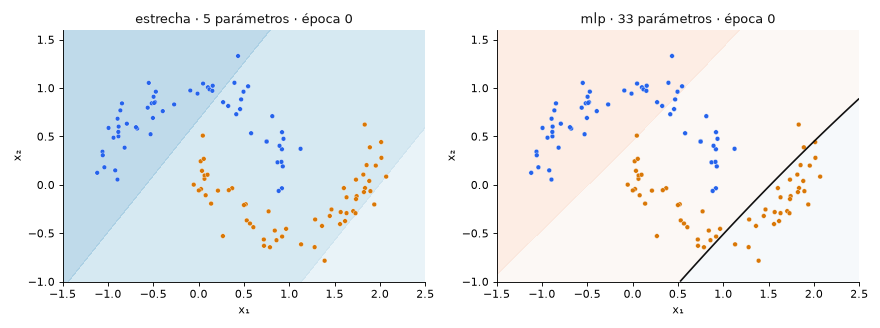
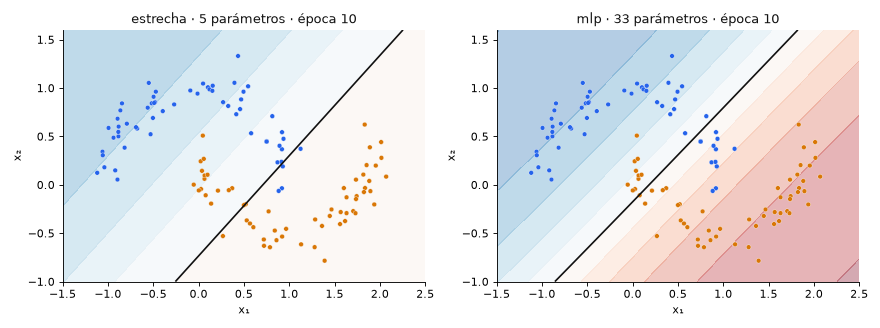
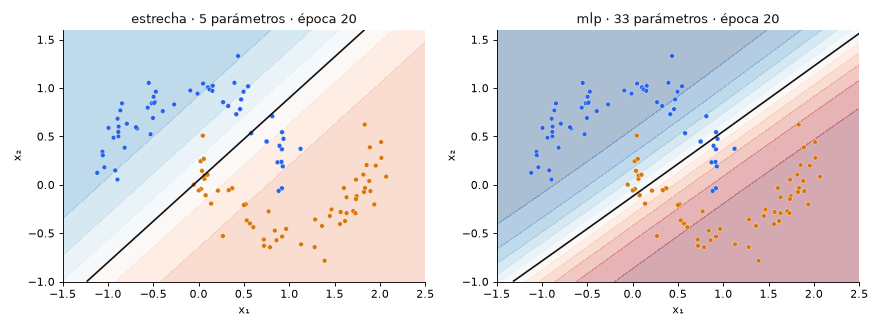
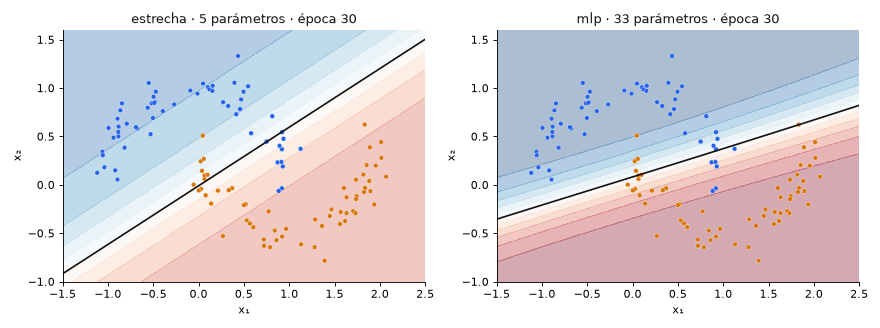
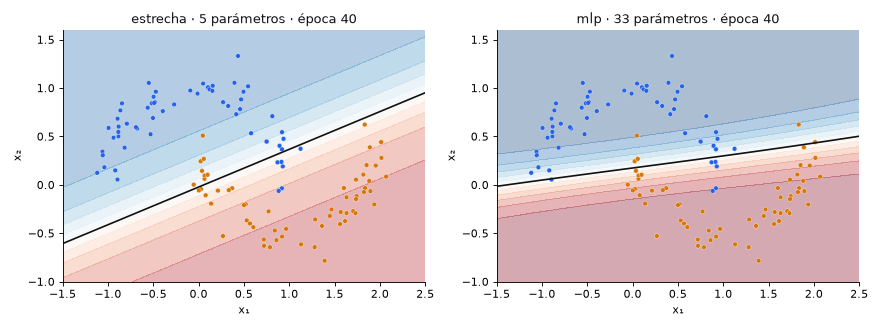
...
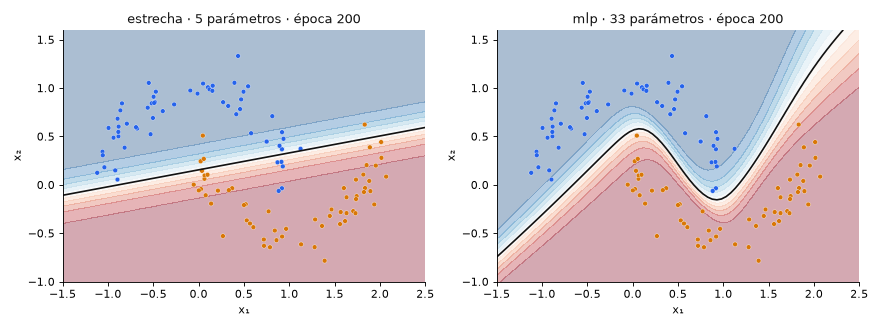
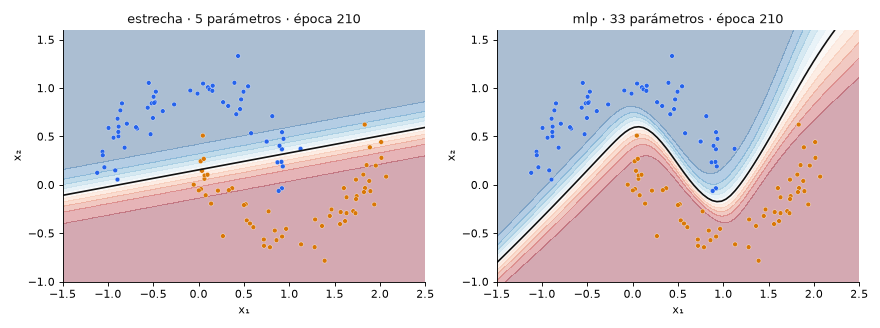
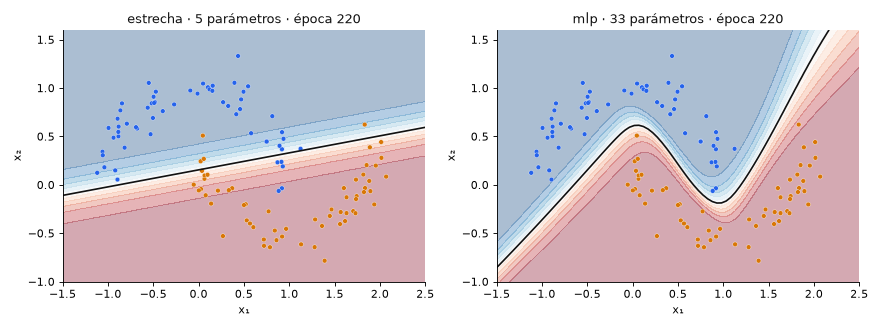
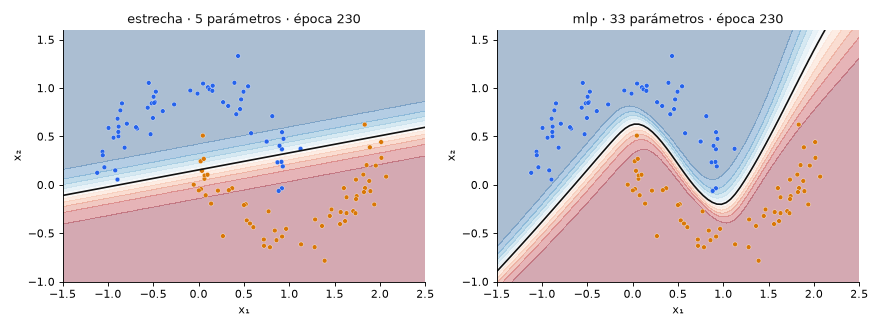
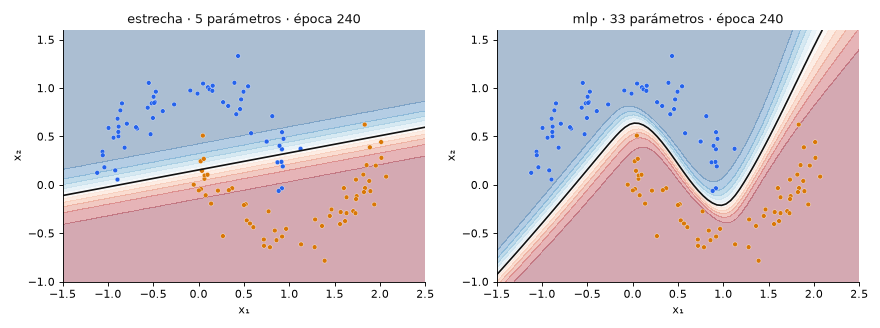

In [ ]:
from IPython.display import HTML, display
display(HTML('<iframe title="Anchura y capacidad de representación" sandbox="allow-scripts" style="width:100%;height:840px;border:0" srcdoc="&lt;!doctype html&gt;&lt;html lang=&quot;es&quot;&gt;&lt;meta charset=&quot;utf-8&quot;&gt;\n&lt;style&gt;body{font:15px system-ui;color:#111;background:white;margin:8px}button{padding:8px 14px;margin-right:8px;cursor:pointer}input{width:280px;vertical-align:middle}.stage{position:relative;width:100%;aspect-ratio:11/4.1}.stage img{position:absolute;inset:0;width:100%;height:100%;object-fit:contain}p{margin:8px 0}&lt;/style&gt;\n&lt;button id=&quot;play&quot;&gt;▶ Play&lt;/button&gt;&lt;button id=&quot;pause&quot;&gt;Ⅱ Pausa&lt;/button&gt;&lt;button id=&quot;reset&quot;&gt;↺ Reiniciar&lt;/button&gt;\n&lt;input id=&quot;seek&quot; aria-label=&quot;Recorrido&quot; type=&quot;range&quot; min=&quot;0&quot; max=&quot;1&quot; step=&quot;0.001&quot; value=&quot;0&quot;&gt;&lt;output id=&quot;value&quot;&gt;0.000&lt;/output&gt;\n&lt;p&gt;Anchura: cuántos detectores disponibles · Fundido continuo entre estados calculados. Duración: 18 segundos.&lt;/p&gt;\n&lt;div class=&quot;stage&quot;&gt;&lt;img id=&quot;a&quot; alt=&quot;Estado anterior&quot;&gt;&lt;img id=&quot;b&quot; alt=&quot;Transición al siguiente estado&quot;&gt;&lt;/div&gt;\n&lt;script&gt;\nconst frames=[&quot;&quot;, &quot;&quot;, &quot;&quot;, &quot;&quot;, &quot;&quot;, &quot;&quot;, &quot;&quot;, &quot;&quot;, &quot;&quot;, &quot;&quot;, &quot;&quot;, &quot;&quot;, &quot;&quot;, &quot;&quot;, &quot;&quot;, &quot;&quot;, &quot;&quot;, &quot;&quot;, &quot;&quot;, &quot;&quot;, &quot;&quot;, &quot;&quot;, &quot;&quot;, &quot;&quot;, &quot;&quot;];const imgs=frames.map(src=&gt;{let im=new Image();im.src=src;return im});\nconst a=document.getElementById(&#x27;a&#x27;),b=document.getElementById(&#x27;b&#x27;),seek=document.getElementById(&#x27;seek&#x27;),label=document.getElementById(&#x27;value&#x27;);\nlet position=0,playing=false,previous=null;\nfunction draw(){const f=position*(frames.length-1),i=Math.floor(f),j=Math.min(i+1,frames.length-1);if(a.src!==frames[i])a.src=frames[i];if(b.src!==frames[j])b.src=frames[j];b.style.opacity=f-i;seek.value=position;label.textContent=position.toFixed(3)}\nfunction tick(now){if(playing&amp;&amp;previous!==null){position=Math.min(1,position+(now-previous)/18000);draw();if(position===1)playing=false}previous=now;requestAnimationFrame(tick)}\ndocument.getElementById(&#x27;play&#x27;).onclick=()=&gt;{if(position&gt;=1)position=0;previous=null;playing=true};\ndocument.getElementById(&#x27;pause&#x27;).onclick=()=&gt;playing=false;\ndocument.getElementById(&#x27;reset&#x27;).onclick=()=&gt;{playing=false;position=0;draw()};\nseek.oninput=()=&gt;{playing=false;position=Number(seek.value);draw()};draw();requestAnimationFrame(tick);\n&lt;/script&gt;&lt;/html&gt;"></iframe>'))

<div style="background:white;color:#111111;border-left:4px solid #111111;padding:18px 24px;line-height:1.75"><h2>14 · La capa oculta cambia el problema de representación</h2><p>Definamos dos características ocultas: h₁ = OR(x₁,x₂) y h₂ = AND(x₁,x₂). Entonces XOR = h₁ AND NOT h₂. Una unidad de salida puede implementar esta combinación mediante 1[h₁ − h₂ − 0,5 ≥ 0].</p><p>En el espacio (h₁,h₂), los ejemplos positivos llegan a (1,0), y los negativos a (0,0) y (1,1), que sí admiten separación lineal. <strong>La capa oculta cambia la representación para hacer posible la decisión final.</strong> La construcción demuestra existencia de parámetros adecuados, no que un entrenamiento particular vaya a encontrarlos.</p><p>Las activaciones ocultas forman un vector h = φ(Wx + b), calculado y no observado como etiqueta. Su utilidad consiste en facilitar la tarea posterior; sus componentes no tienen por qué identificar factores semánticos reales.</p><p><strong>Pregunta clave: ¿Qué información aportan OR y AND juntas?</strong></p></div>

In [ ]:
from IPython.display import HTML, display
display(HTML('<iframe title="La capa oculta cambia el problema de representación" sandbox="allow-scripts" style="width:100%;height:840px;border:0" srcdoc="&lt;!doctype html&gt;&lt;html lang=&quot;es&quot;&gt;&lt;meta charset=&quot;utf-8&quot;&gt;&lt;style&gt;body{margin:0;font:14px system-ui;color:#334155}nav{padding:8px;display:flex;flex-wrap:wrap;gap:8px}button{font:inherit;padding:8px;border:1px solid #cbd5e1;background:white;border-radius:6px;cursor:pointer}button[aria-pressed=true]{background:#183b63;color:white}p{margin:8px}iframe{width:100%;height:730px;border:0}&lt;/style&gt;&lt;p&gt;Recorrido principal: primera vista. Las consultas son opcionales; al cambiar de vista se reinicia su demo.&lt;/p&gt;&lt;nav aria-label=&quot;Perspectivas del concepto&quot;&gt;&lt;/nav&gt;&lt;div id=&quot;view&quot;&gt;&lt;/div&gt;&lt;script&gt;const pages=[[&quot;Resolver XOR&quot;, &quot;&lt;!doctype html&gt;&lt;html lang=\\&quot;es\\&quot;&gt;&lt;meta charset=\\&quot;utf-8\\&quot;&gt;\\n&lt;style&gt;\\n*{box-sizing:border-box}body{margin:0;padding:14px;background:#fff;color:#111;font:14px system-ui}button,select{border:1px solid #cbd5e1;background:#f8fafc;border-radius:7px;padding:8px 12px;cursor:pointer}button:hover{background:#e0e7ff}button:focus-visible,input:focus-visible,select:focus-visible{outline:3px solid #2563eb}header{display:flex;gap:8px;align-items:center;flex-wrap:wrap}#controls{display:flex;gap:12px;flex-wrap:wrap;margin:12px 0}label{display:flex;gap:8px;align-items:center;font-size:13px}input{width:125px;accent-color:#2563eb}output{font-variant-numeric:tabular-nums;min-width:40px}canvas{width:100%;height:auto;background:white}#note{min-height:38px;padding:8px;background:#f1f5f9;border-radius:7px}table{border-collapse:collapse;font-size:13px;width:100%}td,th{padding:5px 12px;text-align:right;border-bottom:1px solid #e2e8f0}tr.active{background:#dbeafe}#table{max-height:180px;overflow:auto}h3{margin:8px 0}small{color:#475569}\\n&lt;\\/style&gt;\\n&lt;header&gt;&lt;button id=\\&quot;play\\&quot;&gt;▶ Demo&lt;\\/button&gt;&lt;button id=\\&quot;pause\\&quot;&gt;Ⅱ Pausa&lt;\\/button&gt;&lt;button id=\\&quot;reset\\&quot;&gt;↺ Reiniciar&lt;\\/button&gt;&lt;span id=\\&quot;actions\\&quot;&gt;&lt;\\/span&gt;&lt;small&gt;Controles locales · respuesta continua&lt;\\/small&gt;&lt;\\/header&gt;\\n&lt;div id=\\&quot;controls\\&quot;&gt;&lt;\\/div&gt;&lt;canvas id=\\&quot;plot\\&quot; width=\\&quot;1000\\&quot; height=\\&quot;360\\&quot;&gt;&lt;\\/canvas&gt;&lt;div id=\\&quot;note\\&quot; role=\\&quot;status\\&quot;&gt;&lt;\\/div&gt;&lt;div id=\\&quot;table\\&quot;&gt;&lt;\\/div&gt;\\n&lt;script&gt;\\nconst cfg={\\&quot;mode\\&quot;: \\&quot;hidden\\&quot;},mode=cfg.mode,C=document.getElementById(&#x27;plot&#x27;),g=C.getContext(&#x27;2d&#x27;),controls=document.getElementById(&#x27;controls&#x27;),note=document.getElementById(&#x27;note&#x27;),table=document.getElementById(&#x27;table&#x27;);\\nconst blue=&#x27;#2563eb&#x27;,orange=&#x27;#d97706&#x27;,green=&#x27;#15803d&#x27;,gray=&#x27;#64748b&#x27;;let playing=false,time=0,last=null,rows=[],selected=0,seed=42;\\nconst S={},inputs={},initial={};\\nfunction rand(){seed=(1664525*seed+1013904223)&gt;&gt;&gt;0;return seed/4294967296}\\nfunction normal(){return Math.sqrt(-2*Math.log(Math.max(rand(),1e-8)))*Math.cos(2*Math.PI*rand())}\\nfunction slider(key,label,value,min,max,step=.01){S[key]=value;initial[key]=value;const l=document.createElement(&#x27;label&#x27;);l.textContent=label;const i=document.createElement(&#x27;input&#x27;);i.type=&#x27;range&#x27;;i.min=min;i.max=max;i.step=step;i.value=value;i.setAttribute(&#x27;aria-label&#x27;,label);const o=document.createElement(&#x27;output&#x27;);o.textContent=value.toFixed(2);l.append(i,o);controls.append(l);inputs[key]={i,o};i.oninput=()=&gt;{playing=false;S[key]=+i.value;draw()}}\\nfunction button(text,fn){const b=document.createElement(&#x27;button&#x27;);b.textContent=text;b.onclick=()=&gt;{playing=false;fn();draw()};document.getElementById(&#x27;actions&#x27;).append(b)}\\nfunction set(k,v){S[k]=v;if(inputs[k]){inputs[k].i.value=v;inputs[k].o.textContent=v.toFixed(2)}}\\nfunction text(x,y,t,color=&#x27;#111&#x27;,size=16){g.fillStyle=color;g.font=`${size}px system-ui`;g.fillText(t,x,y)}\\nfunction line(x,y,u,v,color=gray,width=2){g.beginPath();g.moveTo(x,y);g.lineTo(u,v);g.strokeStyle=color;g.lineWidth=width;g.stroke()}\\nfunction dot(x,y,r=5,color=blue){g.beginPath();g.arc(x,y,r,0,Math.PI*2);g.fillStyle=color;g.fill()}\\nfunction arrow(x,y,u,v,color=blue){line(x,y,u,v,color,3);const a=Math.atan2(v-y,u-x);line(u,v,u-10*Math.cos(a-.4),v-10*Math.sin(a-.4),color,3);line(u,v,u-10*Math.cos(a+.4),v-10*Math.sin(a+.4),color,3)}\\nfunction axes(cx,cy,scale=45,label=&#x27;&#x27;){for(let k=-3;k&lt;=3;k++){line(cx-3*scale,cy+k*scale,cx+3*scale,cy+k*scale,&#x27;#e2e8f0&#x27;,1);line(cx+k*scale,cy-3*scale,cx+k*scale,cy+3*scale,&#x27;#e2e8f0&#x27;,1)}line(cx-3*scale,cy,cx+3*scale,cy);line(cx,cy+3*scale,cx,cy-3*scale);text(cx-130,25,label);text(cx+3*scale,cy+18,&#x27;x₁&#x27;,gray,12);text(cx+7,cy-3*scale,&#x27;x₂&#x27;,gray,12);return p=&gt;[cx+p[0]*scale,cy-p[1]*scale]}\\nfunction bar(x,y,w,h,value,label,color){g.fillStyle=color;g.fillRect(x,y-h*value,w,h*value);text(x,y+20,label,gray,12);text(x,y-h*value-8,value.toFixed(2),color,13)}\\nfunction sample(){const x=normal(),y=.65*x+.65*normal();rows.push({x,y,kind:rand()&lt;.5?&#x27;A&#x27;:&#x27;B&#x27;});if(rows.length&gt;18)rows.shift();selected=rows.length-1}\\nfunction renderTable(){table.innerHTML=&#x27;&lt;table&gt;&lt;thead&gt;&lt;tr&gt;&lt;th&gt;Observación&lt;\\/th&gt;&lt;th&gt;Medida X₁&lt;\\/th&gt;&lt;th&gt;Medida X₂&lt;\\/th&gt;&lt;th&gt;Tipo&lt;\\/th&gt;&lt;\\/tr&gt;&lt;\\/thead&gt;&lt;tbody&gt;&#x27;+rows.map((r,i)=&gt;`&lt;tr class=\\&quot;${i===selected?&#x27;active&#x27;:&#x27;&#x27;}\\&quot; data-i=\\&quot;${i}\\&quot;&gt;&lt;td&gt;${i+1}&lt;\\/td&gt;&lt;td&gt;${r.x.toFixed(2)}&lt;\\/td&gt;&lt;td&gt;${r.y.toFixed(2)}&lt;\\/td&gt;&lt;td&gt;${r.kind}&lt;\\/td&gt;&lt;\\/tr&gt;`).join(&#x27;&#x27;)+&#x27;&lt;\\/tbody&gt;&lt;\\/table&gt;&#x27;;table.querySelectorAll(&#x27;tr[data-i]&#x27;).forEach(e=&gt;{e.tabIndex=0;e.onclick=()=&gt;{selected=+e.dataset.i;draw()};e.onkeydown=ev=&gt;{if(ev.key===&#x27;Enter&#x27;)e.click()}})}\\nconst sigmoid=z=&gt;1/(1+Math.exp(-z)),act=(z,k)=&gt;k===&#x27;Escalón&#x27;?+(z&gt;=0):k===&#x27;Sigmoide&#x27;?sigmoid(z):k===&#x27;Tanh&#x27;?Math.tanh(z):k===&#x27;ReLU&#x27;?Math.max(0,z):z;\\nconst sampleModes=[&#x27;sample&#x27;,&#x27;random&#x27;,&#x27;table&#x27;];const transformModes=[&#x27;transform&#x27;,&#x27;matrix&#x27;,&#x27;rank&#x27;,&#x27;affine&#x27;];const neuronModes=[&#x27;neuron&#x27;,&#x27;weights&#x27;,&#x27;mp&#x27;,&#x27;active&#x27;];const activationModes=[&#x27;activations&#x27;,&#x27;sigmoid&#x27;,&#x27;logistic&#x27;,&#x27;relu&#x27;,&#x27;tanh&#x27;];\\nif(sampleModes.includes(mode)){for(let i=0;i&lt;6;i++)sample();button(&#x27;＋ Muestrear&#x27;,sample);button(&#x27;Nueva muestra (misma ley)&#x27;,()=&gt;{rows=[];for(let i=0;i&lt;12;i++)sample()});slider(&#x27;row&#x27;,&#x27;Observación&#x27;,0,0,17,1)}\\nelse if(mode===&#x27;encoding&#x27;){slider(&#x27;category&#x27;,&#x27;Categoría: A/B/C&#x27;,0,0,2,1);button(&#x27;Categoría siguiente&#x27;,()=&gt;set(&#x27;category&#x27;,(S.category+1)%3))}\\nelse if([&#x27;vector&#x27;,&#x27;scale&#x27;].includes(mode)){slider(&#x27;x&#x27;,&#x27;Entrada x₁&#x27;,1,-2,2);slider(&#x27;y&#x27;,&#x27;Entrada x₂&#x27;,1,-2,2);if(mode===&#x27;scale&#x27;)slider(&#x27;scale&#x27;,&#x27;Escala de x₁&#x27;,1,.2,3)}\\nelse if(transformModes.includes(mode)){slider(&#x27;a&#x27;,&#x27;A₁₁&#x27;,1,-2,2);slider(&#x27;b&#x27;,&#x27;A₁₂&#x27;,0,-2,2);slider(&#x27;c&#x27;,&#x27;A₂₁&#x27;,0,-2,2);slider(&#x27;d&#x27;,&#x27;A₂₂&#x27;,1,-2,2);if(mode===&#x27;affine&#x27;)slider(&#x27;bias&#x27;,&#x27;Sesgo b₁&#x27;,0,-1.5,1.5);button(&#x27;Rotar 90°&#x27;,()=&gt;{set(&#x27;a&#x27;,0);set(&#x27;b&#x27;,-1);set(&#x27;c&#x27;,1);set(&#x27;d&#x27;,0)});button(&#x27;Colapsar&#x27;,()=&gt;{set(&#x27;a&#x27;,1);set(&#x27;b&#x27;,1);set(&#x27;c&#x27;,0);set(&#x27;d&#x27;,0)})}\\nelse if(neuronModes.includes(mode)){slider(&#x27;x&#x27;,&#x27;Entrada x₁&#x27;,.8,-2,2);slider(&#x27;y&#x27;,&#x27;Entrada x₂&#x27;,.4,-2,2);slider(&#x27;w1&#x27;,&#x27;Peso w₁&#x27;,1,-2,2);slider(&#x27;w2&#x27;,&#x27;Peso w₂&#x27;,-.5,-2,2);slider(&#x27;bias&#x27;,&#x27;Sesgo&#x27;,0,-2,2)}\\nelse if(activationModes.includes(mode)){slider(&#x27;z&#x27;,&#x27;Puntuación z&#x27;,0,-6,6);if(mode===&#x27;logistic&#x27;){slider(&#x27;w1&#x27;,&#x27;Pendiente&#x27;,1,-3,3);slider(&#x27;bias&#x27;,&#x27;Sesgo&#x27;,0,-3,3)}}\\nelse if([&#x27;and&#x27;,&#x27;or&#x27;,&#x27;xor&#x27;,&#x27;hidden&#x27;].includes(mode)){slider(&#x27;x&#x27;,&#x27;Entrada binaria x₁&#x27;,0,0,1,1);slider(&#x27;y&#x27;,&#x27;Entrada binaria x₂&#x27;,0,0,1,1);slider(&#x27;w1&#x27;,&#x27;Peso w₁&#x27;,1,-2,2);slider(&#x27;w2&#x27;,&#x27;Peso w₂&#x27;,1,-2,2);slider(&#x27;bias&#x27;,&#x27;Sesgo&#x27;,mode===&#x27;and&#x27;?-1.5:mode===&#x27;or&#x27;?-.5:0,-3,2);button(&#x27;Siguiente entrada&#x27;,()=&gt;{let n=(S.x*2+S.y+1)%4;set(&#x27;x&#x27;,Math.floor(n/2));set(&#x27;y&#x27;,n%2)})}\\nelse if(mode===&#x27;latent&#x27;){slider(&#x27;x&#x27;,&#x27;Entrada x₁&#x27;,.4,-2,2);slider(&#x27;y&#x27;,&#x27;Entrada x₂&#x27;,.8,-2,2);slider(&#x27;gain&#x27;,&#x27;Ganancia oculta&#x27;,1,.1,3)}\\nif(mode===&#x27;hidden&#x27;){for(const key of [&#x27;w1&#x27;,&#x27;w2&#x27;,&#x27;bias&#x27;]){inputs[key].i.parentElement.remove();delete inputs[key]}}\\nconst dropdown=document.createElement(&#x27;select&#x27;);dropdown.setAttribute(&#x27;aria-label&#x27;,&#x27;Activación&#x27;);[&#x27;Lineal&#x27;,&#x27;Escalón&#x27;,&#x27;Sigmoide&#x27;,&#x27;Tanh&#x27;,&#x27;ReLU&#x27;].forEach(k=&gt;{const o=document.createElement(&#x27;option&#x27;);o.textContent=k;dropdown.append(o)});dropdown.value=mode===&#x27;mp&#x27;?&#x27;Escalón&#x27;:&#x27;Sigmoide&#x27;;dropdown.onchange=()=&gt;{playing=false;draw()};if([&#x27;mp&#x27;,&#x27;active&#x27;].includes(mode))controls.append(dropdown);\\nfunction draw(){g.clearRect(0,0,1000,360);Object.keys(inputs).forEach(k=&gt;inputs[k].o.textContent=S[k].toFixed(2));table.innerHTML=&#x27;&#x27;;\\nif(sampleModes.includes(mode)){\\n if(mode===&#x27;random&#x27;){\\n   const counts=Array(10).fill(0);rows.forEach(r=&gt;{const j=Math.max(0,Math.min(9,Math.floor((r.x+3)/.6)));counts[j]++});text(40,28,&#x27;Ley generadora → realizaciones → frecuencias&#x27;);\\n   for(let j=0;j&lt;10;j++)bar(70+j*38,300,29,18,counts[j],(-3+j*.6).toFixed(1),blue);\\n   text(65,340,&#x27;Histogramas pequeños varían entre muestras&#x27;,gray,14);\\n }else{const p=axes(235,185,45,&#x27;Cada realización añade un punto&#x27;);rows.forEach((r,i)=&gt;{dot(...p([r.x,r.y]),i===selected?8:4,i===selected?orange:blue)});}\\n text(520,55,&#x27;Experimento: medir dos magnitudes&#x27;);text(520,95,&#x27;X₁ = ε₁; X₂ = 0.65 X₁ + 0.65 ε₂&#x27;,blue,18);text(520,130,&#x27;ε₁, ε₂ ~ Normal(0,1), independientes&#x27;,gray,15);text(520,180,`${rows.length} observaciones registradas`,orange,23);text(520,220,&#x27;Tipo A/B: categoría muestreada aparte&#x27;,gray,14);renderTable();note.textContent=&#x27;Pulsa Muestrear o Play: una realización genera una fila. Haz clic o Enter sobre una fila para seguir su punto. Se muestran las últimas 18 observaciones.&#x27;;\\n}else if(mode===&#x27;encoding&#x27;){\\nconst j=S.category,labels=[&#x27;A&#x27;,&#x27;B&#x27;,&#x27;C&#x27;];text(55,55,&#x27;Categoría observada&#x27;,gray);text(150,150,labels[j],blue,72);arrow(265,140,440,140);text(510,55,&#x27;Codificación one-hot&#x27;);for(let k=0;k&lt;3;k++)bar(530+k*120,270,70,140,+(j===k),labels[k],j===k?orange:blue);note.textContent=&#x27;Las tres categorías tienen igual distancia entre códigos one-hot; codificar A=0, B=1, C=2 introduciría un orden y unas distancias no justificados.&#x27;;\\n}else if([&#x27;vector&#x27;,&#x27;scale&#x27;].includes(mode)){\\nlet scale=S.scale||1;const p=axes(235,185,45,&#x27;Un vector en ℝ²&#x27;);arrow(...p([0,0]),...p([S.x*scale,S.y]),blue);dot(...p([S.x*scale,S.y]),7,orange);text(520,50,mode===&#x27;scale&#x27;?&#x27;Cambiar unidades modifica la geometría&#x27;:&#x27;Coordenadas de la misma observación&#x27;);bar(570,210,80,45,S.x*scale,&#x27;x₁&#x27;,blue);bar(740,210,80,45,S.y,&#x27;x₂&#x27;,orange);note.textContent=`x = (${(S.x*scale).toFixed(2)}, ${S.y.toFixed(2)}). Mueve cada coordenada de manera independiente. ${mode===&#x27;scale&#x27;?&#x27;Escala no equivale a nueva información.&#x27;:&#x27;&#x27;}`;\\n}else if(transformModes.includes(mode)){\\nconst A=[[S.a,S.b],[S.c,S.d]],bias=S.bias||0,p=axes(210,180,38,&#x27;Espacio de entrada&#x27;),q=axes(780,180,38,&#x27;Espacio de llegada&#x27;);\\nconst transform=v=&gt;[A[0][0]*v[0]+A[0][1]*v[1]+bias,A[1][0]*v[0]+A[1][1]*v[1]];\\nfor(let k=-2;k&lt;=2;k++){for(let pair of [[[-2,k],[2,k]],[[k,-2],[k,2]]]){line(...p(pair[0]),...p(pair[1]),&#x27;#cbd5e1&#x27;,1);line(...q(transform(pair[0])),...q(transform(pair[1])),&#x27;#94a3b8&#x27;,1)}}\\nfor(let i=0;i&lt;20;i++){const v=[1.4*Math.cos(i*2.399),1.4*Math.sin(i*2.399)];dot(...p(v),4,blue);dot(...q(transform(v)),4,blue)}\\narrow(...p([0,0]),...p([1,0]),orange);arrow(...q(transform([0,0])),...q(transform([1,0])),orange);\\ntext(435,65,&#x27;h = Ax&#x27;+(bias?&#x27; + b&#x27;:&#x27;&#x27;),blue,20);text(422,108,`[ ${S.a.toFixed(2)}  ${S.b.toFixed(2)} ]`,blue,20);text(422,139,`[ ${S.c.toFixed(2)}  ${S.d.toFixed(2)} ]`,blue,20);arrow(405,190,555,190,green);\\nconst det=S.a*S.d-S.b*S.c;note.textContent=`det(A) = ${det.toFixed(3)}. ${mode===&#x27;rank&#x27;?&#x27;Colapsar hace perder una dimensión; distintas entradas pueden compartir salida.&#x27;:mode===&#x27;affine&#x27;?&#x27;Con sesgo, el origen puede dejar de ser fijo: la transformación es afín.&#x27;:&#x27;Los sliders cambian entradas concretas de A. Demo recorre matrices reproducibles y mueve toda la nube.&#x27;}`;\\n}else if(neuronModes.includes(mode)){\\nconst z=S.x*S.w1+S.y*S.w2+S.bias,k=mode===&#x27;neuron&#x27;||mode===&#x27;weights&#x27;?&#x27;Lineal&#x27;:dropdown.value,out=act(z,k);\\ndot(80,90,25,blue);dot(80,255,25,blue);text(43,43,`x₁=${S.x.toFixed(2)}`);text(43,315,`x₂=${S.y.toFixed(2)}`);\\narrow(108,90,340,172,blue);arrow(108,255,340,192,orange);text(150,96,`w₁=${S.w1.toFixed(2)}`);text(150,260,`w₂=${S.w2.toFixed(2)}`);dot(375,180,38,&#x27;#e2e8f0&#x27;);text(362,188,&#x27;Σ&#x27;,&#x27;#111&#x27;,28);text(312,120,`b=${S.bias.toFixed(2)}`);arrow(415,180,535,180,gray);text(438,151,`z=${z.toFixed(2)}`);g.strokeStyle=blue;g.strokeRect(540,145,115,70);text(553,184,k,blue,16);arrow(659,180,765,180,green);text(775,188,out.toFixed(3),green,30);\\ntext(120,340,`${S.x.toFixed(2)} × ${S.w1.toFixed(2)} + ${S.y.toFixed(2)} × ${S.w2.toFixed(2)} + ${S.bias.toFixed(2)} = ${z.toFixed(3)}`,gray,18);\\nif(mode===&#x27;weights&#x27;){\\ng.clearRect(0,0,1000,360);const project=(x,y,z)=&gt;[260+65*x+35*y,190+25*y-24*z];\\nfor(let k=-2;k&lt;=2;k+=.5){line(...project(-2,k,-2*S.w1+k*S.w2+S.bias),...project(2,k,2*S.w1+k*S.w2+S.bias),&#x27;#93c5fd&#x27;,1);line(...project(k,-2,k*S.w1-2*S.w2+S.bias),...project(k,2,k*S.w1+2*S.w2+S.bias),&#x27;#93c5fd&#x27;,1)}\\ndot(...project(S.x,S.y,z),9,orange);text(40,25,&#x27;Plano de puntuación: z = w₁x₁+w₂x₂+b&#x27;);text(580,55,&#x27;Contribuciones al resultado&#x27;);bar(590,210,60,28,S.w1*S.x,&#x27;w₁x₁&#x27;,blue);bar(715,210,60,28,S.w2*S.y,&#x27;w₂x₂&#x27;,orange);bar(840,210,60,28,S.bias,&#x27;b&#x27;,green);text(580,320,`z=${z.toFixed(3)}`,green,23);\\n}\\nnote.textContent=mode===&#x27;mp&#x27;?&#x27;Modelo de umbral inspirado en McCulloch–Pitts: separa suma y decisión. Los pesos continuos son una generalización didáctica.&#x27;:`Entradas y pesos tienen controles separados. ${k===&#x27;Lineal&#x27;?&#x27;Sin activación: vemos solo el bloque afín de la neurona.&#x27;:&#x27;La función &#x27;+k+&#x27; transforma la misma puntuación.&#x27;}`;\\n}else if(activationModes.includes(mode)){\\nconst kinds=mode===&#x27;activations&#x27;?[&#x27;Escalón&#x27;,&#x27;Sigmoide&#x27;,&#x27;Tanh&#x27;,&#x27;ReLU&#x27;]:[mode===&#x27;relu&#x27;?&#x27;ReLU&#x27;:mode===&#x27;tanh&#x27;?&#x27;Tanh&#x27;:&#x27;Sigmoide&#x27;];\\nkinds.forEach((k,index)=&gt;{const four=kinds.length===4,cx=four?70+(index%2)*490:80,cy=four?70+Math.floor(index/2)*170:180,w=four?350:440,h=four?50:115;const lo=k===&#x27;Tanh&#x27;?-1:0,hi=k===&#x27;ReLU&#x27;?6:1;line(cx,cy+h,cx+w,cy+h);line(cx+w/2,cy-h,cx+w/2,cy+h);text(cx,cy-h-10,k,blue,16);let prev=null;for(let i=0;i&lt;=120;i++){const x=-6+i/10,y=act(mode===&#x27;logistic&#x27;?S.w1*x+S.bias:x,k),point=[cx+i/120*w,cy+h-(y-lo)/(hi-lo)*h*1.5];if(prev)line(...prev,...point,blue,2);prev=point}const zz=mode===&#x27;logistic&#x27;?S.w1*S.z+S.bias:S.z,yy=act(zz,k);dot(cx+(S.z+6)/12*w,cy+h-(yy-lo)/(hi-lo)*h*1.5,6,orange);if(!four){text(620,105,`z = ${zz.toFixed(3)}`,gray,22);text(620,155,`f(z) = ${yy.toFixed(3)}`,blue,28);const derivative=k===&#x27;Sigmoide&#x27;?yy*(1-yy):k===&#x27;Tanh&#x27;?1-yy*yy:S.z&lt;0?0:1;text(620,215,`Sensibilidad local: ${derivative.toFixed(3)}`,green,18)}});\\nif(mode===&#x27;relu&#x27;&amp;&amp;S.z===0){g.clearRect(610,190,390,45);text(620,215,&#x27;Derivada no definida en cero&#x27;,green,18)}\\nnote.textContent=mode===&#x27;logistic&#x27;?&#x27;Regresión logística: p(y=1|x)=sigmoide(wx+b). Pendiente y sesgo cambian la curva; usar sigmoide no garantiza calibración.&#x27;:mode===&#x27;activations&#x27;?&#x27;Una misma entrada produce respuestas distintas. Mueve z y observa las cuatro curvas a la vez.&#x27;:&#x27;La salida y sensibilidad se calculan al arrastrar. El escalón y ReLU no tienen derivada clásica en cero.&#x27;;\\n}else if([&#x27;and&#x27;,&#x27;or&#x27;,&#x27;xor&#x27;,&#x27;hidden&#x27;].includes(mode)){\\nconst truth=(x,y)=&gt;mode===&#x27;and&#x27;?x&amp;&amp;y:mode===&#x27;or&#x27;?x||y:x!==y;\\nlet wrong=0;const p=axes(235,180,85,mode===&#x27;hidden&#x27;?&#x27;XOR: decisión compuesta&#x27;:&#x27;Puerta &#x27;+mode.toUpperCase());\\nfor(let x=0;x&lt;=1;x++)for(let y=0;y&lt;=1;y++){const target=+truth(x,y),pred=mode===&#x27;hidden&#x27;?+((x+y&gt;=.5)&amp;&amp;!(x+y&gt;=1.5)):+(S.w1*x+S.w2*y+S.bias&gt;=0);wrong+=pred!==target;dot(...p([x,y]),x===S.x&amp;&amp;y===S.y?12:8,target?orange:blue);text(p([x,y])[0]+15,p([x,y])[1],`${pred===target?&#x27;✓&#x27;:&#x27;×&#x27;} ${pred}`,pred===target?green:&#x27;#b91c1c&#x27;,16)}\\nif(mode!==&#x27;hidden&#x27;&amp;&amp;Math.abs(S.w2)&gt;.001){line(...p([-1,(-S.bias+S.w1)/S.w2]),...p([2,(-S.bias-2*S.w1)/S.w2]),gray)}\\nconst h1=+(S.x+S.y&gt;=.5),h2=+(S.x+S.y&gt;=1.5);text(560,65,`Entrada (${S.x}, ${S.y})`,blue,23);\\nif(mode===&#x27;hidden&#x27;){text(560,125,`h₁ = OR = ${h1}`);text(560,170,`h₂ = AND = ${h2}`);text(560,235,`Salida = h₁ AND NOT h₂ = ${+(h1&amp;&amp;!h2)}`,green,22)}else{text(560,135,`z = ${(S.w1*S.x+S.w2*S.y+S.bias).toFixed(2)}`);text(560,190,`Predicción = ${+(S.w1*S.x+S.w2*S.y+S.bias&gt;=0)}`,green,22)}\\ntext(560,300,`${wrong}/4 combinaciones incorrectas`,wrong?&#x27;#b91c1c&#x27;:green,20);note.textContent=mode===&#x27;hidden&#x27;?&#x27;Dos detectores intermedios y una salida resuelven XOR. Pesos construidos a mano: todavía no es aprendizaje.&#x27;:&#x27;Entradas binarias: su cambio es discreto por definición. Los pesos y el sesgo sí varían continuamente. Azul=0, naranja=1; × señala error.&#x27;;\\n}else if(mode===&#x27;latent&#x27;){\\nconst p=axes(225,180,48,&#x27;Variables de entrada&#x27;),q=axes(775,180,48,&#x27;Variables ocultas&#x27;);const h=[Math.tanh(S.gain*(S.x+S.y)-1),Math.tanh(S.gain*(-S.x-S.y)-1)];arrow(...p([0,0]),...p([S.x,S.y]),blue);arrow(...q([0,0]),...q(h),orange);arrow(405,180,570,180,green);text(400,110,&#x27;h = tanh(Wx+b)&#x27;,blue,19);text(400,245,`h₁=${h[0].toFixed(2)}; h₂=${h[1].toFixed(2)}`);note.textContent=&#x27;La representación oculta se calcula a partir de la entrada. Sus coordenadas no tienen por qué corresponder a factores semánticos interpretables.&#x27;;\\n}}\\ndocument.getElementById(&#x27;play&#x27;).onclick=()=&gt;{playing=true;last=null};document.getElementById(&#x27;pause&#x27;).onclick=()=&gt;playing=false;document.getElementById(&#x27;reset&#x27;).onclick=()=&gt;{playing=false;time=0;seed=42;Object.entries(initial).forEach(([k,v])=&gt;set(k,v));if(sampleModes.includes(mode)){rows=[];for(let i=0;i&lt;6;i++)sample()}draw()};\\nlet sampleClock=0;function animate(now){if(playing&amp;&amp;last!==null){const dt=Math.min(.1,(now-last)/1000);time+=dt;const f=Math.sin(time*.6);if(sampleModes.includes(mode)){sampleClock+=dt;if(sampleClock&gt;.8){sampleClock=0;sample()}}\\nelse if(transformModes.includes(mode)){if(mode===&#x27;rank&#x27;){set(&#x27;a&#x27;,1);set(&#x27;b&#x27;,0);set(&#x27;c&#x27;,0);set(&#x27;d&#x27;,(1+Math.cos(time*.5))/2)}else{set(&#x27;a&#x27;,Math.cos(time*.4));set(&#x27;b&#x27;,Math.sin(time*.53));set(&#x27;c&#x27;,Math.sin(time*.37+.3));set(&#x27;d&#x27;,Math.cos(time*.61))}if(mode===&#x27;affine&#x27;)set(&#x27;bias&#x27;,f)}\\nelse if(mode===&#x27;encoding&#x27;){set(&#x27;category&#x27;,Math.floor(time/1.4)%3)}else if([&#x27;and&#x27;,&#x27;or&#x27;,&#x27;xor&#x27;,&#x27;hidden&#x27;].includes(mode)){let i=Math.floor(time/1.5)%4;set(&#x27;x&#x27;,Math.floor(i/2));set(&#x27;y&#x27;,i%2);if(mode===&#x27;xor&#x27;){set(&#x27;w1&#x27;,1.5*f);set(&#x27;w2&#x27;,1.5*Math.cos(time*.6))}}\\nelse if(activationModes.includes(mode))set(&#x27;z&#x27;,6*f);\\nelse{if(&#x27;x&#x27;in S)set(&#x27;x&#x27;,1.5*f);if(&#x27;y&#x27;in S)set(&#x27;y&#x27;,1.5*Math.cos(time*.6));if(mode===&#x27;weights&#x27;){set(&#x27;w1&#x27;,2*Math.sin(time*.4));set(&#x27;w2&#x27;,2*Math.cos(time*.4))}if(mode===&#x27;scale&#x27;)set(&#x27;scale&#x27;,1.6+1.4*f)}draw()}last=now;requestAnimationFrame(animate)}\\nif(inputs.row)inputs.row.i.oninput=()=&gt;{playing=false;set(&#x27;row&#x27;,+inputs.row.i.value);selected=Math.min(S.row,rows.length-1);draw()};draw();requestAnimationFrame(animate);\\n&lt;\\/script&gt;&lt;\\/html&gt;\\n&quot;], [&quot;Consultar: coordenadas ocultas&quot;, &quot;&lt;!doctype html&gt;&lt;html lang=\\&quot;es\\&quot;&gt;&lt;meta charset=\\&quot;utf-8\\&quot;&gt;\\n&lt;style&gt;\\n*{box-sizing:border-box}body{margin:0;padding:14px;background:#fff;color:#111;font:14px system-ui}button,select{border:1px solid #cbd5e1;background:#f8fafc;border-radius:7px;padding:8px 12px;cursor:pointer}button:hover{background:#e0e7ff}button:focus-visible,input:focus-visible,select:focus-visible{outline:3px solid #2563eb}header{display:flex;gap:8px;align-items:center;flex-wrap:wrap}#controls{display:flex;gap:12px;flex-wrap:wrap;margin:12px 0}label{display:flex;gap:8px;align-items:center;font-size:13px}input{width:125px;accent-color:#2563eb}output{font-variant-numeric:tabular-nums;min-width:40px}canvas{width:100%;height:auto;background:white}#note{min-height:38px;padding:8px;background:#f1f5f9;border-radius:7px}table{border-collapse:collapse;font-size:13px;width:100%}td,th{padding:5px 12px;text-align:right;border-bottom:1px solid #e2e8f0}tr.active{background:#dbeafe}#table{max-height:180px;overflow:auto}h3{margin:8px 0}small{color:#475569}\\n&lt;\\/style&gt;\\n&lt;header&gt;&lt;button id=\\&quot;play\\&quot;&gt;▶ Demo&lt;\\/button&gt;&lt;button id=\\&quot;pause\\&quot;&gt;Ⅱ Pausa&lt;\\/button&gt;&lt;button id=\\&quot;reset\\&quot;&gt;↺ Reiniciar&lt;\\/button&gt;&lt;span id=\\&quot;actions\\&quot;&gt;&lt;\\/span&gt;&lt;small&gt;Controles locales · respuesta continua&lt;\\/small&gt;&lt;\\/header&gt;\\n&lt;div id=\\&quot;controls\\&quot;&gt;&lt;\\/div&gt;&lt;canvas id=\\&quot;plot\\&quot; width=\\&quot;1000\\&quot; height=\\&quot;360\\&quot;&gt;&lt;\\/canvas&gt;&lt;div id=\\&quot;note\\&quot; role=\\&quot;status\\&quot;&gt;&lt;\\/div&gt;&lt;div id=\\&quot;table\\&quot;&gt;&lt;\\/div&gt;\\n&lt;script&gt;\\nconst cfg={\\&quot;mode\\&quot;: \\&quot;latent\\&quot;},mode=cfg.mode,C=document.getElementById(&#x27;plot&#x27;),g=C.getContext(&#x27;2d&#x27;),controls=document.getElementById(&#x27;controls&#x27;),note=document.getElementById(&#x27;note&#x27;),table=document.getElementById(&#x27;table&#x27;);\\nconst blue=&#x27;#2563eb&#x27;,orange=&#x27;#d97706&#x27;,green=&#x27;#15803d&#x27;,gray=&#x27;#64748b&#x27;;let playing=false,time=0,last=null,rows=[],selected=0,seed=42;\\nconst S={},inputs={},initial={};\\nfunction rand(){seed=(1664525*seed+1013904223)&gt;&gt;&gt;0;return seed/4294967296}\\nfunction normal(){return Math.sqrt(-2*Math.log(Math.max(rand(),1e-8)))*Math.cos(2*Math.PI*rand())}\\nfunction slider(key,label,value,min,max,step=.01){S[key]=value;initial[key]=value;const l=document.createElement(&#x27;label&#x27;);l.textContent=label;const i=document.createElement(&#x27;input&#x27;);i.type=&#x27;range&#x27;;i.min=min;i.max=max;i.step=step;i.value=value;i.setAttribute(&#x27;aria-label&#x27;,label);const o=document.createElement(&#x27;output&#x27;);o.textContent=value.toFixed(2);l.append(i,o);controls.append(l);inputs[key]={i,o};i.oninput=()=&gt;{playing=false;S[key]=+i.value;draw()}}\\nfunction button(text,fn){const b=document.createElement(&#x27;button&#x27;);b.textContent=text;b.onclick=()=&gt;{playing=false;fn();draw()};document.getElementById(&#x27;actions&#x27;).append(b)}\\nfunction set(k,v){S[k]=v;if(inputs[k]){inputs[k].i.value=v;inputs[k].o.textContent=v.toFixed(2)}}\\nfunction text(x,y,t,color=&#x27;#111&#x27;,size=16){g.fillStyle=color;g.font=`${size}px system-ui`;g.fillText(t,x,y)}\\nfunction line(x,y,u,v,color=gray,width=2){g.beginPath();g.moveTo(x,y);g.lineTo(u,v);g.strokeStyle=color;g.lineWidth=width;g.stroke()}\\nfunction dot(x,y,r=5,color=blue){g.beginPath();g.arc(x,y,r,0,Math.PI*2);g.fillStyle=color;g.fill()}\\nfunction arrow(x,y,u,v,color=blue){line(x,y,u,v,color,3);const a=Math.atan2(v-y,u-x);line(u,v,u-10*Math.cos(a-.4),v-10*Math.sin(a-.4),color,3);line(u,v,u-10*Math.cos(a+.4),v-10*Math.sin(a+.4),color,3)}\\nfunction axes(cx,cy,scale=45,label=&#x27;&#x27;){for(let k=-3;k&lt;=3;k++){line(cx-3*scale,cy+k*scale,cx+3*scale,cy+k*scale,&#x27;#e2e8f0&#x27;,1);line(cx+k*scale,cy-3*scale,cx+k*scale,cy+3*scale,&#x27;#e2e8f0&#x27;,1)}line(cx-3*scale,cy,cx+3*scale,cy);line(cx,cy+3*scale,cx,cy-3*scale);text(cx-130,25,label);text(cx+3*scale,cy+18,&#x27;x₁&#x27;,gray,12);text(cx+7,cy-3*scale,&#x27;x₂&#x27;,gray,12);return p=&gt;[cx+p[0]*scale,cy-p[1]*scale]}\\nfunction bar(x,y,w,h,value,label,color){g.fillStyle=color;g.fillRect(x,y-h*value,w,h*value);text(x,y+20,label,gray,12);text(x,y-h*value-8,value.toFixed(2),color,13)}\\nfunction sample(){const x=normal(),y=.65*x+.65*normal();rows.push({x,y,kind:rand()&lt;.5?&#x27;A&#x27;:&#x27;B&#x27;});if(rows.length&gt;18)rows.shift();selected=rows.length-1}\\nfunction renderTable(){table.innerHTML=&#x27;&lt;table&gt;&lt;thead&gt;&lt;tr&gt;&lt;th&gt;Observación&lt;\\/th&gt;&lt;th&gt;Medida X₁&lt;\\/th&gt;&lt;th&gt;Medida X₂&lt;\\/th&gt;&lt;th&gt;Tipo&lt;\\/th&gt;&lt;\\/tr&gt;&lt;\\/thead&gt;&lt;tbody&gt;&#x27;+rows.map((r,i)=&gt;`&lt;tr class=\\&quot;${i===selected?&#x27;active&#x27;:&#x27;&#x27;}\\&quot; data-i=\\&quot;${i}\\&quot;&gt;&lt;td&gt;${i+1}&lt;\\/td&gt;&lt;td&gt;${r.x.toFixed(2)}&lt;\\/td&gt;&lt;td&gt;${r.y.toFixed(2)}&lt;\\/td&gt;&lt;td&gt;${r.kind}&lt;\\/td&gt;&lt;\\/tr&gt;`).join(&#x27;&#x27;)+&#x27;&lt;\\/tbody&gt;&lt;\\/table&gt;&#x27;;table.querySelectorAll(&#x27;tr[data-i]&#x27;).forEach(e=&gt;{e.tabIndex=0;e.onclick=()=&gt;{selected=+e.dataset.i;draw()};e.onkeydown=ev=&gt;{if(ev.key===&#x27;Enter&#x27;)e.click()}})}\\nconst sigmoid=z=&gt;1/(1+Math.exp(-z)),act=(z,k)=&gt;k===&#x27;Escalón&#x27;?+(z&gt;=0):k===&#x27;Sigmoide&#x27;?sigmoid(z):k===&#x27;Tanh&#x27;?Math.tanh(z):k===&#x27;ReLU&#x27;?Math.max(0,z):z;\\nconst sampleModes=[&#x27;sample&#x27;,&#x27;random&#x27;,&#x27;table&#x27;];const transformModes=[&#x27;transform&#x27;,&#x27;matrix&#x27;,&#x27;rank&#x27;,&#x27;affine&#x27;];const neuronModes=[&#x27;neuron&#x27;,&#x27;weights&#x27;,&#x27;mp&#x27;,&#x27;active&#x27;];const activationModes=[&#x27;activations&#x27;,&#x27;sigmoid&#x27;,&#x27;logistic&#x27;,&#x27;relu&#x27;,&#x27;tanh&#x27;];\\nif(sampleModes.includes(mode)){for(let i=0;i&lt;6;i++)sample();button(&#x27;＋ Muestrear&#x27;,sample);button(&#x27;Nueva muestra (misma ley)&#x27;,()=&gt;{rows=[];for(let i=0;i&lt;12;i++)sample()});slider(&#x27;row&#x27;,&#x27;Observación&#x27;,0,0,17,1)}\\nelse if(mode===&#x27;encoding&#x27;){slider(&#x27;category&#x27;,&#x27;Categoría: A/B/C&#x27;,0,0,2,1);button(&#x27;Categoría siguiente&#x27;,()=&gt;set(&#x27;category&#x27;,(S.category+1)%3))}\\nelse if([&#x27;vector&#x27;,&#x27;scale&#x27;].includes(mode)){slider(&#x27;x&#x27;,&#x27;Entrada x₁&#x27;,1,-2,2);slider(&#x27;y&#x27;,&#x27;Entrada x₂&#x27;,1,-2,2);if(mode===&#x27;scale&#x27;)slider(&#x27;scale&#x27;,&#x27;Escala de x₁&#x27;,1,.2,3)}\\nelse if(transformModes.includes(mode)){slider(&#x27;a&#x27;,&#x27;A₁₁&#x27;,1,-2,2);slider(&#x27;b&#x27;,&#x27;A₁₂&#x27;,0,-2,2);slider(&#x27;c&#x27;,&#x27;A₂₁&#x27;,0,-2,2);slider(&#x27;d&#x27;,&#x27;A₂₂&#x27;,1,-2,2);if(mode===&#x27;affine&#x27;)slider(&#x27;bias&#x27;,&#x27;Sesgo b₁&#x27;,0,-1.5,1.5);button(&#x27;Rotar 90°&#x27;,()=&gt;{set(&#x27;a&#x27;,0);set(&#x27;b&#x27;,-1);set(&#x27;c&#x27;,1);set(&#x27;d&#x27;,0)});button(&#x27;Colapsar&#x27;,()=&gt;{set(&#x27;a&#x27;,1);set(&#x27;b&#x27;,1);set(&#x27;c&#x27;,0);set(&#x27;d&#x27;,0)})}\\nelse if(neuronModes.includes(mode)){slider(&#x27;x&#x27;,&#x27;Entrada x₁&#x27;,.8,-2,2);slider(&#x27;y&#x27;,&#x27;Entrada x₂&#x27;,.4,-2,2);slider(&#x27;w1&#x27;,&#x27;Peso w₁&#x27;,1,-2,2);slider(&#x27;w2&#x27;,&#x27;Peso w₂&#x27;,-.5,-2,2);slider(&#x27;bias&#x27;,&#x27;Sesgo&#x27;,0,-2,2)}\\nelse if(activationModes.includes(mode)){slider(&#x27;z&#x27;,&#x27;Puntuación z&#x27;,0,-6,6);if(mode===&#x27;logistic&#x27;){slider(&#x27;w1&#x27;,&#x27;Pendiente&#x27;,1,-3,3);slider(&#x27;bias&#x27;,&#x27;Sesgo&#x27;,0,-3,3)}}\\nelse if([&#x27;and&#x27;,&#x27;or&#x27;,&#x27;xor&#x27;,&#x27;hidden&#x27;].includes(mode)){slider(&#x27;x&#x27;,&#x27;Entrada binaria x₁&#x27;,0,0,1,1);slider(&#x27;y&#x27;,&#x27;Entrada binaria x₂&#x27;,0,0,1,1);slider(&#x27;w1&#x27;,&#x27;Peso w₁&#x27;,1,-2,2);slider(&#x27;w2&#x27;,&#x27;Peso w₂&#x27;,1,-2,2);slider(&#x27;bias&#x27;,&#x27;Sesgo&#x27;,mode===&#x27;and&#x27;?-1.5:mode===&#x27;or&#x27;?-.5:0,-3,2);button(&#x27;Siguiente entrada&#x27;,()=&gt;{let n=(S.x*2+S.y+1)%4;set(&#x27;x&#x27;,Math.floor(n/2));set(&#x27;y&#x27;,n%2)})}\\nelse if(mode===&#x27;latent&#x27;){slider(&#x27;x&#x27;,&#x27;Entrada x₁&#x27;,.4,-2,2);slider(&#x27;y&#x27;,&#x27;Entrada x₂&#x27;,.8,-2,2);slider(&#x27;gain&#x27;,&#x27;Ganancia oculta&#x27;,1,.1,3)}\\nif(mode===&#x27;hidden&#x27;){for(const key of [&#x27;w1&#x27;,&#x27;w2&#x27;,&#x27;bias&#x27;]){inputs[key].i.parentElement.remove();delete inputs[key]}}\\nconst dropdown=document.createElement(&#x27;select&#x27;);dropdown.setAttribute(&#x27;aria-label&#x27;,&#x27;Activación&#x27;);[&#x27;Lineal&#x27;,&#x27;Escalón&#x27;,&#x27;Sigmoide&#x27;,&#x27;Tanh&#x27;,&#x27;ReLU&#x27;].forEach(k=&gt;{const o=document.createElement(&#x27;option&#x27;);o.textContent=k;dropdown.append(o)});dropdown.value=mode===&#x27;mp&#x27;?&#x27;Escalón&#x27;:&#x27;Sigmoide&#x27;;dropdown.onchange=()=&gt;{playing=false;draw()};if([&#x27;mp&#x27;,&#x27;active&#x27;].includes(mode))controls.append(dropdown);\\nfunction draw(){g.clearRect(0,0,1000,360);Object.keys(inputs).forEach(k=&gt;inputs[k].o.textContent=S[k].toFixed(2));table.innerHTML=&#x27;&#x27;;\\nif(sampleModes.includes(mode)){\\n if(mode===&#x27;random&#x27;){\\n   const counts=Array(10).fill(0);rows.forEach(r=&gt;{const j=Math.max(0,Math.min(9,Math.floor((r.x+3)/.6)));counts[j]++});text(40,28,&#x27;Ley generadora → realizaciones → frecuencias&#x27;);\\n   for(let j=0;j&lt;10;j++)bar(70+j*38,300,29,18,counts[j],(-3+j*.6).toFixed(1),blue);\\n   text(65,340,&#x27;Histogramas pequeños varían entre muestras&#x27;,gray,14);\\n }else{const p=axes(235,185,45,&#x27;Cada realización añade un punto&#x27;);rows.forEach((r,i)=&gt;{dot(...p([r.x,r.y]),i===selected?8:4,i===selected?orange:blue)});}\\n text(520,55,&#x27;Experimento: medir dos magnitudes&#x27;);text(520,95,&#x27;X₁ = ε₁; X₂ = 0.65 X₁ + 0.65 ε₂&#x27;,blue,18);text(520,130,&#x27;ε₁, ε₂ ~ Normal(0,1), independientes&#x27;,gray,15);text(520,180,`${rows.length} observaciones registradas`,orange,23);text(520,220,&#x27;Tipo A/B: categoría muestreada aparte&#x27;,gray,14);renderTable();note.textContent=&#x27;Pulsa Muestrear o Play: una realización genera una fila. Haz clic o Enter sobre una fila para seguir su punto. Se muestran las últimas 18 observaciones.&#x27;;\\n}else if(mode===&#x27;encoding&#x27;){\\nconst j=S.category,labels=[&#x27;A&#x27;,&#x27;B&#x27;,&#x27;C&#x27;];text(55,55,&#x27;Categoría observada&#x27;,gray);text(150,150,labels[j],blue,72);arrow(265,140,440,140);text(510,55,&#x27;Codificación one-hot&#x27;);for(let k=0;k&lt;3;k++)bar(530+k*120,270,70,140,+(j===k),labels[k],j===k?orange:blue);note.textContent=&#x27;Las tres categorías tienen igual distancia entre códigos one-hot; codificar A=0, B=1, C=2 introduciría un orden y unas distancias no justificados.&#x27;;\\n}else if([&#x27;vector&#x27;,&#x27;scale&#x27;].includes(mode)){\\nlet scale=S.scale||1;const p=axes(235,185,45,&#x27;Un vector en ℝ²&#x27;);arrow(...p([0,0]),...p([S.x*scale,S.y]),blue);dot(...p([S.x*scale,S.y]),7,orange);text(520,50,mode===&#x27;scale&#x27;?&#x27;Cambiar unidades modifica la geometría&#x27;:&#x27;Coordenadas de la misma observación&#x27;);bar(570,210,80,45,S.x*scale,&#x27;x₁&#x27;,blue);bar(740,210,80,45,S.y,&#x27;x₂&#x27;,orange);note.textContent=`x = (${(S.x*scale).toFixed(2)}, ${S.y.toFixed(2)}). Mueve cada coordenada de manera independiente. ${mode===&#x27;scale&#x27;?&#x27;Escala no equivale a nueva información.&#x27;:&#x27;&#x27;}`;\\n}else if(transformModes.includes(mode)){\\nconst A=[[S.a,S.b],[S.c,S.d]],bias=S.bias||0,p=axes(210,180,38,&#x27;Espacio de entrada&#x27;),q=axes(780,180,38,&#x27;Espacio de llegada&#x27;);\\nconst transform=v=&gt;[A[0][0]*v[0]+A[0][1]*v[1]+bias,A[1][0]*v[0]+A[1][1]*v[1]];\\nfor(let k=-2;k&lt;=2;k++){for(let pair of [[[-2,k],[2,k]],[[k,-2],[k,2]]]){line(...p(pair[0]),...p(pair[1]),&#x27;#cbd5e1&#x27;,1);line(...q(transform(pair[0])),...q(transform(pair[1])),&#x27;#94a3b8&#x27;,1)}}\\nfor(let i=0;i&lt;20;i++){const v=[1.4*Math.cos(i*2.399),1.4*Math.sin(i*2.399)];dot(...p(v),4,blue);dot(...q(transform(v)),4,blue)}\\narrow(...p([0,0]),...p([1,0]),orange);arrow(...q(transform([0,0])),...q(transform([1,0])),orange);\\ntext(435,65,&#x27;h = Ax&#x27;+(bias?&#x27; + b&#x27;:&#x27;&#x27;),blue,20);text(422,108,`[ ${S.a.toFixed(2)}  ${S.b.toFixed(2)} ]`,blue,20);text(422,139,`[ ${S.c.toFixed(2)}  ${S.d.toFixed(2)} ]`,blue,20);arrow(405,190,555,190,green);\\nconst det=S.a*S.d-S.b*S.c;note.textContent=`det(A) = ${det.toFixed(3)}. ${mode===&#x27;rank&#x27;?&#x27;Colapsar hace perder una dimensión; distintas entradas pueden compartir salida.&#x27;:mode===&#x27;affine&#x27;?&#x27;Con sesgo, el origen puede dejar de ser fijo: la transformación es afín.&#x27;:&#x27;Los sliders cambian entradas concretas de A. Demo recorre matrices reproducibles y mueve toda la nube.&#x27;}`;\\n}else if(neuronModes.includes(mode)){\\nconst z=S.x*S.w1+S.y*S.w2+S.bias,k=mode===&#x27;neuron&#x27;||mode===&#x27;weights&#x27;?&#x27;Lineal&#x27;:dropdown.value,out=act(z,k);\\ndot(80,90,25,blue);dot(80,255,25,blue);text(43,43,`x₁=${S.x.toFixed(2)}`);text(43,315,`x₂=${S.y.toFixed(2)}`);\\narrow(108,90,340,172,blue);arrow(108,255,340,192,orange);text(150,96,`w₁=${S.w1.toFixed(2)}`);text(150,260,`w₂=${S.w2.toFixed(2)}`);dot(375,180,38,&#x27;#e2e8f0&#x27;);text(362,188,&#x27;Σ&#x27;,&#x27;#111&#x27;,28);text(312,120,`b=${S.bias.toFixed(2)}`);arrow(415,180,535,180,gray);text(438,151,`z=${z.toFixed(2)}`);g.strokeStyle=blue;g.strokeRect(540,145,115,70);text(553,184,k,blue,16);arrow(659,180,765,180,green);text(775,188,out.toFixed(3),green,30);\\ntext(120,340,`${S.x.toFixed(2)} × ${S.w1.toFixed(2)} + ${S.y.toFixed(2)} × ${S.w2.toFixed(2)} + ${S.bias.toFixed(2)} = ${z.toFixed(3)}`,gray,18);\\nif(mode===&#x27;weights&#x27;){\\ng.clearRect(0,0,1000,360);const project=(x,y,z)=&gt;[260+65*x+35*y,190+25*y-24*z];\\nfor(let k=-2;k&lt;=2;k+=.5){line(...project(-2,k,-2*S.w1+k*S.w2+S.bias),...project(2,k,2*S.w1+k*S.w2+S.bias),&#x27;#93c5fd&#x27;,1);line(...project(k,-2,k*S.w1-2*S.w2+S.bias),...project(k,2,k*S.w1+2*S.w2+S.bias),&#x27;#93c5fd&#x27;,1)}\\ndot(...project(S.x,S.y,z),9,orange);text(40,25,&#x27;Plano de puntuación: z = w₁x₁+w₂x₂+b&#x27;);text(580,55,&#x27;Contribuciones al resultado&#x27;);bar(590,210,60,28,S.w1*S.x,&#x27;w₁x₁&#x27;,blue);bar(715,210,60,28,S.w2*S.y,&#x27;w₂x₂&#x27;,orange);bar(840,210,60,28,S.bias,&#x27;b&#x27;,green);text(580,320,`z=${z.toFixed(3)}`,green,23);\\n}\\nnote.textContent=mode===&#x27;mp&#x27;?&#x27;Modelo de umbral inspirado en McCulloch–Pitts: separa suma y decisión. Los pesos continuos son una generalización didáctica.&#x27;:`Entradas y pesos tienen controles separados. ${k===&#x27;Lineal&#x27;?&#x27;Sin activación: vemos solo el bloque afín de la neurona.&#x27;:&#x27;La función &#x27;+k+&#x27; transforma la misma puntuación.&#x27;}`;\\n}else if(activationModes.includes(mode)){\\nconst kinds=mode===&#x27;activations&#x27;?[&#x27;Escalón&#x27;,&#x27;Sigmoide&#x27;,&#x27;Tanh&#x27;,&#x27;ReLU&#x27;]:[mode===&#x27;relu&#x27;?&#x27;ReLU&#x27;:mode===&#x27;tanh&#x27;?&#x27;Tanh&#x27;:&#x27;Sigmoide&#x27;];\\nkinds.forEach((k,index)=&gt;{const four=kinds.length===4,cx=four?70+(index%2)*490:80,cy=four?70+Math.floor(index/2)*170:180,w=four?350:440,h=four?50:115;const lo=k===&#x27;Tanh&#x27;?-1:0,hi=k===&#x27;ReLU&#x27;?6:1;line(cx,cy+h,cx+w,cy+h);line(cx+w/2,cy-h,cx+w/2,cy+h);text(cx,cy-h-10,k,blue,16);let prev=null;for(let i=0;i&lt;=120;i++){const x=-6+i/10,y=act(mode===&#x27;logistic&#x27;?S.w1*x+S.bias:x,k),point=[cx+i/120*w,cy+h-(y-lo)/(hi-lo)*h*1.5];if(prev)line(...prev,...point,blue,2);prev=point}const zz=mode===&#x27;logistic&#x27;?S.w1*S.z+S.bias:S.z,yy=act(zz,k);dot(cx+(S.z+6)/12*w,cy+h-(yy-lo)/(hi-lo)*h*1.5,6,orange);if(!four){text(620,105,`z = ${zz.toFixed(3)}`,gray,22);text(620,155,`f(z) = ${yy.toFixed(3)}`,blue,28);const derivative=k===&#x27;Sigmoide&#x27;?yy*(1-yy):k===&#x27;Tanh&#x27;?1-yy*yy:S.z&lt;0?0:1;text(620,215,`Sensibilidad local: ${derivative.toFixed(3)}`,green,18)}});\\nif(mode===&#x27;relu&#x27;&amp;&amp;S.z===0){g.clearRect(610,190,390,45);text(620,215,&#x27;Derivada no definida en cero&#x27;,green,18)}\\nnote.textContent=mode===&#x27;logistic&#x27;?&#x27;Regresión logística: p(y=1|x)=sigmoide(wx+b). Pendiente y sesgo cambian la curva; usar sigmoide no garantiza calibración.&#x27;:mode===&#x27;activations&#x27;?&#x27;Una misma entrada produce respuestas distintas. Mueve z y observa las cuatro curvas a la vez.&#x27;:&#x27;La salida y sensibilidad se calculan al arrastrar. El escalón y ReLU no tienen derivada clásica en cero.&#x27;;\\n}else if([&#x27;and&#x27;,&#x27;or&#x27;,&#x27;xor&#x27;,&#x27;hidden&#x27;].includes(mode)){\\nconst truth=(x,y)=&gt;mode===&#x27;and&#x27;?x&amp;&amp;y:mode===&#x27;or&#x27;?x||y:x!==y;\\nlet wrong=0;const p=axes(235,180,85,mode===&#x27;hidden&#x27;?&#x27;XOR: decisión compuesta&#x27;:&#x27;Puerta &#x27;+mode.toUpperCase());\\nfor(let x=0;x&lt;=1;x++)for(let y=0;y&lt;=1;y++){const target=+truth(x,y),pred=mode===&#x27;hidden&#x27;?+((x+y&gt;=.5)&amp;&amp;!(x+y&gt;=1.5)):+(S.w1*x+S.w2*y+S.bias&gt;=0);wrong+=pred!==target;dot(...p([x,y]),x===S.x&amp;&amp;y===S.y?12:8,target?orange:blue);text(p([x,y])[0]+15,p([x,y])[1],`${pred===target?&#x27;✓&#x27;:&#x27;×&#x27;} ${pred}`,pred===target?green:&#x27;#b91c1c&#x27;,16)}\\nif(mode!==&#x27;hidden&#x27;&amp;&amp;Math.abs(S.w2)&gt;.001){line(...p([-1,(-S.bias+S.w1)/S.w2]),...p([2,(-S.bias-2*S.w1)/S.w2]),gray)}\\nconst h1=+(S.x+S.y&gt;=.5),h2=+(S.x+S.y&gt;=1.5);text(560,65,`Entrada (${S.x}, ${S.y})`,blue,23);\\nif(mode===&#x27;hidden&#x27;){text(560,125,`h₁ = OR = ${h1}`);text(560,170,`h₂ = AND = ${h2}`);text(560,235,`Salida = h₁ AND NOT h₂ = ${+(h1&amp;&amp;!h2)}`,green,22)}else{text(560,135,`z = ${(S.w1*S.x+S.w2*S.y+S.bias).toFixed(2)}`);text(560,190,`Predicción = ${+(S.w1*S.x+S.w2*S.y+S.bias&gt;=0)}`,green,22)}\\ntext(560,300,`${wrong}/4 combinaciones incorrectas`,wrong?&#x27;#b91c1c&#x27;:green,20);note.textContent=mode===&#x27;hidden&#x27;?&#x27;Dos detectores intermedios y una salida resuelven XOR. Pesos construidos a mano: todavía no es aprendizaje.&#x27;:&#x27;Entradas binarias: su cambio es discreto por definición. Los pesos y el sesgo sí varían continuamente. Azul=0, naranja=1; × señala error.&#x27;;\\n}else if(mode===&#x27;latent&#x27;){\\nconst p=axes(225,180,48,&#x27;Variables de entrada&#x27;),q=axes(775,180,48,&#x27;Variables ocultas&#x27;);const h=[Math.tanh(S.gain*(S.x+S.y)-1),Math.tanh(S.gain*(-S.x-S.y)-1)];arrow(...p([0,0]),...p([S.x,S.y]),blue);arrow(...q([0,0]),...q(h),orange);arrow(405,180,570,180,green);text(400,110,&#x27;h = tanh(Wx+b)&#x27;,blue,19);text(400,245,`h₁=${h[0].toFixed(2)}; h₂=${h[1].toFixed(2)}`);note.textContent=&#x27;La representación oculta se calcula a partir de la entrada. Sus coordenadas no tienen por qué corresponder a factores semánticos interpretables.&#x27;;\\n}}\\ndocument.getElementById(&#x27;play&#x27;).onclick=()=&gt;{playing=true;last=null};document.getElementById(&#x27;pause&#x27;).onclick=()=&gt;playing=false;document.getElementById(&#x27;reset&#x27;).onclick=()=&gt;{playing=false;time=0;seed=42;Object.entries(initial).forEach(([k,v])=&gt;set(k,v));if(sampleModes.includes(mode)){rows=[];for(let i=0;i&lt;6;i++)sample()}draw()};\\nlet sampleClock=0;function animate(now){if(playing&amp;&amp;last!==null){const dt=Math.min(.1,(now-last)/1000);time+=dt;const f=Math.sin(time*.6);if(sampleModes.includes(mode)){sampleClock+=dt;if(sampleClock&gt;.8){sampleClock=0;sample()}}\\nelse if(transformModes.includes(mode)){if(mode===&#x27;rank&#x27;){set(&#x27;a&#x27;,1);set(&#x27;b&#x27;,0);set(&#x27;c&#x27;,0);set(&#x27;d&#x27;,(1+Math.cos(time*.5))/2)}else{set(&#x27;a&#x27;,Math.cos(time*.4));set(&#x27;b&#x27;,Math.sin(time*.53));set(&#x27;c&#x27;,Math.sin(time*.37+.3));set(&#x27;d&#x27;,Math.cos(time*.61))}if(mode===&#x27;affine&#x27;)set(&#x27;bias&#x27;,f)}\\nelse if(mode===&#x27;encoding&#x27;){set(&#x27;category&#x27;,Math.floor(time/1.4)%3)}else if([&#x27;and&#x27;,&#x27;or&#x27;,&#x27;xor&#x27;,&#x27;hidden&#x27;].includes(mode)){let i=Math.floor(time/1.5)%4;set(&#x27;x&#x27;,Math.floor(i/2));set(&#x27;y&#x27;,i%2);if(mode===&#x27;xor&#x27;){set(&#x27;w1&#x27;,1.5*f);set(&#x27;w2&#x27;,1.5*Math.cos(time*.6))}}\\nelse if(activationModes.includes(mode))set(&#x27;z&#x27;,6*f);\\nelse{if(&#x27;x&#x27;in S)set(&#x27;x&#x27;,1.5*f);if(&#x27;y&#x27;in S)set(&#x27;y&#x27;,1.5*Math.cos(time*.6));if(mode===&#x27;weights&#x27;){set(&#x27;w1&#x27;,2*Math.sin(time*.4));set(&#x27;w2&#x27;,2*Math.cos(time*.4))}if(mode===&#x27;scale&#x27;)set(&#x27;scale&#x27;,1.6+1.4*f)}draw()}last=now;requestAnimationFrame(animate)}\\nif(inputs.row)inputs.row.i.oninput=()=&gt;{playing=false;set(&#x27;row&#x27;,+inputs.row.i.value);selected=Math.min(S.row,rows.length-1);draw()};draw();requestAnimationFrame(animate);\\n&lt;\\/script&gt;&lt;\\/html&gt;\\n&quot;]];const nav=document.querySelector(&#x27;nav&#x27;),view=document.getElementById(&#x27;view&#x27;);function show(i){nav.querySelectorAll(&#x27;button&#x27;).forEach((b,j)=&gt;b.setAttribute(&#x27;aria-pressed&#x27;,String(i===j)));const f=document.createElement(&#x27;iframe&#x27;);f.title=pages[i][0];f.setAttribute(&#x27;sandbox&#x27;,&#x27;allow-scripts&#x27;);f.srcdoc=pages[i][1];view.replaceChildren(f)}pages.forEach(([label],i)=&gt;{const b=document.createElement(&#x27;button&#x27;);b.textContent=label;b.onclick=()=&gt;show(i);nav.append(b)});show(0);&lt;/script&gt;&lt;/html&gt;"></iframe>'))

Laboratorio interactivo autocontenido

<div style="background:white;color:#111111;border-left:4px solid #111111;padding:18px 24px;line-height:1.75"><h2>15 · MLP · seguir una observación capa a capa</h2><p>Una MLP calcula z⁽ˡ⁾ = W⁽ˡ⁾a⁽ˡ⁻¹⁾ + b⁽ˡ⁾ y a⁽ˡ⁾ = φˡ(z⁽ˡ⁾), con a⁽⁰⁾ = x. Cada fila de W corresponde a una neurona. El resultado de una capa alimenta la siguiente.</p><p><strong>El forward modifica las activaciones calculadas, no los parámetros.</strong> Play revela primero la suma afín y después la activación. Los pulsos visualizan el orden de evaluación; no representan disparos biológicos ni aprendizaje. Selecciona una neurona para inspeccionar sus productos.</p></div>

In [ ]:
from IPython.display import HTML, display
display(HTML('<iframe title="MLP · seguir una observación capa a capa" sandbox="allow-scripts" style="width:100%;height:1600px;border:0" srcdoc="&lt;!doctype html&gt;&lt;html lang=&quot;es&quot;&gt;&lt;meta charset=&quot;utf-8&quot;&gt;\n&lt;style&gt;\n*{box-sizing:border-box}body{margin:0;padding:18px;color:#182a43;background:#f5f8fc;font:14px system-ui}h2,h3,p{margin:0 0 10px}h2{font-size:22px}h3{font-size:15px}.muted{color:#536782;font-size:12px;line-height:1.5}.toolbar,.inputs{display:flex;gap:12px;flex-wrap:wrap;align-items:end}.card{background:white;border:1px solid #d8e1ee;border-radius:12px;padding:14px;margin:12px 0}.toolbar label,.inputs label{display:grid;gap:5px}button,select,input,textarea{font:inherit}button,select{padding:7px 10px;border:1px solid #bdcce0;border-radius:7px;background:white;color:#182a43;cursor:pointer}button[aria-pressed=true],#play{background:#163b67;color:white}button:focus-visible,input:focus-visible,select:focus-visible{outline:3px solid #f59e0b;outline-offset:2px}input[type=range]{width:180px;accent-color:#196bd5}.wide{width:100%!important}output,.num{font-variant-numeric:tabular-nums;font-family:ui-monospace,monospace}#stage{font-weight:650;color:#124b88;padding:10px;background:#eaf3ff;border-radius:8px}svg{width:100%;height:auto;display:block;min-width:580px}.network{overflow:auto}svg [role=button]{cursor:pointer}svg text{font-family:system-ui;pointer-events:none}.grid{display:grid;grid-template-columns:minmax(0,1.25fr) minmax(280px,1fr);gap:12px}.matrices{display:flex;gap:12px;overflow:auto}.matrix{min-width:230px;flex:1;border:1px solid #e0e7f1;border-radius:9px;padding:10px}.matrix.active{border:2px solid #1682cf}table{border-collapse:separate;border-spacing:3px;margin:8px 0}th{font-size:11px;color:#536782;font-weight:500}td button{font:12px ui-monospace,monospace;padding:6px;min-width:48px;border-color:transparent}td button.selected{outline:2px solid #e89d16}.vectors{font:12px ui-monospace,monospace;line-height:1.8;overflow-wrap:anywhere}.equation{font:14px ui-monospace,monospace;line-height:1.9;overflow-wrap:anywhere}#model{width:100%;height:100px}#message{color:#9d3615}#weightValue{width:100px}.result{font-size:18px;font-weight:600}@media(max-width:760px){.grid{grid-template-columns:1fr}body{padding:10px}}\n&lt;/style&gt;\n&lt;h2&gt;MLP · laboratorio de propagación&lt;/h2&gt;&lt;p class=&quot;muted&quot;&gt;Un mismo modelo, tres vistas sincronizadas: conexiones, matrices y operaciones. Los pulsos representan el orden del cálculo, no tiempo biológico ni entrenamiento.&lt;/p&gt;\n&lt;div class=&quot;card toolbar&quot;&gt;\n &lt;label&gt;Escenario&lt;select id=&quot;preset&quot;&gt;&lt;option value=&quot;base&quot;&gt;MLP 2 → 3 → 2 → 1&lt;/option&gt;&lt;option value=&quot;xor&quot;&gt;XOR construido a mano · 2 → 2 → 1&lt;/option&gt;&lt;option value=&quot;wide&quot;&gt;MLP 3 → 5 → 3 → 2&lt;/option&gt;&lt;/select&gt;&lt;/label&gt;\n &lt;label&gt;Features de entrada&lt;select id=&quot;nin&quot;&gt;&lt;option&gt;2&lt;/option&gt;&lt;option&gt;3&lt;/option&gt;&lt;/select&gt;&lt;/label&gt;\n &lt;label&gt;Capas ocultas&lt;select id=&quot;depth&quot;&gt;&lt;option&gt;1&lt;/option&gt;&lt;option selected&gt;2&lt;/option&gt;&lt;/select&gt;&lt;/label&gt;\n &lt;label&gt;Anchura 1&lt;select id=&quot;n1&quot;&gt;&lt;option&gt;2&lt;/option&gt;&lt;option selected&gt;3&lt;/option&gt;&lt;option&gt;4&lt;/option&gt;&lt;option&gt;5&lt;/option&gt;&lt;/select&gt;&lt;/label&gt;\n &lt;label&gt;Anchura 2&lt;select id=&quot;n2&quot;&gt;&lt;option selected&gt;2&lt;/option&gt;&lt;option&gt;3&lt;/option&gt;&lt;option&gt;4&lt;/option&gt;&lt;option&gt;5&lt;/option&gt;&lt;/select&gt;&lt;/label&gt;\n &lt;label&gt;Salidas&lt;select id=&quot;nout&quot;&gt;&lt;option&gt;1&lt;/option&gt;&lt;option&gt;2&lt;/option&gt;&lt;/select&gt;&lt;/label&gt;\n &lt;button id=&quot;build&quot;&gt;Aplicar arquitectura&lt;/button&gt;&lt;button id=&quot;random&quot;&gt;Nuevos pesos&lt;/button&gt;\n &lt;span class=&quot;muted&quot;&gt;Aplicar arquitectura y cambiar escenario reinician parámetros. Nuevos pesos no entrena.&lt;/span&gt;\n&lt;/div&gt;\n&lt;div class=&quot;card&quot;&gt;&lt;div class=&quot;toolbar&quot;&gt;&lt;button id=&quot;play&quot;&gt;▶ Play&lt;/button&gt;&lt;button id=&quot;step&quot;&gt;Paso siguiente →&lt;/button&gt;&lt;button id=&quot;start&quot;&gt;↺ Inicio del forward&lt;/button&gt;&lt;button id=&quot;complete&quot;&gt;Mostrar resultado&lt;/button&gt;\n &lt;label&gt;Demo de Play&lt;select id=&quot;mode&quot;&gt;&lt;option value=&quot;forward&quot;&gt;Recorrer el forward&lt;/option&gt;&lt;option value=&quot;input&quot;&gt;Variar x₁ · pesos fijos&lt;/option&gt;&lt;option value=&quot;weight&quot;&gt;Variar parámetro seleccionado&lt;/option&gt;&lt;/select&gt;&lt;/label&gt;\n &lt;label&gt;Velocidad&lt;select id=&quot;speed&quot;&gt;&lt;option value=&quot;.45&quot;&gt;Lenta&lt;/option&gt;&lt;option value=&quot;.9&quot; selected&gt;Normal&lt;/option&gt;&lt;option value=&quot;1.6&quot;&gt;Rápida&lt;/option&gt;&lt;/select&gt;&lt;/label&gt;\n &lt;/div&gt;&lt;p id=&quot;stage&quot;&gt;&lt;/p&gt;&lt;label&gt;Recorrido del cálculo &lt;input class=&quot;wide&quot; id=&quot;progress&quot; type=&quot;range&quot; min=&quot;0&quot; max=&quot;6&quot; step=&quot;.01&quot; value=&quot;0&quot;&gt;&lt;/label&gt;&lt;div class=&quot;inputs&quot; id=&quot;inputs&quot;&gt;&lt;/div&gt;&lt;/div&gt;\n&lt;div class=&quot;card network&quot;&gt;&lt;div class=&quot;muted&quot;&gt;Azul: peso/valor positivo · naranja: negativo · grosor: |peso| · amarillo: unidad seleccionada. Haz clic en una neurona o en un coeficiente de las matrices.&lt;/div&gt;&lt;svg id=&quot;network&quot; viewBox=&quot;0 0 1000 370&quot; role=&quot;img&quot; aria-label=&quot;Red neuronal con conexiones, valores y flujo de activación&quot;&gt;&lt;/svg&gt;&lt;/div&gt;\n&lt;div class=&quot;grid&quot;&gt;&lt;div class=&quot;card&quot;&gt;&lt;h3&gt;Inspeccionar una neurona&lt;/h3&gt;&lt;div id=&quot;equation&quot; class=&quot;equation&quot;&gt;&lt;/div&gt;&lt;p id=&quot;prediction&quot; class=&quot;result&quot;&gt;&lt;/p&gt;&lt;/div&gt;\n&lt;div class=&quot;card&quot;&gt;&lt;h3&gt;Editar un parámetro&lt;/h3&gt;&lt;p id=&quot;selected&quot;&gt;&lt;/p&gt;&lt;div class=&quot;toolbar&quot;&gt;&lt;input id=&quot;weight&quot; aria-label=&quot;Valor del parámetro seleccionado&quot; type=&quot;range&quot; min=&quot;-20&quot; max=&quot;20&quot; step=&quot;.01&quot;&gt;&lt;input id=&quot;weightValue&quot; aria-label=&quot;Valor numérico del parámetro&quot; type=&quot;number&quot; min=&quot;-20&quot; max=&quot;20&quot; step=&quot;.01&quot;&gt;&lt;/div&gt;&lt;p class=&quot;muted&quot;&gt;El cambio recalcula todas las capas posteriores. Elegir una celda W o b selecciona el parámetro; los pesos no cambian al variar una entrada.&lt;/p&gt;&lt;/div&gt;&lt;/div&gt;\n&lt;div class=&quot;card&quot;&gt;&lt;h3&gt;Matrices y vectores por capa&lt;/h3&gt;&lt;p class=&quot;muted&quot;&gt;Convención de vectores columna: W tiene una fila por neurona de salida y una columna por entrada. Las entradas a W y b son editables. «—» indica un resultado todavía no revelado en el recorrido.&lt;/p&gt;&lt;div id=&quot;matrices&quot; class=&quot;matrices&quot;&gt;&lt;/div&gt;&lt;/div&gt;\n&lt;details class=&quot;card&quot;&gt;&lt;summary&gt;Transferir esta configuración a otra celda del laboratorio&lt;/summary&gt;&lt;p class=&quot;muted&quot;&gt;Las instancias son independientes. Exporta el JSON y pégalo en otra instancia para estudiar exactamente los mismos parámetros; no se envía a ningún servidor.&lt;/p&gt;&lt;button id=&quot;export&quot;&gt;Exportar configuración&lt;/button&gt;&lt;button id=&quot;import&quot;&gt;Importar configuración&lt;/button&gt;&lt;textarea id=&quot;model&quot; aria-label=&quot;Configuración JSON de la MLP&quot;&gt;&lt;/textarea&gt;&lt;p id=&quot;message&quot; role=&quot;status&quot;&gt;&lt;/p&gt;&lt;/details&gt;\n&lt;script&gt;\n&#x27;use strict&#x27;;\nconst SETUP={&quot;mode&quot;: &quot;forward&quot;};\nconst $=id=&gt;document.getElementById(id),fmt=v=&gt;Math.abs(v)&lt;.0005?&#x27;0.000&#x27;:v.toFixed(3),clamp=(v,a,b)=&gt;Math.max(a,Math.min(b,v));\nconst functions={tanh:Math.tanh,relu:x=&gt;Math.max(0,x),sigmoid:x=&gt;1/(1+Math.exp(-x)),linear:x=&gt;x};\nlet net,x,cache,selected={l:0,i:0,j:0,bias:false},unit={l:0,i:0},progress=0,playing=false,last=0,phase=0,seed=24;\nfunction rand(){seed=(1664525*seed+1013904223)&gt;&gt;&gt;0;return seed/4294967296}\nfunction make(dims){return {dims,layers:dims.slice(1).map((n,l)=&gt;({W:Array.from({length:n},()=&gt;Array.from({length:dims[l]},()=&gt;2*rand()-1)),b:Array.from({length:n},()=&gt;.4*rand()-.2),activation:l===dims.length-2?&#x27;sigmoid&#x27;:&#x27;tanh&#x27;}))}}\nfunction forward(model,input){const a=[input.slice()],z=[];model.layers.forEach((layer,l)=&gt;{z.push(layer.W.map((row,i)=&gt;row.reduce((s,w,j)=&gt;s+w*a[l][j],layer.b[i])));a.push(z[l].map(functions[layer.activation]))});return {a,z}}\nfunction pause() {playing=false;$(&#x27;play&#x27;).textContent=&#x27;▶ Play&#x27;}\nfunction parameter(){return selected.bias?net.layers[selected.l].b[selected.i]:net.layers[selected.l].W[selected.i][selected.j]}\nfunction setParameter(v){if(selected.bias)net.layers[selected.l].b[selected.i]=v;else net.layers[selected.l].W[selected.i][selected.j]=v}\nfunction end(){return 2*net.layers.length}\nfunction color(v){return v&gt;=0?&#x27;#146fc1&#x27;:&#x27;#d06c24&#x27;}\nfunction selectParameter(l,i,j,bias){pause();selected={l,i,j,bias};unit={l,i};render()}\nfunction install(model,input){net=model;x=input;selected={l:0,i:0,j:0,bias:false};unit={l:0,i:0};progress=0;pause();$(&#x27;nin&#x27;).value=net.dims[0];$(&#x27;depth&#x27;).value=net.layers.length-1;$(&#x27;n1&#x27;).value=net.dims[1];$(&#x27;n2&#x27;).value=net.layers.length===3?net.dims[2]:2;$(&#x27;nout&#x27;).value=net.dims.at(-1);$(&#x27;n2&#x27;).disabled=net.layers.length===2;buildControls();render()}\nfunction preset(name){seed=24;let model=make(name===&#x27;wide&#x27;?[3,5,3,2]:name===&#x27;xor&#x27;?[2,2,1]:[2,3,2,1]);if(name===&#x27;xor&#x27;){model.layers=[{W:[[8,8],[8,8]],b:[-4,-12],activation:&#x27;sigmoid&#x27;},{W:[[8,-8]],b:[-4],activation:&#x27;sigmoid&#x27;}]}install(model,model.dims[0]===3?[.8,-.4,.5]:[.8,-.4]);if(name===&#x27;xor&#x27;){x=[0,1];buildControls();render()}}\nfunction buildControls(){\n $(&#x27;inputs&#x27;).replaceChildren();x.forEach((v,j)=&gt;{const label=document.createElement(&#x27;label&#x27;);label.textContent=`x${j+1}`;const input=document.createElement(&#x27;input&#x27;);input.type=&#x27;range&#x27;;input.min=-2;input.max=2;input.step=.01;input.value=v;input.setAttribute(&#x27;aria-label&#x27;,`Entrada x${j+1}`);input.id=`x${j}`;const o=document.createElement(&#x27;output&#x27;);o.id=`xout${j}`;label.append(input,o);$(&#x27;inputs&#x27;).append(label);input.oninput=()=&gt;{pause();x[j]=+input.value;render()}});\n $(&#x27;matrices&#x27;).replaceChildren();net.layers.forEach((layer,l)=&gt;{const card=document.createElement(&#x27;section&#x27;);card.className=&#x27;matrix&#x27;;card.id=`card${l}`;const title=document.createElement(&#x27;h3&#x27;);title.textContent=`Capa ${l+1} · W${l+1}: ${layer.W.length} × ${layer.W[0].length}`;card.append(title);const sel=document.createElement(&#x27;select&#x27;);sel.setAttribute(&#x27;aria-label&#x27;,`Activación capa ${l+1}`);Object.keys(functions).forEach(k=&gt;{const o=document.createElement(&#x27;option&#x27;);o.value=k;o.textContent=k;sel.append(o)});sel.value=layer.activation;sel.onchange=()=&gt;{pause();layer.activation=sel.value;render()};card.append(sel);const table=document.createElement(&#x27;table&#x27;);const heading=document.createElement(&#x27;tr&#x27;);heading.innerHTML=&#x27;&lt;th&gt;Neurona&lt;/th&gt;&#x27;+layer.W[0].map((_,j)=&gt;`&lt;th&gt;a${j+1}&lt;/th&gt;`).join(&#x27;&#x27;)+&#x27;&lt;th&gt;b&lt;/th&gt;&#x27;;table.append(heading);layer.W.forEach((row,i)=&gt;{const tr=document.createElement(&#x27;tr&#x27;);tr.innerHTML=`&lt;th&gt;${i+1}&lt;/th&gt;`;[...row,layer.b[i]].forEach((v,j)=&gt;{const td=document.createElement(&#x27;td&#x27;),b=document.createElement(&#x27;button&#x27;),bias=j===row.length;b.id=`p${l}_${i}_${j}`;b.setAttribute(&#x27;aria-label&#x27;,bias?`Sesgo capa ${l+1} neurona ${i+1}`:`Peso capa ${l+1} fila ${i+1} columna ${j+1}`);b.onclick=()=&gt;selectParameter(l,i,j,bias);td.append(b);tr.append(td)});table.append(tr)});card.append(table);const vectors=document.createElement(&#x27;div&#x27;);vectors.className=&#x27;vectors&#x27;;vectors.id=`v${l}`;card.append(vectors);$(&#x27;matrices&#x27;).append(card)});\n}\nfunction network(){const svg=$(&#x27;network&#x27;),ns=&#x27;http://www.w3.org/2000/svg&#x27;;svg.replaceChildren();const pos=(l,i)=&gt;[80+l*840/(net.dims.length-1),55+(i+1)*280/(net.dims[l]+1)];function el(tag,attrs,text){const e=document.createElementNS(ns,tag);Object.entries(attrs).forEach(([k,v])=&gt;e.setAttribute(k,String(v)));if(text!==undefined)e.textContent=text;svg.append(e);return e}net.layers.forEach((layer,l)=&gt;layer.W.forEach((row,i)=&gt;row.forEach((w,j)=&gt;{const [a,b]=pos(l,j),[c,d]=pos(l+1,i),active=progress&gt;2*l&amp;&amp;progress&lt;2*l+1;el(&#x27;line&#x27;,{x1:a,y1:b,x2:c,y2:d,stroke:color(w),&#x27;stroke-width&#x27;:.6+Math.min(3,Math.abs(w)),opacity:active?.65:.15});if(active){const q=progress-2*l;el(&#x27;circle&#x27;,{cx:a+(c-a)*q,cy:b+(d-b)*q,r:4,fill:color(w*cache.a[l][j])})}})));\n net.dims.forEach((n,l)=&gt;{el(&#x27;text&#x27;,{x:pos(l,0)[0],y:28,&#x27;text-anchor&#x27;:&#x27;middle&#x27;,fill:&#x27;#182a43&#x27;,&#x27;font-size&#x27;:15},l===0?&#x27;Entrada&#x27;:l===net.dims.length-1?&#x27;Salida&#x27;:`Oculta ${l}`);if(l)el(&#x27;text&#x27;,{x:pos(l,0)[0],y:49,&#x27;text-anchor&#x27;:&#x27;middle&#x27;,fill:&#x27;#60738a&#x27;,&#x27;font-size&#x27;:11},net.layers[l-1].activation);for(let i=0;i&lt;n;i++){const [cx,cy]=pos(l,i),ready=l===0||progress&gt;=2*l,zReady=l&gt;0&amp;&amp;progress&gt;=2*l-1,chosen=l&gt;0&amp;&amp;unit.l===l-1&amp;&amp;unit.i===i,v=cache.a[l][i];const node=el(&#x27;circle&#x27;,{cx,cy,r:17,fill:ready?color(v):&#x27;#e7edf5&#x27;,opacity:ready?.35+.65*Math.min(1,Math.abs(v)):1,stroke:chosen?&#x27;#d99614&#x27;:&#x27;#b4c4d6&#x27;,&#x27;stroke-width&#x27;:chosen?4:1,role:&#x27;button&#x27;,tabindex:0,&#x27;aria-label&#x27;:l?`Inspeccionar capa ${l} neurona ${i+1}`:`Entrada ${i+1}`});if(l){node.onclick=()=&gt;{pause();unit={l:l-1,i};selected={l:l-1,i,j:0,bias:false};render()};node.onkeydown=e=&gt;{if(e.key===&#x27;Enter&#x27;||e.key===&#x27; &#x27;){e.preventDefault();node.onclick()}}}el(&#x27;text&#x27;,{x:cx,y:cy+4,&#x27;text-anchor&#x27;:&#x27;middle&#x27;,fill:ready?&#x27;white&#x27;:&#x27;#536782&#x27;,&#x27;font-size&#x27;:10},ready?fmt(v):&#x27;—&#x27;);if(l)el(&#x27;text&#x27;,{x:cx,y:cy+29,&#x27;text-anchor&#x27;:&#x27;middle&#x27;,fill:&#x27;#536782&#x27;,&#x27;font-size&#x27;:10},zReady?`z=${fmt(cache.z[l-1][i])}`:&#x27;z=—&#x27;)}});el(&#x27;text&#x27;,{x:500,y:350,&#x27;text-anchor&#x27;:&#x27;middle&#x27;,fill:&#x27;#536782&#x27;,&#x27;font-size&#x27;:12},&#x27;Selecciona una neurona para ver su fila de matriz y sus productos&#x27;)}\nfunction render(){cache=forward(net,x);$(&#x27;progress&#x27;).max=end();$(&#x27;progress&#x27;).value=progress;x.forEach((v,j)=&gt;{$(`x${j}`).value=v;$(`xout${j}`).textContent=fmt(v)});const stage=Math.min(end(),Math.floor(progress));$(&#x27;stage&#x27;).textContent=progress&gt;=end()?&#x27;Forward completo · valores del modelo actual&#x27;:stage%2===0?`Capa ${stage/2+1} · transmisión de contribuciones`:`Capa ${(stage+1)/2} · z calculada; aplicar ${net.layers[(stage-1)/2].activation}`;\n net.layers.forEach((layer,l)=&gt;{const ready=progress&gt;=2*l+2,zReady=progress&gt;=2*l+1;$(`card${l}`).classList.toggle(&#x27;active&#x27;,progress&gt;=2*l&amp;&amp;progress&lt;2*l+2);layer.W.forEach((row,i)=&gt;[...row,layer.b[i]].forEach((v,j)=&gt;{const b=$(`p${l}_${i}_${j}`);b.textContent=fmt(v);b.style.background=v&gt;=0?&#x27;#e9f3ff&#x27;:&#x27;#fff0e4&#x27;;b.classList.toggle(&#x27;selected&#x27;,selected.l===l&amp;&amp;selected.i===i&amp;&amp;j===(selected.bias?row.length:selected.j))}));$(`v${l}`).textContent=`a entrada = [${progress&gt;=2*l?cache.a[l].map(fmt).join(&#x27;, &#x27;):&#x27;—&#x27;}]\\nz = [${zReady?cache.z[l].map(fmt).join(&#x27;, &#x27;):&#x27;—&#x27;}]\\na = [${ready?cache.a[l+1].map(fmt).join(&#x27;, &#x27;):&#x27;—&#x27;}]`;$(`v${l}`).style.whiteSpace=&#x27;pre-line&#x27;});\n const {l,i}=unit,layer=net.layers[l],terms=layer.W[i].map((w,j)=&gt;`${fmt(w)} × ${fmt(cache.a[l][j])}`);$(&#x27;equation&#x27;).textContent=progress&lt;2*l?`Neurona ${i+1}, capa ${l+1}: esperando activaciones de la capa anterior.`:`z${i+1} = ${terms.join(&#x27; + &#x27;)} + (${fmt(layer.b[i])})${progress&gt;=2*l+1?&#x27; = &#x27;+fmt(cache.z[l][i]):&#x27; → pendiente de revelar&#x27;}; a${i+1} = ${layer.activation}(z${i+1})${progress&gt;=2*l+2?&#x27; = &#x27;+fmt(cache.a[l+1][i]):&#x27; → pendiente de revelar&#x27;}`;\n const out=cache.a.at(-1),prob=net.layers.at(-1).activation===&#x27;sigmoid&#x27;;$(&#x27;prediction&#x27;).textContent=progress&gt;=end()?`${prob?(out.length===1?&#x27;Salida sigmoide&#x27;:&#x27;Salidas sigmoides independientes; no softmax&#x27;):&#x27;Salida&#x27;}: [${out.map(fmt).join(&#x27;, &#x27;)}]`:&#x27;La salida aparecerá al completar el recorrido.&#x27;;\n $(&#x27;selected&#x27;).textContent=selected.bias?`b${selected.l+1}[${selected.i+1}] · sesgo`:`W${selected.l+1}[${selected.i+1}, ${selected.j+1}] · peso`;const v=parameter();$(&#x27;weight&#x27;).value=v;if(document.activeElement!==$(&#x27;weightValue&#x27;))$(&#x27;weightValue&#x27;).value=v.toFixed(3);network();\n}\n$(&#x27;preset&#x27;).onchange=()=&gt;preset($(&#x27;preset&#x27;).value);\n$(&#x27;depth&#x27;).onchange=()=&gt;{$(&#x27;n2&#x27;).disabled=$(&#x27;depth&#x27;).value===&#x27;1&#x27;};\n$(&#x27;build&#x27;).onclick=()=&gt;{const dims=[+$(&#x27;nin&#x27;).value,+$(&#x27;n1&#x27;).value];if($(&#x27;depth&#x27;).value===&#x27;2&#x27;)dims.push(+$(&#x27;n2&#x27;).value);dims.push(+$(&#x27;nout&#x27;).value);install(make(dims),Array(dims[0]).fill(.5))};\n$(&#x27;random&#x27;).onclick=()=&gt;{const m=make(net.dims);m.layers.forEach((layer,l)=&gt;layer.activation=net.layers[l].activation);install(m,x.slice())};\n$(&#x27;weight&#x27;).oninput=()=&gt;{pause();setParameter(+$(&#x27;weight&#x27;).value);render()};$(&#x27;weightValue&#x27;).onchange=()=&gt;{pause();const v=+$(&#x27;weightValue&#x27;).value;if(Number.isFinite(v))setParameter(clamp(v,-20,20));render()};\n$(&#x27;progress&#x27;).oninput=()=&gt;{pause();progress=+$(&#x27;progress&#x27;).value;render()};$(&#x27;step&#x27;).onclick=()=&gt;{pause();progress=Math.min(end(),Math.floor(progress)+1);render()};$(&#x27;start&#x27;).onclick=()=&gt;{pause();progress=0;render()};$(&#x27;complete&#x27;).onclick=()=&gt;{pause();progress=end();render()};$(&#x27;mode&#x27;).onchange=()=&gt;pause();\n$(&#x27;play&#x27;).onclick=()=&gt;{playing=!playing;if(playing){phase=0;if($(&#x27;mode&#x27;).value===&#x27;forward&#x27;&amp;&amp;progress&gt;=end())progress=0;origin=($(&#x27;mode&#x27;).value===&#x27;input&#x27;?x[0]:parameter())} $(&#x27;play&#x27;).textContent=playing?&#x27;Ⅱ Pausa&#x27;:&#x27;▶ Play&#x27;};let origin=0;\nfunction valid(v){if(!v||!Array.isArray(v.dims)||![3,4].includes(v.dims.length))throw Error(&#x27;Se esperan una o dos capas ocultas&#x27;);if(!v.dims.every((n,i)=&gt;Number.isInteger(n)&amp;&amp;n&gt;0&amp;&amp;n&lt;=(i===0?3:i===v.dims.length-1?2:5))||v.dims[0]&lt;2||v.dims.slice(1,-1).some(n=&gt;n&lt;2))throw Error(&#x27;Dimensiones fuera del rango permitido&#x27;);if(!Array.isArray(v.x)||v.x.length!==v.dims[0]||!v.x.every(n=&gt;Number.isFinite(n)&amp;&amp;Math.abs(n)&lt;=2))throw Error(&#x27;Entradas inválidas&#x27;);if(!Array.isArray(v.layers)||v.layers.length!==v.dims.length-1)throw Error(&#x27;Capas inválidas&#x27;);v.layers.forEach((L,l)=&gt;{if(!L||!Object.hasOwn(functions,L.activation)||!Array.isArray(L.W)||L.W.length!==v.dims[l+1]||!L.W.every(r=&gt;Array.isArray(r)&amp;&amp;r.length===v.dims[l]&amp;&amp;r.every(n=&gt;Number.isFinite(n)&amp;&amp;Math.abs(n)&lt;=20))||!Array.isArray(L.b)||L.b.length!==v.dims[l+1]||!L.b.every(n=&gt;Number.isFinite(n)&amp;&amp;Math.abs(n)&lt;=20))throw Error(&#x27;Matriz, sesgo o activación inválidos&#x27;)});return v}\n$(&#x27;export&#x27;).onclick=()=&gt;{$(&#x27;model&#x27;).value=JSON.stringify({...net,x},null,2);$(&#x27;message&#x27;).textContent=&#x27;Configuración lista para copiar.&#x27;};$(&#x27;import&#x27;).onclick=()=&gt;{try{const v=valid(JSON.parse($(&#x27;model&#x27;).value));install({dims:v.dims,layers:v.layers},v.x);$(&#x27;message&#x27;).textContent=&#x27;Configuración importada.&#x27;}catch(e){$(&#x27;message&#x27;).textContent=&#x27;No se ha cambiado el modelo: &#x27;+e.message}};\nfunction frame(now){const dt=last?Math.min(.05,(now-last)/1000):0;last=now;if(playing){const speed=+$(&#x27;speed&#x27;).value;phase+=dt*speed;if($(&#x27;mode&#x27;).value===&#x27;forward&#x27;){progress=Math.min(end(),progress+dt*speed);if(progress&gt;=end())pause()}else{progress=end();if($(&#x27;mode&#x27;).value===&#x27;input&#x27;)x[0]=clamp(origin+Math.sin(phase),-2,2);else setParameter(clamp(origin+1.5*Math.sin(phase),-20,20))}render()}requestAnimationFrame(frame)}\npreset(&#x27;base&#x27;);$(&#x27;mode&#x27;).value=SETUP.mode||&#x27;forward&#x27;;if($(&#x27;mode&#x27;).value!==&#x27;forward&#x27;){progress=end();render()}requestAnimationFrame(frame);\n&lt;/script&gt;&lt;/html&gt;\n"></iframe>'))

Laboratorio interactivo autocontenido

<div style="background:white;color:#111111;border-left:4px solid #111111;padding:18px 24px;line-height:1.75"><h2>16 · MLP · intervenir en un parámetro y seguir sus efectos</h2><p>Modificar W⁽ˡ⁾ᵢⱼ cambia la contribución de a⁽ˡ⁻¹⁾ⱼ a z⁽ˡ⁾ᵢ. Las activaciones anteriores no dependen de ese parámetro; los efectos pueden propagarse hacia las capas posteriores. La activación determina la sensibilidad local y puede atenuar o anular el efecto.</p><p><strong>Una intervención en un peso y una intervención en la entrada responden a preguntas diferentes.</strong> Selecciona una celda de W o b y usa su slider. Play puede recorrer ese parámetro o x₁; ninguno de estos recorridos es entrenamiento.</p></div>

In [ ]:
from IPython.display import HTML, display
display(HTML('<iframe title="MLP · intervenir en un parámetro y seguir sus efectos" sandbox="allow-scripts" style="width:100%;height:1600px;border:0" srcdoc="&lt;!doctype html&gt;&lt;html lang=&quot;es&quot;&gt;&lt;meta charset=&quot;utf-8&quot;&gt;\n&lt;style&gt;\n*{box-sizing:border-box}body{margin:0;padding:18px;color:#182a43;background:#f5f8fc;font:14px system-ui}h2,h3,p{margin:0 0 10px}h2{font-size:22px}h3{font-size:15px}.muted{color:#536782;font-size:12px;line-height:1.5}.toolbar,.inputs{display:flex;gap:12px;flex-wrap:wrap;align-items:end}.card{background:white;border:1px solid #d8e1ee;border-radius:12px;padding:14px;margin:12px 0}.toolbar label,.inputs label{display:grid;gap:5px}button,select,input,textarea{font:inherit}button,select{padding:7px 10px;border:1px solid #bdcce0;border-radius:7px;background:white;color:#182a43;cursor:pointer}button[aria-pressed=true],#play{background:#163b67;color:white}button:focus-visible,input:focus-visible,select:focus-visible{outline:3px solid #f59e0b;outline-offset:2px}input[type=range]{width:180px;accent-color:#196bd5}.wide{width:100%!important}output,.num{font-variant-numeric:tabular-nums;font-family:ui-monospace,monospace}#stage{font-weight:650;color:#124b88;padding:10px;background:#eaf3ff;border-radius:8px}svg{width:100%;height:auto;display:block;min-width:580px}.network{overflow:auto}svg [role=button]{cursor:pointer}svg text{font-family:system-ui;pointer-events:none}.grid{display:grid;grid-template-columns:minmax(0,1.25fr) minmax(280px,1fr);gap:12px}.matrices{display:flex;gap:12px;overflow:auto}.matrix{min-width:230px;flex:1;border:1px solid #e0e7f1;border-radius:9px;padding:10px}.matrix.active{border:2px solid #1682cf}table{border-collapse:separate;border-spacing:3px;margin:8px 0}th{font-size:11px;color:#536782;font-weight:500}td button{font:12px ui-monospace,monospace;padding:6px;min-width:48px;border-color:transparent}td button.selected{outline:2px solid #e89d16}.vectors{font:12px ui-monospace,monospace;line-height:1.8;overflow-wrap:anywhere}.equation{font:14px ui-monospace,monospace;line-height:1.9;overflow-wrap:anywhere}#model{width:100%;height:100px}#message{color:#9d3615}#weightValue{width:100px}.result{font-size:18px;font-weight:600}@media(max-width:760px){.grid{grid-template-columns:1fr}body{padding:10px}}\n&lt;/style&gt;\n&lt;h2&gt;MLP · laboratorio de propagación&lt;/h2&gt;&lt;p class=&quot;muted&quot;&gt;Un mismo modelo, tres vistas sincronizadas: conexiones, matrices y operaciones. Los pulsos representan el orden del cálculo, no tiempo biológico ni entrenamiento.&lt;/p&gt;\n&lt;div class=&quot;card toolbar&quot;&gt;\n &lt;label&gt;Escenario&lt;select id=&quot;preset&quot;&gt;&lt;option value=&quot;base&quot;&gt;MLP 2 → 3 → 2 → 1&lt;/option&gt;&lt;option value=&quot;xor&quot;&gt;XOR construido a mano · 2 → 2 → 1&lt;/option&gt;&lt;option value=&quot;wide&quot;&gt;MLP 3 → 5 → 3 → 2&lt;/option&gt;&lt;/select&gt;&lt;/label&gt;\n &lt;label&gt;Features de entrada&lt;select id=&quot;nin&quot;&gt;&lt;option&gt;2&lt;/option&gt;&lt;option&gt;3&lt;/option&gt;&lt;/select&gt;&lt;/label&gt;\n &lt;label&gt;Capas ocultas&lt;select id=&quot;depth&quot;&gt;&lt;option&gt;1&lt;/option&gt;&lt;option selected&gt;2&lt;/option&gt;&lt;/select&gt;&lt;/label&gt;\n &lt;label&gt;Anchura 1&lt;select id=&quot;n1&quot;&gt;&lt;option&gt;2&lt;/option&gt;&lt;option selected&gt;3&lt;/option&gt;&lt;option&gt;4&lt;/option&gt;&lt;option&gt;5&lt;/option&gt;&lt;/select&gt;&lt;/label&gt;\n &lt;label&gt;Anchura 2&lt;select id=&quot;n2&quot;&gt;&lt;option selected&gt;2&lt;/option&gt;&lt;option&gt;3&lt;/option&gt;&lt;option&gt;4&lt;/option&gt;&lt;option&gt;5&lt;/option&gt;&lt;/select&gt;&lt;/label&gt;\n &lt;label&gt;Salidas&lt;select id=&quot;nout&quot;&gt;&lt;option&gt;1&lt;/option&gt;&lt;option&gt;2&lt;/option&gt;&lt;/select&gt;&lt;/label&gt;\n &lt;button id=&quot;build&quot;&gt;Aplicar arquitectura&lt;/button&gt;&lt;button id=&quot;random&quot;&gt;Nuevos pesos&lt;/button&gt;\n &lt;span class=&quot;muted&quot;&gt;Aplicar arquitectura y cambiar escenario reinician parámetros. Nuevos pesos no entrena.&lt;/span&gt;\n&lt;/div&gt;\n&lt;div class=&quot;card&quot;&gt;&lt;div class=&quot;toolbar&quot;&gt;&lt;button id=&quot;play&quot;&gt;▶ Play&lt;/button&gt;&lt;button id=&quot;step&quot;&gt;Paso siguiente →&lt;/button&gt;&lt;button id=&quot;start&quot;&gt;↺ Inicio del forward&lt;/button&gt;&lt;button id=&quot;complete&quot;&gt;Mostrar resultado&lt;/button&gt;\n &lt;label&gt;Demo de Play&lt;select id=&quot;mode&quot;&gt;&lt;option value=&quot;forward&quot;&gt;Recorrer el forward&lt;/option&gt;&lt;option value=&quot;input&quot;&gt;Variar x₁ · pesos fijos&lt;/option&gt;&lt;option value=&quot;weight&quot;&gt;Variar parámetro seleccionado&lt;/option&gt;&lt;/select&gt;&lt;/label&gt;\n &lt;label&gt;Velocidad&lt;select id=&quot;speed&quot;&gt;&lt;option value=&quot;.45&quot;&gt;Lenta&lt;/option&gt;&lt;option value=&quot;.9&quot; selected&gt;Normal&lt;/option&gt;&lt;option value=&quot;1.6&quot;&gt;Rápida&lt;/option&gt;&lt;/select&gt;&lt;/label&gt;\n &lt;/div&gt;&lt;p id=&quot;stage&quot;&gt;&lt;/p&gt;&lt;label&gt;Recorrido del cálculo &lt;input class=&quot;wide&quot; id=&quot;progress&quot; type=&quot;range&quot; min=&quot;0&quot; max=&quot;6&quot; step=&quot;.01&quot; value=&quot;0&quot;&gt;&lt;/label&gt;&lt;div class=&quot;inputs&quot; id=&quot;inputs&quot;&gt;&lt;/div&gt;&lt;/div&gt;\n&lt;div class=&quot;card network&quot;&gt;&lt;div class=&quot;muted&quot;&gt;Azul: peso/valor positivo · naranja: negativo · grosor: |peso| · amarillo: unidad seleccionada. Haz clic en una neurona o en un coeficiente de las matrices.&lt;/div&gt;&lt;svg id=&quot;network&quot; viewBox=&quot;0 0 1000 370&quot; role=&quot;img&quot; aria-label=&quot;Red neuronal con conexiones, valores y flujo de activación&quot;&gt;&lt;/svg&gt;&lt;/div&gt;\n&lt;div class=&quot;grid&quot;&gt;&lt;div class=&quot;card&quot;&gt;&lt;h3&gt;Inspeccionar una neurona&lt;/h3&gt;&lt;div id=&quot;equation&quot; class=&quot;equation&quot;&gt;&lt;/div&gt;&lt;p id=&quot;prediction&quot; class=&quot;result&quot;&gt;&lt;/p&gt;&lt;/div&gt;\n&lt;div class=&quot;card&quot;&gt;&lt;h3&gt;Editar un parámetro&lt;/h3&gt;&lt;p id=&quot;selected&quot;&gt;&lt;/p&gt;&lt;div class=&quot;toolbar&quot;&gt;&lt;input id=&quot;weight&quot; aria-label=&quot;Valor del parámetro seleccionado&quot; type=&quot;range&quot; min=&quot;-20&quot; max=&quot;20&quot; step=&quot;.01&quot;&gt;&lt;input id=&quot;weightValue&quot; aria-label=&quot;Valor numérico del parámetro&quot; type=&quot;number&quot; min=&quot;-20&quot; max=&quot;20&quot; step=&quot;.01&quot;&gt;&lt;/div&gt;&lt;p class=&quot;muted&quot;&gt;El cambio recalcula todas las capas posteriores. Elegir una celda W o b selecciona el parámetro; los pesos no cambian al variar una entrada.&lt;/p&gt;&lt;/div&gt;&lt;/div&gt;\n&lt;div class=&quot;card&quot;&gt;&lt;h3&gt;Matrices y vectores por capa&lt;/h3&gt;&lt;p class=&quot;muted&quot;&gt;Convención de vectores columna: W tiene una fila por neurona de salida y una columna por entrada. Las entradas a W y b son editables. «—» indica un resultado todavía no revelado en el recorrido.&lt;/p&gt;&lt;div id=&quot;matrices&quot; class=&quot;matrices&quot;&gt;&lt;/div&gt;&lt;/div&gt;\n&lt;details class=&quot;card&quot;&gt;&lt;summary&gt;Transferir esta configuración a otra celda del laboratorio&lt;/summary&gt;&lt;p class=&quot;muted&quot;&gt;Las instancias son independientes. Exporta el JSON y pégalo en otra instancia para estudiar exactamente los mismos parámetros; no se envía a ningún servidor.&lt;/p&gt;&lt;button id=&quot;export&quot;&gt;Exportar configuración&lt;/button&gt;&lt;button id=&quot;import&quot;&gt;Importar configuración&lt;/button&gt;&lt;textarea id=&quot;model&quot; aria-label=&quot;Configuración JSON de la MLP&quot;&gt;&lt;/textarea&gt;&lt;p id=&quot;message&quot; role=&quot;status&quot;&gt;&lt;/p&gt;&lt;/details&gt;\n&lt;script&gt;\n&#x27;use strict&#x27;;\nconst SETUP={&quot;mode&quot;: &quot;weight&quot;};\nconst $=id=&gt;document.getElementById(id),fmt=v=&gt;Math.abs(v)&lt;.0005?&#x27;0.000&#x27;:v.toFixed(3),clamp=(v,a,b)=&gt;Math.max(a,Math.min(b,v));\nconst functions={tanh:Math.tanh,relu:x=&gt;Math.max(0,x),sigmoid:x=&gt;1/(1+Math.exp(-x)),linear:x=&gt;x};\nlet net,x,cache,selected={l:0,i:0,j:0,bias:false},unit={l:0,i:0},progress=0,playing=false,last=0,phase=0,seed=24;\nfunction rand(){seed=(1664525*seed+1013904223)&gt;&gt;&gt;0;return seed/4294967296}\nfunction make(dims){return {dims,layers:dims.slice(1).map((n,l)=&gt;({W:Array.from({length:n},()=&gt;Array.from({length:dims[l]},()=&gt;2*rand()-1)),b:Array.from({length:n},()=&gt;.4*rand()-.2),activation:l===dims.length-2?&#x27;sigmoid&#x27;:&#x27;tanh&#x27;}))}}\nfunction forward(model,input){const a=[input.slice()],z=[];model.layers.forEach((layer,l)=&gt;{z.push(layer.W.map((row,i)=&gt;row.reduce((s,w,j)=&gt;s+w*a[l][j],layer.b[i])));a.push(z[l].map(functions[layer.activation]))});return {a,z}}\nfunction pause() {playing=false;$(&#x27;play&#x27;).textContent=&#x27;▶ Play&#x27;}\nfunction parameter(){return selected.bias?net.layers[selected.l].b[selected.i]:net.layers[selected.l].W[selected.i][selected.j]}\nfunction setParameter(v){if(selected.bias)net.layers[selected.l].b[selected.i]=v;else net.layers[selected.l].W[selected.i][selected.j]=v}\nfunction end(){return 2*net.layers.length}\nfunction color(v){return v&gt;=0?&#x27;#146fc1&#x27;:&#x27;#d06c24&#x27;}\nfunction selectParameter(l,i,j,bias){pause();selected={l,i,j,bias};unit={l,i};render()}\nfunction install(model,input){net=model;x=input;selected={l:0,i:0,j:0,bias:false};unit={l:0,i:0};progress=0;pause();$(&#x27;nin&#x27;).value=net.dims[0];$(&#x27;depth&#x27;).value=net.layers.length-1;$(&#x27;n1&#x27;).value=net.dims[1];$(&#x27;n2&#x27;).value=net.layers.length===3?net.dims[2]:2;$(&#x27;nout&#x27;).value=net.dims.at(-1);$(&#x27;n2&#x27;).disabled=net.layers.length===2;buildControls();render()}\nfunction preset(name){seed=24;let model=make(name===&#x27;wide&#x27;?[3,5,3,2]:name===&#x27;xor&#x27;?[2,2,1]:[2,3,2,1]);if(name===&#x27;xor&#x27;){model.layers=[{W:[[8,8],[8,8]],b:[-4,-12],activation:&#x27;sigmoid&#x27;},{W:[[8,-8]],b:[-4],activation:&#x27;sigmoid&#x27;}]}install(model,model.dims[0]===3?[.8,-.4,.5]:[.8,-.4]);if(name===&#x27;xor&#x27;){x=[0,1];buildControls();render()}}\nfunction buildControls(){\n $(&#x27;inputs&#x27;).replaceChildren();x.forEach((v,j)=&gt;{const label=document.createElement(&#x27;label&#x27;);label.textContent=`x${j+1}`;const input=document.createElement(&#x27;input&#x27;);input.type=&#x27;range&#x27;;input.min=-2;input.max=2;input.step=.01;input.value=v;input.setAttribute(&#x27;aria-label&#x27;,`Entrada x${j+1}`);input.id=`x${j}`;const o=document.createElement(&#x27;output&#x27;);o.id=`xout${j}`;label.append(input,o);$(&#x27;inputs&#x27;).append(label);input.oninput=()=&gt;{pause();x[j]=+input.value;render()}});\n $(&#x27;matrices&#x27;).replaceChildren();net.layers.forEach((layer,l)=&gt;{const card=document.createElement(&#x27;section&#x27;);card.className=&#x27;matrix&#x27;;card.id=`card${l}`;const title=document.createElement(&#x27;h3&#x27;);title.textContent=`Capa ${l+1} · W${l+1}: ${layer.W.length} × ${layer.W[0].length}`;card.append(title);const sel=document.createElement(&#x27;select&#x27;);sel.setAttribute(&#x27;aria-label&#x27;,`Activación capa ${l+1}`);Object.keys(functions).forEach(k=&gt;{const o=document.createElement(&#x27;option&#x27;);o.value=k;o.textContent=k;sel.append(o)});sel.value=layer.activation;sel.onchange=()=&gt;{pause();layer.activation=sel.value;render()};card.append(sel);const table=document.createElement(&#x27;table&#x27;);const heading=document.createElement(&#x27;tr&#x27;);heading.innerHTML=&#x27;&lt;th&gt;Neurona&lt;/th&gt;&#x27;+layer.W[0].map((_,j)=&gt;`&lt;th&gt;a${j+1}&lt;/th&gt;`).join(&#x27;&#x27;)+&#x27;&lt;th&gt;b&lt;/th&gt;&#x27;;table.append(heading);layer.W.forEach((row,i)=&gt;{const tr=document.createElement(&#x27;tr&#x27;);tr.innerHTML=`&lt;th&gt;${i+1}&lt;/th&gt;`;[...row,layer.b[i]].forEach((v,j)=&gt;{const td=document.createElement(&#x27;td&#x27;),b=document.createElement(&#x27;button&#x27;),bias=j===row.length;b.id=`p${l}_${i}_${j}`;b.setAttribute(&#x27;aria-label&#x27;,bias?`Sesgo capa ${l+1} neurona ${i+1}`:`Peso capa ${l+1} fila ${i+1} columna ${j+1}`);b.onclick=()=&gt;selectParameter(l,i,j,bias);td.append(b);tr.append(td)});table.append(tr)});card.append(table);const vectors=document.createElement(&#x27;div&#x27;);vectors.className=&#x27;vectors&#x27;;vectors.id=`v${l}`;card.append(vectors);$(&#x27;matrices&#x27;).append(card)});\n}\nfunction network(){const svg=$(&#x27;network&#x27;),ns=&#x27;http://www.w3.org/2000/svg&#x27;;svg.replaceChildren();const pos=(l,i)=&gt;[80+l*840/(net.dims.length-1),55+(i+1)*280/(net.dims[l]+1)];function el(tag,attrs,text){const e=document.createElementNS(ns,tag);Object.entries(attrs).forEach(([k,v])=&gt;e.setAttribute(k,String(v)));if(text!==undefined)e.textContent=text;svg.append(e);return e}net.layers.forEach((layer,l)=&gt;layer.W.forEach((row,i)=&gt;row.forEach((w,j)=&gt;{const [a,b]=pos(l,j),[c,d]=pos(l+1,i),active=progress&gt;2*l&amp;&amp;progress&lt;2*l+1;el(&#x27;line&#x27;,{x1:a,y1:b,x2:c,y2:d,stroke:color(w),&#x27;stroke-width&#x27;:.6+Math.min(3,Math.abs(w)),opacity:active?.65:.15});if(active){const q=progress-2*l;el(&#x27;circle&#x27;,{cx:a+(c-a)*q,cy:b+(d-b)*q,r:4,fill:color(w*cache.a[l][j])})}})));\n net.dims.forEach((n,l)=&gt;{el(&#x27;text&#x27;,{x:pos(l,0)[0],y:28,&#x27;text-anchor&#x27;:&#x27;middle&#x27;,fill:&#x27;#182a43&#x27;,&#x27;font-size&#x27;:15},l===0?&#x27;Entrada&#x27;:l===net.dims.length-1?&#x27;Salida&#x27;:`Oculta ${l}`);if(l)el(&#x27;text&#x27;,{x:pos(l,0)[0],y:49,&#x27;text-anchor&#x27;:&#x27;middle&#x27;,fill:&#x27;#60738a&#x27;,&#x27;font-size&#x27;:11},net.layers[l-1].activation);for(let i=0;i&lt;n;i++){const [cx,cy]=pos(l,i),ready=l===0||progress&gt;=2*l,zReady=l&gt;0&amp;&amp;progress&gt;=2*l-1,chosen=l&gt;0&amp;&amp;unit.l===l-1&amp;&amp;unit.i===i,v=cache.a[l][i];const node=el(&#x27;circle&#x27;,{cx,cy,r:17,fill:ready?color(v):&#x27;#e7edf5&#x27;,opacity:ready?.35+.65*Math.min(1,Math.abs(v)):1,stroke:chosen?&#x27;#d99614&#x27;:&#x27;#b4c4d6&#x27;,&#x27;stroke-width&#x27;:chosen?4:1,role:&#x27;button&#x27;,tabindex:0,&#x27;aria-label&#x27;:l?`Inspeccionar capa ${l} neurona ${i+1}`:`Entrada ${i+1}`});if(l){node.onclick=()=&gt;{pause();unit={l:l-1,i};selected={l:l-1,i,j:0,bias:false};render()};node.onkeydown=e=&gt;{if(e.key===&#x27;Enter&#x27;||e.key===&#x27; &#x27;){e.preventDefault();node.onclick()}}}el(&#x27;text&#x27;,{x:cx,y:cy+4,&#x27;text-anchor&#x27;:&#x27;middle&#x27;,fill:ready?&#x27;white&#x27;:&#x27;#536782&#x27;,&#x27;font-size&#x27;:10},ready?fmt(v):&#x27;—&#x27;);if(l)el(&#x27;text&#x27;,{x:cx,y:cy+29,&#x27;text-anchor&#x27;:&#x27;middle&#x27;,fill:&#x27;#536782&#x27;,&#x27;font-size&#x27;:10},zReady?`z=${fmt(cache.z[l-1][i])}`:&#x27;z=—&#x27;)}});el(&#x27;text&#x27;,{x:500,y:350,&#x27;text-anchor&#x27;:&#x27;middle&#x27;,fill:&#x27;#536782&#x27;,&#x27;font-size&#x27;:12},&#x27;Selecciona una neurona para ver su fila de matriz y sus productos&#x27;)}\nfunction render(){cache=forward(net,x);$(&#x27;progress&#x27;).max=end();$(&#x27;progress&#x27;).value=progress;x.forEach((v,j)=&gt;{$(`x${j}`).value=v;$(`xout${j}`).textContent=fmt(v)});const stage=Math.min(end(),Math.floor(progress));$(&#x27;stage&#x27;).textContent=progress&gt;=end()?&#x27;Forward completo · valores del modelo actual&#x27;:stage%2===0?`Capa ${stage/2+1} · transmisión de contribuciones`:`Capa ${(stage+1)/2} · z calculada; aplicar ${net.layers[(stage-1)/2].activation}`;\n net.layers.forEach((layer,l)=&gt;{const ready=progress&gt;=2*l+2,zReady=progress&gt;=2*l+1;$(`card${l}`).classList.toggle(&#x27;active&#x27;,progress&gt;=2*l&amp;&amp;progress&lt;2*l+2);layer.W.forEach((row,i)=&gt;[...row,layer.b[i]].forEach((v,j)=&gt;{const b=$(`p${l}_${i}_${j}`);b.textContent=fmt(v);b.style.background=v&gt;=0?&#x27;#e9f3ff&#x27;:&#x27;#fff0e4&#x27;;b.classList.toggle(&#x27;selected&#x27;,selected.l===l&amp;&amp;selected.i===i&amp;&amp;j===(selected.bias?row.length:selected.j))}));$(`v${l}`).textContent=`a entrada = [${progress&gt;=2*l?cache.a[l].map(fmt).join(&#x27;, &#x27;):&#x27;—&#x27;}]\\nz = [${zReady?cache.z[l].map(fmt).join(&#x27;, &#x27;):&#x27;—&#x27;}]\\na = [${ready?cache.a[l+1].map(fmt).join(&#x27;, &#x27;):&#x27;—&#x27;}]`;$(`v${l}`).style.whiteSpace=&#x27;pre-line&#x27;});\n const {l,i}=unit,layer=net.layers[l],terms=layer.W[i].map((w,j)=&gt;`${fmt(w)} × ${fmt(cache.a[l][j])}`);$(&#x27;equation&#x27;).textContent=progress&lt;2*l?`Neurona ${i+1}, capa ${l+1}: esperando activaciones de la capa anterior.`:`z${i+1} = ${terms.join(&#x27; + &#x27;)} + (${fmt(layer.b[i])})${progress&gt;=2*l+1?&#x27; = &#x27;+fmt(cache.z[l][i]):&#x27; → pendiente de revelar&#x27;}; a${i+1} = ${layer.activation}(z${i+1})${progress&gt;=2*l+2?&#x27; = &#x27;+fmt(cache.a[l+1][i]):&#x27; → pendiente de revelar&#x27;}`;\n const out=cache.a.at(-1),prob=net.layers.at(-1).activation===&#x27;sigmoid&#x27;;$(&#x27;prediction&#x27;).textContent=progress&gt;=end()?`${prob?(out.length===1?&#x27;Salida sigmoide&#x27;:&#x27;Salidas sigmoides independientes; no softmax&#x27;):&#x27;Salida&#x27;}: [${out.map(fmt).join(&#x27;, &#x27;)}]`:&#x27;La salida aparecerá al completar el recorrido.&#x27;;\n $(&#x27;selected&#x27;).textContent=selected.bias?`b${selected.l+1}[${selected.i+1}] · sesgo`:`W${selected.l+1}[${selected.i+1}, ${selected.j+1}] · peso`;const v=parameter();$(&#x27;weight&#x27;).value=v;if(document.activeElement!==$(&#x27;weightValue&#x27;))$(&#x27;weightValue&#x27;).value=v.toFixed(3);network();\n}\n$(&#x27;preset&#x27;).onchange=()=&gt;preset($(&#x27;preset&#x27;).value);\n$(&#x27;depth&#x27;).onchange=()=&gt;{$(&#x27;n2&#x27;).disabled=$(&#x27;depth&#x27;).value===&#x27;1&#x27;};\n$(&#x27;build&#x27;).onclick=()=&gt;{const dims=[+$(&#x27;nin&#x27;).value,+$(&#x27;n1&#x27;).value];if($(&#x27;depth&#x27;).value===&#x27;2&#x27;)dims.push(+$(&#x27;n2&#x27;).value);dims.push(+$(&#x27;nout&#x27;).value);install(make(dims),Array(dims[0]).fill(.5))};\n$(&#x27;random&#x27;).onclick=()=&gt;{const m=make(net.dims);m.layers.forEach((layer,l)=&gt;layer.activation=net.layers[l].activation);install(m,x.slice())};\n$(&#x27;weight&#x27;).oninput=()=&gt;{pause();setParameter(+$(&#x27;weight&#x27;).value);render()};$(&#x27;weightValue&#x27;).onchange=()=&gt;{pause();const v=+$(&#x27;weightValue&#x27;).value;if(Number.isFinite(v))setParameter(clamp(v,-20,20));render()};\n$(&#x27;progress&#x27;).oninput=()=&gt;{pause();progress=+$(&#x27;progress&#x27;).value;render()};$(&#x27;step&#x27;).onclick=()=&gt;{pause();progress=Math.min(end(),Math.floor(progress)+1);render()};$(&#x27;start&#x27;).onclick=()=&gt;{pause();progress=0;render()};$(&#x27;complete&#x27;).onclick=()=&gt;{pause();progress=end();render()};$(&#x27;mode&#x27;).onchange=()=&gt;pause();\n$(&#x27;play&#x27;).onclick=()=&gt;{playing=!playing;if(playing){phase=0;if($(&#x27;mode&#x27;).value===&#x27;forward&#x27;&amp;&amp;progress&gt;=end())progress=0;origin=($(&#x27;mode&#x27;).value===&#x27;input&#x27;?x[0]:parameter())} $(&#x27;play&#x27;).textContent=playing?&#x27;Ⅱ Pausa&#x27;:&#x27;▶ Play&#x27;};let origin=0;\nfunction valid(v){if(!v||!Array.isArray(v.dims)||![3,4].includes(v.dims.length))throw Error(&#x27;Se esperan una o dos capas ocultas&#x27;);if(!v.dims.every((n,i)=&gt;Number.isInteger(n)&amp;&amp;n&gt;0&amp;&amp;n&lt;=(i===0?3:i===v.dims.length-1?2:5))||v.dims[0]&lt;2||v.dims.slice(1,-1).some(n=&gt;n&lt;2))throw Error(&#x27;Dimensiones fuera del rango permitido&#x27;);if(!Array.isArray(v.x)||v.x.length!==v.dims[0]||!v.x.every(n=&gt;Number.isFinite(n)&amp;&amp;Math.abs(n)&lt;=2))throw Error(&#x27;Entradas inválidas&#x27;);if(!Array.isArray(v.layers)||v.layers.length!==v.dims.length-1)throw Error(&#x27;Capas inválidas&#x27;);v.layers.forEach((L,l)=&gt;{if(!L||!Object.hasOwn(functions,L.activation)||!Array.isArray(L.W)||L.W.length!==v.dims[l+1]||!L.W.every(r=&gt;Array.isArray(r)&amp;&amp;r.length===v.dims[l]&amp;&amp;r.every(n=&gt;Number.isFinite(n)&amp;&amp;Math.abs(n)&lt;=20))||!Array.isArray(L.b)||L.b.length!==v.dims[l+1]||!L.b.every(n=&gt;Number.isFinite(n)&amp;&amp;Math.abs(n)&lt;=20))throw Error(&#x27;Matriz, sesgo o activación inválidos&#x27;)});return v}\n$(&#x27;export&#x27;).onclick=()=&gt;{$(&#x27;model&#x27;).value=JSON.stringify({...net,x},null,2);$(&#x27;message&#x27;).textContent=&#x27;Configuración lista para copiar.&#x27;};$(&#x27;import&#x27;).onclick=()=&gt;{try{const v=valid(JSON.parse($(&#x27;model&#x27;).value));install({dims:v.dims,layers:v.layers},v.x);$(&#x27;message&#x27;).textContent=&#x27;Configuración importada.&#x27;}catch(e){$(&#x27;message&#x27;).textContent=&#x27;No se ha cambiado el modelo: &#x27;+e.message}};\nfunction frame(now){const dt=last?Math.min(.05,(now-last)/1000):0;last=now;if(playing){const speed=+$(&#x27;speed&#x27;).value;phase+=dt*speed;if($(&#x27;mode&#x27;).value===&#x27;forward&#x27;){progress=Math.min(end(),progress+dt*speed);if(progress&gt;=end())pause()}else{progress=end();if($(&#x27;mode&#x27;).value===&#x27;input&#x27;)x[0]=clamp(origin+Math.sin(phase),-2,2);else setParameter(clamp(origin+1.5*Math.sin(phase),-20,20))}render()}requestAnimationFrame(frame)}\npreset(&#x27;base&#x27;);$(&#x27;mode&#x27;).value=SETUP.mode||&#x27;forward&#x27;;if($(&#x27;mode&#x27;).value!==&#x27;forward&#x27;){progress=end();render()}requestAnimationFrame(frame);\n&lt;/script&gt;&lt;/html&gt;\n"></iframe>'))

Laboratorio interactivo autocontenido

<div style="background:white;color:#111111;border-left:4px solid #111111;padding:18px 24px;line-height:1.75"><h2>17 · MLP · arquitectura, activaciones y un caso verificable</h2><p>La arquitectura fija las dimensiones de las matrices y las conexiones disponibles. Este objeto permite dos o tres entradas, una o dos capas ocultas de dos a cinco unidades y una o dos salidas. Cada capa admite tanh, ReLU, sigmoide o identidad.</p><p><strong>La forma de la red determina qué operaciones son posibles; los parámetros concretan la función.</strong> El escenario XOR contiene una construcción sigmoide manual que puede verificarse sobre sus cuatro entradas. Cambiar arquitectura reinicializa parámetros; comparar esas salidas no constituye una comparación de modelos entrenados.</p></div>

In [ ]:
from IPython.display import HTML, display
display(HTML('<iframe title="MLP · arquitectura, activaciones y un caso verificable" sandbox="allow-scripts" style="width:100%;height:1600px;border:0" srcdoc="&lt;!doctype html&gt;&lt;html lang=&quot;es&quot;&gt;&lt;meta charset=&quot;utf-8&quot;&gt;\n&lt;style&gt;\n*{box-sizing:border-box}body{margin:0;padding:18px;color:#182a43;background:#f5f8fc;font:14px system-ui}h2,h3,p{margin:0 0 10px}h2{font-size:22px}h3{font-size:15px}.muted{color:#536782;font-size:12px;line-height:1.5}.toolbar,.inputs{display:flex;gap:12px;flex-wrap:wrap;align-items:end}.card{background:white;border:1px solid #d8e1ee;border-radius:12px;padding:14px;margin:12px 0}.toolbar label,.inputs label{display:grid;gap:5px}button,select,input,textarea{font:inherit}button,select{padding:7px 10px;border:1px solid #bdcce0;border-radius:7px;background:white;color:#182a43;cursor:pointer}button[aria-pressed=true],#play{background:#163b67;color:white}button:focus-visible,input:focus-visible,select:focus-visible{outline:3px solid #f59e0b;outline-offset:2px}input[type=range]{width:180px;accent-color:#196bd5}.wide{width:100%!important}output,.num{font-variant-numeric:tabular-nums;font-family:ui-monospace,monospace}#stage{font-weight:650;color:#124b88;padding:10px;background:#eaf3ff;border-radius:8px}svg{width:100%;height:auto;display:block;min-width:580px}.network{overflow:auto}svg [role=button]{cursor:pointer}svg text{font-family:system-ui;pointer-events:none}.grid{display:grid;grid-template-columns:minmax(0,1.25fr) minmax(280px,1fr);gap:12px}.matrices{display:flex;gap:12px;overflow:auto}.matrix{min-width:230px;flex:1;border:1px solid #e0e7f1;border-radius:9px;padding:10px}.matrix.active{border:2px solid #1682cf}table{border-collapse:separate;border-spacing:3px;margin:8px 0}th{font-size:11px;color:#536782;font-weight:500}td button{font:12px ui-monospace,monospace;padding:6px;min-width:48px;border-color:transparent}td button.selected{outline:2px solid #e89d16}.vectors{font:12px ui-monospace,monospace;line-height:1.8;overflow-wrap:anywhere}.equation{font:14px ui-monospace,monospace;line-height:1.9;overflow-wrap:anywhere}#model{width:100%;height:100px}#message{color:#9d3615}#weightValue{width:100px}.result{font-size:18px;font-weight:600}@media(max-width:760px){.grid{grid-template-columns:1fr}body{padding:10px}}\n&lt;/style&gt;\n&lt;h2&gt;MLP · laboratorio de propagación&lt;/h2&gt;&lt;p class=&quot;muted&quot;&gt;Un mismo modelo, tres vistas sincronizadas: conexiones, matrices y operaciones. Los pulsos representan el orden del cálculo, no tiempo biológico ni entrenamiento.&lt;/p&gt;\n&lt;div class=&quot;card toolbar&quot;&gt;\n &lt;label&gt;Escenario&lt;select id=&quot;preset&quot;&gt;&lt;option value=&quot;base&quot;&gt;MLP 2 → 3 → 2 → 1&lt;/option&gt;&lt;option value=&quot;xor&quot;&gt;XOR construido a mano · 2 → 2 → 1&lt;/option&gt;&lt;option value=&quot;wide&quot;&gt;MLP 3 → 5 → 3 → 2&lt;/option&gt;&lt;/select&gt;&lt;/label&gt;\n &lt;label&gt;Features de entrada&lt;select id=&quot;nin&quot;&gt;&lt;option&gt;2&lt;/option&gt;&lt;option&gt;3&lt;/option&gt;&lt;/select&gt;&lt;/label&gt;\n &lt;label&gt;Capas ocultas&lt;select id=&quot;depth&quot;&gt;&lt;option&gt;1&lt;/option&gt;&lt;option selected&gt;2&lt;/option&gt;&lt;/select&gt;&lt;/label&gt;\n &lt;label&gt;Anchura 1&lt;select id=&quot;n1&quot;&gt;&lt;option&gt;2&lt;/option&gt;&lt;option selected&gt;3&lt;/option&gt;&lt;option&gt;4&lt;/option&gt;&lt;option&gt;5&lt;/option&gt;&lt;/select&gt;&lt;/label&gt;\n &lt;label&gt;Anchura 2&lt;select id=&quot;n2&quot;&gt;&lt;option selected&gt;2&lt;/option&gt;&lt;option&gt;3&lt;/option&gt;&lt;option&gt;4&lt;/option&gt;&lt;option&gt;5&lt;/option&gt;&lt;/select&gt;&lt;/label&gt;\n &lt;label&gt;Salidas&lt;select id=&quot;nout&quot;&gt;&lt;option&gt;1&lt;/option&gt;&lt;option&gt;2&lt;/option&gt;&lt;/select&gt;&lt;/label&gt;\n &lt;button id=&quot;build&quot;&gt;Aplicar arquitectura&lt;/button&gt;&lt;button id=&quot;random&quot;&gt;Nuevos pesos&lt;/button&gt;\n &lt;span class=&quot;muted&quot;&gt;Aplicar arquitectura y cambiar escenario reinician parámetros. Nuevos pesos no entrena.&lt;/span&gt;\n&lt;/div&gt;\n&lt;div class=&quot;card&quot;&gt;&lt;div class=&quot;toolbar&quot;&gt;&lt;button id=&quot;play&quot;&gt;▶ Play&lt;/button&gt;&lt;button id=&quot;step&quot;&gt;Paso siguiente →&lt;/button&gt;&lt;button id=&quot;start&quot;&gt;↺ Inicio del forward&lt;/button&gt;&lt;button id=&quot;complete&quot;&gt;Mostrar resultado&lt;/button&gt;\n &lt;label&gt;Demo de Play&lt;select id=&quot;mode&quot;&gt;&lt;option value=&quot;forward&quot;&gt;Recorrer el forward&lt;/option&gt;&lt;option value=&quot;input&quot;&gt;Variar x₁ · pesos fijos&lt;/option&gt;&lt;option value=&quot;weight&quot;&gt;Variar parámetro seleccionado&lt;/option&gt;&lt;/select&gt;&lt;/label&gt;\n &lt;label&gt;Velocidad&lt;select id=&quot;speed&quot;&gt;&lt;option value=&quot;.45&quot;&gt;Lenta&lt;/option&gt;&lt;option value=&quot;.9&quot; selected&gt;Normal&lt;/option&gt;&lt;option value=&quot;1.6&quot;&gt;Rápida&lt;/option&gt;&lt;/select&gt;&lt;/label&gt;\n &lt;/div&gt;&lt;p id=&quot;stage&quot;&gt;&lt;/p&gt;&lt;label&gt;Recorrido del cálculo &lt;input class=&quot;wide&quot; id=&quot;progress&quot; type=&quot;range&quot; min=&quot;0&quot; max=&quot;6&quot; step=&quot;.01&quot; value=&quot;0&quot;&gt;&lt;/label&gt;&lt;div class=&quot;inputs&quot; id=&quot;inputs&quot;&gt;&lt;/div&gt;&lt;/div&gt;\n&lt;div class=&quot;card network&quot;&gt;&lt;div class=&quot;muted&quot;&gt;Azul: peso/valor positivo · naranja: negativo · grosor: |peso| · amarillo: unidad seleccionada. Haz clic en una neurona o en un coeficiente de las matrices.&lt;/div&gt;&lt;svg id=&quot;network&quot; viewBox=&quot;0 0 1000 370&quot; role=&quot;img&quot; aria-label=&quot;Red neuronal con conexiones, valores y flujo de activación&quot;&gt;&lt;/svg&gt;&lt;/div&gt;\n&lt;div class=&quot;grid&quot;&gt;&lt;div class=&quot;card&quot;&gt;&lt;h3&gt;Inspeccionar una neurona&lt;/h3&gt;&lt;div id=&quot;equation&quot; class=&quot;equation&quot;&gt;&lt;/div&gt;&lt;p id=&quot;prediction&quot; class=&quot;result&quot;&gt;&lt;/p&gt;&lt;/div&gt;\n&lt;div class=&quot;card&quot;&gt;&lt;h3&gt;Editar un parámetro&lt;/h3&gt;&lt;p id=&quot;selected&quot;&gt;&lt;/p&gt;&lt;div class=&quot;toolbar&quot;&gt;&lt;input id=&quot;weight&quot; aria-label=&quot;Valor del parámetro seleccionado&quot; type=&quot;range&quot; min=&quot;-20&quot; max=&quot;20&quot; step=&quot;.01&quot;&gt;&lt;input id=&quot;weightValue&quot; aria-label=&quot;Valor numérico del parámetro&quot; type=&quot;number&quot; min=&quot;-20&quot; max=&quot;20&quot; step=&quot;.01&quot;&gt;&lt;/div&gt;&lt;p class=&quot;muted&quot;&gt;El cambio recalcula todas las capas posteriores. Elegir una celda W o b selecciona el parámetro; los pesos no cambian al variar una entrada.&lt;/p&gt;&lt;/div&gt;&lt;/div&gt;\n&lt;div class=&quot;card&quot;&gt;&lt;h3&gt;Matrices y vectores por capa&lt;/h3&gt;&lt;p class=&quot;muted&quot;&gt;Convención de vectores columna: W tiene una fila por neurona de salida y una columna por entrada. Las entradas a W y b son editables. «—» indica un resultado todavía no revelado en el recorrido.&lt;/p&gt;&lt;div id=&quot;matrices&quot; class=&quot;matrices&quot;&gt;&lt;/div&gt;&lt;/div&gt;\n&lt;details class=&quot;card&quot;&gt;&lt;summary&gt;Transferir esta configuración a otra celda del laboratorio&lt;/summary&gt;&lt;p class=&quot;muted&quot;&gt;Las instancias son independientes. Exporta el JSON y pégalo en otra instancia para estudiar exactamente los mismos parámetros; no se envía a ningún servidor.&lt;/p&gt;&lt;button id=&quot;export&quot;&gt;Exportar configuración&lt;/button&gt;&lt;button id=&quot;import&quot;&gt;Importar configuración&lt;/button&gt;&lt;textarea id=&quot;model&quot; aria-label=&quot;Configuración JSON de la MLP&quot;&gt;&lt;/textarea&gt;&lt;p id=&quot;message&quot; role=&quot;status&quot;&gt;&lt;/p&gt;&lt;/details&gt;\n&lt;script&gt;\n&#x27;use strict&#x27;;\nconst SETUP={&quot;mode&quot;: &quot;input&quot;};\nconst $=id=&gt;document.getElementById(id),fmt=v=&gt;Math.abs(v)&lt;.0005?&#x27;0.000&#x27;:v.toFixed(3),clamp=(v,a,b)=&gt;Math.max(a,Math.min(b,v));\nconst functions={tanh:Math.tanh,relu:x=&gt;Math.max(0,x),sigmoid:x=&gt;1/(1+Math.exp(-x)),linear:x=&gt;x};\nlet net,x,cache,selected={l:0,i:0,j:0,bias:false},unit={l:0,i:0},progress=0,playing=false,last=0,phase=0,seed=24;\nfunction rand(){seed=(1664525*seed+1013904223)&gt;&gt;&gt;0;return seed/4294967296}\nfunction make(dims){return {dims,layers:dims.slice(1).map((n,l)=&gt;({W:Array.from({length:n},()=&gt;Array.from({length:dims[l]},()=&gt;2*rand()-1)),b:Array.from({length:n},()=&gt;.4*rand()-.2),activation:l===dims.length-2?&#x27;sigmoid&#x27;:&#x27;tanh&#x27;}))}}\nfunction forward(model,input){const a=[input.slice()],z=[];model.layers.forEach((layer,l)=&gt;{z.push(layer.W.map((row,i)=&gt;row.reduce((s,w,j)=&gt;s+w*a[l][j],layer.b[i])));a.push(z[l].map(functions[layer.activation]))});return {a,z}}\nfunction pause() {playing=false;$(&#x27;play&#x27;).textContent=&#x27;▶ Play&#x27;}\nfunction parameter(){return selected.bias?net.layers[selected.l].b[selected.i]:net.layers[selected.l].W[selected.i][selected.j]}\nfunction setParameter(v){if(selected.bias)net.layers[selected.l].b[selected.i]=v;else net.layers[selected.l].W[selected.i][selected.j]=v}\nfunction end(){return 2*net.layers.length}\nfunction color(v){return v&gt;=0?&#x27;#146fc1&#x27;:&#x27;#d06c24&#x27;}\nfunction selectParameter(l,i,j,bias){pause();selected={l,i,j,bias};unit={l,i};render()}\nfunction install(model,input){net=model;x=input;selected={l:0,i:0,j:0,bias:false};unit={l:0,i:0};progress=0;pause();$(&#x27;nin&#x27;).value=net.dims[0];$(&#x27;depth&#x27;).value=net.layers.length-1;$(&#x27;n1&#x27;).value=net.dims[1];$(&#x27;n2&#x27;).value=net.layers.length===3?net.dims[2]:2;$(&#x27;nout&#x27;).value=net.dims.at(-1);$(&#x27;n2&#x27;).disabled=net.layers.length===2;buildControls();render()}\nfunction preset(name){seed=24;let model=make(name===&#x27;wide&#x27;?[3,5,3,2]:name===&#x27;xor&#x27;?[2,2,1]:[2,3,2,1]);if(name===&#x27;xor&#x27;){model.layers=[{W:[[8,8],[8,8]],b:[-4,-12],activation:&#x27;sigmoid&#x27;},{W:[[8,-8]],b:[-4],activation:&#x27;sigmoid&#x27;}]}install(model,model.dims[0]===3?[.8,-.4,.5]:[.8,-.4]);if(name===&#x27;xor&#x27;){x=[0,1];buildControls();render()}}\nfunction buildControls(){\n $(&#x27;inputs&#x27;).replaceChildren();x.forEach((v,j)=&gt;{const label=document.createElement(&#x27;label&#x27;);label.textContent=`x${j+1}`;const input=document.createElement(&#x27;input&#x27;);input.type=&#x27;range&#x27;;input.min=-2;input.max=2;input.step=.01;input.value=v;input.setAttribute(&#x27;aria-label&#x27;,`Entrada x${j+1}`);input.id=`x${j}`;const o=document.createElement(&#x27;output&#x27;);o.id=`xout${j}`;label.append(input,o);$(&#x27;inputs&#x27;).append(label);input.oninput=()=&gt;{pause();x[j]=+input.value;render()}});\n $(&#x27;matrices&#x27;).replaceChildren();net.layers.forEach((layer,l)=&gt;{const card=document.createElement(&#x27;section&#x27;);card.className=&#x27;matrix&#x27;;card.id=`card${l}`;const title=document.createElement(&#x27;h3&#x27;);title.textContent=`Capa ${l+1} · W${l+1}: ${layer.W.length} × ${layer.W[0].length}`;card.append(title);const sel=document.createElement(&#x27;select&#x27;);sel.setAttribute(&#x27;aria-label&#x27;,`Activación capa ${l+1}`);Object.keys(functions).forEach(k=&gt;{const o=document.createElement(&#x27;option&#x27;);o.value=k;o.textContent=k;sel.append(o)});sel.value=layer.activation;sel.onchange=()=&gt;{pause();layer.activation=sel.value;render()};card.append(sel);const table=document.createElement(&#x27;table&#x27;);const heading=document.createElement(&#x27;tr&#x27;);heading.innerHTML=&#x27;&lt;th&gt;Neurona&lt;/th&gt;&#x27;+layer.W[0].map((_,j)=&gt;`&lt;th&gt;a${j+1}&lt;/th&gt;`).join(&#x27;&#x27;)+&#x27;&lt;th&gt;b&lt;/th&gt;&#x27;;table.append(heading);layer.W.forEach((row,i)=&gt;{const tr=document.createElement(&#x27;tr&#x27;);tr.innerHTML=`&lt;th&gt;${i+1}&lt;/th&gt;`;[...row,layer.b[i]].forEach((v,j)=&gt;{const td=document.createElement(&#x27;td&#x27;),b=document.createElement(&#x27;button&#x27;),bias=j===row.length;b.id=`p${l}_${i}_${j}`;b.setAttribute(&#x27;aria-label&#x27;,bias?`Sesgo capa ${l+1} neurona ${i+1}`:`Peso capa ${l+1} fila ${i+1} columna ${j+1}`);b.onclick=()=&gt;selectParameter(l,i,j,bias);td.append(b);tr.append(td)});table.append(tr)});card.append(table);const vectors=document.createElement(&#x27;div&#x27;);vectors.className=&#x27;vectors&#x27;;vectors.id=`v${l}`;card.append(vectors);$(&#x27;matrices&#x27;).append(card)});\n}\nfunction network(){const svg=$(&#x27;network&#x27;),ns=&#x27;http://www.w3.org/2000/svg&#x27;;svg.replaceChildren();const pos=(l,i)=&gt;[80+l*840/(net.dims.length-1),55+(i+1)*280/(net.dims[l]+1)];function el(tag,attrs,text){const e=document.createElementNS(ns,tag);Object.entries(attrs).forEach(([k,v])=&gt;e.setAttribute(k,String(v)));if(text!==undefined)e.textContent=text;svg.append(e);return e}net.layers.forEach((layer,l)=&gt;layer.W.forEach((row,i)=&gt;row.forEach((w,j)=&gt;{const [a,b]=pos(l,j),[c,d]=pos(l+1,i),active=progress&gt;2*l&amp;&amp;progress&lt;2*l+1;el(&#x27;line&#x27;,{x1:a,y1:b,x2:c,y2:d,stroke:color(w),&#x27;stroke-width&#x27;:.6+Math.min(3,Math.abs(w)),opacity:active?.65:.15});if(active){const q=progress-2*l;el(&#x27;circle&#x27;,{cx:a+(c-a)*q,cy:b+(d-b)*q,r:4,fill:color(w*cache.a[l][j])})}})));\n net.dims.forEach((n,l)=&gt;{el(&#x27;text&#x27;,{x:pos(l,0)[0],y:28,&#x27;text-anchor&#x27;:&#x27;middle&#x27;,fill:&#x27;#182a43&#x27;,&#x27;font-size&#x27;:15},l===0?&#x27;Entrada&#x27;:l===net.dims.length-1?&#x27;Salida&#x27;:`Oculta ${l}`);if(l)el(&#x27;text&#x27;,{x:pos(l,0)[0],y:49,&#x27;text-anchor&#x27;:&#x27;middle&#x27;,fill:&#x27;#60738a&#x27;,&#x27;font-size&#x27;:11},net.layers[l-1].activation);for(let i=0;i&lt;n;i++){const [cx,cy]=pos(l,i),ready=l===0||progress&gt;=2*l,zReady=l&gt;0&amp;&amp;progress&gt;=2*l-1,chosen=l&gt;0&amp;&amp;unit.l===l-1&amp;&amp;unit.i===i,v=cache.a[l][i];const node=el(&#x27;circle&#x27;,{cx,cy,r:17,fill:ready?color(v):&#x27;#e7edf5&#x27;,opacity:ready?.35+.65*Math.min(1,Math.abs(v)):1,stroke:chosen?&#x27;#d99614&#x27;:&#x27;#b4c4d6&#x27;,&#x27;stroke-width&#x27;:chosen?4:1,role:&#x27;button&#x27;,tabindex:0,&#x27;aria-label&#x27;:l?`Inspeccionar capa ${l} neurona ${i+1}`:`Entrada ${i+1}`});if(l){node.onclick=()=&gt;{pause();unit={l:l-1,i};selected={l:l-1,i,j:0,bias:false};render()};node.onkeydown=e=&gt;{if(e.key===&#x27;Enter&#x27;||e.key===&#x27; &#x27;){e.preventDefault();node.onclick()}}}el(&#x27;text&#x27;,{x:cx,y:cy+4,&#x27;text-anchor&#x27;:&#x27;middle&#x27;,fill:ready?&#x27;white&#x27;:&#x27;#536782&#x27;,&#x27;font-size&#x27;:10},ready?fmt(v):&#x27;—&#x27;);if(l)el(&#x27;text&#x27;,{x:cx,y:cy+29,&#x27;text-anchor&#x27;:&#x27;middle&#x27;,fill:&#x27;#536782&#x27;,&#x27;font-size&#x27;:10},zReady?`z=${fmt(cache.z[l-1][i])}`:&#x27;z=—&#x27;)}});el(&#x27;text&#x27;,{x:500,y:350,&#x27;text-anchor&#x27;:&#x27;middle&#x27;,fill:&#x27;#536782&#x27;,&#x27;font-size&#x27;:12},&#x27;Selecciona una neurona para ver su fila de matriz y sus productos&#x27;)}\nfunction render(){cache=forward(net,x);$(&#x27;progress&#x27;).max=end();$(&#x27;progress&#x27;).value=progress;x.forEach((v,j)=&gt;{$(`x${j}`).value=v;$(`xout${j}`).textContent=fmt(v)});const stage=Math.min(end(),Math.floor(progress));$(&#x27;stage&#x27;).textContent=progress&gt;=end()?&#x27;Forward completo · valores del modelo actual&#x27;:stage%2===0?`Capa ${stage/2+1} · transmisión de contribuciones`:`Capa ${(stage+1)/2} · z calculada; aplicar ${net.layers[(stage-1)/2].activation}`;\n net.layers.forEach((layer,l)=&gt;{const ready=progress&gt;=2*l+2,zReady=progress&gt;=2*l+1;$(`card${l}`).classList.toggle(&#x27;active&#x27;,progress&gt;=2*l&amp;&amp;progress&lt;2*l+2);layer.W.forEach((row,i)=&gt;[...row,layer.b[i]].forEach((v,j)=&gt;{const b=$(`p${l}_${i}_${j}`);b.textContent=fmt(v);b.style.background=v&gt;=0?&#x27;#e9f3ff&#x27;:&#x27;#fff0e4&#x27;;b.classList.toggle(&#x27;selected&#x27;,selected.l===l&amp;&amp;selected.i===i&amp;&amp;j===(selected.bias?row.length:selected.j))}));$(`v${l}`).textContent=`a entrada = [${progress&gt;=2*l?cache.a[l].map(fmt).join(&#x27;, &#x27;):&#x27;—&#x27;}]\\nz = [${zReady?cache.z[l].map(fmt).join(&#x27;, &#x27;):&#x27;—&#x27;}]\\na = [${ready?cache.a[l+1].map(fmt).join(&#x27;, &#x27;):&#x27;—&#x27;}]`;$(`v${l}`).style.whiteSpace=&#x27;pre-line&#x27;});\n const {l,i}=unit,layer=net.layers[l],terms=layer.W[i].map((w,j)=&gt;`${fmt(w)} × ${fmt(cache.a[l][j])}`);$(&#x27;equation&#x27;).textContent=progress&lt;2*l?`Neurona ${i+1}, capa ${l+1}: esperando activaciones de la capa anterior.`:`z${i+1} = ${terms.join(&#x27; + &#x27;)} + (${fmt(layer.b[i])})${progress&gt;=2*l+1?&#x27; = &#x27;+fmt(cache.z[l][i]):&#x27; → pendiente de revelar&#x27;}; a${i+1} = ${layer.activation}(z${i+1})${progress&gt;=2*l+2?&#x27; = &#x27;+fmt(cache.a[l+1][i]):&#x27; → pendiente de revelar&#x27;}`;\n const out=cache.a.at(-1),prob=net.layers.at(-1).activation===&#x27;sigmoid&#x27;;$(&#x27;prediction&#x27;).textContent=progress&gt;=end()?`${prob?(out.length===1?&#x27;Salida sigmoide&#x27;:&#x27;Salidas sigmoides independientes; no softmax&#x27;):&#x27;Salida&#x27;}: [${out.map(fmt).join(&#x27;, &#x27;)}]`:&#x27;La salida aparecerá al completar el recorrido.&#x27;;\n $(&#x27;selected&#x27;).textContent=selected.bias?`b${selected.l+1}[${selected.i+1}] · sesgo`:`W${selected.l+1}[${selected.i+1}, ${selected.j+1}] · peso`;const v=parameter();$(&#x27;weight&#x27;).value=v;if(document.activeElement!==$(&#x27;weightValue&#x27;))$(&#x27;weightValue&#x27;).value=v.toFixed(3);network();\n}\n$(&#x27;preset&#x27;).onchange=()=&gt;preset($(&#x27;preset&#x27;).value);\n$(&#x27;depth&#x27;).onchange=()=&gt;{$(&#x27;n2&#x27;).disabled=$(&#x27;depth&#x27;).value===&#x27;1&#x27;};\n$(&#x27;build&#x27;).onclick=()=&gt;{const dims=[+$(&#x27;nin&#x27;).value,+$(&#x27;n1&#x27;).value];if($(&#x27;depth&#x27;).value===&#x27;2&#x27;)dims.push(+$(&#x27;n2&#x27;).value);dims.push(+$(&#x27;nout&#x27;).value);install(make(dims),Array(dims[0]).fill(.5))};\n$(&#x27;random&#x27;).onclick=()=&gt;{const m=make(net.dims);m.layers.forEach((layer,l)=&gt;layer.activation=net.layers[l].activation);install(m,x.slice())};\n$(&#x27;weight&#x27;).oninput=()=&gt;{pause();setParameter(+$(&#x27;weight&#x27;).value);render()};$(&#x27;weightValue&#x27;).onchange=()=&gt;{pause();const v=+$(&#x27;weightValue&#x27;).value;if(Number.isFinite(v))setParameter(clamp(v,-20,20));render()};\n$(&#x27;progress&#x27;).oninput=()=&gt;{pause();progress=+$(&#x27;progress&#x27;).value;render()};$(&#x27;step&#x27;).onclick=()=&gt;{pause();progress=Math.min(end(),Math.floor(progress)+1);render()};$(&#x27;start&#x27;).onclick=()=&gt;{pause();progress=0;render()};$(&#x27;complete&#x27;).onclick=()=&gt;{pause();progress=end();render()};$(&#x27;mode&#x27;).onchange=()=&gt;pause();\n$(&#x27;play&#x27;).onclick=()=&gt;{playing=!playing;if(playing){phase=0;if($(&#x27;mode&#x27;).value===&#x27;forward&#x27;&amp;&amp;progress&gt;=end())progress=0;origin=($(&#x27;mode&#x27;).value===&#x27;input&#x27;?x[0]:parameter())} $(&#x27;play&#x27;).textContent=playing?&#x27;Ⅱ Pausa&#x27;:&#x27;▶ Play&#x27;};let origin=0;\nfunction valid(v){if(!v||!Array.isArray(v.dims)||![3,4].includes(v.dims.length))throw Error(&#x27;Se esperan una o dos capas ocultas&#x27;);if(!v.dims.every((n,i)=&gt;Number.isInteger(n)&amp;&amp;n&gt;0&amp;&amp;n&lt;=(i===0?3:i===v.dims.length-1?2:5))||v.dims[0]&lt;2||v.dims.slice(1,-1).some(n=&gt;n&lt;2))throw Error(&#x27;Dimensiones fuera del rango permitido&#x27;);if(!Array.isArray(v.x)||v.x.length!==v.dims[0]||!v.x.every(n=&gt;Number.isFinite(n)&amp;&amp;Math.abs(n)&lt;=2))throw Error(&#x27;Entradas inválidas&#x27;);if(!Array.isArray(v.layers)||v.layers.length!==v.dims.length-1)throw Error(&#x27;Capas inválidas&#x27;);v.layers.forEach((L,l)=&gt;{if(!L||!Object.hasOwn(functions,L.activation)||!Array.isArray(L.W)||L.W.length!==v.dims[l+1]||!L.W.every(r=&gt;Array.isArray(r)&amp;&amp;r.length===v.dims[l]&amp;&amp;r.every(n=&gt;Number.isFinite(n)&amp;&amp;Math.abs(n)&lt;=20))||!Array.isArray(L.b)||L.b.length!==v.dims[l+1]||!L.b.every(n=&gt;Number.isFinite(n)&amp;&amp;Math.abs(n)&lt;=20))throw Error(&#x27;Matriz, sesgo o activación inválidos&#x27;)});return v}\n$(&#x27;export&#x27;).onclick=()=&gt;{$(&#x27;model&#x27;).value=JSON.stringify({...net,x},null,2);$(&#x27;message&#x27;).textContent=&#x27;Configuración lista para copiar.&#x27;};$(&#x27;import&#x27;).onclick=()=&gt;{try{const v=valid(JSON.parse($(&#x27;model&#x27;).value));install({dims:v.dims,layers:v.layers},v.x);$(&#x27;message&#x27;).textContent=&#x27;Configuración importada.&#x27;}catch(e){$(&#x27;message&#x27;).textContent=&#x27;No se ha cambiado el modelo: &#x27;+e.message}};\nfunction frame(now){const dt=last?Math.min(.05,(now-last)/1000):0;last=now;if(playing){const speed=+$(&#x27;speed&#x27;).value;phase+=dt*speed;if($(&#x27;mode&#x27;).value===&#x27;forward&#x27;){progress=Math.min(end(),progress+dt*speed);if(progress&gt;=end())pause()}else{progress=end();if($(&#x27;mode&#x27;).value===&#x27;input&#x27;)x[0]=clamp(origin+Math.sin(phase),-2,2);else setParameter(clamp(origin+1.5*Math.sin(phase),-20,20))}render()}requestAnimationFrame(frame)}\npreset(&#x27;base&#x27;);$(&#x27;mode&#x27;).value=SETUP.mode||&#x27;forward&#x27;;if($(&#x27;mode&#x27;).value!==&#x27;forward&#x27;){progress=end();render()}requestAnimationFrame(frame);\n&lt;/script&gt;&lt;/html&gt;\n"></iframe>'))

Laboratorio interactivo autocontenido

<div style="background:white;color:#111111;border-left:4px solid #111111;padding:18px 24px;line-height:1.75"><h2>18 · La pérdida distingue errores que el acierto no distingue</h2><p>Una función de pérdida cuantifica la discrepancia entre la predicción y el objetivo. En clasificación binaria, la entropía cruzada es ℓ(p,y) = −y log(p) − (1 − y) log(1 − p). El entrenamiento minimiza habitualmente su promedio sobre los ejemplos disponibles.</p><p><strong>La pérdida distingue predicciones que la tasa de acierto considera equivalentes.</strong> Para y = 1, asignar p = 0,01 tiene mayor coste que asignar p = 0,4, aunque ambas decisiones sean incorrectas con umbral 0,5. La pérdida no es una distancia geométrica entre puntos de entrada.</p><p><strong>Pregunta clave: ¿Dos predicciones incorrectas tienen necesariamente el mismo coste?</strong></p></div>

Laboratorio interactivo autocontenido
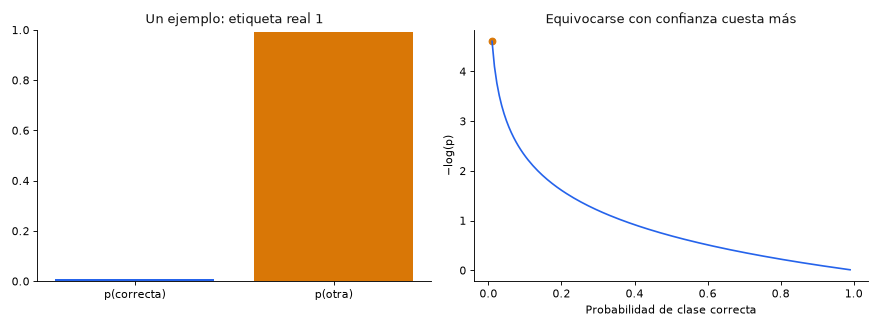
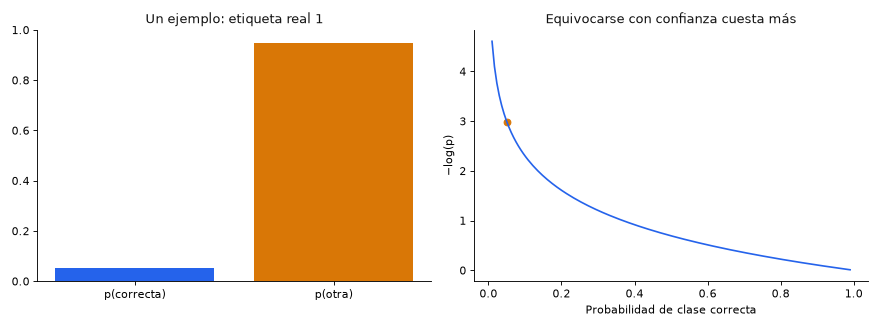
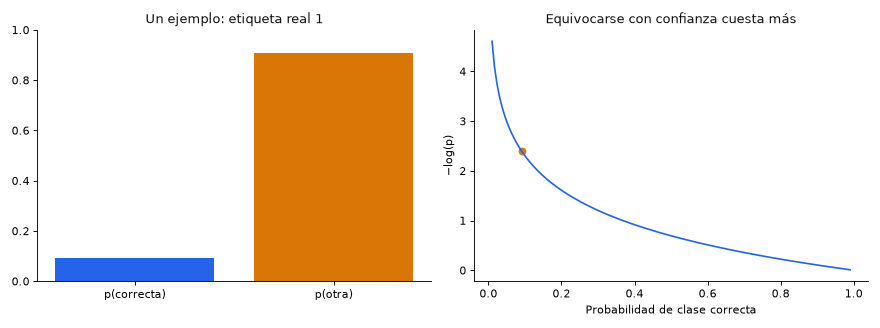
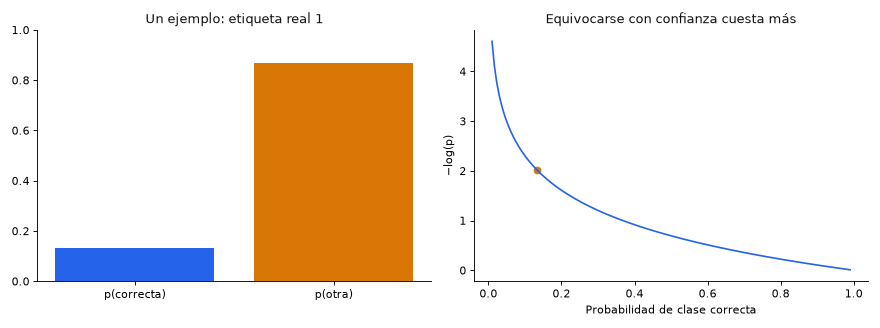
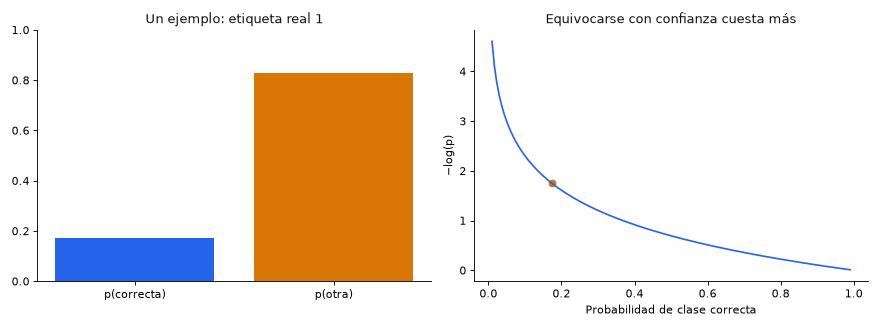
...
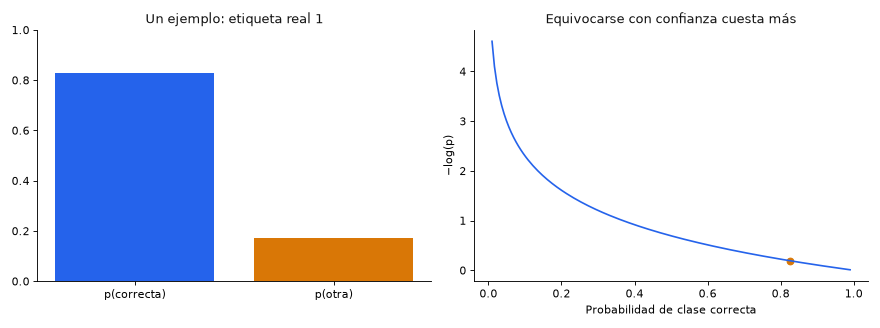
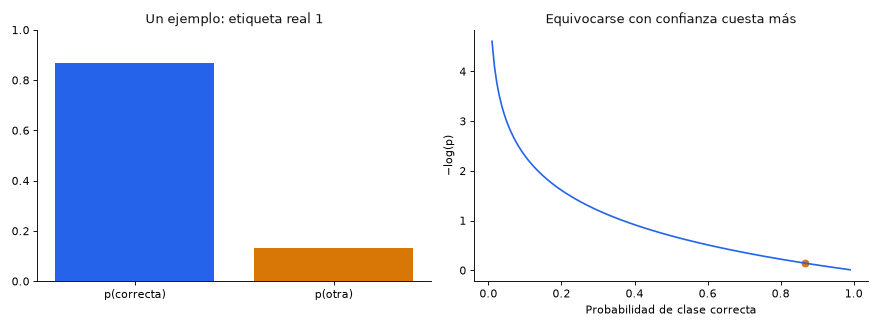
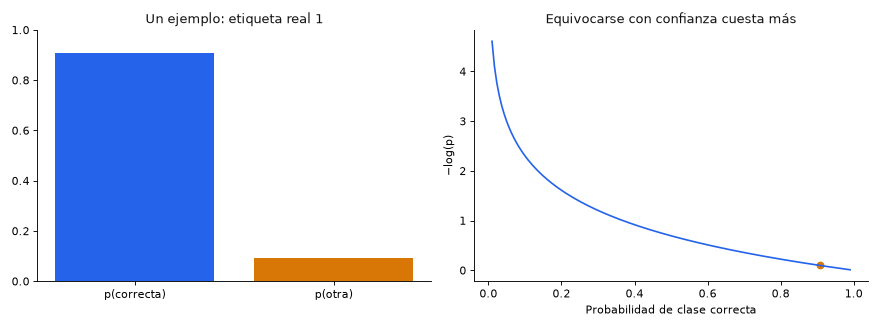
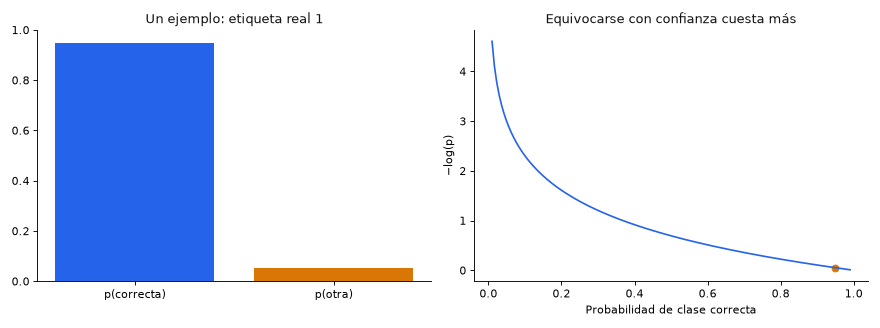
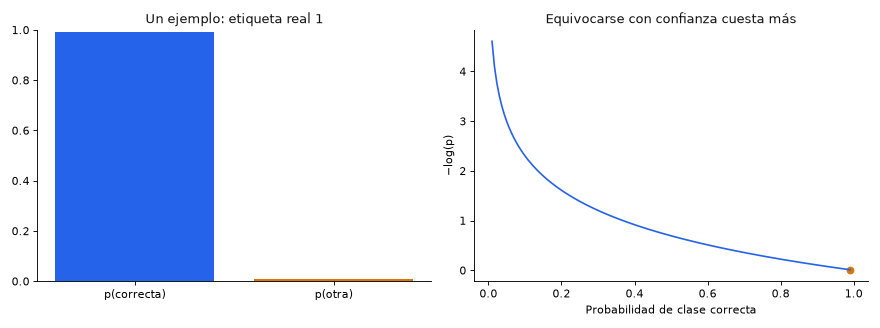

In [ ]:
from IPython.display import HTML, display
display(HTML('<iframe title="La pérdida distingue errores que el acierto no distingue" sandbox="allow-scripts" style="width:100%;height:840px;border:0" srcdoc="&lt;!doctype html&gt;&lt;html lang=&quot;es&quot;&gt;&lt;meta charset=&quot;utf-8&quot;&gt;\n&lt;style&gt;body{font:15px system-ui;color:#111;background:white;margin:8px}button{padding:8px 14px;margin-right:8px;cursor:pointer}input{width:280px;vertical-align:middle}.stage{position:relative;width:100%;aspect-ratio:11/4.1}.stage img{position:absolute;inset:0;width:100%;height:100%;object-fit:contain}p{margin:8px 0}&lt;/style&gt;\n&lt;button id=&quot;play&quot;&gt;▶ Play&lt;/button&gt;&lt;button id=&quot;pause&quot;&gt;Ⅱ Pausa&lt;/button&gt;&lt;button id=&quot;reset&quot;&gt;↺ Reiniciar&lt;/button&gt;\n&lt;input id=&quot;seek&quot; aria-label=&quot;Recorrido&quot; type=&quot;range&quot; min=&quot;0&quot; max=&quot;1&quot; step=&quot;0.001&quot; value=&quot;0&quot;&gt;&lt;output id=&quot;value&quot;&gt;0.000&lt;/output&gt;\n&lt;p&gt;La pérdida define cómo evaluamos un error · Fundido continuo entre estados calculados. Duración: 18 segundos.&lt;/p&gt;\n&lt;div class=&quot;stage&quot;&gt;&lt;img id=&quot;a&quot; alt=&quot;Estado anterior&quot;&gt;&lt;img id=&quot;b&quot; alt=&quot;Transición al siguiente estado&quot;&gt;&lt;/div&gt;\n&lt;script&gt;\nconst frames=[&quot;&quot;, &quot;&quot;, &quot;&quot;, &quot;&quot;, &quot;&quot;, &quot;&quot;, &quot;&quot;, &quot;&quot;, &quot;&quot;, &quot;&quot;, &quot;&quot;, &quot;&quot;, &quot;&quot;, &quot;&quot;, &quot;&quot;, &quot;&quot;, &quot;&quot;, &quot;&quot;, &quot;&quot;, &quot;&quot;, &quot;&quot;, &quot;&quot;, &quot;&quot;, &quot;&quot;, &quot;&quot;];const imgs=frames.map(src=&gt;{let im=new Image();im.src=src;return im});\nconst a=document.getElementById(&#x27;a&#x27;),b=document.getElementById(&#x27;b&#x27;),seek=document.getElementById(&#x27;seek&#x27;),label=document.getElementById(&#x27;value&#x27;);\nlet position=0,playing=false,previous=null;\nfunction draw(){const f=position*(frames.length-1),i=Math.floor(f),j=Math.min(i+1,frames.length-1);if(a.src!==frames[i])a.src=frames[i];if(b.src!==frames[j])b.src=frames[j];b.style.opacity=f-i;seek.value=position;label.textContent=position.toFixed(3)}\nfunction tick(now){if(playing&amp;&amp;previous!==null){position=Math.min(1,position+(now-previous)/18000);draw();if(position===1)playing=false}previous=now;requestAnimationFrame(tick)}\ndocument.getElementById(&#x27;play&#x27;).onclick=()=&gt;{if(position&gt;=1)position=0;previous=null;playing=true};\ndocument.getElementById(&#x27;pause&#x27;).onclick=()=&gt;playing=false;\ndocument.getElementById(&#x27;reset&#x27;).onclick=()=&gt;{playing=false;position=0;draw()};\nseek.oninput=()=&gt;{playing=false;position=Number(seek.value);draw()};draw();requestAnimationFrame(tick);\n&lt;/script&gt;&lt;/html&gt;"></iframe>'))

<div style="background:white;color:#111111;border-left:4px solid #111111;padding:18px 24px;line-height:1.75"><h2>19 · El espacio de parámetros y el proceso de aprendizaje</h2><p>En el espacio de entrada, un punto representa una observación. En el espacio de parámetros, un punto θ representa una función completa. La pérdida media L(θ) asigna un coste al modelo sobre el conjunto de entrenamiento.</p><p><strong>Modificar un parámetro cambia simultáneamente las predicciones y pérdidas de varios ejemplos.</strong> El mapa muestra una región de la familia logística de dos parámetros de esta demo, no la superficie completa de una MLP. El entrenamiento modifica parámetros para reducir un objetivo; un recorrido manual no es un algoritmo de optimización.</p><p><strong>Pregunta clave: ¿Qué representa un punto del mapa y qué permanece fijo al moverlo?</strong></p></div>

Laboratorio interactivo autocontenido
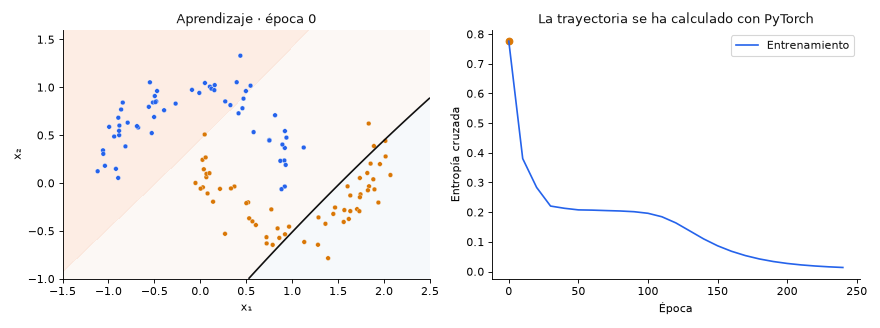
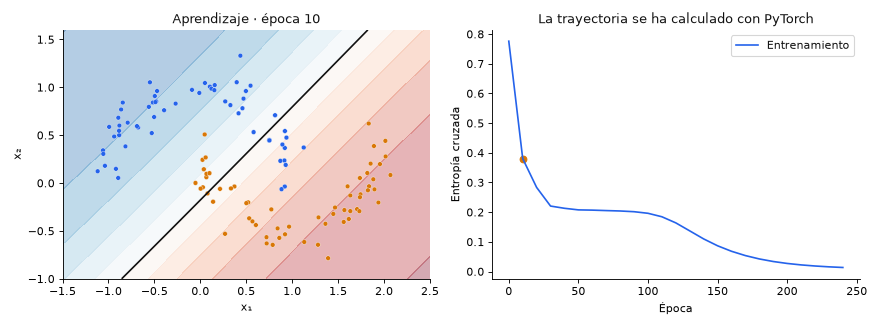
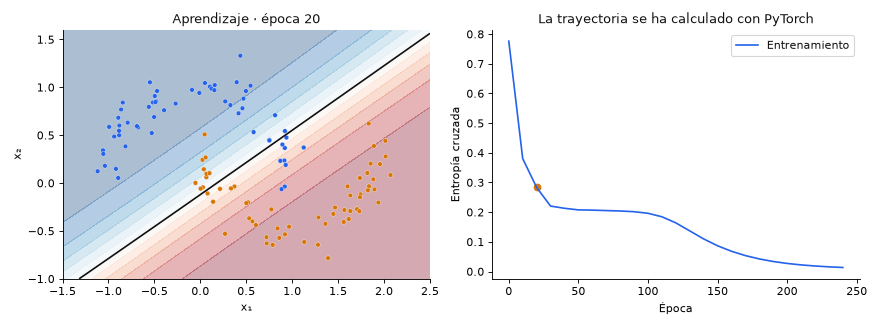
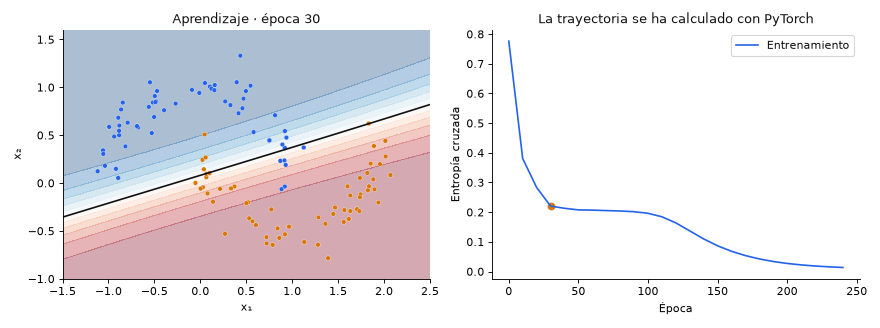
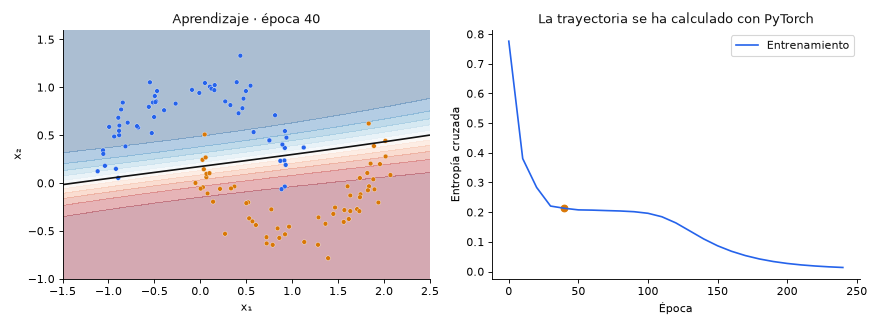
...
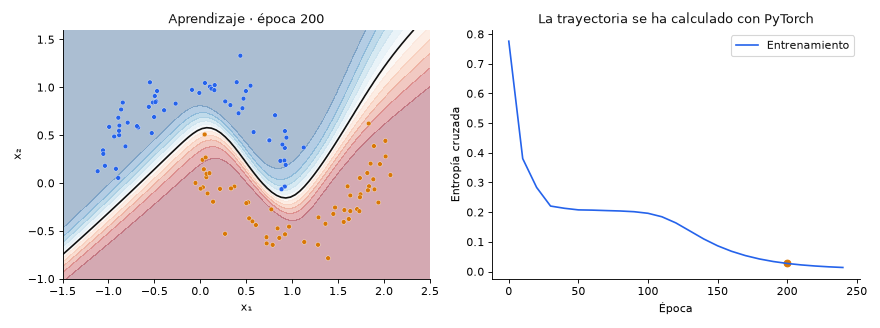
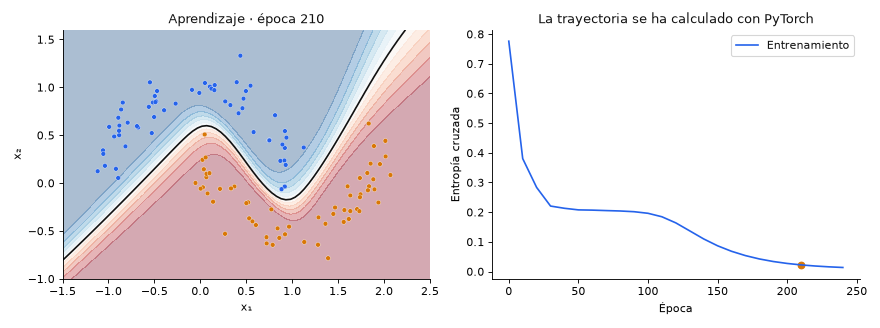
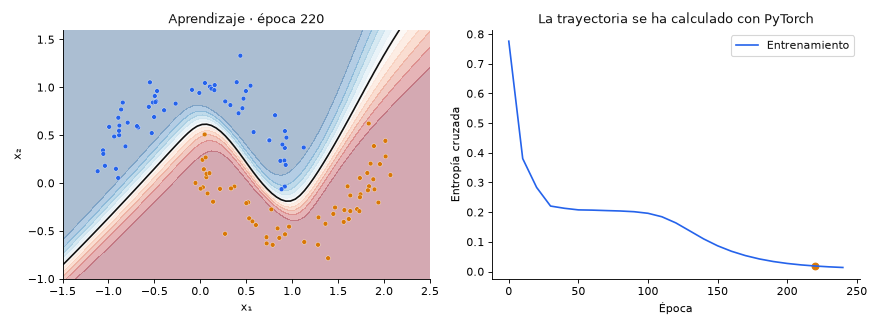
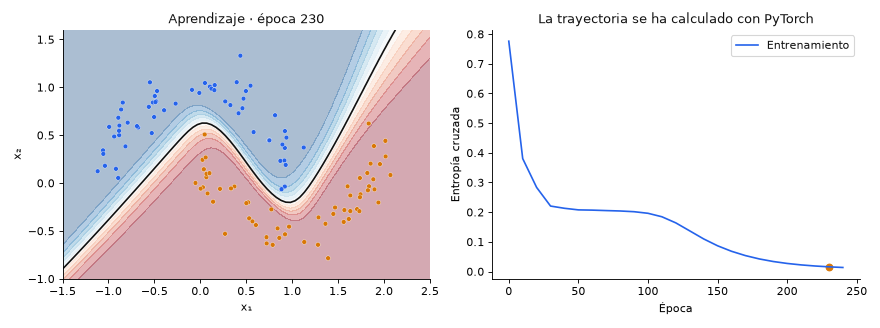
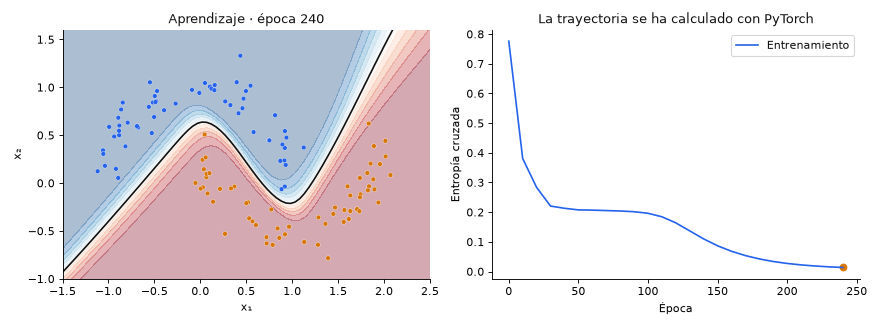

In [ ]:
from IPython.display import HTML, display
display(HTML('<iframe title="El espacio de parámetros y el proceso de aprendizaje" sandbox="allow-scripts" style="width:100%;height:840px;border:0" srcdoc="&lt;!doctype html&gt;&lt;html lang=&quot;es&quot;&gt;&lt;meta charset=&quot;utf-8&quot;&gt;&lt;style&gt;body{margin:0;font:14px system-ui;color:#334155}nav{padding:8px;display:flex;flex-wrap:wrap;gap:8px}button{font:inherit;padding:8px;border:1px solid #cbd5e1;background:white;border-radius:6px;cursor:pointer}button[aria-pressed=true]{background:#183b63;color:white}p{margin:8px}iframe{width:100%;height:730px;border:0}&lt;/style&gt;&lt;p&gt;Recorrido principal: primera vista. Las consultas son opcionales; al cambiar de vista se reinicia su demo.&lt;/p&gt;&lt;nav aria-label=&quot;Perspectivas del concepto&quot;&gt;&lt;/nav&gt;&lt;div id=&quot;view&quot;&gt;&lt;/div&gt;&lt;script&gt;const pages=[[&quot;Explorar parámetros&quot;, &quot;&lt;!doctype html&gt;&lt;html lang=\\&quot;es\\&quot;&gt;&lt;meta charset=\\&quot;utf-8\\&quot;&gt;\\n&lt;style&gt;body{font:15px system-ui;color:#15283d;margin:16px;background:#fff}h3{margin:8px 0}button,select{font:inherit;padding:7px 12px;border:1px solid #b6c5d5;border-radius:7px;background:#f4f7fb;cursor:pointer}button:focus-visible,input:focus-visible{outline:3px solid #2563eb}#controls{display:flex;gap:16px;flex-wrap:wrap;margin:14px 0}label{display:grid;gap:5px;min-width:155px}output{font-variant-numeric:tabular-nums}canvas{width:100%;max-width:1000px;border:1px solid #e2e8f0;border-radius:10px}#note{padding:12px;background:#f0f5fa;line-height:1.6}small{color:#53657b}&lt;\\/style&gt;\\n&lt;h3 id=\\&quot;title\\&quot;&gt;&lt;\\/h3&gt;&lt;button id=\\&quot;play\\&quot;&gt;▶ Play&lt;\\/button&gt; &lt;button id=\\&quot;reset\\&quot;&gt;↺ Reiniciar&lt;\\/button&gt; &lt;span id=\\&quot;actions\\&quot;&gt;&lt;\\/span&gt;\\n&lt;div id=\\&quot;controls\\&quot;&gt;&lt;\\/div&gt;&lt;canvas id=\\&quot;plot\\&quot; width=\\&quot;1000\\&quot; height=\\&quot;420\\&quot; aria-label=\\&quot;Visualización matemática interactiva\\&quot;&gt;&lt;\\/canvas&gt;&lt;p id=\\&quot;note\\&quot; role=\\&quot;status\\&quot;&gt;&lt;\\/p&gt;&lt;small&gt;Valores calculados en el navegador. Play recorre parámetros de forma continua; no ejecuta un entrenamiento.&lt;\\/small&gt;\\n&lt;script&gt;\\nconst MODE={\\&quot;mode\\&quot;: \\&quot;loss_space\\&quot;}.mode,c=document.getElementById(&#x27;plot&#x27;),g=c.getContext(&#x27;2d&#x27;),controls=document.getElementById(&#x27;controls&#x27;),note=document.getElementById(&#x27;note&#x27;);\\nconst S={},I={},initial={};let playing=false,t=0,last=0,nonlinear=false;\\nfunction slider(k,name,v,min,max){S[k]=initial[k]=v;const l=document.createElement(&#x27;label&#x27;);l.textContent=name;const i=document.createElement(&#x27;input&#x27;);i.type=&#x27;range&#x27;;i.min=min;i.max=max;i.step=.01;i.value=v;i.setAttribute(&#x27;aria-label&#x27;,name);const o=document.createElement(&#x27;output&#x27;);l.append(i,o);controls.append(l);I[k]={i,o};i.oninput=()=&gt;{pause();S[k]=+i.value;draw()};}\\nfunction set(k,v){S[k]=v;I[k].i.value=v;I[k].o.textContent=v.toFixed(2)}\\nfunction pause(){playing=false;document.getElementById(&#x27;play&#x27;).textContent=&#x27;▶ Play&#x27;}\\nfunction text(x,y,s,col=&#x27;#15283d&#x27;,size=15){g.fillStyle=col;g.font=`${size}px system-ui`;g.fillText(s,x,y)}\\nfunction line(x,y,X,Y,col=&#x27;#b9c8d8&#x27;,w=1){g.strokeStyle=col;g.lineWidth=w;g.beginPath();g.moveTo(x,y);g.lineTo(X,Y);g.stroke()}\\nfunction dot(x,y,col=&#x27;#2563eb&#x27;,r=4){g.fillStyle=col;g.beginPath();g.arc(x,y,r,0,Math.PI*2);g.fill()}\\nfunction panel(x,y,w,h,title,min=-3,max=3){text(x,y-15,title);const map=(a,b)=&gt;[x+(a-min)/(max-min)*w,y+h-(b-min)/(max-min)*h];for(let k=Math.ceil(min);k&lt;=max;k++){line(...map(k,min),...map(k,max),&#x27;#e9eef5&#x27;);line(...map(min,k),...map(max,k),&#x27;#e9eef5&#x27;)}line(...map(min,0),...map(max,0));line(...map(0,min),...map(0,max));return map}\\nfunction curve(map,f,col,width=2,min=-3,max=3){g.save();g.beginPath();for(let i=0;i&lt;=180;i++){const x=min+(max-min)*i/180,p=map(x,f(x));i?g.lineTo(...p):g.moveTo(...p)}g.strokeStyle=col;g.lineWidth=width;g.stroke();g.restore()}\\nconst mul=(A,x)=&gt;[A[0]*x[0]+A[1]*x[1],A[2]*x[0]+A[3]*x[1]];\\nconst sigmoid=z=&gt;1/(1+Math.exp(-z));\\nconst DATA=[[-1.6,0],[-1.1,0],[-.6,0],[-.2,1],[.3,0],[.8,1],[1.2,1],[1.7,1]];\\nfunction loss(w,b){return DATA.reduce((s,[x,y])=&gt;{const z=w*x+b;return s+Math.max(z,0)-y*z+Math.log1p(Math.exp(-Math.abs(z)))},0)/DATA.length}\\nlet heat;\\nif(MODE===&#x27;composition&#x27;){\\n document.getElementById(&#x27;title&#x27;).textContent=&#x27;¿Dos capas afines aportan una función nueva?&#x27;;slider(&#x27;angle&#x27;,&#x27;Rotación de la primera capa&#x27;,.3,-1.6,1.6);slider(&#x27;shear&#x27;,&#x27;Cizalla de la segunda capa&#x27;,.5,-1,1);slider(&#x27;bias&#x27;,&#x27;Sesgo de la primera capa&#x27;,0,-.8,.8);\\n const b=document.createElement(&#x27;button&#x27;);b.textContent=&#x27;Intercalar tanh: no&#x27;;b.onclick=()=&gt;{pause();nonlinear=!nonlinear;b.textContent=&#x27;Intercalar tanh: &#x27;+(nonlinear?&#x27;sí&#x27;:&#x27;no&#x27;);draw()};document.getElementById(&#x27;actions&#x27;).append(b);\\n}else if(MODE===&#x27;relu_sum&#x27;){\\n document.getElementById(&#x27;title&#x27;).textContent=&#x27;De unidades ReLU a una función por regiones&#x27;;slider(&#x27;knot&#x27;,&#x27;Punto de cambio central&#x27;,0,-1,1);slider(&#x27;weight&#x27;,&#x27;Peso de la unidad central&#x27;,-1.5,-2.5,1);slider(&#x27;bias&#x27;,&#x27;Sesgo de salida&#x27;,0,-.6,.6);\\n}else{\\n document.getElementById(&#x27;title&#x27;).textContent=&#x27;Datos, parámetros y pérdida: tres objetos distintos&#x27;;slider(&#x27;w&#x27;,&#x27;Peso w&#x27;,1,-3,3);slider(&#x27;b&#x27;,&#x27;Sesgo b&#x27;,0,-3,3);\\n heat=document.createElement(&#x27;canvas&#x27;);heat.width=heat.height=100;const h=heat.getContext(&#x27;2d&#x27;);for(let i=0;i&lt;100;i++)for(let j=0;j&lt;100;j++){const L=loss(-3+6*i/99,3-6*j/99),v=Math.min(1,L/4);h.fillStyle=`hsl(${220-190*v} 65% ${88-42*v}%)`;h.fillRect(i,j,1,1)}\\n c.addEventListener(&#x27;pointerdown&#x27;,e=&gt;{const r=c.getBoundingClientRect(),x=(e.clientX-r.left)*1000/r.width,y=(e.clientY-r.top)*420/r.height;if(x&gt;=45&amp;&amp;x&lt;=345&amp;&amp;y&gt;=65&amp;&amp;y&lt;=365){pause();set(&#x27;w&#x27;,-3+(x-45)/50);set(&#x27;b&#x27;,3-(y-65)/50);draw()}});\\n}\\nfunction draw(){g.clearRect(0,0,1000,420);Object.keys(S).forEach(k=&gt;set(k,S[k]));\\n if(MODE===&#x27;composition&#x27;){\\n  const a=S.angle,A=[Math.cos(a),-Math.sin(a),Math.sin(a),Math.cos(a)],B=[1,S.shear,0,1],b=[S.bias,0];\\n  const left=panel(35,75,240,270,&#x27;Entrada x&#x27;),middle=panel(365,75,240,270,&#x27;Dos capas: B φ(Ax + b)&#x27;),right=panel(695,75,240,270,&#x27;Una capa: (BA)x + Bb&#x27;);let err=0;\\n  for(let i=0;i&lt;24;i++){const x=[1.5*Math.cos(i*Math.PI/12),1.5*Math.sin(i*Math.PI/12)],u=mul(A,x).map((v,k)=&gt;v+b[k]);const y=mul(B,nonlinear?u.map(Math.tanh):u);const BA=[B[0]*A[0]+B[1]*A[2],B[0]*A[1]+B[1]*A[3],B[2]*A[0]+B[3]*A[2],B[2]*A[1]+B[3]*A[3]],bb=mul(B,b),v=mul(BA,x).map((q,k)=&gt;q+bb[k]);const col=`hsl(${i*15} 70% 45%)`;dot(...left(...x),col);dot(...middle(...y),col);dot(...right(...v),col);err=Math.max(err,Math.hypot(y[0]-v[0],y[1]-v[1]));}\\n  text(296,210,&#x27;→&#x27;,undefined,26);text(626,210,&#x27;≟&#x27;,undefined,26);note.textContent=`Diferencia máxima en los puntos mostrados: ${err.toFixed(6)}. `+(nonlinear?&#x27;Al intercalar tanh, la fórmula afín colapsada deja de representar en general la composición.&#x27;:&#x27;Sin activación intermedia, ambas rutas son algebraicamente equivalentes para cualquier entrada.&#x27;);\\n }else if(MODE===&#x27;relu_sum&#x27;){\\n  const m=panel(45,75,380,280,&#x27;Contribuciones ponderadas&#x27;,-3,3),n=panel(555,75,380,280,&#x27;Suma y sesgo de salida&#x27;,-3,3),ks=[-1.5,S.knot,1.5],ws=[.7,S.weight,.6],cols=[&#x27;#2563eb&#x27;,&#x27;#d97706&#x27;,&#x27;#059669&#x27;];\\n  const fs=ks.map((k,i)=&gt;x=&gt;ws[i]*Math.max(0,x-k));g.save();g.beginPath();g.rect(45,75,380,280);g.clip();fs.forEach((f,i)=&gt;curve(m,f,cols[i],3));g.restore();g.save();g.beginPath();g.rect(555,75,380,280);g.clip();curve(n,x=&gt;S.bias+fs.reduce((s,f)=&gt;s+f(x),0),&#x27;#7c3aed&#x27;,4);g.restore();ks.forEach(k=&gt;{line(...n(k,-3),...n(k,3),&#x27;#cbd5e1&#x27;);text(n(k,0)[0]-12,380,k.toFixed(1),&#x27;#53657b&#x27;,12)});text(45,400,&#x27;Azul: unidad 1   ·   Naranja: unidad 2   ·   Verde: unidad 3&#x27;);\\n  note.textContent=`f(x) = 0.7 ReLU(x + 1.5) + (${S.weight.toFixed(2)}) ReLU(x − (${S.knot.toFixed(2)})) + 0.6 ReLU(x − 1.5) + (${S.bias.toFixed(2)}). Cada unidad cambia la pendiente a partir de su umbral; la suma sigue siendo continua. Las curvas se recortan al rango de los ejes.`;\\n }else{\\n  text(45,35,&#x27;Espacio de parámetros (w, b)&#x27;);g.drawImage(heat,45,65,300,300);const px=45+(S.w+3)*50,py=65+(3-S.b)*50;dot(px,py,&#x27;#fff&#x27;,8);dot(px,py,&#x27;#111&#x27;,4);text(45,390,&#x27;w: −3 → 3 · b: −3 abajo → 3 arriba&#x27;);\\n  const m=(x,p)=&gt;[445+(x+2)/4*240,345-p*240];text(445,35,&#x27;Predicción con esos parámetros&#x27;);for(let k=0;k&lt;=4;k++)line(445,345-k*60,685,345-k*60,&#x27;#e9eef5&#x27;);line(445,225,685,225,&#x27;#d97706&#x27;);curve(m,x=&gt;sigmoid(S.w*x+S.b),&#x27;#2563eb&#x27;,3,-2,2);DATA.forEach(([x,y])=&gt;dot(...m(x,y),y?&#x27;#059669&#x27;:&#x27;#d97706&#x27;,5));text(445,380,&#x27;x: −2 → 2 · p: 0 abajo → 1 arriba&#x27;);\\n  text(740,35,&#x27;Pérdidas individuales&#x27;);DATA.forEach(([x,y],i)=&gt;{const z=S.w*x+S.b,L=Math.max(z,0)-y*z+Math.log1p(Math.exp(-Math.abs(z)));g.fillStyle=y?&#x27;#059669&#x27;:&#x27;#d97706&#x27;;g.fillRect(755+i*27,345-Math.min(L,10)*26,18,Math.min(L,10)*26);text(755+i*27,365,String(i+1),&#x27;#53657b&#x27;,11)});text(740,395,&#x27;Altura: pérdida (escala 0–10)&#x27;);\\n  note.textContent=`Pérdida media = ${loss(S.w,S.b).toFixed(4)}. En el mapa, azul claro indica menor pérdida y naranja oscuro mayor (escala saturada en 4). Un punto del mapa es un modelo, no una observación. Los ocho datos permanecen fijos. Haz clic en el mapa o mueve los sliders.`;\\n }\\n}\\ndocument.getElementById(&#x27;play&#x27;).onclick=()=&gt;{playing=!playing;document.getElementById(&#x27;play&#x27;).textContent=playing?&#x27;Ⅱ Pausa&#x27;:&#x27;▶ Play&#x27;};\\ndocument.getElementById(&#x27;reset&#x27;).onclick=()=&gt;{pause();t=0;Object.keys(S).forEach(k=&gt;set(k,initial[k]));nonlinear=false;const b=document.querySelector(&#x27;#actions button&#x27;);if(b)b.textContent=&#x27;Intercalar tanh: no&#x27;;draw()};\\nfunction frame(now){const dt=last?Math.min(.05,(now-last)/1000):0;last=now;if(playing){t+=dt;const q=Math.sin(t*.45);if(MODE===&#x27;composition&#x27;){set(&#x27;angle&#x27;,.3+q);set(&#x27;shear&#x27;,.5*Math.cos(t*.3));}else if(MODE===&#x27;relu_sum&#x27;){set(&#x27;knot&#x27;,.9*q);set(&#x27;weight&#x27;,-1.5+.7*Math.sin(t*.3));}else{set(&#x27;w&#x27;,2.7*q);set(&#x27;b&#x27;,1.4*Math.sin(t*.3));}draw()}requestAnimationFrame(frame)}draw();requestAnimationFrame(frame);\\n&lt;\\/script&gt;&lt;\\/html&gt;\\n&quot;], [&quot;Contrastar: entrenamiento real precalculado&quot;, &quot;&lt;!doctype html&gt;&lt;html lang=\\&quot;es\\&quot;&gt;&lt;meta charset=\\&quot;utf-8\\&quot;&gt;\\n&lt;style&gt;body{font:15px system-ui;color:#111;background:white;margin:8px}button{padding:8px 14px;margin-right:8px;cursor:pointer}input{width:280px;vertical-align:middle}.stage{position:relative;width:100%;aspect-ratio:11/4.1}.stage img{position:absolute;inset:0;width:100%;height:100%;object-fit:contain}p{margin:8px 0}&lt;\\/style&gt;\\n&lt;button id=\\&quot;play\\&quot;&gt;▶ Play&lt;\\/button&gt;&lt;button id=\\&quot;pause\\&quot;&gt;Ⅱ Pausa&lt;\\/button&gt;&lt;button id=\\&quot;reset\\&quot;&gt;↺ Reiniciar&lt;\\/button&gt;\\n&lt;input id=\\&quot;seek\\&quot; aria-label=\\&quot;Recorrido\\&quot; type=\\&quot;range\\&quot; min=\\&quot;0\\&quot; max=\\&quot;1\\&quot; step=\\&quot;0.001\\&quot; value=\\&quot;0\\&quot;&gt;&lt;output id=\\&quot;value\\&quot;&gt;0.000&lt;\\/output&gt;\\n&lt;p&gt;Entrenamiento: frontera y pérdida evolucionan juntas · Fundido continuo entre estados calculados. Duración: 18 segundos.&lt;\\/p&gt;\\n&lt;div class=\\&quot;stage\\&quot;&gt;&lt;img id=\\&quot;a\\&quot; alt=\\&quot;Estado anterior\\&quot;&gt;&lt;img id=\\&quot;b\\&quot; alt=\\&quot;Transición al siguiente estado\\&quot;&gt;&lt;\\/div&gt;\\n&lt;script&gt;\\nconst frames=[\\&quot;\\&quot;, \\&quot;\\&quot;, \\&quot;\\&quot;, \\&quot;\\&quot;, \\&quot;\\&quot;, \\&quot;\\&quot;, \\&quot;\\&quot;, \\&quot;\\&quot;, \\&quot;\\&quot;, \\&quot;\\&quot;, \\&quot;\\&quot;, \\&quot;\\&quot;, \\&quot;\\&quot;, \\&quot;\\&quot;, \\&quot;\\&quot;, \\&quot;\\&quot;, \\&quot;\\&quot;, \\&quot;\\&quot;, \\&quot;\\&quot;, \\&quot;\\&quot;, \\&quot;\\&quot;, \\&quot;\\&quot;, \\&quot;\\&quot;, \\&quot;\\&quot;, \\&quot;\\&quot;];const imgs=frames.map(src=&gt;{let im=new Image();im.src=src;return im});\\nconst a=document.getElementById(&#x27;a&#x27;),b=document.getElementById(&#x27;b&#x27;),seek=document.getElementById(&#x27;seek&#x27;),label=document.getElementById(&#x27;value&#x27;);\\nlet position=0,playing=false,previous=null;\\nfunction draw(){const f=position*(frames.length-1),i=Math.floor(f),j=Math.min(i+1,frames.length-1);if(a.src!==frames[i])a.src=frames[i];if(b.src!==frames[j])b.src=frames[j];b.style.opacity=f-i;seek.value=position;label.textContent=position.toFixed(3)}\\nfunction tick(now){if(playing&amp;&amp;previous!==null){position=Math.min(1,position+(now-previous)/18000);draw();if(position===1)playing=false}previous=now;requestAnimationFrame(tick)}\\ndocument.getElementById(&#x27;play&#x27;).onclick=()=&gt;{if(position&gt;=1)position=0;previous=null;playing=true};\\ndocument.getElementById(&#x27;pause&#x27;).onclick=()=&gt;playing=false;\\ndocument.getElementById(&#x27;reset&#x27;).onclick=()=&gt;{playing=false;position=0;draw()};\\nseek.oninput=()=&gt;{playing=false;position=Number(seek.value);draw()};draw();requestAnimationFrame(tick);\\n&lt;\\/script&gt;&lt;\\/html&gt;&quot;]];const nav=document.querySelector(&#x27;nav&#x27;),view=document.getElementById(&#x27;view&#x27;);function show(i){nav.querySelectorAll(&#x27;button&#x27;).forEach((b,j)=&gt;b.setAttribute(&#x27;aria-pressed&#x27;,String(i===j)));const f=document.createElement(&#x27;iframe&#x27;);f.title=pages[i][0];f.setAttribute(&#x27;sandbox&#x27;,&#x27;allow-scripts&#x27;);f.srcdoc=pages[i][1];view.replaceChildren(f)}pages.forEach(([label],i)=&gt;{const b=document.createElement(&#x27;button&#x27;);b.textContent=label;b.onclick=()=&gt;show(i);nav.append(b)});show(0);&lt;/script&gt;&lt;/html&gt;"></iframe>'))

<div style="background:white;color:#111111;border-left:4px solid #111111;padding:18px 24px;line-height:1.75"><h2>20 · Generalización: qué significa aprender algo útil</h2><p>El error de entrenamiento mide el ajuste sobre los datos utilizados para estimar parámetros. La validación utiliza otros ejemplos para orientar decisiones como arquitectura, regularización o duración del entrenamiento. Un test independiente se reserva para evaluar el procedimiento finalmente seleccionado.</p><p><strong>Generalizar significa funcionar sobre nuevas observaciones de la población de interés.</strong> Una mejora en entrenamiento puede coexistir con un empeoramiento en validación. Además, reutilizar intensivamente la validación para seleccionar modelos puede adaptar nuestras decisiones a esa muestra.</p><p><strong>Pregunta clave: ¿La pérdida de entrenamiento basta para afirmar que la red generaliza?</strong></p></div>

Laboratorio interactivo autocontenido
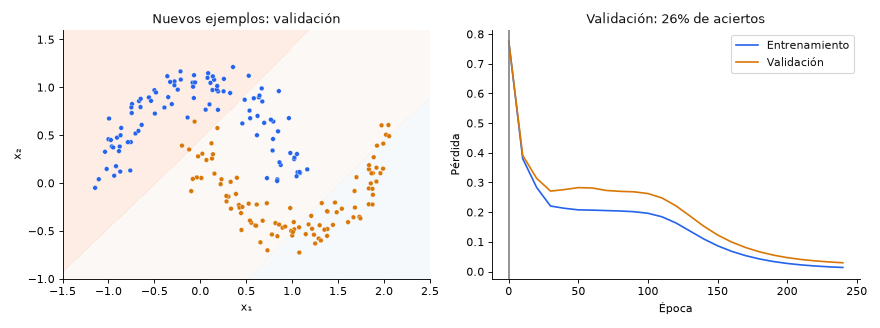
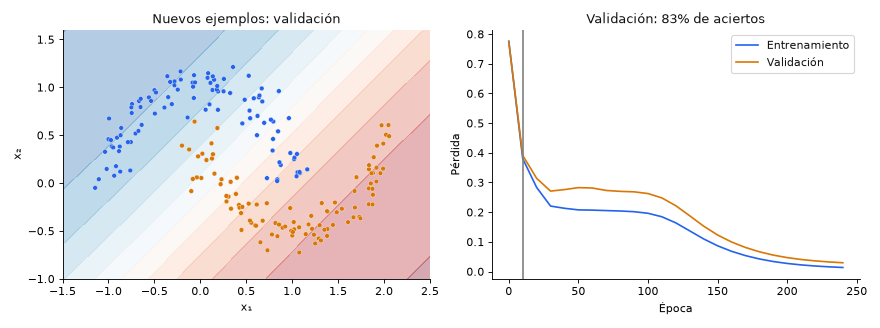
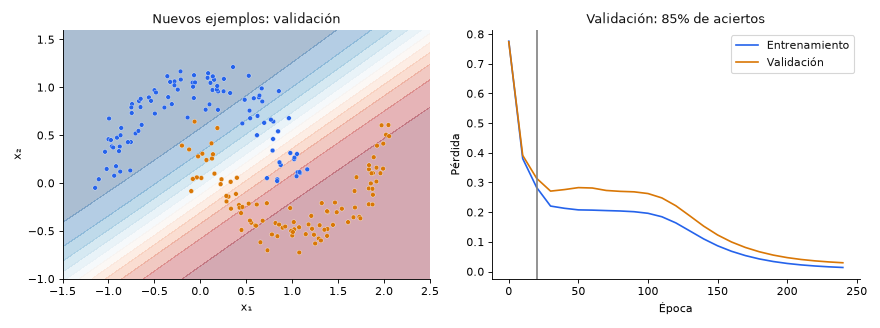
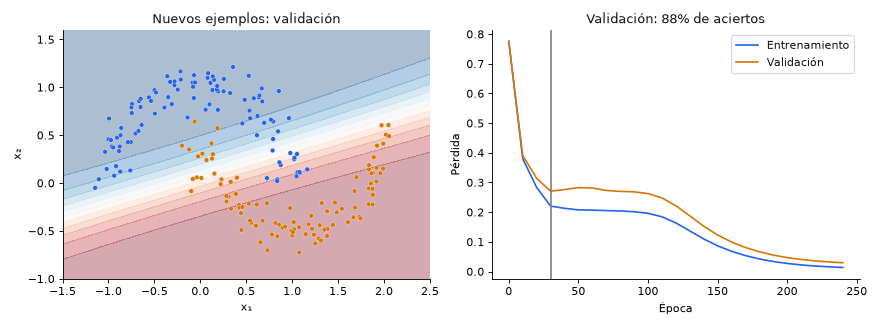
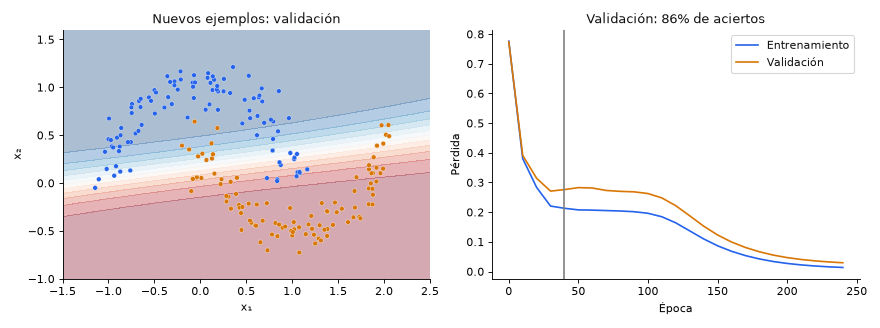
...
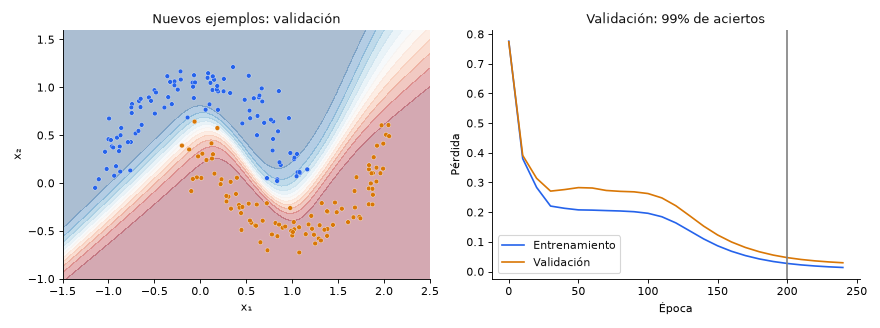
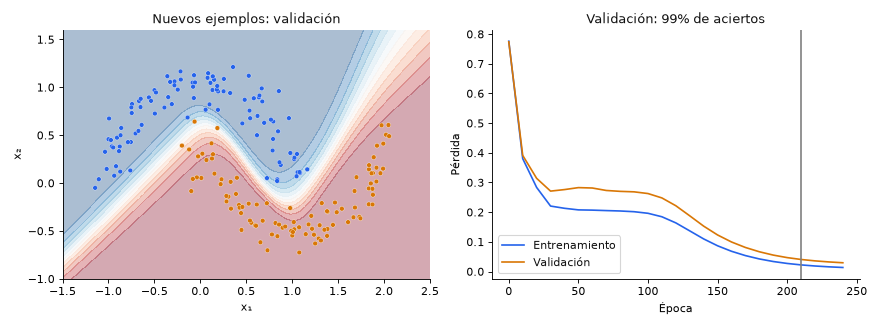
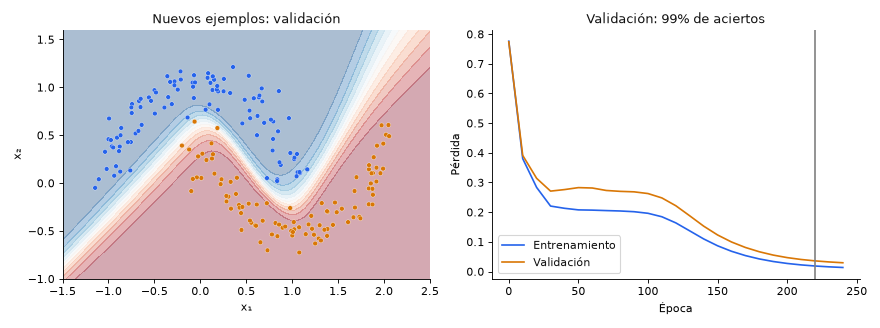
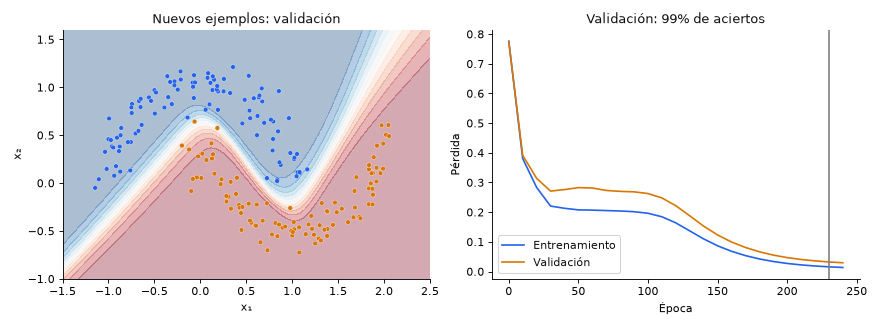
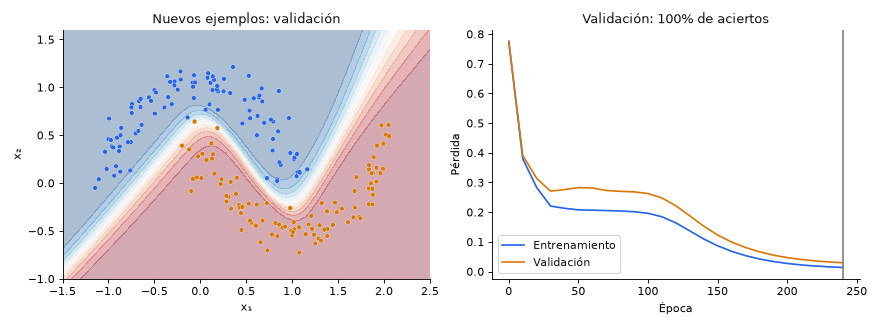

In [ ]:
from IPython.display import HTML, display
display(HTML('<iframe title="Generalización: qué significa aprender algo útil" sandbox="allow-scripts" style="width:100%;height:840px;border:0" srcdoc="&lt;!doctype html&gt;&lt;html lang=&quot;es&quot;&gt;&lt;meta charset=&quot;utf-8&quot;&gt;\n&lt;style&gt;body{font:15px system-ui;color:#111;background:white;margin:8px}button{padding:8px 14px;margin-right:8px;cursor:pointer}input{width:280px;vertical-align:middle}.stage{position:relative;width:100%;aspect-ratio:11/4.1}.stage img{position:absolute;inset:0;width:100%;height:100%;object-fit:contain}p{margin:8px 0}&lt;/style&gt;\n&lt;button id=&quot;play&quot;&gt;▶ Play&lt;/button&gt;&lt;button id=&quot;pause&quot;&gt;Ⅱ Pausa&lt;/button&gt;&lt;button id=&quot;reset&quot;&gt;↺ Reiniciar&lt;/button&gt;\n&lt;input id=&quot;seek&quot; aria-label=&quot;Recorrido&quot; type=&quot;range&quot; min=&quot;0&quot; max=&quot;1&quot; step=&quot;0.001&quot; value=&quot;0&quot;&gt;&lt;output id=&quot;value&quot;&gt;0.000&lt;/output&gt;\n&lt;p&gt;Aprender no es solo acertar los ejemplos vistos · Fundido continuo entre estados calculados. Duración: 18 segundos.&lt;/p&gt;\n&lt;div class=&quot;stage&quot;&gt;&lt;img id=&quot;a&quot; alt=&quot;Estado anterior&quot;&gt;&lt;img id=&quot;b&quot; alt=&quot;Transición al siguiente estado&quot;&gt;&lt;/div&gt;\n&lt;script&gt;\nconst frames=[&quot;&quot;, &quot;&quot;, &quot;&quot;, &quot;&quot;, &quot;&quot;, &quot;&quot;, &quot;&quot;, &quot;&quot;, &quot;&quot;, &quot;&quot;, &quot;&quot;, &quot;&quot;, &quot;&quot;, &quot;&quot;, &quot;&quot;, &quot;&quot;, &quot;&quot;, &quot;&quot;, &quot;&quot;, &quot;&quot;, &quot;&quot;, &quot;&quot;, &quot;&quot;, &quot;&quot;, &quot;&quot;];const imgs=frames.map(src=&gt;{let im=new Image();im.src=src;return im});\nconst a=document.getElementById(&#x27;a&#x27;),b=document.getElementById(&#x27;b&#x27;),seek=document.getElementById(&#x27;seek&#x27;),label=document.getElementById(&#x27;value&#x27;);\nlet position=0,playing=false,previous=null;\nfunction draw(){const f=position*(frames.length-1),i=Math.floor(f),j=Math.min(i+1,frames.length-1);if(a.src!==frames[i])a.src=frames[i];if(b.src!==frames[j])b.src=frames[j];b.style.opacity=f-i;seek.value=position;label.textContent=position.toFixed(3)}\nfunction tick(now){if(playing&amp;&amp;previous!==null){position=Math.min(1,position+(now-previous)/18000);draw();if(position===1)playing=false}previous=now;requestAnimationFrame(tick)}\ndocument.getElementById(&#x27;play&#x27;).onclick=()=&gt;{if(position&gt;=1)position=0;previous=null;playing=true};\ndocument.getElementById(&#x27;pause&#x27;).onclick=()=&gt;playing=false;\ndocument.getElementById(&#x27;reset&#x27;).onclick=()=&gt;{playing=false;position=0;draw()};\nseek.oninput=()=&gt;{playing=false;position=Number(seek.value);draw()};draw();requestAnimationFrame(tick);\n&lt;/script&gt;&lt;/html&gt;"></iframe>'))

<div style="background:white;color:#111111;border-left:4px solid #111111;padding:18px 24px;line-height:1.75"><h2>21 · Síntesis: del registro al perceptrón multicapa</h2><p>Un perceptrón multicapa es una composición de capas afines con activaciones no lineales intermedias y una salida adaptada a la tarea. Las capas ocultas producen representaciones; la pérdida define el criterio de ajuste y el algoritmo de optimización actualiza los parámetros.</p><p><strong>Arquitectura, aprendizaje y evaluación responden a preguntas diferentes: qué puede representar el modelo, cómo se ajusta y cómo se comprueba su utilidad.</strong> Aumentar la dimensión de entrada no cambia este esquema, aunque puede hacer necesarias otras estructuras para aprovechar propiedades de los datos.</p><p><strong>Pregunta clave: ¿Qué cambia al pasar de dos coordenadas a una imagen?</strong></p></div>